In [183]:
import asyncio
from sipyco.sync_struct import Subscriber

# Create an asyncio Event to wait for updates
dataset_updated = asyncio.Event()


async def connect_subscriber(name, db: dict, port=None, server=None):
    port = 3250 if port is None else port
    server = "137.222.69.28" if server is None else server

    def _create(data):
        db.update(data)
        return db

    def _update(mod):
        # Signal that an update has occurred
        dataset_updated.set()

    subscriber = Subscriber(name, _create, _update, None)
    try:
        await subscriber.connect(
            server,
            port,
        )
    except asyncio.TimeoutError:
        print(f"Failed to connect to Sub: {name} at {server}:{port}")
        return
    print(f"Connected to Sub: {name} at {server}:{port}")
    return subscriber

**DO NOT add extra code to this lower cell.**

Due to jupyter notebook async weirdness it won't actually await the return before running subsequent code

In [184]:
# Run the connection in an asyncio event loop
db = {}
sub = await connect_subscriber("datasets", db)
await dataset_updated.wait()
# await sub.close()
print("Received dataset update!")

Connected to Sub: datasets at 137.222.69.28:3250
Received dataset update!


In [185]:
import numpy as np

# get the RID of the latest dataset
keys = list(db.keys())
# find ones with ndscan.rid_NUM.source_id
rid_keys = [
    key.split(".")[1][4:]
    for key in keys
    if key.startswith("ndscan.rid_") and key.endswith(".source_id")
]
if rid_keys:
    RID = rid_keys[-1]  # Get the last RID in the list
else:
    raise ValueError("No ndscan datasets found.")
print(f"Selected RID: {RID} from {rid_keys}")

print(f"Dataset keys: {list(db.keys())}")


Selected RID: 28449 from ['28449']
Dataset keys: ['fastino.leds', 'fastino.voltages', 'mirny.atts', 'mirny.en_almazny', 'mirny.en_outs', 'mirny.freqs', 'suservo.Gls', 'suservo.Is', 'suservo.Ps', 'suservo.atts', 'suservo.calib_gains', 'suservo.calib_offsets', 'suservo.en_iirs', 'suservo.en_outs', 'suservo.en_shutters', 'suservo.enabled', 'suservo.freqs', 'suservo.gains', 'suservo.offsets', 'suservo.ys', 'Images.absorption.TOF', 'Images.absorption.REF', 'Images.absorption.BG', 'Images.absorption.expansion_time', 'Images.absorption.settings', 'Images.absorption.timestamp', 'ndscan.rid_28449.ndscan_schema_revision', 'ndscan.rid_28449.source_id', 'ndscan.rid_28449.completed', 'ndscan.rid_28449.execution_mode', 'ndscan.rid_28449.optimizer.kind', 'ndscan.rid_28449.optimizer.objective_channel', 'ndscan.rid_28449.optimizer.objective_direction', 'ndscan.rid_28449.optimizer.max_evals', 'ndscan.rid_28449.optimizer.xatol', 'ndscan.rid_28449.optimizer.fatol', 'ndscan.rid_28449.optimizer.num_repeats_

## For Benchmarking

Num points: 239
Failed shots: 23.43%
Mean atom number: 1.22e8 +- 0.28e8
std: 23.25%


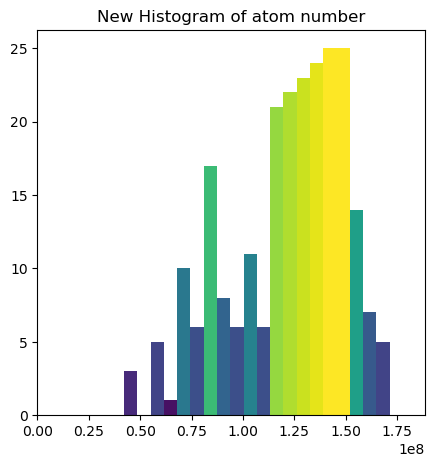

In [197]:
import matplotlib.pyplot as plt
import json
import numpy as np
from matplotlib import colors


axes = json.loads(db[f"ndscan.rid_{RID}.axes"][1])
num_axes = len(axes)

# make histogram
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
N, bins, patches = ax.hist(
    np.array(db[f"ndscan.rid_{RID}.points.channel_atom_number"][1]),
    bins=20,
)

ax.set_xlim(
    0, max(np.array(db[f"ndscan.rid_{RID}.points.channel_atom_number"][1])) * 1.1
)
ax.set_title("New Histogram of atom number")

# colour code by height
fracs = N / N.max()
norm = colors.Normalize(fracs.min(), fracs.max())

for thisfrac, thispatch in zip(fracs, patches):
    color = plt.cm.viridis(norm(thisfrac))
    thispatch.set_facecolor(color)

numbers = np.array(db[f"ndscan.rid_{RID}.points.channel_atom_number"][1])
print(f"Num points: {len(numbers)}")

# count the nummber of failed shots(atom < 30% mean )
# failed_shots = np.sum(numbers < 0.7 * np.mean(numbers))
failed_shots = 0
for i in range(len(numbers)):
    if numbers[i] < 1e8:
        failed_shots += 1
print(f"Failed shots: {failed_shots / len(numbers) * 100:.2f}%")


# atom number and uncertainty
print(
    f"Mean atom number: {np.mean(numbers) / 1e8:.2f}e8 +- {np.std(numbers) / 1e8:.2f}e8"
)
print(f"std: {np.std(numbers) / np.mean(numbers) * 100:.2f}%")

Compare with older dataset

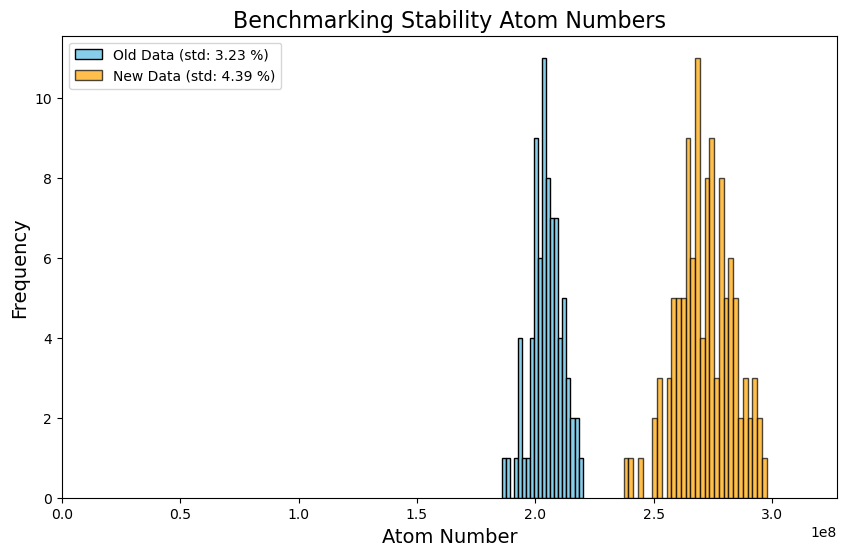

In [187]:
import pandas as pd

df_old = pd.DataFrame([
    {
        "point_index": 0,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.014000000000000002,
        "atom_number": 207274441.04191297,
        "custom_objective": -0.04864399011615728,
        "gaussian_fit_centre_x": 326.7125711244507,
        "gaussian_fit_centre_y": 317.45183575764315,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 207274441.04191297,\n            "peak_pixel": (332, 325, 3.847808664052457),\n            "centroid_pixel": (312, 329, 3.406695882629823),\n            "best_values_pixel": {\'A\': 3.5912400816727748, \'x0\': 326.7125711244507, \'y0\': 317.45183575764315, \'sx\': 60.905043582961895, \'sy\': 53.12752773592358, \'theta\': 0, \'z0\': -0.053855037439076436},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (2911040545966343.0, 2.961156035142131e-08, 7.558439350162614e-08),\n            "peak_optical_density": 3.847808664052457,\n            "Peak density (atoms/cm^3)": 2.91e+09,\n            "sigmax": 60.905043582961895,\n            "sigmay": 53.12752773592358,\n            "time_of_flight": 0.014000000000000002,\n            "sigmax_mm": 1.7305618110577277,\n            "sigmay_mm": 1.5095707220119252,\n        ',
        "peak_od": 3.847808664052457,
        "phase_space_density": 7.558439350162614e-8,
        "sigmax": 60.905043582961895,
        "sigmax_mm": 1.7305618110577277,
        "sigmay": 53.12752773592358,
        "sigmay_mm": 1.5095707220119252,
    },
    {
        "point_index": 1,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.014000000000000002,
        "atom_number": 220009680.65698248,
        "custom_objective": -0.040008336883276666,
        "gaussian_fit_centre_x": 329.2574637870509,
        "gaussian_fit_centre_y": 316.2971668051845,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 220009680.65698248,\n            "peak_pixel": (327, 326, 3.845701646330032),\n            "centroid_pixel": (310, 331, 3.288109140632662),\n            "best_values_pixel": {\'A\': 3.6441380188928405, \'x0\': 329.2574637870509, \'y0\': 316.2971668051845, \'sx\': 62.199032797879184, \'sy\': 54.44444018584884, \'theta\': 0, \'z0\': -0.019549810613261602},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (2891010149429304.0, 2.961156035142131e-08, 7.506430958319806e-08),\n            "peak_optical_density": 3.845701646330032,\n            "Peak density (atoms/cm^3)": 2.89e+09,\n            "sigmax": 62.199032797879184,\n            "sigmay": 54.44444018584884,\n            "time_of_flight": 0.014000000000000002,\n            "sigmax_mm": 1.767329346019034,\n            "sigmay_mm": 1.546989599994383,\n        ',
        "peak_od": 3.845701646330032,
        "phase_space_density": 7.506430958319806e-8,
        "sigmax": 62.199032797879184,
        "sigmax_mm": 1.767329346019034,
        "sigmay": 54.44444018584884,
        "sigmay_mm": 1.546989599994383,
    },
    {
        "point_index": 2,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.014000000000000002,
        "atom_number": 211426150.55623382,
        "custom_objective": -0.04846996780315739,
        "gaussian_fit_centre_x": 325.67813038903546,
        "gaussian_fit_centre_y": 315.7347532134045,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 211426150.55623382,\n            "peak_pixel": (318, 323, 3.836978338326389),\n            "centroid_pixel": (310, 327, 3.3467239676597917),\n            "best_values_pixel": {\'A\': 3.6149299448287167, \'x0\': 325.67813038903546, \'y0\': 315.7347532134045, \'sx\': 60.88717023852573, \'sy\': 53.85666115492944, \'theta\': 0, \'z0\': -0.05105088947061088},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (2930868417339515.0, 2.961156035142131e-08, 7.609921890804176e-08),\n            "peak_optical_density": 3.836978338326389,\n            "Peak density (atoms/cm^3)": 2.93e+09,\n            "sigmax": 60.88717023852573,\n            "sigmay": 53.85666115492944,\n            "time_of_flight": 0.014000000000000002,\n            "sigmax_mm": 1.7300539561166999,\n            "sigmay_mm": 1.5302883896444706,\n        ',
        "peak_od": 3.836978338326389,
        "phase_space_density": 7.609921890804176e-8,
        "sigmax": 60.88717023852573,
        "sigmax_mm": 1.7300539561166999,
        "sigmay": 53.85666115492944,
        "sigmay_mm": 1.5302883896444706,
    },
    {
        "point_index": 3,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.025,
        "atom_number": 209586860.10299346,
        "custom_objective": 0.665372008840947,
        "gaussian_fit_centre_x": 320.8856617764677,
        "gaussian_fit_centre_y": 240.2800521262922,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 209586860.10299346,\n            "peak_pixel": (243, 307, 2.369125266593362),\n            "centroid_pixel": (239, 322, 2.2341653551878395),\n            "best_values_pixel": {\'A\': 2.2459102738507277, \'x0\': 320.8856617764677, \'y0\': 240.2800521262922, \'sx\': 79.52324886144623, \'sy\': 65.9811309337684, \'theta\': 0, \'z0\': 0.05333477460692667},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1390223713975418.0, 2.961156035142131e-08, 3.609678896366188e-08),\n            "peak_optical_density": 2.369125266593362,\n            "Peak density (atoms/cm^3)": 1.39e+09,\n            "sigmax": 79.52324886144623,\n            "sigmay": 65.9811309337684,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2595813002481417,\n            "sigmay_mm": 1.8747942489991458,\n        ',
        "peak_od": 2.369125266593362,
        "phase_space_density": 3.609678896366188e-8,
        "sigmax": 79.52324886144623,
        "sigmax_mm": 2.2595813002481417,
        "sigmay": 65.9811309337684,
        "sigmay_mm": 1.8747942489991458,
    },
    {
        "point_index": 4,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.025,
        "atom_number": 215364559.28195125,
        "custom_objective": 0.6512779708478771,
        "gaussian_fit_centre_x": 317.717593385442,
        "gaussian_fit_centre_y": 237.967812438461,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 215364559.28195125,\n            "peak_pixel": (243, 306, 2.401899753894591),\n            "centroid_pixel": (237, 319, 2.2600015277262977),\n            "best_values_pixel": {\'A\': 2.285947682637249, \'x0\': 317.717593385442, \'y0\': 237.967812438461, \'sx\': 79.52183139579864, \'sy\': 66.5610725217151, \'theta\': 0, \'z0\': -0.027640546176769556},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1416151784165705.8, 2.961156035142131e-08, 3.6770004409841774e-08),\n            "peak_optical_density": 2.401899753894591,\n            "Peak density (atoms/cm^3)": 1.42e+09,\n            "sigmax": 79.52183139579864,\n            "sigmay": 66.5610725217151,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.259541024241855,\n            "sigmay_mm": 1.8912727654848562,\n        ',
        "peak_od": 2.401899753894591,
        "phase_space_density": 3.6770004409841774e-8,
        "sigmax": 79.52183139579864,
        "sigmax_mm": 2.259541024241855,
        "sigmay": 66.5610725217151,
        "sigmay_mm": 1.8912727654848562,
    },
    {
        "point_index": 5,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.025,
        "atom_number": 205398887.0091749,
        "custom_objective": 0.6523539403731693,
        "gaussian_fit_centre_x": 318.91801744815297,
        "gaussian_fit_centre_y": 238.86906998236614,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 205398887.0091749,\n            "peak_pixel": (260, 303, 2.3993129146437617),\n            "centroid_pixel": (238, 320, 2.2974760030840717),\n            "best_values_pixel": {\'A\': 2.248776971111727, \'x0\': 318.91801744815297, \'y0\': 238.86906998236614, \'sx\': 78.1564873501747, \'sy\': 65.66527140270264, \'theta\': 0, \'z0\': -0.0493577673278978},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1417297114372392.5, 2.961156035142131e-08, 3.6799742604025107e-08),\n            "peak_optical_density": 2.3993129146437617,\n            "Peak density (atoms/cm^3)": 1.42e+09,\n            "sigmax": 78.1564873501747,\n            "sigmay": 65.66527140270264,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2207460062054043,\n            "sigmay_mm": 1.8658193856715066,\n        ',
        "peak_od": 2.3993129146437617,
        "phase_space_density": 3.6799742604025107e-8,
        "sigmax": 78.1564873501747,
        "sigmax_mm": 2.2207460062054043,
        "sigmay": 65.66527140270264,
        "sigmay_mm": 1.8658193856715066,
    },
    {
        "point_index": 6,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.015,
        "atom_number": 199911405.91517842,
        "custom_objective": 0.08028266235575234,
        "gaussian_fit_centre_x": 326.852658389346,
        "gaussian_fit_centre_y": 309.5758143684085,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 199911405.91517842,\n            "peak_pixel": (306, 320, 3.5005480973716745),\n            "centroid_pixel": (304, 329, 3.1536394055613584),\n            "best_values_pixel": {\'A\': 3.2570372992365066, \'x0\': 326.852658389346, \'y0\': 309.5758143684085, \'sx\': 63.08941228458413, \'sy\': 54.559747651599274, \'theta\': 0, \'z0\': -0.006200493673385139},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (2547891219661458.0, 2.961156035142131e-08, 6.615531783405685e-08),\n            "peak_optical_density": 3.5005480973716745,\n            "Peak density (atoms/cm^3)": 2.55e+09,\n            "sigmax": 63.08941228458413,\n            "sigmay": 54.559747651599274,\n            "time_of_flight": 0.015,\n            "sigmax_mm": 1.7926286750465532,\n            "sigmay_mm": 1.5502659575013888,\n        ',
        "peak_od": 3.5005480973716745,
        "phase_space_density": 6.615531783405685e-8,
        "sigmax": 63.08941228458413,
        "sigmax_mm": 1.7926286750465532,
        "sigmay": 54.559747651599274,
        "sigmay_mm": 1.5502659575013888,
    },
    {
        "point_index": 7,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.015,
        "atom_number": 212628221.91963705,
        "custom_objective": 0.001872160201490905,
        "gaussian_fit_centre_x": 325.8303518028859,
        "gaussian_fit_centre_y": 311.39910411117773,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 212628221.91963705,\n            "peak_pixel": (318, 323, 3.674762673713081),\n            "centroid_pixel": (306, 328, 3.3893527525648133),\n            "best_values_pixel": {\'A\': 3.5032913362408253, \'x0\': 325.8303518028859, \'y0\': 311.39910411117773, \'sx\': 62.655313952971945, \'sy\': 54.328074700025425, \'theta\': 0, \'z0\': -0.057248252171934626},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (2759366560784416.0, 2.961156035142131e-08, 7.164621881840648e-08),\n            "peak_optical_density": 3.674762673713081,\n            "Peak density (atoms/cm^3)": 2.76e+09,\n            "sigmax": 62.655313952971945,\n            "sigmay": 54.328074700025425,\n            "time_of_flight": 0.015,\n            "sigmax_mm": 1.7802941629809206,\n            "sigmay_mm": 1.5436831798024844,\n        ',
        "peak_od": 3.674762673713081,
        "phase_space_density": 7.164621881840648e-8,
        "sigmax": 62.655313952971945,
        "sigmax_mm": 1.7802941629809206,
        "sigmay": 54.328074700025425,
        "sigmay_mm": 1.5436831798024844,
    },
    {
        "point_index": 8,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.015,
        "atom_number": 211800635.43009198,
        "custom_objective": 0.0013704082446174826,
        "gaussian_fit_centre_x": 326.71352205535294,
        "gaussian_fit_centre_y": 312.6242151690433,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 211800635.43009198,\n            "peak_pixel": (327, 327, 3.713957358365771),\n            "centroid_pixel": (307, 328, 3.4047628937958887),\n            "best_values_pixel": {\'A\': 3.501525148567641, \'x0\': 326.71352205535294, \'y0\': 312.6242151690433, \'sx\': 62.86006528222663, \'sy\': 53.99244892724561, \'theta\': 0, \'z0\': -0.06242237513661493},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (2747724602208527.0, 2.961156035142131e-08, 7.134393846049497e-08),\n            "peak_optical_density": 3.713957358365771,\n            "Peak density (atoms/cm^3)": 2.75e+09,\n            "sigmax": 62.86006528222663,\n            "sigmay": 53.99244892724561,\n            "time_of_flight": 0.015,\n            "sigmax_mm": 1.7861119870941045,\n            "sigmay_mm": 1.5341466765671108,\n        ',
        "peak_od": 3.713957358365771,
        "phase_space_density": 7.134393846049497e-8,
        "sigmax": 62.86006528222663,
        "sigmax_mm": 1.7861119870941045,
        "sigmay": 53.99244892724561,
        "sigmay_mm": 1.5341466765671108,
    },
    {
        "point_index": 9,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.008,
        "atom_number": 213953491.79890394,
        "custom_objective": -0.32826971883353817,
        "gaussian_fit_centre_x": 331.52629690466216,
        "gaussian_fit_centre_y": 343.71704760760105,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 213953491.79890394,\n            "peak_pixel": (373, 320, 4.240609480384498),\n            "centroid_pixel": (337, 335, 4.027141113112998),\n            "best_values_pixel": {\'A\': 4.379182566875962, \'x0\': 331.52629690466216, \'y0\': 343.71704760760105, \'sx\': 55.05664917124893, \'sy\': 49.81791710581434, \'theta\': 0, \'z0\': 0.05459919483067388},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (3921415725294806.0, 2.961156035142131e-08, 1.0181851629474838e-07),\n            "peak_optical_density": 4.240609480384498,\n            "Peak density (atoms/cm^3)": 3.92e+09,\n            "sigmax": 55.05664917124893,\n            "sigmay": 49.81791710581434,\n            "time_of_flight": 0.008,\n            "sigmax_mm": 1.5643849654385706,\n            "sigmay_mm": 1.415531124812786,\n        ',
        "peak_od": 4.240609480384498,
        "phase_space_density": 1.0181851629474838e-7,
        "sigmax": 55.05664917124893,
        "sigmax_mm": 1.5643849654385706,
        "sigmay": 49.81791710581434,
        "sigmay_mm": 1.415531124812786,
    },
    {
        "point_index": 10,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.008,
        "atom_number": 206215728.61641526,
        "custom_objective": -0.2995192927773927,
        "gaussian_fit_centre_x": 333.0739587529007,
        "gaussian_fit_centre_y": 343.06326511049093,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 206215728.61641526,\n            "peak_pixel": (336, 324, 4.116828369194904),\n            "centroid_pixel": (337, 336, 3.973825742836633),\n            "best_values_pixel": {\'A\': 4.242126387196671, \'x0\': 333.0739587529007, \'y0\': 343.06326511049093, \'sx\': 54.469869213856875, \'sy\': 50.08388953524212, \'theta\': 0, \'z0\': -0.011310329467380018},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (3840959236844333.0, 2.961156035142131e-08, 9.972948497183326e-08),\n            "peak_optical_density": 4.116828369194904,\n            "Peak density (atoms/cm^3)": 3.84e+09,\n            "sigmax": 54.469869213856875,\n            "sigmay": 50.08388953524212,\n            "time_of_flight": 0.008,\n            "sigmax_mm": 1.5477121428606908,\n            "sigmay_mm": 1.423088491199611,\n        ',
        "peak_od": 4.116828369194904,
        "phase_space_density": 9.972948497183326e-8,
        "sigmax": 54.469869213856875,
        "sigmax_mm": 1.5477121428606908,
        "sigmay": 50.08388953524212,
        "sigmay_mm": 1.423088491199611,
    },
    {
        "point_index": 11,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.008,
        "atom_number": 201083417.62801084,
        "custom_objective": -0.30037173030049097,
        "gaussian_fit_centre_x": 330.9170218147832,
        "gaussian_fit_centre_y": 340.38301442825605,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 201083417.62801084,\n            "peak_pixel": (339, 331, 4.147800755505207),\n            "centroid_pixel": (335, 334, 3.731784413363876),\n            "best_values_pixel": {\'A\': 4.203446207230992, \'x0\': 330.9170218147832, \'y0\': 340.38301442825605, \'sx\': 54.141552457810874, \'sy\': 49.5199105557539, \'theta\': 0, \'z0\': -0.036133589714466764},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (3834101645941266.0, 2.961156035142131e-08, 9.955142944800733e-08),\n            "peak_optical_density": 4.147800755505207,\n            "Peak density (atoms/cm^3)": 3.83e+09,\n            "sigmax": 54.141552457810874,\n            "sigmay": 49.5199105557539,\n            "time_of_flight": 0.008,\n            "sigmax_mm": 1.5383833187351548,\n            "sigmay_mm": 1.4070635378176768,\n        ',
        "peak_od": 4.147800755505207,
        "phase_space_density": 9.955142944800733e-8,
        "sigmax": 54.141552457810874,
        "sigmax_mm": 1.5383833187351548,
        "sigmay": 49.5199105557539,
        "sigmay_mm": 1.4070635378176768,
    },
    {
        "point_index": 12,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.009000000000000001,
        "atom_number": 194116907.58836988,
        "custom_objective": -0.24275340078054658,
        "gaussian_fit_centre_x": 330.73695706026894,
        "gaussian_fit_centre_y": 338.2096103995747,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 194116907.58836988,\n            "peak_pixel": (340, 315, 4.054133850881358),\n            "centroid_pixel": (333, 334, 3.4837729408472122),\n            "best_values_pixel": {\'A\': 3.998805756227509, \'x0\': 330.73695706026894, \'y0\': 338.2096103995747, \'sx\': 54.73910223476175, \'sy\': 49.71489253671896, \'theta\': 0, \'z0\': -0.053246574198482374},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (3606701027269251.0, 2.961156035142131e-08, 9.364703286787892e-08),\n            "peak_optical_density": 4.054133850881358,\n            "Peak density (atoms/cm^3)": 3.61e+09,\n            "sigmax": 54.73910223476175,\n            "sigmay": 49.71489253671896,\n            "time_of_flight": 0.009000000000000001,\n            "sigmax_mm": 1.5553621560097501,\n            "sigmay_mm": 1.4126037747217501,\n        ',
        "peak_od": 4.054133850881358,
        "phase_space_density": 9.364703286787892e-8,
        "sigmax": 54.73910223476175,
        "sigmax_mm": 1.5553621560097501,
        "sigmay": 49.71489253671896,
        "sigmay_mm": 1.4126037747217501,
    },
    {
        "point_index": 13,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.009000000000000001,
        "atom_number": 199898003.24541315,
        "custom_objective": -0.2340860407435671,
        "gaussian_fit_centre_x": 332.2007542796855,
        "gaussian_fit_centre_y": 338.75046291525115,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 199898003.24541315,\n            "peak_pixel": (353, 310, 4.061319772682703),\n            "centroid_pixel": (333, 336, 3.433968603267188),\n            "best_values_pixel": {\'A\': 4.019128476113976, \'x0\': 332.2007542796855, \'y0\': 338.75046291525115, \'sx\': 55.67199764513741, \'sy\': 50.13644725387395, \'theta\': 0, \'z0\': 0.01600973886010719},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (3560491185898597.0, 2.961156035142131e-08, 9.244720662751723e-08),\n            "peak_optical_density": 4.061319772682703,\n            "Peak density (atoms/cm^3)": 3.56e+09,\n            "sigmax": 55.67199764513741,\n            "sigmay": 50.13644725387395,\n            "time_of_flight": 0.009000000000000001,\n            "sigmax_mm": 1.581869536612935,\n            "sigmay_mm": 1.4245818713105154,\n        ',
        "peak_od": 4.061319772682703,
        "phase_space_density": 9.244720662751723e-8,
        "sigmax": 55.67199764513741,
        "sigmax_mm": 1.581869536612935,
        "sigmay": 50.13644725387395,
        "sigmay_mm": 1.4245818713105154,
    },
    {
        "point_index": 14,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.009000000000000001,
        "atom_number": 202707662.15224934,
        "custom_objective": -0.2548150705382578,
        "gaussian_fit_centre_x": 327.45036851620375,
        "gaussian_fit_centre_y": 336.700349363257,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 202707662.15224934,\n            "peak_pixel": (342, 318, 4.103290096017483),\n            "centroid_pixel": (331, 330, 3.4052389884340144),\n            "best_values_pixel": {\'A\': 4.087025872984244, \'x0\': 327.45036851620375, \'y0\': 336.700349363257, \'sx\': 55.18285494899145, \'sy\': 50.35303656398233, \'theta\': 0, \'z0\': -0.07143308093565963},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (3659020082595911.0, 2.961156035142131e-08, 9.500548322368833e-08),\n            "peak_optical_density": 4.103290096017483,\n            "Peak density (atoms/cm^3)": 3.66e+09,\n            "sigmax": 55.18285494899145,\n            "sigmay": 50.35303656398233,\n            "time_of_flight": 0.009000000000000001,\n            "sigmax_mm": 1.5679709886387436,\n            "sigmay_mm": 1.4307360609589692,\n        ',
        "peak_od": 4.103290096017483,
        "phase_space_density": 9.500548322368833e-8,
        "sigmax": 55.18285494899145,
        "sigmax_mm": 1.5679709886387436,
        "sigmay": 50.35303656398233,
        "sigmay_mm": 1.4307360609589692,
    },
    {
        "point_index": 15,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.018000000000000002,
        "atom_number": 204105337.55452642,
        "custom_objective": 0.23935145521536483,
        "gaussian_fit_centre_x": 322.886886102375,
        "gaussian_fit_centre_y": 293.267499617065,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 204105337.55452642,\n            "peak_pixel": (303, 310, 3.2532979737282783),\n            "centroid_pixel": (288, 324, 2.8690187623689534),\n            "best_values_pixel": {\'A\': 2.9498261379097155, \'x0\': 322.886886102375, \'y0\': 293.267499617065, \'sx\': 67.09375014789258, \'sy\': 57.83797679662477, \'theta\': 0, \'z0\': -0.05605640057306947},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (2169730332408518.0, 2.961156035142131e-08, 5.6336470979224774e-08),\n            "peak_optical_density": 3.2532979737282783,\n            "Peak density (atoms/cm^3)": 2.17e+09,\n            "sigmax": 67.09375014789258,\n            "sigmay": 57.83797679662477,\n            "time_of_flight": 0.018000000000000002,\n            "sigmax_mm": 1.9064083191802075,\n            "sigmay_mm": 1.6434138781419814,\n        ',
        "peak_od": 3.2532979737282783,
        "phase_space_density": 5.6336470979224774e-8,
        "sigmax": 67.09375014789258,
        "sigmax_mm": 1.9064083191802075,
        "sigmay": 57.83797679662477,
        "sigmay_mm": 1.6434138781419814,
    },
    {
        "point_index": 16,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.018000000000000002,
        "atom_number": 206408741.47884417,
        "custom_objective": 0.22378293739823485,
        "gaussian_fit_centre_x": 325.9125875147278,
        "gaussian_fit_centre_y": 293.07510739371065,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 206408741.47884417,\n            "peak_pixel": (301, 311, 3.2878563786952126),\n            "centroid_pixel": (288, 328, 2.915843063773243),\n            "best_values_pixel": {\'A\': 2.9923602226174246, \'x0\': 325.9125875147278, \'y0\': 293.07510739371065, \'sx\': 67.2409257287633, \'sy\': 57.54440150069822, \'theta\': 0, \'z0\': -0.017922812384288563},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (2195767060283494.8, 2.961156035142131e-08, 5.7012507693287e-08),\n            "peak_optical_density": 3.2878563786952126,\n            "Peak density (atoms/cm^3)": 2.20e+09,\n            "sigmax": 67.2409257287633,\n            "sigmay": 57.54440150069822,\n            "time_of_flight": 0.018000000000000002,\n            "sigmax_mm": 1.9105901803987808,\n            "sigmay_mm": 1.6350722012312928,\n        ',
        "peak_od": 3.2878563786952126,
        "phase_space_density": 5.7012507693287e-8,
        "sigmax": 67.2409257287633,
        "sigmax_mm": 1.9105901803987808,
        "sigmay": 57.54440150069822,
        "sigmay_mm": 1.6350722012312928,
    },
    {
        "point_index": 17,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.018000000000000002,
        "atom_number": 188740184.7418177,
        "custom_objective": 0.27211616710410746,
        "gaussian_fit_centre_x": 325.4316629866971,
        "gaussian_fit_centre_y": 293.9754454287488,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 188740184.7418177,\n            "peak_pixel": (303, 310, 3.07260289633339),\n            "centroid_pixel": (289, 327, 2.6841863666217933),\n            "best_values_pixel": {\'A\': 2.811017740383269, \'x0\': 325.4316629866971, \'y0\': 293.9754454287488, \'sx\': 66.42664429857923, \'sy\': 56.673392570841905, \'theta\': 0, \'z0\': -0.05752804555428612},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (2088955376035904.0, 2.961156035142131e-08, 5.423917072141691e-08),\n            "peak_optical_density": 3.07260289633339,\n            "Peak density (atoms/cm^3)": 2.09e+09,\n            "sigmax": 66.42664429857923,\n            "sigmay": 56.673392570841905,\n            "time_of_flight": 0.018000000000000002,\n            "sigmax_mm": 1.8874531089243876,\n            "sigmay_mm": 1.6103232690833933,\n        ',
        "peak_od": 3.07260289633339,
        "phase_space_density": 5.423917072141691e-8,
        "sigmax": 66.42664429857923,
        "sigmax_mm": 1.8874531089243876,
        "sigmay": 56.673392570841905,
        "sigmay_mm": 1.6103232690833933,
    },
    {
        "point_index": 18,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.027,
        "atom_number": 203170027.1902315,
        "custom_objective": 0.8239545788752765,
        "gaussian_fit_centre_x": 319.6441955933736,
        "gaussian_fit_centre_y": 221.57645727778717,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 203170027.1902315,\n            "peak_pixel": (213, 319, 2.153943155484087),\n            "centroid_pixel": (224, 320, 1.9697512817997795),\n            "best_values_pixel": {\'A\': 1.9984143726531014, \'x0\': 319.6441955933736, \'y0\': 221.57645727778717, \'sx\': 83.59851842606624, \'sy\': 68.33240463663329, \'theta\': 0, \'z0\': 0.04204713668427208},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1177509442562134.0, 2.961156035142131e-08, 3.057371948385284e-08),\n            "peak_optical_density": 2.153943155484087,\n            "Peak density (atoms/cm^3)": 1.18e+09,\n            "sigmax": 83.59851842606624,\n            "sigmay": 68.33240463663329,\n            "time_of_flight": 0.027,\n            "sigmax_mm": 2.3753764046173003,\n            "sigmay_mm": 1.9416035678690953,\n        ',
        "peak_od": 2.153943155484087,
        "phase_space_density": 3.057371948385284e-8,
        "sigmax": 83.59851842606624,
        "sigmax_mm": 2.3753764046173003,
        "sigmay": 68.33240463663329,
        "sigmay_mm": 1.9416035678690953,
    },
    {
        "point_index": 19,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.027,
        "atom_number": 200592583.51983953,
        "custom_objective": 0.8120307831765445,
        "gaussian_fit_centre_x": 317.47184076729496,
        "gaussian_fit_centre_y": 220.57323715990208,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 200592583.51983953,\n            "peak_pixel": (214, 319, 2.201199366781981),\n            "centroid_pixel": (222, 319, 2.074103128693459),\n            "best_values_pixel": {\'A\': 2.0031371513977874, \'x0\': 317.47184076729496, \'y0\': 220.57323715990208, \'sx\': 81.96960492421115, \'sy\': 68.55255393021211, \'theta\': 0, \'z0\': -0.0360920673894918},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1205352780754849.8, 2.961156035142131e-08, 3.1296664354295536e-08),\n            "peak_optical_density": 2.201199366781981,\n            "Peak density (atoms/cm^3)": 1.21e+09,\n            "sigmax": 81.96960492421115,\n            "sigmay": 68.55255393021211,\n            "time_of_flight": 0.027,\n            "sigmax_mm": 2.329092298507321,\n            "sigmay_mm": 1.947858911232899,\n        ',
        "peak_od": 2.201199366781981,
        "phase_space_density": 3.1296664354295536e-8,
        "sigmax": 81.96960492421115,
        "sigmax_mm": 2.329092298507321,
        "sigmay": 68.55255393021211,
        "sigmay_mm": 1.947858911232899,
    },
    {
        "point_index": 20,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.027,
        "atom_number": 200899567.60098684,
        "custom_objective": 0.8077459018511909,
        "gaussian_fit_centre_x": 317.5875642002509,
        "gaussian_fit_centre_y": 220.8566639189951,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 200899567.60098684,\n            "peak_pixel": (215, 320, 2.1828190517784334),\n            "centroid_pixel": (222, 319, 2.0841704470855342),\n            "best_values_pixel": {\'A\': 2.011073532382725, \'x0\': 317.5875642002509, \'y0\': 220.8566639189951, \'sx\': 82.32153344865598, \'sy\': 68.13420337675066, \'theta\': 0, \'z0\': -0.01559867886212722},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1204246911810359.2, 2.961156035142131e-08, 3.1267950761289274e-08),\n            "peak_optical_density": 2.1828190517784334,\n            "Peak density (atoms/cm^3)": 1.20e+09,\n            "sigmax": 82.32153344865598,\n            "sigmay": 68.13420337675066,\n            "time_of_flight": 0.027,\n            "sigmax_mm": 2.3390920297085067,\n            "sigmay_mm": 1.9359718580618577,\n        ',
        "peak_od": 2.1828190517784334,
        "phase_space_density": 3.1267950761289274e-8,
        "sigmax": 82.32153344865598,
        "sigmax_mm": 2.3390920297085067,
        "sigmay": 68.13420337675066,
        "sigmay_mm": 1.9359718580618577,
    },
    {
        "point_index": 21,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.03,
        "atom_number": 185748906.77618873,
        "custom_objective": 1.0543710391738685,
        "gaussian_fit_centre_x": 315.1272221033492,
        "gaussian_fit_centre_y": 190.7457022722791,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 185748906.77618873,\n            "peak_pixel": (191, 316, 1.785807754503667),\n            "centroid_pixel": (200, 316, 1.708514471844236),\n            "best_values_pixel": {\'A\': 1.6814742590109943, \'x0\': 315.1272221033492, \'y0\': 190.7457022722791, \'sx\': 87.44238216705111, \'sy\': 71.7563138656054, \'theta\': 0, \'z0\': -0.025464975708352794},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (937024205354867.6, 2.961156035142131e-08, 2.43295842636847e-08),\n            "peak_optical_density": 1.785807754503667,\n            "Peak density (atoms/cm^3)": 9.37e+08,\n            "sigmax": 87.44238216705111,\n            "sigmay": 71.7563138656054,\n            "time_of_flight": 0.03,\n            "sigmax_mm": 2.4845963214866944,\n            "sigmay_mm": 2.0388908565337216,\n        ',
        "peak_od": 1.785807754503667,
        "phase_space_density": 2.43295842636847e-8,
        "sigmax": 87.44238216705111,
        "sigmax_mm": 2.4845963214866944,
        "sigmay": 71.7563138656054,
        "sigmay_mm": 2.0388908565337216,
    },
    {
        "point_index": 22,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.03,
        "atom_number": 202864595.90002632,
        "custom_objective": 0.9577528675773627,
        "gaussian_fit_centre_x": 314.96509601693225,
        "gaussian_fit_centre_y": 191.0968325710967,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 202864595.90002632,\n            "peak_pixel": (192, 317, 1.9480800328411174),\n            "centroid_pixel": (200, 315, 1.841372983213017),\n            "best_values_pixel": {\'A\': 1.843035107908431, \'x0\': 314.96509601693225, \'y0\': 191.0968325710967, \'sx\': 87.15621749786376, \'sy\': 71.58629690167605, \'theta\': 0, \'z0\': -0.055941478897340406},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1032543221722765.8, 2.961156035142131e-08, 2.6809710117666177e-08),\n            "peak_optical_density": 1.9480800328411174,\n            "Peak density (atoms/cm^3)": 1.03e+09,\n            "sigmax": 87.15621749786376,\n            "sigmay": 71.58629690167605,\n            "time_of_flight": 0.03,\n            "sigmax_mm": 2.476465210842384,\n            "sigmay_mm": 2.034059978043218,\n        ',
        "peak_od": 1.9480800328411174,
        "phase_space_density": 2.6809710117666177e-8,
        "sigmax": 87.15621749786376,
        "sigmax_mm": 2.476465210842384,
        "sigmay": 71.58629690167605,
        "sigmay_mm": 2.034059978043218,
    },
    {
        "point_index": 23,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.03,
        "atom_number": 197947443.10915264,
        "custom_objective": 0.9898587606942614,
        "gaussian_fit_centre_x": 313.13868347201947,
        "gaussian_fit_centre_y": 191.73022404756142,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 197947443.10915264,\n            "peak_pixel": (196, 305, 1.9082514989944364),\n            "centroid_pixel": (200, 314, 1.7578228132284495),\n            "best_values_pixel": {\'A\': 1.788984547677912, \'x0\': 313.13868347201947, \'y0\': 191.73022404756142, \'sx\': 87.54298716568252, \'sy\': 71.63054825373055, \'theta\': 0, \'z0\': -0.01797587789341655},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (998016043871343.4, 2.961156035142131e-08, 2.5913221128243246e-08),\n            "peak_optical_density": 1.9082514989944364,\n            "Peak density (atoms/cm^3)": 9.98e+08,\n            "sigmax": 87.54298716568252,\n            "sigmay": 71.63054825373055,\n            "time_of_flight": 0.03,\n            "sigmax_mm": 2.4874549216680713,\n            "sigmay_mm": 2.0353173402491715,\n        ',
        "peak_od": 1.9082514989944364,
        "phase_space_density": 2.5913221128243246e-8,
        "sigmax": 87.54298716568252,
        "sigmax_mm": 2.4874549216680713,
        "sigmay": 71.63054825373055,
        "sigmay_mm": 2.0353173402491715,
    },
    {
        "point_index": 24,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.021,
        "atom_number": 206006330.5684277,
        "custom_objective": 0.3979007793221968,
        "gaussian_fit_centre_x": 321.87487254852283,
        "gaussian_fit_centre_y": 272.57067806102754,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 206006330.5684277,\n            "peak_pixel": (261, 314, 2.8284033193135065),\n            "centroid_pixel": (268, 323, 2.7138399246791285),\n            "best_values_pixel": {\'A\': 2.6661515191994183, \'x0\': 321.87487254852283, \'y0\': 272.57067806102754, \'sx\': 71.60659309942217, \'sy\': 60.60814830754638, \'theta\': 0, \'z0\': -0.017629927397317422},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1834729961697391.5, 2.961156035142131e-08, 4.763827545662858e-08),\n            "peak_optical_density": 2.8284033193135065,\n            "Peak density (atoms/cm^3)": 1.83e+09,\n            "sigmax": 71.60659309942217,\n            "sigmay": 60.60814830754638,\n            "time_of_flight": 0.021,\n            "sigmax_mm": 2.0346366761730086,\n            "sigmay_mm": 1.72212579992808,\n        ',
        "peak_od": 2.8284033193135065,
        "phase_space_density": 4.763827545662858e-8,
        "sigmax": 71.60659309942217,
        "sigmax_mm": 2.0346366761730086,
        "sigmay": 60.60814830754638,
        "sigmay_mm": 1.72212579992808,
    },
    {
        "point_index": 25,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.021,
        "atom_number": 200436769.6308567,
        "custom_objective": 0.4259981157532802,
        "gaussian_fit_centre_x": 324.8085116663126,
        "gaussian_fit_centre_y": 272.5878994010496,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 200436769.6308567,\n            "peak_pixel": (276, 326, 2.746717246174463),\n            "centroid_pixel": (268, 326, 2.578569464360853),\n            "best_values_pixel": {\'A\': 2.591820557534852, \'x0\': 324.8085116663126, \'y0\': 272.5878994010496, \'sx\': 71.60769361422719, \'sy\': 60.635073096154926, \'theta\': 0, \'z0\': 0.0054664753614276805},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1784278911646469.2, 2.961156035142131e-08, 4.632832736095433e-08),\n            "peak_optical_density": 2.746717246174463,\n            "Peak density (atoms/cm^3)": 1.78e+09,\n            "sigmax": 71.60769361422719,\n            "sigmay": 60.635073096154926,\n            "time_of_flight": 0.021,\n            "sigmax_mm": 2.0346679463073363,\n            "sigmay_mm": 1.7228908434810537,\n        ',
        "peak_od": 2.746717246174463,
        "phase_space_density": 4.632832736095433e-8,
        "sigmax": 71.60769361422719,
        "sigmax_mm": 2.0346679463073363,
        "sigmay": 60.635073096154926,
        "sigmay_mm": 1.7228908434810537,
    },
    {
        "point_index": 26,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.021,
        "atom_number": 192377267.72337466,
        "custom_objective": 0.45757251408464494,
        "gaussian_fit_centre_x": 321.2644049751723,
        "gaussian_fit_centre_y": 271.7309991171717,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 192377267.72337466,\n            "peak_pixel": (275, 324, 2.668866593349336),\n            "centroid_pixel": (267, 322, 2.564558240450918),\n            "best_values_pixel": {\'A\': 2.502634300226599, \'x0\': 321.2644049751723, \'y0\': 271.7309991171717, \'sx\': 71.08497321227439, \'sy\': 60.696700547124806, \'theta\': 0, \'z0\': -0.06166605627045246},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1736047827340919.5, 2.961156035142131e-08, 4.5076020085395366e-08),\n            "peak_optical_density": 2.668866593349336,\n            "Peak density (atoms/cm^3)": 1.74e+09,\n            "sigmax": 71.08497321227439,\n            "sigmay": 60.696700547124806,\n            "time_of_flight": 0.021,\n            "sigmax_mm": 2.0198153181461223,\n            "sigmay_mm": 1.7246419318456165,\n        ',
        "peak_od": 2.668866593349336,
        "phase_space_density": 4.5076020085395366e-8,
        "sigmax": 71.08497321227439,
        "sigmax_mm": 2.0198153181461223,
        "sigmay": 60.696700547124806,
        "sigmay_mm": 1.7246419318456165,
    },
    {
        "point_index": 27,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.022000000000000002,
        "atom_number": 209207574.34197834,
        "custom_objective": 0.4568229829943454,
        "gaussian_fit_centre_x": 322.16615726605426,
        "gaussian_fit_centre_y": 265.9722661000935,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 209207574.34197834,\n            "peak_pixel": (272, 314, 2.7280702477134886),\n            "centroid_pixel": (262, 324, 2.4971143408895453),\n            "best_values_pixel": {\'A\': 2.5762722898217865, \'x0\': 322.16615726605426, \'y0\': 265.9722661000935, \'sx\': 73.53268620225295, \'sy\': 62.019445556458535, \'theta\': 0, \'z0\': -0.029633950063544977},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1726701582785467.8, 2.961156035142131e-08, 4.483334733141379e-08),\n            "peak_optical_density": 2.7280702477134886,\n            "Peak density (atoms/cm^3)": 1.73e+09,\n            "sigmax": 73.53268620225295,\n            "sigmay": 62.019445556458535,\n            "time_of_flight": 0.022000000000000002,\n            "sigmax_mm": 2.0893648722666582,\n            "sigmay_mm": 1.7622265367363767,\n        ',
        "peak_od": 2.7280702477134886,
        "phase_space_density": 4.483334733141379e-8,
        "sigmax": 73.53268620225295,
        "sigmax_mm": 2.0893648722666582,
        "sigmay": 62.019445556458535,
        "sigmay_mm": 1.7622265367363767,
    },
    {
        "point_index": 28,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.022000000000000002,
        "atom_number": 210476066.1192923,
        "custom_objective": 0.454708352474405,
        "gaussian_fit_centre_x": 320.9833242698213,
        "gaussian_fit_centre_y": 265.47928933341956,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 210476066.1192923,\n            "peak_pixel": (260, 303, 2.808785122566753),\n            "centroid_pixel": (261, 322, 2.5589672701910624),\n            "best_values_pixel": {\'A\': 2.5856629960532485, \'x0\': 320.9833242698213, \'y0\': 265.47928933341956, \'sx\': 73.81000158143806, \'sy\': 61.94853739946329, \'theta\': 0, \'z0\': -0.02941286017807742},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1726115517135572.0, 2.961156035142131e-08, 4.4818130292695146e-08),\n            "peak_optical_density": 2.808785122566753,\n            "Peak density (atoms/cm^3)": 1.73e+09,\n            "sigmax": 73.81000158143806,\n            "sigmay": 61.94853739946329,\n            "time_of_flight": 0.022000000000000002,\n            "sigmax_mm": 2.097244538327205,\n            "sigmay_mm": 1.7602117454913577,\n        ',
        "peak_od": 2.808785122566753,
        "phase_space_density": 4.4818130292695146e-8,
        "sigmax": 73.81000158143806,
        "sigmax_mm": 2.097244538327205,
        "sigmay": 61.94853739946329,
        "sigmay_mm": 1.7602117454913577,
    },
    {
        "point_index": 29,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.022000000000000002,
        "atom_number": 211712602.79444593,
        "custom_objective": 0.4478151951724539,
        "gaussian_fit_centre_x": 320.0960411393895,
        "gaussian_fit_centre_y": 264.8034116607763,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 211712602.79444593,\n            "peak_pixel": (261, 314, 2.77688478764304),\n            "centroid_pixel": (261, 321, 2.6420732869748194),\n            "best_values_pixel": {\'A\': 2.603143456821412, \'x0\': 320.0960411393895, \'y0\': 264.8034116607763, \'sx\': 73.2401513118481, \'sy\': 62.38745377219176, \'theta\': 0, \'z0\': -0.038766750163340136},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1750973646751368.8, 2.961156035142131e-08, 4.546356501643964e-08),\n            "peak_optical_density": 2.77688478764304,\n            "Peak density (atoms/cm^3)": 1.75e+09,\n            "sigmax": 73.2401513118481,\n            "sigmay": 62.38745377219176,\n            "time_of_flight": 0.022000000000000002,\n            "sigmax_mm": 2.081052757539296,\n            "sigmay_mm": 1.772683157844215,\n        ',
        "peak_od": 2.77688478764304,
        "phase_space_density": 4.546356501643964e-8,
        "sigmax": 73.2401513118481,
        "sigmax_mm": 2.081052757539296,
        "sigmay": 62.38745377219176,
        "sigmay_mm": 1.772683157844215,
    },
    {
        "point_index": 30,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.012,
        "atom_number": 210699554.86437273,
        "custom_objective": -0.1417312854637232,
        "gaussian_fit_centre_x": 327.1918848276508,
        "gaussian_fit_centre_y": 326.1208441276639,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 210699554.86437273,\n            "peak_pixel": (327, 327, 4.024688927200267),\n            "centroid_pixel": (321, 330, 3.5452132252332844),\n            "best_values_pixel": {\'A\': 3.8387148285501462, \'x0\': 327.1918848276508, \'y0\': 326.1208441276639, \'sx\': 58.125089715527544, \'sy\': 52.893577263494066, \'theta\': 0, \'z0\': -0.08029735106442105},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (3263337794920591.0, 2.961156035142131e-08, 8.473169786720612e-08),\n            "peak_optical_density": 4.024688927200267,\n            "Peak density (atoms/cm^3)": 3.26e+09,\n            "sigmax": 58.125089715527544,\n            "sigmay": 52.893577263494066,\n            "time_of_flight": 0.012,\n            "sigmax_mm": 1.6515719324456064,\n            "sigmay_mm": 1.502923230614699,\n        ',
        "peak_od": 4.024688927200267,
        "phase_space_density": 8.473169786720612e-8,
        "sigmax": 58.125089715527544,
        "sigmax_mm": 1.6515719324456064,
        "sigmay": 52.893577263494066,
        "sigmay_mm": 1.502923230614699,
    },
    {
        "point_index": 31,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.012,
        "atom_number": 213631140.79349473,
        "custom_objective": -0.13969633318025143,
        "gaussian_fit_centre_x": 328.29627815410504,
        "gaussian_fit_centre_y": 325.4315326536154,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 213631140.79349473,\n            "peak_pixel": (328, 326, 4.010002678079713),\n            "centroid_pixel": (320, 331, 3.596514589636417),\n            "best_values_pixel": {\'A\': 3.854011889054742, \'x0\': 328.29627815410504, \'y0\': 325.4315326536154, \'sx\': 58.862349379592665, \'sy\': 52.78600453413845, \'theta\': 0, \'z0\': -0.04091920943066421},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (3232951650817515.0, 2.961156035142131e-08, 8.394272971763278e-08),\n            "peak_optical_density": 4.010002678079713,\n            "Peak density (atoms/cm^3)": 3.23e+09,\n            "sigmax": 58.862349379592665,\n            "sigmay": 52.78600453413845,\n            "time_of_flight": 0.012,\n            "sigmax_mm": 1.672520499992831,\n            "sigmay_mm": 1.4998666486572376,\n        ',
        "peak_od": 4.010002678079713,
        "phase_space_density": 8.394272971763278e-8,
        "sigmax": 58.862349379592665,
        "sigmax_mm": 1.672520499992831,
        "sigmay": 52.78600453413845,
        "sigmay_mm": 1.4998666486572376,
    },
    {
        "point_index": 32,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.012,
        "atom_number": 217152111.6700124,
        "custom_objective": -0.17793681457893631,
        "gaussian_fit_centre_x": 329.1531100983083,
        "gaussian_fit_centre_y": 327.23397830928263,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 217152111.6700124,\n            "peak_pixel": (332, 325, 4.065323708307435),\n            "centroid_pixel": (322, 332, 3.863235675949224),\n            "best_values_pixel": {\'A\': 3.9749530400031112, \'x0\': 329.1531100983083, \'y0\': 327.23397830928263, \'sx\': 59.154734734446706, \'sy\': 51.764034325754494, \'theta\': 0, \'z0\': -0.05993945369480529},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (3318069994178781.5, 2.961156035142131e-08, 8.615280486335316e-08),\n            "peak_optical_density": 4.065323708307435,\n            "Peak density (atoms/cm^3)": 3.32e+09,\n            "sigmax": 59.154734734446706,\n            "sigmay": 51.764034325754494,\n            "time_of_flight": 0.012,\n            "sigmax_mm": 1.6808283658025605,\n            "sigmay_mm": 1.4708282881106451,\n        ',
        "peak_od": 4.065323708307435,
        "phase_space_density": 8.615280486335316e-8,
        "sigmax": 59.154734734446706,
        "sigmax_mm": 1.6808283658025605,
        "sigmay": 51.764034325754494,
        "sigmay_mm": 1.4708282881106451,
    },
    {
        "point_index": 33,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.017,
        "atom_number": 203238163.00748104,
        "custom_objective": 0.14818863559474357,
        "gaussian_fit_centre_x": 321.11032543287894,
        "gaussian_fit_centre_y": 300.6470239059198,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 203238163.00748104,\n            "peak_pixel": (304, 310, 3.5319039903393343),\n            "centroid_pixel": (295, 323, 3.054498998167831),\n            "best_values_pixel": {\'A\': 3.1307984707663263, \'x0\': 321.11032543287894, \'y0\': 300.6470239059198, \'sx\': 65.1615135239576, \'sy\': 55.88264101503329, \'theta\': 0, \'z0\': -0.07486692281731241},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (2370689285151880.0, 2.961156035142131e-08, 6.155431673643209e-08),\n            "peak_optical_density": 3.5319039903393343,\n            "Peak density (atoms/cm^3)": 2.37e+09,\n            "sigmax": 65.1615135239576,\n            "sigmay": 55.88264101503329,\n            "time_of_flight": 0.017,\n            "sigmax_mm": 1.8515055604824953,\n            "sigmay_mm": 1.5878547777399326,\n        ',
        "peak_od": 3.5319039903393343,
        "phase_space_density": 6.155431673643209e-8,
        "sigmax": 65.1615135239576,
        "sigmax_mm": 1.8515055604824953,
        "sigmay": 55.88264101503329,
        "sigmay_mm": 1.5878547777399326,
    },
    {
        "point_index": 34,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.017,
        "atom_number": 201318326.8583745,
        "custom_objective": 0.1961760764985933,
        "gaussian_fit_centre_x": 324.9569346507999,
        "gaussian_fit_centre_y": 298.7073927197285,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 201318326.8583745,\n            "peak_pixel": (302, 310, 3.3805309528463994),\n            "centroid_pixel": (294, 327, 2.8712878452273936),\n            "best_values_pixel": {\'A\': 3.025855447162497, \'x0\': 324.9569346507999, \'y0\': 298.7073927197285, \'sx\': 66.05372001207324, \'sy\': 56.560941007679524, \'theta\': 0, \'z0\': 0.04060030074874766},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (2257879439213218.5, 2.961156035142131e-08, 5.86252390916358e-08),\n            "peak_optical_density": 3.3805309528463994,\n            "Peak density (atoms/cm^3)": 2.26e+09,\n            "sigmax": 66.05372001207324,\n            "sigmay": 56.560941007679524,\n            "time_of_flight": 0.017,\n            "sigmax_mm": 1.8768568021051646,\n            "sigmay_mm": 1.607128059469308,\n        ',
        "peak_od": 3.3805309528463994,
        "phase_space_density": 5.86252390916358e-8,
        "sigmax": 66.05372001207324,
        "sigmax_mm": 1.8768568021051646,
        "sigmay": 56.560941007679524,
        "sigmay_mm": 1.607128059469308,
    },
    {
        "point_index": 35,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.017,
        "atom_number": 206182931.54822215,
        "custom_objective": 0.16297534679125675,
        "gaussian_fit_centre_x": 326.31747009553135,
        "gaussian_fit_centre_y": 298.7882966021474,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 206182931.54822215,\n            "peak_pixel": (302, 310, 3.3467373515708947),\n            "centroid_pixel": (294, 328, 2.9424153530758903),\n            "best_values_pixel": {\'A\': 3.1160605573253886, \'x0\': 326.31747009553135, \'y0\': 298.7882966021474, \'sx\': 65.8826145147515, \'sy\': 56.35642271367982, \'theta\': 0, \'z0\': -0.02530993061710426},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (2332900768686441.0, 2.961156035142131e-08, 6.057314795734239e-08),\n            "peak_optical_density": 3.3467373515708947,\n            "Peak density (atoms/cm^3)": 2.33e+09,\n            "sigmax": 65.8826145147515,\n            "sigmay": 56.35642271367982,\n            "time_of_flight": 0.017,\n            "sigmax_mm": 1.871994993921353,\n            "sigmay_mm": 1.601316856842444,\n        ',
        "peak_od": 3.3467373515708947,
        "phase_space_density": 6.057314795734239e-8,
        "sigmax": 65.8826145147515,
        "sigmax_mm": 1.871994993921353,
        "sigmay": 56.35642271367982,
        "sigmay_mm": 1.601316856842444,
    },
    {
        "point_index": 36,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.02,
        "atom_number": 206019979.46384275,
        "custom_objective": 0.3478694902882235,
        "gaussian_fit_centre_x": 322.4534042670302,
        "gaussian_fit_centre_y": 279.04826164462565,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 206019979.46384275,\n            "peak_pixel": (303, 310, 2.921628961890043),\n            "centroid_pixel": (275, 324, 2.8093757795731986),\n            "best_values_pixel": {\'A\': 2.754407229636634, \'x0\': 322.4534042670302, \'y0\': 279.04826164462565, \'sx\': 69.93205454997646, \'sy\': 60.02627307564795, \'theta\': 0, \'z0\': -0.045047270037616494},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1942423885004466.5, 2.961156035142131e-08, 5.0434519531021495e-08),\n            "peak_optical_density": 2.921628961890043,\n            "Peak density (atoms/cm^3)": 1.94e+09,\n            "sigmax": 69.93205454997646,\n            "sigmay": 60.02627307564795,\n            "time_of_flight": 0.02,\n            "sigmax_mm": 1.9870561755389784,\n            "sigmay_mm": 1.7055923406957234,\n        ',
        "peak_od": 2.921628961890043,
        "phase_space_density": 5.0434519531021495e-8,
        "sigmax": 69.93205454997646,
        "sigmax_mm": 1.9870561755389784,
        "sigmay": 60.02627307564795,
        "sigmay_mm": 1.7055923406957234,
    },
    {
        "point_index": 37,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.02,
        "atom_number": 211007160.02834976,
        "custom_objective": 0.3397018121270166,
        "gaussian_fit_centre_x": 320.51785144725056,
        "gaussian_fit_centre_y": 279.76044249269506,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 211007160.02834976,\n            "peak_pixel": (303, 310, 2.968358290459471),\n            "centroid_pixel": (275, 322, 2.7409599552155877),\n            "best_values_pixel": {\'A\': 2.793866217767317, \'x0\': 320.51785144725056, \'y0\': 279.76044249269506, \'sx\': 70.34438588284748, \'sy\': 60.304354745892745, \'theta\': 0, \'z0\': -0.016091081354575282},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1957123616071363.0, 2.961156035142131e-08, 5.081619413836007e-08),\n            "peak_optical_density": 2.968358290459471,\n            "Peak density (atoms/cm^3)": 1.96e+09,\n            "sigmax": 70.34438588284748,\n            "sigmay": 60.304354745892745,\n            "time_of_flight": 0.02,\n            "sigmax_mm": 1.9987721979928026,\n            "sigmay_mm": 1.7134937802247054,\n        ',
        "peak_od": 2.968358290459471,
        "phase_space_density": 5.081619413836007e-8,
        "sigmax": 70.34438588284748,
        "sigmax_mm": 1.9987721979928026,
        "sigmay": 60.304354745892745,
        "sigmay_mm": 1.7134937802247054,
    },
    {
        "point_index": 38,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.02,
        "atom_number": 204375320.51690605,
        "custom_objective": 0.342999856159315,
        "gaussian_fit_centre_x": 323.9723181967626,
        "gaussian_fit_centre_y": 279.40077050154713,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 204375320.51690605,\n            "peak_pixel": (303, 310, 2.979228356298111),\n            "centroid_pixel": (275, 325, 2.9250232549340374),\n            "best_values_pixel": {\'A\': 2.7560850773079646, \'x0\': 323.9723181967626, \'y0\': 279.40077050154713, \'sx\': 69.97627528513738, \'sy\': 59.47526002972816, \'theta\': 0, \'z0\': -0.034260641050813084},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1942312399700361.0, 2.961156035142131e-08, 5.0431624844753096e-08),\n            "peak_optical_density": 2.979228356298111,\n            "Peak density (atoms/cm^3)": 1.94e+09,\n            "sigmax": 69.97627528513738,\n            "sigmay": 59.47526002972816,\n            "time_of_flight": 0.02,\n            "sigmax_mm": 1.9883126677935508,\n            "sigmay_mm": 1.6899358026068132,\n        ',
        "peak_od": 2.979228356298111,
        "phase_space_density": 5.0431624844753096e-8,
        "sigmax": 69.97627528513738,
        "sigmax_mm": 1.9883126677935508,
        "sigmay": 59.47526002972816,
        "sigmay_mm": 1.6899358026068132,
    },
    {
        "point_index": 39,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.007,
        "atom_number": 202230788.22147092,
        "custom_objective": -0.3183304478650911,
        "gaussian_fit_centre_x": 331.8221421820096,
        "gaussian_fit_centre_y": 342.10548038517663,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 202230788.22147092,\n            "peak_pixel": (339, 315, 4.155913904114834),\n            "centroid_pixel": (337, 335, 3.893461794444819),\n            "best_values_pixel": {\'A\': 4.266030229456558, \'x0\': 331.8221421820096, \'y0\': 342.10548038517663, \'sx\': 53.57634112974255, \'sy\': 49.634684786022454, \'theta\': 0, \'z0\': -0.01601760115292759},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (3928660761307559.0, 2.961156035142131e-08, 1.0200663172779521e-07),\n            "peak_optical_density": 4.155913904114834,\n            "Peak density (atoms/cm^3)": 3.93e+09,\n            "sigmax": 53.57634112974255,\n            "sigmay": 49.634684786022454,\n            "time_of_flight": 0.007,\n            "sigmax_mm": 1.522323349281231,\n            "sigmay_mm": 1.4103247439200213,\n        ',
        "peak_od": 4.155913904114834,
        "phase_space_density": 1.0200663172779521e-7,
        "sigmax": 53.57634112974255,
        "sigmax_mm": 1.522323349281231,
        "sigmay": 49.634684786022454,
        "sigmay_mm": 1.4103247439200213,
    },
    {
        "point_index": 40,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.007,
        "atom_number": 204271970.77388838,
        "custom_objective": -0.3279089362800628,
        "gaussian_fit_centre_x": 331.6620780899587,
        "gaussian_fit_centre_y": 344.171009385334,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 204271970.77388838,\n            "peak_pixel": (353, 325, 4.158575562227666),\n            "centroid_pixel": (338, 335, 4.011397000291407),\n            "best_values_pixel": {\'A\': 4.305427474415492, \'x0\': 331.6620780899587, \'y0\': 344.171009385334, \'sx\': 54.24927790606022, \'sy\': 49.0341634750438, \'theta\': 0, \'z0\': -0.028250932192177305},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (3917876209817501.5, 2.961156035142131e-08, 1.0172661371681542e-07),\n            "peak_optical_density": 4.158575562227666,\n            "Peak density (atoms/cm^3)": 3.92e+09,\n            "sigmax": 54.24927790606022,\n            "sigmay": 49.0341634750438,\n            "time_of_flight": 0.007,\n            "sigmax_mm": 1.5414442400620634,\n            "sigmay_mm": 1.3932614731895703,\n        ',
        "peak_od": 4.158575562227666,
        "phase_space_density": 1.0172661371681542e-7,
        "sigmax": 54.24927790606022,
        "sigmax_mm": 1.5414442400620634,
        "sigmay": 49.0341634750438,
        "sigmay_mm": 1.3932614731895703,
    },
    {
        "point_index": 41,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.007,
        "atom_number": 198058980.36995733,
        "custom_objective": -0.31926899099355843,
        "gaussian_fit_centre_x": 333.49295700745154,
        "gaussian_fit_centre_y": 344.3313703949415,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 198058980.36995733,\n            "peak_pixel": (354, 318, 4.1420662941789885),\n            "centroid_pixel": (339, 337, 3.9668247954185683),\n            "best_values_pixel": {\'A\': 4.235009807040972, \'x0\': 333.49295700745154, \'y0\': 344.3313703949415, \'sx\': 53.12174390090665, \'sy\': 49.337723000927056, \'theta\': 0, \'z0\': -0.07075406245991256},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (3937308225520977.0, 2.961156035142131e-08, 1.0223116083605648e-07),\n            "peak_optical_density": 4.1420662941789885,\n            "Peak density (atoms/cm^3)": 3.94e+09,\n            "sigmax": 53.12174390090665,\n            "sigmay": 49.337723000927056,\n            "time_of_flight": 0.007,\n            "sigmax_mm": 1.5094063795632064,\n            "sigmay_mm": 1.4018868429778832,\n        ',
        "peak_od": 4.1420662941789885,
        "phase_space_density": 1.0223116083605648e-7,
        "sigmax": 53.12174390090665,
        "sigmax_mm": 1.5094063795632064,
        "sigmay": 49.337723000927056,
        "sigmay_mm": 1.4018868429778832,
    },
    {
        "point_index": 42,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.026000000000000002,
        "atom_number": 205569315.4608707,
        "custom_objective": 0.7308756287439753,
        "gaussian_fit_centre_x": 319.10416908811084,
        "gaussian_fit_centre_y": 230.98232958390386,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 205569315.4608707,\n            "peak_pixel": (251, 318, 2.2608954350630137),\n            "centroid_pixel": (231, 320, 2.0871722745670898),\n            "best_values_pixel": {\'A\': 2.13335200151162, \'x0\': 319.10416908811084, \'y0\': 230.98232958390386, \'sx\': 80.49436808692592, \'sy\': 67.22174370275364, \'theta\': 0, \'z0\': -0.014087963267891036},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1306309696213118.2, 2.961156035142131e-08, 3.391798381179388e-08),\n            "peak_optical_density": 2.2608954350630137,\n            "Peak density (atoms/cm^3)": 1.31e+09,\n            "sigmax": 80.49436808692592,\n            "sigmay": 67.22174370275364,\n            "time_of_flight": 0.026000000000000002,\n            "sigmax_mm": 2.2871747760382033,\n            "sigmay_mm": 1.9100451404526912,\n        ',
        "peak_od": 2.2608954350630137,
        "phase_space_density": 3.391798381179388e-8,
        "sigmax": 80.49436808692592,
        "sigmax_mm": 2.2871747760382033,
        "sigmay": 67.22174370275364,
        "sigmay_mm": 1.9100451404526912,
    },
    {
        "point_index": 43,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.026000000000000002,
        "atom_number": 200628825.42280582,
        "custom_objective": 0.7554622619461605,
        "gaussian_fit_centre_x": 320.64223688512993,
        "gaussian_fit_centre_y": 229.17083884787746,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 200628825.42280582,\n            "peak_pixel": (254, 317, 2.2098685859692195),\n            "centroid_pixel": (230, 322, 2.0477778816492838),\n            "best_values_pixel": {\'A\': 2.082432151240156, \'x0\': 320.64223688512993, \'y0\': 229.17083884787746, \'sx\': 80.52837318827953, \'sy\': 67.20500174371071, \'theta\': 0, \'z0\': -0.0379626454307015},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1274155718352817.8, 2.961156035142131e-08, 3.3083114328920095e-08),\n            "peak_optical_density": 2.2098685859692195,\n            "Peak density (atoms/cm^3)": 1.27e+09,\n            "sigmax": 80.52837318827953,\n            "sigmay": 67.20500174371071,\n            "time_of_flight": 0.026000000000000002,\n            "sigmax_mm": 2.288141000283713,\n            "sigmay_mm": 1.9095694328058768,\n        ',
        "peak_od": 2.2098685859692195,
        "phase_space_density": 3.3083114328920095e-8,
        "sigmax": 80.52837318827953,
        "sigmax_mm": 2.288141000283713,
        "sigmay": 67.20500174371071,
        "sigmay_mm": 1.9095694328058768,
    },
    {
        "point_index": 44,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.026000000000000002,
        "atom_number": 196883655.57819244,
        "custom_objective": 0.7780836219385495,
        "gaussian_fit_centre_x": 316.55592560697255,
        "gaussian_fit_centre_y": 230.4256993948015,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 196883655.57819244,\n            "peak_pixel": (227, 307, 2.1584526531845585),\n            "centroid_pixel": (231, 318, 1.977951557074886),\n            "best_values_pixel": {\'A\': 2.038661598139751, \'x0\': 316.55592560697255, \'y0\': 230.4256993948015, \'sx\': 80.56229138574439, \'sy\': 67.3461059685591, \'theta\': 0, \'z0\': 0.007876465299025588},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1246700632946254.5, 2.961156035142131e-08, 3.237025033880293e-08),\n            "peak_optical_density": 2.1584526531845585,\n            "Peak density (atoms/cm^3)": 1.25e+09,\n            "sigmax": 80.56229138574439,\n            "sigmay": 67.3461059685591,\n            "time_of_flight": 0.026000000000000002,\n            "sigmax_mm": 2.289104755233706,\n            "sigmay_mm": 1.9135787819260184,\n        ',
        "peak_od": 2.1584526531845585,
        "phase_space_density": 3.237025033880293e-8,
        "sigmax": 80.56229138574439,
        "sigmax_mm": 2.289104755233706,
        "sigmay": 67.3461059685591,
        "sigmay_mm": 1.9135787819260184,
    },
    {
        "point_index": 45,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.024,
        "atom_number": 204890330.92926896,
        "custom_objective": 0.5998607362730435,
        "gaussian_fit_centre_x": 319.14035618674615,
        "gaussian_fit_centre_y": 248.43953118818146,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 204890330.92926896,\n            "peak_pixel": (251, 317, 2.5036865832699333),\n            "centroid_pixel": (246, 321, 2.2744823892831953),\n            "best_values_pixel": {\'A\': 2.327560895285317, \'x0\': 319.14035618674615, \'y0\': 248.43953118818146, \'sx\': 76.99678194210956, \'sy\': 64.2557673369357, \'theta\': 0, \'z0\': -0.00020447653866307317},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1488650768958166.0, 2.961156035142131e-08, 3.865242126680199e-08),\n            "peak_optical_density": 2.5036865832699333,\n            "Peak density (atoms/cm^3)": 1.49e+09,\n            "sigmax": 76.99678194210956,\n            "sigmay": 64.2557673369357,\n            "time_of_flight": 0.024,\n            "sigmax_mm": 2.187794024346285,\n            "sigmay_mm": 1.8257696005428865,\n        ',
        "peak_od": 2.5036865832699333,
        "phase_space_density": 3.865242126680199e-8,
        "sigmax": 76.99678194210956,
        "sigmax_mm": 2.187794024346285,
        "sigmay": 64.2557673369357,
        "sigmay_mm": 1.8257696005428865,
    },
    {
        "point_index": 46,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.024,
        "atom_number": 197897897.0260055,
        "custom_objective": 0.6737803548896203,
        "gaussian_fit_centre_x": 319.98532086501575,
        "gaussian_fit_centre_y": 249.2091029832362,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 197897897.0260055,\n            "peak_pixel": (261, 304, 2.369896022400988),\n            "centroid_pixel": (247, 321, 2.103744603826188),\n            "best_values_pixel": {\'A\': 2.191958010311052, \'x0\': 319.98532086501575, \'y0\': 249.2091029832362, \'sx\': 78.10503550633116, \'sy\': 65.02106114906252, \'theta\': 0, \'z0\': 0.029302996244375493},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1380885543641623.8, 2.961156035142131e-08, 3.5854325854698065e-08),\n            "peak_optical_density": 2.369896022400988,\n            "Peak density (atoms/cm^3)": 1.38e+09,\n            "sigmax": 78.10503550633116,\n            "sigmay": 65.02106114906252,\n            "time_of_flight": 0.024,\n            "sigmax_mm": 2.2192840485279115,\n            "sigmay_mm": 1.8475147330901023,\n        ',
        "peak_od": 2.369896022400988,
        "phase_space_density": 3.5854325854698065e-8,
        "sigmax": 78.10503550633116,
        "sigmax_mm": 2.2192840485279115,
        "sigmay": 65.02106114906252,
        "sigmay_mm": 1.8475147330901023,
    },
    {
        "point_index": 47,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.024,
        "atom_number": 208401147.0511233,
        "custom_objective": 0.5799627305674186,
        "gaussian_fit_centre_x": 320.72166430003506,
        "gaussian_fit_centre_y": 249.3938631657748,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 208401147.0511233,\n            "peak_pixel": (260, 303, 2.5590041965563413),\n            "centroid_pixel": (246, 322, 2.3063772782658645),\n            "best_values_pixel": {\'A\': 2.3704730077007934, \'x0\': 320.72166430003506, \'y0\': 249.3938631657748, \'sx\': 76.55799526455061, \'sy\': 64.49887912037426, \'theta\': 0, \'z0\': -0.017827021488786794},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1525792436193435.0, 2.961156035142131e-08, 3.961679477767836e-08),\n            "peak_optical_density": 2.5590041965563413,\n            "Peak density (atoms/cm^3)": 1.53e+09,\n            "sigmax": 76.55799526455061,\n            "sigmay": 64.49887912037426,\n            "time_of_flight": 0.024,\n            "sigmax_mm": 2.1753262971645433,\n            "sigmay_mm": 1.832677402319004,\n        ',
        "peak_od": 2.5590041965563413,
        "phase_space_density": 3.961679477767836e-8,
        "sigmax": 76.55799526455061,
        "sigmax_mm": 2.1753262971645433,
        "sigmay": 64.49887912037426,
        "sigmay_mm": 1.832677402319004,
    },
    {
        "point_index": 48,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.019,
        "atom_number": 203870100.00500682,
        "custom_objective": 0.2674404700402923,
        "gaussian_fit_centre_x": 323.3413175792439,
        "gaussian_fit_centre_y": 287.2170819651914,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 203870100.00500682,\n            "peak_pixel": (302, 310, 3.129796412300897),\n            "centroid_pixel": (282, 325, 2.836722330493253),\n            "best_values_pixel": {\'A\': 2.8969942176530608, \'x0\': 323.3413175792439, \'y0\': 287.2170819651914, \'sx\': 68.14808005343495, \'sy\': 57.97493275134662, \'theta\': 0, \'z0\': -0.017529851234771705},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (2095726754630436.5, 2.961156035142131e-08, 5.441498776558238e-08),\n            "peak_optical_density": 3.129796412300897,\n            "Peak density (atoms/cm^3)": 2.10e+09,\n            "sigmax": 68.14808005343495,\n            "sigmay": 57.97493275134662,\n            "time_of_flight": 0.019,\n            "sigmax_mm": 1.9363661512980415,\n            "sigmay_mm": 1.6473053579127122,\n        ',
        "peak_od": 3.129796412300897,
        "phase_space_density": 5.441498776558238e-8,
        "sigmax": 68.14808005343495,
        "sigmax_mm": 1.9363661512980415,
        "sigmay": 57.97493275134662,
        "sigmay_mm": 1.6473053579127122,
    },
    {
        "point_index": 49,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.019,
        "atom_number": 208385628.73941267,
        "custom_objective": 0.2629715623432937,
        "gaussian_fit_centre_x": 323.45717505912353,
        "gaussian_fit_centre_y": 286.718029735398,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 208385628.73941267,\n            "peak_pixel": (303, 310, 3.2079656518176076),\n            "centroid_pixel": (281, 325, 2.902386660800521),\n            "best_values_pixel": {\'A\': 2.9267002026149007, \'x0\': 323.45717505912353, \'y0\': 286.718029735398, \'sx\': 68.64937237649842, \'sy\': 58.224564011315124, \'theta\': 0, \'z0\': -0.014494685458608355},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (2101923968074124.0, 2.961156035142131e-08, 5.457589676432178e-08),\n            "peak_optical_density": 3.2079656518176076,\n            "Peak density (atoms/cm^3)": 2.10e+09,\n            "sigmax": 68.64937237649842,\n            "sigmay": 58.224564011315124,\n            "time_of_flight": 0.019,\n            "sigmax_mm": 1.9506099199489637,\n            "sigmay_mm": 1.6543984047267952,\n        ',
        "peak_od": 3.2079656518176076,
        "phase_space_density": 5.457589676432178e-8,
        "sigmax": 68.64937237649842,
        "sigmax_mm": 1.9506099199489637,
        "sigmay": 58.224564011315124,
        "sigmay_mm": 1.6543984047267952,
    },
    {
        "point_index": 50,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.019,
        "atom_number": 206322692.79650173,
        "custom_objective": 0.23314308986496696,
        "gaussian_fit_centre_x": 323.13507923037383,
        "gaussian_fit_centre_y": 287.5201290687327,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 206322692.79650173,\n            "peak_pixel": (303, 310, 3.27049573423398),\n            "centroid_pixel": (282, 325, 2.92107482907937),\n            "best_values_pixel": {\'A\': 2.9739767399216834, \'x0\': 323.13507923037383, \'y0\': 287.5201290687327, \'sx\': 67.25652407960047, \'sy\': 57.87508725978102, \'theta\': 0, \'z0\': -0.033610137960612275},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (2181298629593465.5, 2.961156035142131e-08, 5.663683873871284e-08),\n            "peak_optical_density": 3.27049573423398,\n            "Peak density (atoms/cm^3)": 2.18e+09,\n            "sigmax": 67.25652407960047,\n            "sigmay": 57.87508725978102,\n            "time_of_flight": 0.019,\n            "sigmax_mm": 1.9110333934512025,\n            "sigmay_mm": 1.6444683384387115,\n        ',
        "peak_od": 3.27049573423398,
        "phase_space_density": 5.663683873871284e-8,
        "sigmax": 67.25652407960047,
        "sigmax_mm": 1.9110333934512025,
        "sigmay": 57.87508725978102,
        "sigmay_mm": 1.6444683384387115,
    },
    {
        "point_index": 51,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.029,
        "atom_number": 193490992.207178,
        "custom_objective": 0.9506341085679867,
        "gaussian_fit_centre_x": 316.0273803733378,
        "gaussian_fit_centre_y": 201.80365380843725,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 193490992.207178,\n            "peak_pixel": (213, 319, 1.9576414188483158),\n            "centroid_pixel": (208, 317, 1.7959300366510513),\n            "best_values_pixel": {\'A\': 1.8034444407606582, \'x0\': 316.0273803733378, \'y0\': 201.80365380843725, \'sx\': 85.85740553039945, \'sy\': 70.0797288950174, \'theta\': 0, \'z0\': -0.08552102027161594},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1036672176005874.8, 2.961156035142131e-08, 2.6916917317413764e-08),\n            "peak_optical_density": 1.9576414188483158,\n            "Peak density (atoms/cm^3)": 1.04e+09,\n            "sigmax": 85.85740553039945,\n            "sigmay": 70.0797288950174,\n            "time_of_flight": 0.029,\n            "sigmax_mm": 2.439560641722803,\n            "sigmay_mm": 1.9912522086910225,\n        ',
        "peak_od": 1.9576414188483158,
        "phase_space_density": 2.6916917317413764e-8,
        "sigmax": 85.85740553039945,
        "sigmax_mm": 2.439560641722803,
        "sigmay": 70.0797288950174,
        "sigmay_mm": 1.9912522086910225,
    },
    {
        "point_index": 52,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.029,
        "atom_number": 200763847.12051502,
        "custom_objective": 0.9226741657388657,
        "gaussian_fit_centre_x": 315.26310295676984,
        "gaussian_fit_centre_y": 201.90375653744036,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 200763847.12051502,\n            "peak_pixel": (213, 319, 2.0104779677598272),\n            "centroid_pixel": (207, 316, 1.8421016272832482),\n            "best_values_pixel": {\'A\': 1.8622396406243558, \'x0\': 315.26310295676984, \'y0\': 201.90375653744036, \'sx\': 86.06936275872754, \'sy\': 70.32496510512583, \'theta\': 0, \'z0\': -0.03309196084238088},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1066614378582153.5, 2.961156035142131e-08, 2.7694358643322736e-08),\n            "peak_optical_density": 2.0104779677598272,\n            "Peak density (atoms/cm^3)": 1.07e+09,\n            "sigmax": 86.06936275872754,\n            "sigmay": 70.32496510512583,\n            "time_of_flight": 0.029,\n            "sigmax_mm": 2.445583214950628,\n            "sigmay_mm": 1.9982203741324296,\n        ',
        "peak_od": 2.0104779677598272,
        "phase_space_density": 2.7694358643322736e-8,
        "sigmax": 86.06936275872754,
        "sigmax_mm": 2.445583214950628,
        "sigmay": 70.32496510512583,
        "sigmay_mm": 1.9982203741324296,
    },
    {
        "point_index": 53,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.029,
        "atom_number": 205731885.79605636,
        "custom_objective": 0.9070492850586995,
        "gaussian_fit_centre_x": 314.94687663998144,
        "gaussian_fit_centre_y": 202.71126820541747,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 205731885.79605636,\n            "peak_pixel": (215, 320, 2.0724394343874155),\n            "centroid_pixel": (208, 316, 1.8941935812400477),\n            "best_values_pixel": {\'A\': 1.8966628990169547, \'x0\': 314.94687663998144, \'y0\': 202.71126820541747, \'sx\': 86.36673933835776, \'sy\': 70.49610484653961, \'theta\': 0, \'z0\': -0.04760598465728179},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1082859381195087.2, 2.961156035142131e-08, 2.8116155815345062e-08),\n            "peak_optical_density": 2.0724394343874155,\n            "Peak density (atoms/cm^3)": 1.08e+09,\n            "sigmax": 86.36673933835776,\n            "sigmay": 70.49610484653961,\n            "time_of_flight": 0.029,\n            "sigmax_mm": 2.454032901904879,\n            "sigmay_mm": 2.003083155331191,\n        ',
        "peak_od": 2.0724394343874155,
        "phase_space_density": 2.8116155815345062e-8,
        "sigmax": 86.36673933835776,
        "sigmax_mm": 2.454032901904879,
        "sigmay": 70.49610484653961,
        "sigmay_mm": 2.003083155331191,
    },
    {
        "point_index": 54,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.01,
        "atom_number": 215780604.19491738,
        "custom_objective": -0.2679957018950127,
        "gaussian_fit_centre_x": 328.7628949410986,
        "gaussian_fit_centre_y": 334.12978394315746,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 215780604.19491738,\n            "peak_pixel": (340, 315, 4.20185442428507),\n            "centroid_pixel": (328, 332, 3.6448579223011803),\n            "best_values_pixel": {\'A\': 4.21466039799417, \'x0\': 328.7628949410986, \'y0\': 334.12978394315746, \'sx\': 56.2557640433458, \'sy\': 51.04361765995216, \'theta\': 0, \'z0\': -0.03523321225727043},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (3697136864539926.0, 2.961156035142131e-08, 9.599517532861767e-08),\n            "peak_optical_density": 4.20185442428507,\n            "Peak density (atoms/cm^3)": 3.70e+09,\n            "sigmax": 56.2557640433458,\n            "sigmay": 51.04361765995216,\n            "time_of_flight": 0.01,\n            "sigmax_mm": 1.5984567316281073,\n            "sigmay_mm": 1.4503582991484203,\n        ',
        "peak_od": 4.20185442428507,
        "phase_space_density": 9.599517532861767e-8,
        "sigmax": 56.2557640433458,
        "sigmax_mm": 1.5984567316281073,
        "sigmay": 51.04361765995216,
        "sigmay_mm": 1.4503582991484203,
    },
    {
        "point_index": 55,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.01,
        "atom_number": 203499198.23013806,
        "custom_objective": -0.21613348655996611,
        "gaussian_fit_centre_x": 329.9728052643682,
        "gaussian_fit_centre_y": 334.19994084571334,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 203499198.23013806,\n            "peak_pixel": (340, 315, 4.164198266656641),\n            "centroid_pixel": (328, 333, 3.5806361615246147),\n            "best_values_pixel": {\'A\': 3.9947883529643233, \'x0\': 329.9728052643682, \'y0\': 334.19994084571334, \'sx\': 55.9216153746652, \'sy\': 51.118481848688525, \'theta\': 0, \'z0\': 0.049674606687932096},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (3523335210672627.5, 2.961156035142131e-08, 9.148246161346794e-08),\n            "peak_optical_density": 4.164198266656641,\n            "Peak density (atoms/cm^3)": 3.52e+09,\n            "sigmax": 55.9216153746652,\n            "sigmay": 51.118481848688525,\n            "time_of_flight": 0.01,\n            "sigmax_mm": 1.5889621989717644,\n            "sigmay_mm": 1.4524854974627355,\n        ',
        "peak_od": 4.164198266656641,
        "phase_space_density": 9.148246161346794e-8,
        "sigmax": 55.9216153746652,
        "sigmax_mm": 1.5889621989717644,
        "sigmay": 51.118481848688525,
        "sigmay_mm": 1.4524854974627355,
    },
    {
        "point_index": 56,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.01,
        "atom_number": 209166340.73996118,
        "custom_objective": -0.25367005684064,
        "gaussian_fit_centre_x": 328.1304704604175,
        "gaussian_fit_centre_y": 334.63906274683984,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 209166340.73996118,\n            "peak_pixel": (339, 314, 4.135683247215302),\n            "centroid_pixel": (329, 331, 3.4568167789076307),\n            "best_values_pixel": {\'A\': 4.12872357636614, \'x0\': 328.1304704604175, \'y0\': 334.63906274683984, \'sx\': 55.62909062411216, \'sy\': 51.04350349053816, \'theta\': 0, \'z0\': -0.05054302490284739},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (3665017285163863.5, 2.961156035142131e-08, 9.516119899323788e-08),\n            "peak_optical_density": 4.135683247215302,\n            "Peak density (atoms/cm^3)": 3.67e+09,\n            "sigmax": 55.62909062411216,\n            "sigmay": 51.04350349053816,\n            "time_of_flight": 0.01,\n            "sigmax_mm": 1.5806503723591339,\n            "sigmay_mm": 1.4503550551276259,\n        ',
        "peak_od": 4.135683247215302,
        "phase_space_density": 9.516119899323788e-8,
        "sigmax": 55.62909062411216,
        "sigmax_mm": 1.5806503723591339,
        "sigmay": 51.04350349053816,
        "sigmay_mm": 1.4503550551276259,
    },
    {
        "point_index": 57,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.023000000000000003,
        "atom_number": 216992299.96553266,
        "custom_objective": 0.5138119455387277,
        "gaussian_fit_centre_x": 318.60584576835424,
        "gaussian_fit_centre_y": 254.28492771250237,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 216992299.96553266,\n            "peak_pixel": (261, 303, 2.6897850985059772),\n            "centroid_pixel": (251, 320, 2.479827975543677),\n            "best_values_pixel": {\'A\': 2.5116127229834304, \'x0\': 318.60584576835424, \'y0\': 254.28492771250237, \'sx\': 75.00447397493886, \'sy\': 64.71412475309606, \'theta\': 0, \'z0\': -0.016021339163738563},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1649679308619386.2, 2.961156035142131e-08, 4.2833484468965515e-08),\n            "peak_optical_density": 2.6897850985059772,\n            "Peak density (atoms/cm^3)": 1.65e+09,\n            "sigmax": 75.00447397493886,\n            "sigmay": 64.71412475309606,\n            "time_of_flight": 0.023000000000000003,\n            "sigmax_mm": 2.1311843926799803,\n            "sigmay_mm": 1.8387934125879715,\n        ',
        "peak_od": 2.6897850985059772,
        "phase_space_density": 4.2833484468965515e-8,
        "sigmax": 75.00447397493886,
        "sigmax_mm": 2.1311843926799803,
        "sigmay": 64.71412475309606,
        "sigmay_mm": 1.8387934125879715,
    },
    {
        "point_index": 58,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.023000000000000003,
        "atom_number": 203413502.6636338,
        "custom_objective": 0.5437514283547205,
        "gaussian_fit_centre_x": 319.3617985264538,
        "gaussian_fit_centre_y": 256.803824176709,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 203413502.6636338,\n            "peak_pixel": (260, 303, 2.6377011630669065),\n            "centroid_pixel": (254, 320, 2.3118883709746902),\n            "best_values_pixel": {\'A\': 2.4090667896517517, \'x0\': 319.3617985264538, \'y0\': 256.803824176709, \'sx\': 74.60733333725382, \'sy\': 63.571638552865245, \'theta\': 0, \'z0\': -0.03929041649203617},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1591043167729053.5, 2.961156035142131e-08, 4.131101266670469e-08),\n            "peak_optical_density": 2.6377011630669065,\n            "Peak density (atoms/cm^3)": 1.59e+09,\n            "sigmax": 74.60733333725382,\n            "sigmay": 63.571638552865245,\n            "time_of_flight": 0.023000000000000003,\n            "sigmax_mm": 2.1199000001113966,\n            "sigmay_mm": 1.8063306989690784,\n        ',
        "peak_od": 2.6377011630669065,
        "phase_space_density": 4.131101266670469e-8,
        "sigmax": 74.60733333725382,
        "sigmax_mm": 2.1199000001113966,
        "sigmay": 63.571638552865245,
        "sigmay_mm": 1.8063306989690784,
    },
    {
        "point_index": 59,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.023000000000000003,
        "atom_number": 211931724.03251988,
        "custom_objective": 0.49071280135648665,
        "gaussian_fit_centre_x": 322.68529488923457,
        "gaussian_fit_centre_y": 258.01817858604215,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 211931724.03251988,\n            "peak_pixel": (261, 314, 2.7506605748568917),\n            "centroid_pixel": (255, 324, 2.4250527456517177),\n            "best_values_pixel": {\'A\': 2.531932569556834, \'x0\': 322.68529488923457, \'y0\': 258.01817858604215, \'sx\': 75.16134616491988, \'sy\': 62.599603094273185, \'theta\': 0, \'z0\': 0.000565398790953836},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1658684998630095.0, 2.961156035142131e-08, 4.3067314814773054e-08),\n            "peak_optical_density": 2.7506605748568917,\n            "Peak density (atoms/cm^3)": 1.66e+09,\n            "sigmax": 75.16134616491988,\n            "sigmay": 62.599603094273185,\n            "time_of_flight": 0.023000000000000003,\n            "sigmax_mm": 2.135641774289573,\n            "sigmay_mm": 1.7787111892425638,\n        ',
        "peak_od": 2.7506605748568917,
        "phase_space_density": 4.3067314814773054e-8,
        "sigmax": 75.16134616491988,
        "sigmax_mm": 2.135641774289573,
        "sigmay": 62.599603094273185,
        "sigmay_mm": 1.7787111892425638,
    },
    {
        "point_index": 60,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.006,
        "atom_number": 203102332.89275944,
        "custom_objective": -0.3682522785559197,
        "gaussian_fit_centre_x": 334.28254003209594,
        "gaussian_fit_centre_y": 346.7629527028824,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 203102332.89275944,\n            "peak_pixel": (346, 325, 4.306524910673176),\n            "centroid_pixel": (342, 338, 3.847487204240878),\n            "best_values_pixel": {\'A\': 4.414365685489457, \'x0\': 334.28254003209594, \'y0\': 346.7629527028824, \'sx\': 53.015811042173034, \'sy\': 48.656868047941835, \'theta\': 0, \'z0\': -0.09073744519639126},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (4110442400900000.5, 2.961156035142131e-08, 1.0672654364979314e-07),\n            "peak_optical_density": 4.306524910673176,\n            "Peak density (atoms/cm^3)": 4.11e+09,\n            "sigmax": 53.015811042173034,\n            "sigmay": 48.656868047941835,\n            "time_of_flight": 0.006,\n            "sigmax_mm": 1.5063963930485287,\n            "sigmay_mm": 1.3825409643578184,\n        ',
        "peak_od": 4.306524910673176,
        "phase_space_density": 1.0672654364979314e-7,
        "sigmax": 53.015811042173034,
        "sigmax_mm": 1.5063963930485287,
        "sigmay": 48.656868047941835,
        "sigmay_mm": 1.3825409643578184,
    },
    {
        "point_index": 61,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.006,
        "atom_number": 201436623.35831308,
        "custom_objective": -0.3619024338336033,
        "gaussian_fit_centre_x": 333.0674326163596,
        "gaussian_fit_centre_y": 346.8354297970721,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 201436623.35831308,\n            "peak_pixel": (370, 313, 4.211720237075299),\n            "centroid_pixel": (341, 336, 3.8678913270463573),\n            "best_values_pixel": {\'A\': 4.384650995581902, \'x0\': 333.0674326163596, \'y0\': 346.8354297970721, \'sx\': 52.504712812302806, \'sy\': 49.06879828979113, \'theta\': 0, \'z0\': -0.025734307041043285},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (4121592596060456.0, 2.961156035142131e-08, 1.0701605550142144e-07),\n            "peak_optical_density": 4.211720237075299,\n            "Peak density (atoms/cm^3)": 4.12e+09,\n            "sigmax": 52.504712812302806,\n            "sigmay": 49.06879828979113,\n            "time_of_flight": 0.006,\n            "sigmax_mm": 1.491873998411247,\n            "sigmay_mm": 1.394245590172479,\n        ',
        "peak_od": 4.211720237075299,
        "phase_space_density": 1.0701605550142144e-7,
        "sigmax": 52.504712812302806,
        "sigmax_mm": 1.491873998411247,
        "sigmay": 49.06879828979113,
        "sigmay_mm": 1.394245590172479,
    },
    {
        "point_index": 62,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.006,
        "atom_number": 203310728.36077484,
        "custom_objective": -0.3558604579062497,
        "gaussian_fit_centre_x": 334.2693754724656,
        "gaussian_fit_centre_y": 348.1384045568371,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 203310728.36077484,\n            "peak_pixel": (353, 315, 4.164024360811136),\n            "centroid_pixel": (343, 338, 3.7971285024200125),\n            "best_values_pixel": {\'A\': 4.38023327259007, \'x0\': 334.2693754724656, \'y0\': 348.1384045568371, \'sx\': 53.32294446928387, \'sy\': 48.81127589203207, \'theta\': 0, \'z0\': -0.050884394203633596},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (4054529975099196.0, 2.961156035142131e-08, 1.0527479238538208e-07),\n            "peak_optical_density": 4.164024360811136,\n            "Peak density (atoms/cm^3)": 4.05e+09,\n            "sigmax": 53.32294446928387,\n            "sigmay": 48.81127589203207,\n            "time_of_flight": 0.006,\n            "sigmax_mm": 1.5151233120126912,\n            "sigmay_mm": 1.3869283238044354,\n        ',
        "peak_od": 4.164024360811136,
        "phase_space_density": 1.0527479238538208e-7,
        "sigmax": 53.32294446928387,
        "sigmax_mm": 1.5151233120126912,
        "sigmay": 48.81127589203207,
        "sigmay_mm": 1.3869283238044354,
    },
    {
        "point_index": 63,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.013000000000000001,
        "atom_number": 213205343.68537128,
        "custom_objective": -0.10783193111823056,
        "gaussian_fit_centre_x": 326.290784387378,
        "gaussian_fit_centre_y": 322.0926831608958,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 213205343.68537128,\n            "peak_pixel": (327, 327, 3.9418410084972995),\n            "centroid_pixel": (316, 328, 3.3731426522267167),\n            "best_values_pixel": {\'A\': 3.772467150359979, \'x0\': 326.290784387378, \'y0\': 322.0926831608958, \'sx\': 60.02574397077699, \'sy\': 52.804005942783675, \'theta\': 0, \'z0\': -0.022977325172993744},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (3101592489420975.5, 2.961156035142131e-08, 8.053202403069301e-08),\n            "peak_optical_density": 3.9418410084972995,\n            "Peak density (atoms/cm^3)": 3.10e+09,\n            "sigmax": 60.02574397077699,\n            "sigmay": 52.804005942783675,\n            "time_of_flight": 0.013000000000000001,\n            "sigmax_mm": 1.7055773066586413,\n            "sigmay_mm": 1.500378142427113,\n        ',
        "peak_od": 3.9418410084972995,
        "phase_space_density": 8.053202403069301e-8,
        "sigmax": 60.02574397077699,
        "sigmax_mm": 1.7055773066586413,
        "sigmay": 52.804005942783675,
        "sigmay_mm": 1.500378142427113,
    },
    {
        "point_index": 64,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.013000000000000001,
        "atom_number": 202808373.7355163,
        "custom_objective": -0.07492894803401781,
        "gaussian_fit_centre_x": 327.36200098734923,
        "gaussian_fit_centre_y": 322.02970674083423,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 202808373.7355163,\n            "peak_pixel": (333, 325, 3.7981229641129266),\n            "centroid_pixel": (316, 330, 3.4871884640276902),\n            "best_values_pixel": {\'A\': 3.629254696119487, \'x0\': 327.36200098734923, \'y0\': 322.02970674083423, \'sx\': 59.663097755788336, \'sy\': 52.52308315099279, \'theta\': 0, \'z0\': -0.022106618164917664},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (3002290410012745.5, 2.961156035142131e-08, 7.7953671951083e-08),\n            "peak_optical_density": 3.7981229641129266,\n            "Peak density (atoms/cm^3)": 3.00e+09,\n            "sigmax": 59.663097755788336,\n            "sigmay": 52.52308315099279,\n            "time_of_flight": 0.013000000000000001,\n            "sigmax_mm": 1.6952730419596242,\n            "sigmay_mm": 1.4923959749951694,\n        ',
        "peak_od": 3.7981229641129266,
        "phase_space_density": 7.7953671951083e-8,
        "sigmax": 59.663097755788336,
        "sigmax_mm": 1.6952730419596242,
        "sigmay": 52.52308315099279,
        "sigmay_mm": 1.4923959749951694,
    },
    {
        "point_index": 65,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.013000000000000001,
        "atom_number": 207936625.57935166,
        "custom_objective": -0.08180781916716373,
        "gaussian_fit_centre_x": 327.092208103842,
        "gaussian_fit_centre_y": 322.4065522345177,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 207936625.57935166,\n            "peak_pixel": (328, 324, 3.814722535588992),\n            "centroid_pixel": (316, 330, 3.5638147203225357),\n            "best_values_pixel": {\'A\': 3.676020138143846, \'x0\': 327.092208103842, \'y0\': 322.4065522345177, \'sx\': 59.83987595366572, \'sy\': 53.003403927693796, \'theta\': 0, \'z0\': -0.03123965361762259},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (3032316203309388.5, 2.961156035142131e-08, 7.873328368781288e-08),\n            "peak_optical_density": 3.814722535588992,\n            "Peak density (atoms/cm^3)": 3.03e+09,\n            "sigmax": 59.83987595366572,\n            "sigmay": 53.003403927693796,\n            "time_of_flight": 0.013000000000000001,\n            "sigmax_mm": 1.700296034806801,\n            "sigmay_mm": 1.506043856095264,\n        ',
        "peak_od": 3.814722535588992,
        "phase_space_density": 7.873328368781288e-8,
        "sigmax": 59.83987595366572,
        "sigmax_mm": 1.700296034806801,
        "sigmay": 53.003403927693796,
        "sigmay_mm": 1.506043856095264,
    },
    {
        "point_index": 66,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.028,
        "atom_number": 208325697.32094893,
        "custom_objective": 0.819706992529592,
        "gaussian_fit_centre_x": 315.25950996319045,
        "gaussian_fit_centre_y": 211.7639992968914,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 208325697.32094893,\n            "peak_pixel": (214, 320, 2.2049421228470587),\n            "centroid_pixel": (216, 316, 1.9955019354467727),\n            "best_values_pixel": {\'A\': 2.018691077349464, \'x0\': 315.25950996319045, \'y0\': 211.7639992968914, \'sx\': 84.26495711278875, \'sy\': 68.73911694597433, \'theta\': 0, \'z0\': -0.02438342546936748},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1181336200288929.0, 2.961156035142131e-08, 3.0673080230393536e-08),\n            "peak_optical_density": 2.2049421228470587,\n            "Peak density (atoms/cm^3)": 1.18e+09,\n            "sigmax": 84.26495711278875,\n            "sigmay": 68.73911694597433,\n            "time_of_flight": 0.028,\n            "sigmax_mm": 2.3943126580506053,\n            "sigmay_mm": 1.953159930843764,\n        ',
        "peak_od": 2.2049421228470587,
        "phase_space_density": 3.0673080230393536e-8,
        "sigmax": 84.26495711278875,
        "sigmax_mm": 2.3943126580506053,
        "sigmay": 68.73911694597433,
        "sigmay_mm": 1.953159930843764,
    },
    {
        "point_index": 67,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.028,
        "atom_number": 193244459.98538154,
        "custom_objective": 0.906243864988101,
        "gaussian_fit_centre_x": 316.3028621551015,
        "gaussian_fit_centre_y": 209.1978609775992,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 193244459.98538154,\n            "peak_pixel": (213, 319, 2.0305716966272245),\n            "centroid_pixel": (215, 317, 1.8369240072770812),\n            "best_values_pixel": {\'A\': 1.8547365550068036, \'x0\': 316.3028621551015, \'y0\': 209.1978609775992, \'sx\': 84.18575994711892, \'sy\': 69.32822996785782, \'theta\': 0, \'z0\': -0.07625001919655268},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1088549773584638.5, 2.961156035142131e-08, 2.826390534021735e-08),\n            "peak_optical_density": 2.0305716966272245,\n            "Peak density (atoms/cm^3)": 1.09e+09,\n            "sigmax": 84.18575994711892,\n            "sigmay": 69.32822996785782,\n            "time_of_flight": 0.028,\n            "sigmax_mm": 2.392062342109767,\n            "sigmay_mm": 1.9698990453422154,\n        ',
        "peak_od": 2.0305716966272245,
        "phase_space_density": 2.826390534021735e-8,
        "sigmax": 84.18575994711892,
        "sigmax_mm": 2.392062342109767,
        "sigmay": 69.32822996785782,
        "sigmay_mm": 1.9698990453422154,
    },
    {
        "point_index": 68,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.028,
        "atom_number": 193102573.8887024,
        "custom_objective": 0.8839905369467023,
        "gaussian_fit_centre_x": 318.28321280484806,
        "gaussian_fit_centre_y": 211.34929481221175,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 193102573.8887024,\n            "peak_pixel": (214, 320, 2.073073815171285),\n            "centroid_pixel": (215, 319, 2.0251463444537956),\n            "best_values_pixel": {\'A\': 1.8852485748504013, \'x0\': 318.28321280484806, \'y0\': 211.34929481221175, \'sx\': 83.31569905943981, \'sy\': 68.98683936229064, \'theta\': 0, \'z0\': -0.02830111959264264},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1116083671379118.0, 2.961156035142131e-08, 2.897881567302436e-08),\n            "peak_optical_density": 2.073073815171285,\n            "Peak density (atoms/cm^3)": 1.12e+09,\n            "sigmax": 83.31569905943981,\n            "sigmay": 68.98683936229064,\n            "time_of_flight": 0.028,\n            "sigmax_mm": 2.3673403477241703,\n            "sigmay_mm": 1.9601987395893155,\n        ',
        "peak_od": 2.073073815171285,
        "phase_space_density": 2.897881567302436e-8,
        "sigmax": 83.31569905943981,
        "sigmax_mm": 2.3673403477241703,
        "sigmay": 68.98683936229064,
        "sigmay_mm": 1.9601987395893155,
    },
    {
        "point_index": 69,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.016,
        "atom_number": 208016634.59945595,
        "custom_objective": 0.05943833812095207,
        "gaussian_fit_centre_x": 325.99961001628486,
        "gaussian_fit_centre_y": 305.803390900816,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 208016634.59945595,\n            "peak_pixel": (316, 323, 3.509847044646722),\n            "centroid_pixel": (301, 328, 3.1926855812497394),\n            "best_values_pixel": {\'A\': 3.3474391974638027, \'x0\': 325.99961001628486, \'y0\': 305.803390900816, \'sx\': 63.746499923928646, \'sy\': 54.68200563626333, \'theta\': 0, \'z0\': -0.05425353180422562},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (2591012851150968.0, 2.961156035142131e-08, 6.727495952625227e-08),\n            "peak_optical_density": 3.509847044646722,\n            "Peak density (atoms/cm^3)": 2.59e+09,\n            "sigmax": 63.746499923928646,\n            "sigmay": 54.68200563626333,\n            "time_of_flight": 0.016,\n            "sigmax_mm": 1.8112992269133907,\n            "sigmay_mm": 1.5537398077264248,\n        ',
        "peak_od": 3.509847044646722,
        "phase_space_density": 6.727495952625227e-8,
        "sigmax": 63.746499923928646,
        "sigmax_mm": 1.8112992269133907,
        "sigmay": 54.68200563626333,
        "sigmay_mm": 1.5537398077264248,
    },
    {
        "point_index": 70,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.016,
        "atom_number": 200242612.75789738,
        "custom_objective": 0.12083724079324026,
        "gaussian_fit_centre_x": 325.46148738397204,
        "gaussian_fit_centre_y": 305.2201729778953,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 200242612.75789738,\n            "peak_pixel": (300, 320, 3.452804415816539),\n            "centroid_pixel": (300, 328, 2.982271924242367),\n            "best_values_pixel": {\'A\': 3.1720809437850495, \'x0\': 325.46148738397204, \'y0\': 305.2201729778953, \'sx\': 64.11347085425254, \'sy\': 55.22053192959185, \'theta\': 0, \'z0\': -0.013269068208887898},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (2441664368598795.5, 2.961156035142131e-08, 6.339716590028033e-08),\n            "peak_optical_density": 3.452804415816539,\n            "Peak density (atoms/cm^3)": 2.44e+09,\n            "sigmax": 64.11347085425254,\n            "sigmay": 55.22053192959185,\n            "time_of_flight": 0.016,\n            "sigmax_mm": 1.8217263744930785,\n            "sigmay_mm": 1.5690415460170368,\n        ',
        "peak_od": 3.452804415816539,
        "phase_space_density": 6.339716590028033e-8,
        "sigmax": 64.11347085425254,
        "sigmax_mm": 1.8217263744930785,
        "sigmay": 55.22053192959185,
        "sigmay_mm": 1.5690415460170368,
    },
    {
        "point_index": 71,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.016,
        "atom_number": 208560364.7753594,
        "custom_objective": 0.08652858254625792,
        "gaussian_fit_centre_x": 325.0685010475374,
        "gaussian_fit_centre_y": 304.7658183484941,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 208560364.7753594,\n            "peak_pixel": (303, 310, 3.5511167177084255),\n            "centroid_pixel": (300, 327, 3.171709454832246),\n            "best_values_pixel": {\'A\': 3.2947708364320687, \'x0\': 325.0685010475374, \'y0\': 304.7658183484941, \'sx\': 64.01565051911983, \'sy\': 55.54102030119654, \'theta\': 0, \'z0\': 0.05219303815440887},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (2536145835725218.0, 2.961156035142131e-08, 6.585035206417276e-08),\n            "peak_optical_density": 3.5511167177084255,\n            "Peak density (atoms/cm^3)": 2.54e+09,\n            "sigmax": 64.01565051911983,\n            "sigmay": 55.54102030119654,\n            "time_of_flight": 0.016,\n            "sigmax_mm": 1.8189468980102328,\n            "sigmay_mm": 1.5781479336683597,\n        ',
        "peak_od": 3.5511167177084255,
        "phase_space_density": 6.585035206417276e-8,
        "sigmax": 64.01565051911983,
        "sigmax_mm": 1.8189468980102328,
        "sigmay": 55.54102030119654,
        "sigmay_mm": 1.5781479336683597,
    },
    {
        "point_index": 72,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.011,
        "atom_number": 211908928.32739022,
        "custom_objective": -0.2141039925055149,
        "gaussian_fit_centre_x": 329.2691312658447,
        "gaussian_fit_centre_y": 329.6857467727881,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 211908928.32739022,\n            "peak_pixel": (327, 326, 4.208198433599198),\n            "centroid_pixel": (324, 332, 3.7843106320334954),\n            "best_values_pixel": {\'A\': 4.0423556844461785, \'x0\': 329.2691312658447, \'y0\': 329.6857467727881, \'sx\': 56.959394495281636, \'sy\': 51.630253661816404, \'theta\': 0, \'z0\': 0.00925578142277923},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (3501409403228734.0, 2.961156035142131e-08, 9.091316385498207e-08),\n            "peak_optical_density": 4.208198433599198,\n            "Peak density (atoms/cm^3)": 3.50e+09,\n            "sigmax": 56.959394495281636,\n            "sigmay": 51.630253661816404,\n            "time_of_flight": 0.011,\n            "sigmax_mm": 1.6184497554826718,\n            "sigmay_mm": 1.4670270313599814,\n        ',
        "peak_od": 4.208198433599198,
        "phase_space_density": 9.091316385498207e-8,
        "sigmax": 56.959394495281636,
        "sigmax_mm": 1.6184497554826718,
        "sigmay": 51.630253661816404,
        "sigmay_mm": 1.4670270313599814,
    },
    {
        "point_index": 73,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.011,
        "atom_number": 207369060.5933431,
        "custom_objective": -0.2252856412884823,
        "gaussian_fit_centre_x": 328.2660693606585,
        "gaussian_fit_centre_y": 330.07754804960985,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 207369060.5933431,\n            "peak_pixel": (327, 326, 4.137890647177762),\n            "centroid_pixel": (325, 331, 3.824810542633654),\n            "best_values_pixel": {\'A\': 4.042760967730351, \'x0\': 328.2660693606585, \'y0\': 330.07754804960985, \'sx\': 56.61542970649594, \'sy\': 50.81912688490373, \'theta\': 0, \'z0\': -0.0519745858309628},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (3523512125063060.0, 2.961156035142131e-08, 9.148705514856008e-08),\n            "peak_optical_density": 4.137890647177762,\n            "Peak density (atoms/cm^3)": 3.52e+09,\n            "sigmax": 56.61542970649594,\n            "sigmay": 50.81912688490373,\n            "time_of_flight": 0.011,\n            "sigmax_mm": 1.6086763066383205,\n            "sigmay_mm": 1.443979596509379,\n        ',
        "peak_od": 4.137890647177762,
        "phase_space_density": 9.148705514856008e-8,
        "sigmax": 56.61542970649594,
        "sigmax_mm": 1.6086763066383205,
        "sigmay": 50.81912688490373,
        "sigmay_mm": 1.443979596509379,
    },
    {
        "point_index": 74,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.011,
        "atom_number": 195492147.65090376,
        "custom_objective": -0.18304790763021025,
        "gaussian_fit_centre_x": 327.6776998343974,
        "gaussian_fit_centre_y": 332.2429894577755,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 195492147.65090376,\n            "peak_pixel": (339, 314, 4.079551942739321),\n            "centroid_pixel": (326, 331, 3.652708633921061),\n            "best_values_pixel": {\'A\': 3.854292952354799, \'x0\': 327.6776998343974, \'y0\': 332.2429894577755, \'sx\': 57.090725046272844, \'sy\': 49.83667928256407, \'theta\': 0, \'z0\': -0.009485843784895863},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (3331023749240487.5, 2.961156035142131e-08, 8.648914566810916e-08),\n            "peak_optical_density": 4.079551942739321,\n            "Peak density (atoms/cm^3)": 3.33e+09,\n            "sigmax": 57.090725046272844,\n            "sigmay": 49.83667928256407,\n            "time_of_flight": 0.011,\n            "sigmax_mm": 1.622181394486607,\n            "sigmay_mm": 1.4160642351213137,\n        ',
        "peak_od": 4.079551942739321,
        "phase_space_density": 8.648914566810916e-8,
        "sigmax": 57.090725046272844,
        "sigmax_mm": 1.622181394486607,
        "sigmay": 49.83667928256407,
        "sigmay_mm": 1.4160642351213137,
    },
    {
        "point_index": 75,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.005,
        "atom_number": 198415864.78288585,
        "custom_objective": -0.406085663417141,
        "gaussian_fit_centre_x": 330.96054619317397,
        "gaussian_fit_centre_y": 349.5516817531037,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 198415864.78288585,\n            "peak_pixel": (381, 310, 4.403381142036449),\n            "centroid_pixel": (343, 335, 3.670254894094983),\n            "best_values_pixel": {\'A\': 4.49915411611518, \'x0\': 330.96054619317397, \'y0\': 349.5516817531037, \'sx\': 50.82902283420664, \'sy\': 48.72197685738935, \'theta\': 0, \'z0\': -0.007838593013230184},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (4362712526664301.5, 2.961156035142131e-08, 1.1327667036681692e-07),\n            "peak_optical_density": 4.403381142036449,\n            "Peak density (atoms/cm^3)": 4.36e+09,\n            "sigmax": 50.82902283420664,\n            "sigmay": 48.72197685738935,\n            "time_of_flight": 0.005,\n            "sigmax_mm": 1.4442607809719508,\n            "sigmay_mm": 1.384390972379565,\n        ',
        "peak_od": 4.403381142036449,
        "phase_space_density": 1.1327667036681692e-7,
        "sigmax": 50.82902283420664,
        "sigmax_mm": 1.4442607809719508,
        "sigmay": 48.72197685738935,
        "sigmay_mm": 1.384390972379565,
    },
    {
        "point_index": 76,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.005,
        "atom_number": 204553608.985954,
        "custom_objective": -0.4190543423038835,
        "gaussian_fit_centre_x": 333.9803096180817,
        "gaussian_fit_centre_y": 348.8496834026261,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 204553608.985954,\n            "peak_pixel": (385, 307, 4.422162561210319),\n            "centroid_pixel": (343, 338, 4.117898661661935),\n            "best_values_pixel": {\'A\': 4.579840065461517, \'x0\': 333.9803096180817, \'y0\': 348.8496834026261, \'sx\': 52.000798758991166, \'sy\': 48.18283298114803, \'theta\': 0, \'z0\': -0.019076111443761923},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (4345336470810736.5, 2.961156035142131e-08, 1.1282550569823753e-07),\n            "peak_optical_density": 4.422162561210319,\n            "Peak density (atoms/cm^3)": 4.35e+09,\n            "sigmax": 52.000798758991166,\n            "sigmay": 48.18283298114803,\n            "time_of_flight": 0.005,\n            "sigmax_mm": 1.4775557356629647,\n            "sigmay_mm": 1.3690716860282148,\n        ',
        "peak_od": 4.422162561210319,
        "phase_space_density": 1.1282550569823753e-7,
        "sigmax": 52.000798758991166,
        "sigmax_mm": 1.4775557356629647,
        "sigmay": 48.18283298114803,
        "sigmay_mm": 1.3690716860282148,
    },
    {
        "point_index": 77,
        "absorption_image.AbsorptionImageExpFrag.expansion_time": 0.005,
        "atom_number": 207489442.79099533,
        "custom_objective": -0.4337170298288627,
        "gaussian_fit_centre_x": 332.6681099190833,
        "gaussian_fit_centre_y": 347.635552965968,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 207489442.79099533,\n            "peak_pixel": (338, 313, 4.429657924816321),\n            "centroid_pixel": (342, 337, 3.984541218810639),\n            "best_values_pixel": {\'A\': 4.6471893962326885, \'x0\': 332.6681099190833, \'y0\': 347.635552965968, \'sx\': 51.2072065812336, \'sy\': 48.91610668212316, \'theta\': 0, \'z0\': -0.018525744217841936},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (4477242068078895.0, 2.961156035142131e-08, 1.1625039944724366e-07),\n            "peak_optical_density": 4.429657924816321,\n            "Peak density (atoms/cm^3)": 4.48e+09,\n            "sigmax": 51.2072065812336,\n            "sigmay": 48.91610668212316,\n            "time_of_flight": 0.005,\n            "sigmax_mm": 1.4550065306121438,\n            "sigmay_mm": 1.3899069960338957,\n        ',
        "peak_od": 4.429657924816321,
        "phase_space_density": 1.1625039944724366e-7,
        "sigmax": 51.2072065812336,
        "sigmax_mm": 1.4550065306121438,
        "sigmay": 48.91610668212316,
        "sigmay_mm": 1.3899069960338957,
    },
])
df_new = pd.DataFrame([
    {
        "point_index": 0,
        "timestamp": 31.071436116937548,
        "atom_number": 266114946.85574427,
        "custom_objective": 0.5558942893448717,
        "gaussian_fit_centre_x": 314.8367989880402,
        "gaussian_fit_centre_y": 238.00163745273562,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 266114946.85574427,\n            "peak_pixel": (234, 321, 2.756648975745497),\n            "centroid_pixel": (236, 316, 2.6323996550239475),\n            "best_values_pixel": {\'A\': 2.6130512274305446, \'x0\': 314.8367989880402, \'y0\': 238.00163745273562, \'sx\': 83.94853287880726, \'sy\': 68.13033493909404, \'theta\': 0, \'z0\': -0.02491374659893522},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1534020446069158.0, 2.961156035142131e-08, 3.9830432865627245e-08),\n            "peak_optical_density": 2.756648975745497,\n            "Peak density (atoms/cm^3)": 1.53e+09,\n            "sigmax": 83.94853287880726,\n            "sigmay": 68.13033493909404,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3853217491995893,\n            "sigmay_mm": 1.935861939899368,\n        ',
        "peak_od": 2.756648975745497,
        "phase_space_density": 3.9830432865627245e-8,
        "sigmax": 83.94853287880726,
        "sigmax_mm": 2.3853217491995893,
        "sigmay": 68.13033493909404,
        "sigmay_mm": 1.935861939899368,
    },
    {
        "point_index": 1,
        "timestamp": 55.247041582129896,
        "atom_number": 268841786.45963746,
        "custom_objective": 0.5141118658319048,
        "gaussian_fit_centre_x": 317.31582124810524,
        "gaussian_fit_centre_y": 235.30420967151676,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 268841786.45963746,\n            "peak_pixel": (235, 322, 2.839188816013643),\n            "centroid_pixel": (234, 318, 2.5829021700700325),\n            "best_values_pixel": {\'A\': 2.695252506380513, \'x0\': 317.31582124810524, \'y0\': 235.30420967151676, \'sx\': 82.06083557618844, \'sy\': 68.24520124484538, \'theta\': 0, \'z0\': -0.059239164588965665},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1619128843147394.2, 2.961156035142131e-08, 4.204024975875424e-08),\n            "peak_optical_density": 2.839188816013643,\n            "Peak density (atoms/cm^3)": 1.62e+09,\n            "sigmax": 82.06083557618844,\n            "sigmay": 68.24520124484538,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.331684535094341,\n            "sigmay_mm": 1.9391257622434037,\n        ',
        "peak_od": 2.839188816013643,
        "phase_space_density": 4.204024975875424e-8,
        "sigmax": 82.06083557618844,
        "sigmax_mm": 2.331684535094341,
        "sigmay": 68.24520124484538,
        "sigmay_mm": 1.9391257622434037,
    },
    {
        "point_index": 2,
        "timestamp": 79.4353350023739,
        "atom_number": 237359831.07153207,
        "custom_objective": 0.6378869506567711,
        "gaussian_fit_centre_x": 317.18798520265915,
        "gaussian_fit_centre_y": 236.0959378156977,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 237359831.07153207,\n            "peak_pixel": (225, 319, 2.531553631312651),\n            "centroid_pixel": (235, 318, 2.3707075135373494),\n            "best_values_pixel": {\'A\': 2.3809555931405444, \'x0\': 317.18798520265915, \'y0\': 236.0959378156977, \'sx\': 81.75993804315955, \'sy\': 68.46117655239287, \'theta\': 0, \'z0\': -0.056874196963093634},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1435523754626537.2, 2.961156035142131e-08, 3.727299247032834e-08),\n            "peak_optical_density": 2.531553631312651,\n            "Peak density (atoms/cm^3)": 1.44e+09,\n            "sigmax": 81.75993804315955,\n            "sigmay": 68.46117655239287,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.323134803428983,\n            "sigmay_mm": 1.9452625055635857,\n        ',
        "peak_od": 2.531553631312651,
        "phase_space_density": 3.727299247032834e-8,
        "sigmax": 81.75993804315955,
        "sigmax_mm": 2.323134803428983,
        "sigmay": 68.46117655239287,
        "sigmay_mm": 1.9452625055635857,
    },
    {
        "point_index": 3,
        "timestamp": 103.71123064495623,
        "atom_number": 249988407.6449289,
        "custom_objective": 0.6566461094761473,
        "gaussian_fit_centre_x": 313.9052540887486,
        "gaussian_fit_centre_y": 236.37465424033016,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 249988407.6449289,\n            "peak_pixel": (234, 321, 2.5263480287006606),\n            "centroid_pixel": (235, 316, 2.3077266887267065),\n            "best_values_pixel": {\'A\': 2.393083790813266, \'x0\': 313.9052540887486, \'y0\': 236.37465424033016, \'sx\': 85.09432230883795, \'sy\': 68.94838400235963, \'theta\': 0, \'z0\': -0.033300106762723485},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1385872368199473.8, 2.961156035142131e-08, 3.59838074279542e-08),\n            "peak_optical_density": 2.5263480287006606,\n            "Peak density (atoms/cm^3)": 1.39e+09,\n            "sigmax": 85.09432230883795,\n            "sigmay": 68.94838400235963,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4178783211101527,\n            "sigmay_mm": 1.9591060652652845,\n        ',
        "peak_od": 2.5263480287006606,
        "phase_space_density": 3.59838074279542e-8,
        "sigmax": 85.09432230883795,
        "sigmax_mm": 2.4178783211101527,
        "sigmay": 68.94838400235963,
        "sigmay_mm": 1.9591060652652845,
    },
    {
        "point_index": 4,
        "timestamp": 127.91155308298767,
        "atom_number": 264775042.67725143,
        "custom_objective": 0.5365910172152517,
        "gaussian_fit_centre_x": 316.2537994812973,
        "gaussian_fit_centre_y": 235.64573672269665,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 264775042.67725143,\n            "peak_pixel": (235, 322, 2.7798632205556983),\n            "centroid_pixel": (234, 317, 2.487749200088584),\n            "best_values_pixel": {\'A\': 2.641022881941073, \'x0\': 316.2537994812973, \'y0\': 235.64573672269665, \'sx\': 82.07666498359195, \'sy\': 68.56201652545644, \'theta\': 0, \'z0\': -0.04671612054282763},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1586655664300899.8, 2.961156035142131e-08, 4.119709230717455e-08),\n            "peak_optical_density": 2.7798632205556983,\n            "Peak density (atoms/cm^3)": 1.59e+09,\n            "sigmax": 82.07666498359195,\n            "sigmay": 68.56201652545644,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3321343134104318,\n            "sigmay_mm": 1.9481277823312513,\n        ',
        "peak_od": 2.7798632205556983,
        "phase_space_density": 4.119709230717455e-8,
        "sigmax": 82.07666498359195,
        "sigmax_mm": 2.3321343134104318,
        "sigmay": 68.56201652545644,
        "sigmay_mm": 1.9481277823312513,
    },
    {
        "point_index": 5,
        "timestamp": 152.19238202320412,
        "atom_number": 252920581.84419435,
        "custom_objective": 0.633405790689082,
        "gaussian_fit_centre_x": 314.77831063107743,
        "gaussian_fit_centre_y": 236.2001559339625,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 252920581.84419435,\n            "peak_pixel": (237, 315, 2.565380910782477),\n            "centroid_pixel": (235, 316, 2.3725408803841472),\n            "best_values_pixel": {\'A\': 2.4387187538928394, \'x0\': 314.77831063107743, \'y0\': 236.2001559339625, \'sx\': 84.60932558866625, \'sy\': 68.81036826764526, \'theta\': 0, \'z0\': -0.06057684162594412},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1421092830814762.5, 2.961156035142131e-08, 3.689829737187203e-08),\n            "peak_optical_density": 2.565380910782477,\n            "Peak density (atoms/cm^3)": 1.42e+09,\n            "sigmax": 84.60932558866625,\n            "sigmay": 68.81036826764526,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.404097577299107,\n            "sigmay_mm": 1.955184472803136,\n        ',
        "peak_od": 2.565380910782477,
        "phase_space_density": 3.689829737187203e-8,
        "sigmax": 84.60932558866625,
        "sigmax_mm": 2.404097577299107,
        "sigmay": 68.81036826764526,
        "sigmay_mm": 1.955184472803136,
    },
    {
        "point_index": 6,
        "timestamp": 176.375227548182,
        "atom_number": 251550058.2177921,
        "custom_objective": 0.6220696706551138,
        "gaussian_fit_centre_x": 315.1110416358435,
        "gaussian_fit_centre_y": 236.70894736333082,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 251550058.2177921,\n            "peak_pixel": (240, 311, 2.5944787050499163),\n            "centroid_pixel": (235, 317, 2.429729372745881),\n            "best_values_pixel": {\'A\': 2.454162874205652, \'x0\': 315.1110416358435, \'y0\': 236.70894736333082, \'sx\': 84.09921070516819, \'sy\': 68.45810702628552, \'theta\': 0, \'z0\': 0.01413952765851126},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1437951776155650.8, 2.961156035142131e-08, 3.733603540353009e-08),\n            "peak_optical_density": 2.5944787050499163,\n            "Peak density (atoms/cm^3)": 1.44e+09,\n            "sigmax": 84.09921070516819,\n            "sigmay": 68.45810702628552,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.389603123560946,\n            "sigmay_mm": 1.9451752877512842,\n        ',
        "peak_od": 2.5944787050499163,
        "phase_space_density": 3.733603540353009e-8,
        "sigmax": 84.09921070516819,
        "sigmax_mm": 2.389603123560946,
        "sigmay": 68.45810702628552,
        "sigmay_mm": 1.9451752877512842,
    },
    {
        "point_index": 7,
        "timestamp": 200.62622106214985,
        "atom_number": 271088272.5188295,
        "custom_objective": 0.5245707384885676,
        "gaussian_fit_centre_x": 317.01062442052745,
        "gaussian_fit_centre_y": 236.50778817078978,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 271088272.5188295,\n            "peak_pixel": (240, 312, 2.8457756222811867),\n            "centroid_pixel": (235, 318, 2.6105381768909366),\n            "best_values_pixel": {\'A\': 2.684541245759808, \'x0\': 317.01062442052745, \'y0\': 236.50778817078978, \'sx\': 83.26165116623267, \'sy\': 68.10837102081409, \'theta\': 0, \'z0\': -0.031347151107457415},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1589091203959678.5, 2.961156035142131e-08, 4.1260330446613394e-08),\n            "peak_optical_density": 2.8457756222811867,\n            "Peak density (atoms/cm^3)": 1.59e+09,\n            "sigmax": 83.26165116623267,\n            "sigmay": 68.10837102081409,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.365804625648461,\n            "sigmay_mm": 1.9352378549966998,\n        ',
        "peak_od": 2.8457756222811867,
        "phase_space_density": 4.1260330446613394e-8,
        "sigmax": 83.26165116623267,
        "sigmax_mm": 2.365804625648461,
        "sigmay": 68.10837102081409,
        "sigmay_mm": 1.9352378549966998,
    },
    {
        "point_index": 8,
        "timestamp": 224.76892978418618,
        "atom_number": 273919675.02813923,
        "custom_objective": 0.5192040721202178,
        "gaussian_fit_centre_x": 316.5995720405577,
        "gaussian_fit_centre_y": 237.3061448913238,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 273919675.02813923,\n            "peak_pixel": (247, 325, 2.846445446075028),\n            "centroid_pixel": (236, 318, 2.673600825586292),\n            "best_values_pixel": {\'A\': 2.705222252376691, \'x0\': 316.5995720405577, \'y0\': 237.3061448913238, \'sx\': 83.22000187354512, \'sy\': 68.37106011562776, \'theta\': 0, \'z0\': 0.02543643660084321},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1601120789538340.0, 2.961156035142131e-08, 4.157267543655142e-08),\n            "peak_optical_density": 2.846445446075028,\n            "Peak density (atoms/cm^3)": 1.60e+09,\n            "sigmax": 83.22000187354512,\n            "sigmay": 68.37106011562776,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3646211986095413,\n            "sigmay_mm": 1.9427019283955902,\n        ',
        "peak_od": 2.846445446075028,
        "phase_space_density": 4.157267543655142e-8,
        "sigmax": 83.22000187354512,
        "sigmax_mm": 2.3646211986095413,
        "sigmay": 68.37106011562776,
        "sigmay_mm": 1.9427019283955902,
    },
    {
        "point_index": 9,
        "timestamp": 248.76514607621357,
        "atom_number": 276477655.36600953,
        "custom_objective": 0.5077018567010543,
        "gaussian_fit_centre_x": 315.05479521747145,
        "gaussian_fit_centre_y": 237.19594268019586,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 276477655.36600953,\n            "peak_pixel": (235, 322, 2.8470721228472944),\n            "centroid_pixel": (236, 316, 2.705119722631847),\n            "best_values_pixel": {\'A\': 2.7333387190876133, \'x0\': 315.05479521747145, \'y0\': 237.19594268019586, \'sx\': 82.87966284821779, \'sy\': 68.55087989522612, \'theta\': 0, \'z0\': -0.018448048659268825},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1625098456949561.2, 2.961156035142131e-08, 4.219524919333819e-08),\n            "peak_optical_density": 2.8470721228472944,\n            "Peak density (atoms/cm^3)": 1.63e+09,\n            "sigmax": 82.87966284821779,\n            "sigmay": 68.55087989522612,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.354950772559492,\n            "sigmay_mm": 1.9478113450405656,\n        ',
        "peak_od": 2.8470721228472944,
        "phase_space_density": 4.219524919333819e-8,
        "sigmax": 82.87966284821779,
        "sigmax_mm": 2.354950772559492,
        "sigmay": 68.55087989522612,
        "sigmay_mm": 1.9478113450405656,
    },
    {
        "point_index": 10,
        "timestamp": 272.9748751623556,
        "atom_number": 251775678.16283697,
        "custom_objective": 0.6145623123266044,
        "gaussian_fit_centre_x": 313.3103298902923,
        "gaussian_fit_centre_y": 237.252669601108,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 251775678.16283697,\n            "peak_pixel": (234, 321, 2.5980763705998395),\n            "centroid_pixel": (236, 315, 2.4888863971347384),\n            "best_values_pixel": {\'A\': 2.465875423126731, \'x0\': 313.3103298902923, \'y0\': 237.252669601108, \'sx\': 83.71742597748592, \'sy\': 68.46788371201949, \'theta\': 0, \'z0\': -0.06337523026276191},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1452191069154316.0, 2.961156035142131e-08, 3.77057548588937e-08),\n            "peak_optical_density": 2.5980763705998395,\n            "Peak density (atoms/cm^3)": 1.45e+09,\n            "sigmax": 83.71742597748592,\n            "sigmay": 68.46788371201949,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.378755055307419,\n            "sigmay_mm": 1.9454530834472494,\n        ',
        "peak_od": 2.5980763705998395,
        "phase_space_density": 3.77057548588937e-8,
        "sigmax": 83.71742597748592,
        "sigmax_mm": 2.378755055307419,
        "sigmay": 68.46788371201949,
        "sigmay_mm": 1.9454530834472494,
    },
    {
        "point_index": 11,
        "timestamp": 297.07504682196304,
        "atom_number": 266046242.37245834,
        "custom_objective": 0.5191360429555102,
        "gaussian_fit_centre_x": 316.6595833420348,
        "gaussian_fit_centre_y": 236.62871570595303,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 266046242.37245834,\n            "peak_pixel": (234, 321, 2.8572050230855917),\n            "centroid_pixel": (235, 318, 2.619129942391708),\n            "best_values_pixel": {\'A\': 2.677462455412159, \'x0\': 316.6595833420348, \'y0\': 236.62871570595303, \'sx\': 82.07521413654192, \'sy\': 67.98674492796465, \'theta\': 0, \'z0\': -0.06225748629883854},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1607820112401271.5, 2.961156035142131e-08, 4.174662157281115e-08),\n            "peak_optical_density": 2.8572050230855917,\n            "Peak density (atoms/cm^3)": 1.61e+09,\n            "sigmax": 82.07521413654192,\n            "sigmay": 67.98674492796465,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3320930889017415,\n            "sigmay_mm": 1.9317819594069248,\n        ',
        "peak_od": 2.8572050230855917,
        "phase_space_density": 4.174662157281115e-8,
        "sigmax": 82.07521413654192,
        "sigmax_mm": 2.3320930889017415,
        "sigmay": 67.98674492796465,
        "sigmay_mm": 1.9317819594069248,
    },
    {
        "point_index": 12,
        "timestamp": 321.0510622509755,
        "atom_number": 260549086.81587744,
        "custom_objective": 0.5503782054484577,
        "gaussian_fit_centre_x": 315.09983825067957,
        "gaussian_fit_centre_y": 235.696871093587,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 260549086.81587744,\n            "peak_pixel": (237, 315, 2.7388683053006546),\n            "centroid_pixel": (234, 316, 2.443594525569548),\n            "best_values_pixel": {\'A\': 2.6035417906405027, \'x0\': 315.09983825067957, \'y0\': 235.696871093587, \'sx\': 82.41590439189513, \'sy\': 68.1750911817467, \'theta\': 0, \'z0\': -0.022889723808344607},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1557293229960021.8, 2.961156035142131e-08, 4.043470450929184e-08),\n            "peak_optical_density": 2.7388683053006546,\n            "Peak density (atoms/cm^3)": 1.56e+09,\n            "sigmax": 82.41590439189513,\n            "sigmay": 68.1750911817467,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.341773494835786,\n            "sigmay_mm": 1.93713364811571,\n        ',
        "peak_od": 2.7388683053006546,
        "phase_space_density": 4.043470450929184e-8,
        "sigmax": 82.41590439189513,
        "sigmax_mm": 2.341773494835786,
        "sigmay": 68.1750911817467,
        "sigmay_mm": 1.93713364811571,
    },
    {
        "point_index": 13,
        "timestamp": 345.4379498232156,
        "atom_number": 249641843.2874374,
        "custom_objective": 0.5895679419231739,
        "gaussian_fit_centre_x": 315.8482578344092,
        "gaussian_fit_centre_y": 236.68279681316048,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 249641843.2874374,\n            "peak_pixel": (234, 321, 2.6715378582561353),\n            "centroid_pixel": (235, 317, 2.4483266341466305),\n            "best_values_pixel": {\'A\': 2.501379437003977, \'x0\': 315.8482578344092, \'y0\': 236.68279681316048, \'sx\': 82.42370739671418, \'sy\': 68.00639476922758, \'theta\': 0, \'z0\': -0.01462686887110669},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1495519098168990.5, 2.961156035142131e-08, 3.8830755607932695e-08),\n            "peak_optical_density": 2.6715378582561353,\n            "Peak density (atoms/cm^3)": 1.50e+09,\n            "sigmax": 82.42370739671418,\n            "sigmay": 68.00639476922758,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3419952101709534,\n            "sigmay_mm": 1.9323402919009598,\n        ',
        "peak_od": 2.6715378582561353,
        "phase_space_density": 3.8830755607932695e-8,
        "sigmax": 82.42370739671418,
        "sigmax_mm": 2.3419952101709534,
        "sigmay": 68.00639476922758,
        "sigmay_mm": 1.9323402919009598,
    },
    {
        "point_index": 14,
        "timestamp": 369.6604642132297,
        "atom_number": 256503955.05207932,
        "custom_objective": 0.608069251442803,
        "gaussian_fit_centre_x": 311.3603265323715,
        "gaussian_fit_centre_y": 235.93595755955585,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 256503955.05207932,\n            "peak_pixel": (237, 315, 2.6274018884771304),\n            "centroid_pixel": (235, 313, 2.435256972978747),\n            "best_values_pixel": {\'A\': 2.493325335776035, \'x0\': 311.3603265323715, \'y0\': 235.93595755955585, \'sx\': 83.88585783797016, \'sy\': 68.88441085981535, \'theta\': 0, \'z0\': -0.026906462054154034},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1464617579060587.5, 2.961156035142131e-08, 3.802840588342475e-08),\n            "peak_optical_density": 2.6274018884771304,\n            "Peak density (atoms/cm^3)": 1.46e+09,\n            "sigmax": 83.88585783797016,\n            "sigmay": 68.88441085981535,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.383540894515011,\n            "sigmay_mm": 1.9572883261929908,\n        ',
        "peak_od": 2.6274018884771304,
        "phase_space_density": 3.802840588342475e-8,
        "sigmax": 83.88585783797016,
        "sigmax_mm": 2.383540894515011,
        "sigmay": 68.88441085981535,
        "sigmay_mm": 1.9572883261929908,
    },
    {
        "point_index": 15,
        "timestamp": 393.58392783720046,
        "atom_number": 273327906.82194006,
        "custom_objective": 0.5168430720545583,
        "gaussian_fit_centre_x": 316.202155161544,
        "gaussian_fit_centre_y": 237.31284128054693,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 273327906.82194006,\n            "peak_pixel": (257, 317, 2.8589515980692517),\n            "centroid_pixel": (237, 318, 2.6935535224870475),\n            "best_values_pixel": {\'A\': 2.7077078199155133, \'x0\': 316.202155161544, \'y0\': 237.31284128054693, \'sx\': 83.15407940887937, \'sy\': 68.21921653967382, \'theta\': 0, \'z0\': 0.04694027787052585},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1603757695782800.0, 2.961156035142131e-08, 4.164114200582828e-08),\n            "peak_optical_density": 2.8589515980692517,\n            "Peak density (atoms/cm^3)": 1.60e+09,\n            "sigmax": 83.15407940887937,\n            "sigmay": 68.21921653967382,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3627480713095674,\n            "sigmay_mm": 1.9383874303123176,\n        ',
        "peak_od": 2.8589515980692517,
        "phase_space_density": 4.164114200582828e-8,
        "sigmax": 83.15407940887937,
        "sigmax_mm": 2.3627480713095674,
        "sigmay": 68.21921653967382,
        "sigmay_mm": 1.9383874303123176,
    },
    {
        "point_index": 16,
        "timestamp": 417.7555373683572,
        "atom_number": 271443270.9372364,
        "custom_objective": 0.6005401910528013,
        "gaussian_fit_centre_x": 314.6963756932584,
        "gaussian_fit_centre_y": 236.35293310334552,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 271443270.9372364,\n            "peak_pixel": (234, 321, 2.705463439214377),\n            "centroid_pixel": (236, 316, 2.550777416895743),\n            "best_values_pixel": {\'A\': 2.5544443064435587, \'x0\': 314.6963756932584, \'y0\': 236.35293310334552, \'sx\': 86.40775543919563, \'sy\': 69.09825784322491, \'theta\': 0, \'z0\': 0.030375499247774634},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1456247388695261.0, 2.961156035142131e-08, 3.781107611688028e-08),\n            "peak_optical_density": 2.705463439214377,\n            "Peak density (atoms/cm^3)": 1.46e+09,\n            "sigmax": 86.40775543919563,\n            "sigmay": 69.09825784322491,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4551983373692146,\n            "sigmay_mm": 1.9633645951048486,\n        ',
        "peak_od": 2.705463439214377,
        "phase_space_density": 3.781107611688028e-8,
        "sigmax": 86.40775543919563,
        "sigmax_mm": 2.4551983373692146,
        "sigmay": 69.09825784322491,
        "sigmay_mm": 1.9633645951048486,
    },
    {
        "point_index": 17,
        "timestamp": 441.87244685925543,
        "atom_number": 267985628.5246067,
        "custom_objective": 0.5550827137913975,
        "gaussian_fit_centre_x": 314.1138171216417,
        "gaussian_fit_centre_y": 236.7256318582929,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 267985628.5246067,\n            "peak_pixel": (234, 321, 2.7601494195422087),\n            "centroid_pixel": (236, 316, 2.6513245571938677),\n            "best_values_pixel": {\'A\': 2.622103838276133, \'x0\': 314.1138171216417, \'y0\': 236.7256318582929, \'sx\': 83.8774254353515, \'sy\': 68.47022031473132, \'theta\': 0, \'z0\': 0.022724083418703505},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1539742938576352.2, 2.961156035142131e-08, 3.997901586151619e-08),\n            "peak_optical_density": 2.7601494195422087,\n            "Peak density (atoms/cm^3)": 1.54e+09,\n            "sigmax": 83.8774254353515,\n            "sigmay": 68.47022031473132,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3833012954097668,\n            "sigmay_mm": 1.9455194759031584,\n        ',
        "peak_od": 2.7601494195422087,
        "phase_space_density": 3.997901586151619e-8,
        "sigmax": 83.8774254353515,
        "sigmax_mm": 2.3833012954097668,
        "sigmay": 68.47022031473132,
        "sigmay_mm": 1.9455194759031584,
    },
    {
        "point_index": 18,
        "timestamp": 466.0494258920662,
        "atom_number": 277722957.03086424,
        "custom_objective": 0.4838762749584444,
        "gaussian_fit_centre_x": 316.92866415176405,
        "gaussian_fit_centre_y": 235.85294540946936,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 277722957.03086424,\n            "peak_pixel": (235, 322, 2.953805919546157),\n            "centroid_pixel": (234, 318, 2.699762652541778),\n            "best_values_pixel": {\'A\': 2.7813514749066717, \'x0\': 316.92866415176405, \'y0\': 235.85294540946936, \'sx\': 82.53776878823408, \'sy\': 67.9534067255103, \'theta\': 0, \'z0\': -0.02363564594096002},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1660442047350367.2, 2.961156035142131e-08, 4.3112936117457625e-08),\n            "peak_optical_density": 2.953805919546157,\n            "Peak density (atoms/cm^3)": 1.66e+09,\n            "sigmax": 82.53776878823408,\n            "sigmay": 67.9534067255103,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.345236161604008,\n            "sigmay_mm": 1.930834684491372,\n        ',
        "peak_od": 2.953805919546157,
        "phase_space_density": 4.3112936117457625e-8,
        "sigmax": 82.53776878823408,
        "sigmax_mm": 2.345236161604008,
        "sigmay": 67.9534067255103,
        "sigmay_mm": 1.930834684491372,
    },
    {
        "point_index": 19,
        "timestamp": 490.2528855842538,
        "atom_number": 264366218.80665046,
        "custom_objective": 0.5710257278720869,
        "gaussian_fit_centre_x": 314.5980550492937,
        "gaussian_fit_centre_y": 236.07312196450883,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 264366218.80665046,\n            "peak_pixel": (240, 312, 2.739659009746311),\n            "centroid_pixel": (235, 316, 2.487234333815741),\n            "best_values_pixel": {\'A\': 2.579553955373653, \'x0\': 314.5980550492937, \'y0\': 236.07312196450883, \'sx\': 83.36203465874527, \'sy\': 69.00132909402883, \'theta\': 0, \'z0\': -0.0634789760764716},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1525950747055660.2, 2.961156035142131e-08, 3.962090527710875e-08),\n            "peak_optical_density": 2.739659009746311,\n            "Peak density (atoms/cm^3)": 1.53e+09,\n            "sigmax": 83.36203465874527,\n            "sigmay": 69.00132909402883,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3686569319335105,\n            "sigmay_mm": 1.9606104522312153,\n        ',
        "peak_od": 2.739659009746311,
        "phase_space_density": 3.962090527710875e-8,
        "sigmax": 83.36203465874527,
        "sigmax_mm": 2.3686569319335105,
        "sigmay": 69.00132909402883,
        "sigmay_mm": 1.9606104522312153,
    },
    {
        "point_index": 20,
        "timestamp": 514.5286389682442,
        "atom_number": 264573369.3706466,
        "custom_objective": 0.5268772255102945,
        "gaussian_fit_centre_x": 317.13729639371616,
        "gaussian_fit_centre_y": 235.9339154524835,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 264573369.3706466,\n            "peak_pixel": (247, 325, 2.776170107715972),\n            "centroid_pixel": (235, 318, 2.6035454569635488),\n            "best_values_pixel": {\'A\': 2.657851055350232, \'x0\': 317.13729639371616, \'y0\': 235.9339154524835, \'sx\': 81.95649950166455, \'sy\': 68.18468525131792, \'theta\': 0, \'z0\': -0.06071875090735868},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1598899297946430.8, 2.961156035142131e-08, 4.151499499823664e-08),\n            "peak_optical_density": 2.776170107715972,\n            "Peak density (atoms/cm^3)": 1.60e+09,\n            "sigmax": 81.95649950166455,\n            "sigmay": 68.18468525131792,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.328719919760953,\n            "sigmay_mm": 1.9374062549383282,\n        ',
        "peak_od": 2.776170107715972,
        "phase_space_density": 4.151499499823664e-8,
        "sigmax": 81.95649950166455,
        "sigmax_mm": 2.328719919760953,
        "sigmay": 68.18468525131792,
        "sigmay_mm": 1.9374062549383282,
    },
    {
        "point_index": 21,
        "timestamp": 538.7250475892797,
        "atom_number": 269495732.634979,
        "custom_objective": 0.513828345239721,
        "gaussian_fit_centre_x": 317.1135369566924,
        "gaussian_fit_centre_y": 237.06922148152267,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 269495732.634979,\n            "peak_pixel": (247, 325, 2.834859530284374),\n            "centroid_pixel": (235, 318, 2.6484636944655047),\n            "best_values_pixel": {\'A\': 2.6991109108287152, \'x0\': 317.1135369566924, \'y0\': 237.06922148152267, \'sx\': 82.32704206313359, \'sy\': 68.12191804000615, \'theta\': 0, \'z0\': -0.017933058002638176},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1615506190747175.5, 2.961156035142131e-08, 4.194618855273045e-08),\n            "peak_optical_density": 2.834859530284374,\n            "Peak density (atoms/cm^3)": 1.62e+09,\n            "sigmax": 82.32704206313359,\n            "sigmay": 68.12191804000615,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3392485520141477,\n            "sigmay_mm": 1.9356227813129498,\n        ',
        "peak_od": 2.834859530284374,
        "phase_space_density": 4.194618855273045e-8,
        "sigmax": 82.32704206313359,
        "sigmax_mm": 2.3392485520141477,
        "sigmay": 68.12191804000615,
        "sigmay_mm": 1.9356227813129498,
    },
    {
        "point_index": 22,
        "timestamp": 562.8928940240294,
        "atom_number": 273085611.2432417,
        "custom_objective": 0.523203908667586,
        "gaussian_fit_centre_x": 316.2683120529469,
        "gaussian_fit_centre_y": 236.52751702627816,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 273085611.2432417,\n            "peak_pixel": (234, 321, 2.8392431852390487),\n            "centroid_pixel": (236, 318, 2.6082556020849283),\n            "best_values_pixel": {\'A\': 2.6958685018863395, \'x0\': 316.2683120529469, \'y0\': 236.52751702627816, \'sx\': 83.24519470877323, \'sy\': 68.39368330280722, \'theta\': 0, \'z0\': 0.04632795320074083},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1594751807876784.2, 2.961156035142131e-08, 4.140730652172173e-08),\n            "peak_optical_density": 2.8392431852390487,\n            "Peak density (atoms/cm^3)": 1.59e+09,\n            "sigmax": 83.24519470877323,\n            "sigmay": 68.39368330280722,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3653370302713097,\n            "sigmay_mm": 1.943344745828663,\n        ',
        "peak_od": 2.8392431852390487,
        "phase_space_density": 4.140730652172173e-8,
        "sigmax": 83.24519470877323,
        "sigmax_mm": 2.3653370302713097,
        "sigmay": 68.39368330280722,
        "sigmay_mm": 1.943344745828663,
    },
    {
        "point_index": 23,
        "timestamp": 587.1081352550536,
        "atom_number": 272106554.7215795,
        "custom_objective": 0.5027452106823641,
        "gaussian_fit_centre_x": 318.0127942231755,
        "gaussian_fit_centre_y": 235.6308584749009,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 272106554.7215795,\n            "peak_pixel": (235, 322, 2.8825669677265253),\n            "centroid_pixel": (234, 320, 2.7896560527789585),\n            "best_values_pixel": {\'A\': 2.7271445807608443, \'x0\': 318.0127942231755, \'y0\': 235.6308584749009, \'sx\': 82.17699404414576, \'sy\': 68.18072881826585, \'theta\': 0, \'z0\': 0.0074211035719112806},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1635706905245053.8, 2.961156035142131e-08, 4.2470694731710787e-08),\n            "peak_optical_density": 2.8825669677265253,\n            "Peak density (atoms/cm^3)": 1.64e+09,\n            "sigmax": 82.17699404414576,\n            "sigmay": 68.18072881826585,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.334985073060529,\n            "sigmay_mm": 1.9372938364661438,\n        ',
        "peak_od": 2.8825669677265253,
        "phase_space_density": 4.2470694731710787e-8,
        "sigmax": 82.17699404414576,
        "sigmax_mm": 2.334985073060529,
        "sigmay": 68.18072881826585,
        "sigmay_mm": 1.9372938364661438,
    },
    {
        "point_index": 24,
        "timestamp": 611.3310540001839,
        "atom_number": 257554097.1609082,
        "custom_objective": 0.5714624438654653,
        "gaussian_fit_centre_x": 320.1833324353726,
        "gaussian_fit_centre_y": 236.43488269692773,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 257554097.1609082,\n            "peak_pixel": (252, 314, 2.7039342227855068),\n            "centroid_pixel": (236, 322, 2.639622810918425),\n            "best_values_pixel": {\'A\': 2.559777322309643, \'x0\': 320.1833324353726, \'y0\': 236.43488269692773, \'sx\': 82.8630070456449, \'sy\': 68.23908329955391, \'theta\': 0, \'z0\': 0.022472711311091947},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1521396893260247.2, 2.961156035142131e-08, 3.950266567453835e-08),\n            "peak_optical_density": 2.7039342227855068,\n            "Peak density (atoms/cm^3)": 1.52e+09,\n            "sigmax": 82.8630070456449,\n            "sigmay": 68.23908329955391,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.354477512970967,\n            "sigmay_mm": 1.9389519263529633,\n        ',
        "peak_od": 2.7039342227855068,
        "phase_space_density": 3.950266567453835e-8,
        "sigmax": 82.8630070456449,
        "sigmax_mm": 2.354477512970967,
        "sigmay": 68.23908329955391,
        "sigmay_mm": 1.9389519263529633,
    },
    {
        "point_index": 25,
        "timestamp": 635.5566182960756,
        "atom_number": 261676113.09623095,
        "custom_objective": 0.5406940596720305,
        "gaussian_fit_centre_x": 316.6735678939842,
        "gaussian_fit_centre_y": 235.6240551235581,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 261676113.09623095,\n            "peak_pixel": (235, 322, 2.7532162918603387),\n            "centroid_pixel": (234, 318, 2.5386701417109823),\n            "best_values_pixel": {\'A\': 2.623956587806631, \'x0\': 316.6735678939842, \'y0\': 235.6240551235581, \'sx\': 82.14999111867573, \'sy\': 68.15144542368962, \'theta\': 0, \'z0\': -0.05751070141672321},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1574717277424583.5, 2.961156035142131e-08, 4.088711526728602e-08),\n            "peak_optical_density": 2.7532162918603387,\n            "Peak density (atoms/cm^3)": 1.57e+09,\n            "sigmax": 82.14999111867573,\n            "sigmay": 68.15144542368962,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3342178093192003,\n            "sigmay_mm": 1.9364617752546167,\n        ',
        "peak_od": 2.7532162918603387,
        "phase_space_density": 4.088711526728602e-8,
        "sigmax": 82.14999111867573,
        "sigmax_mm": 2.3342178093192003,
        "sigmay": 68.15144542368962,
        "sigmay_mm": 1.9364617752546167,
    },
    {
        "point_index": 26,
        "timestamp": 659.7055014111102,
        "atom_number": 271767881.11485934,
        "custom_objective": 0.5432288445902452,
        "gaussian_fit_centre_x": 316.39025844871526,
        "gaussian_fit_centre_y": 236.3829701693814,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 271767881.11485934,\n            "peak_pixel": (235, 321, 2.7736304932846174),\n            "centroid_pixel": (236, 318, 2.589862164540347),\n            "best_values_pixel": {\'A\': 2.654287324201247, \'x0\': 316.39025844871526, \'y0\': 236.3829701693814, \'sx\': 83.30599332365158, \'sy\': 69.03928298770059, \'theta\': 0, \'z0\': 0.02630897867389681},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1569921679362380.0, 2.961156035142131e-08, 4.07625988391272e-08),\n            "peak_optical_density": 2.7736304932846174,\n            "Peak density (atoms/cm^3)": 1.57e+09,\n            "sigmax": 83.30599332365158,\n            "sigmay": 69.03928298770059,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.36706456800684,\n            "sigmay_mm": 1.961688877844356,\n        ',
        "peak_od": 2.7736304932846174,
        "phase_space_density": 4.07625988391272e-8,
        "sigmax": 83.30599332365158,
        "sigmax_mm": 2.36706456800684,
        "sigmay": 69.03928298770059,
        "sigmay_mm": 1.961688877844356,
    },
    {
        "point_index": 27,
        "timestamp": 683.9868024010211,
        "atom_number": 261307296.49856433,
        "custom_objective": 0.5502782954716245,
        "gaussian_fit_centre_x": 314.0975708055907,
        "gaussian_fit_centre_y": 236.24205799979615,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 261307296.49856433,\n            "peak_pixel": (234, 321, 2.788268556749798),\n            "centroid_pixel": (235, 315, 2.5475779045305558),\n            "best_values_pixel": {\'A\': 2.6066046477033145, \'x0\': 314.0975708055907, \'y0\': 236.24205799979615, \'sx\': 82.50600360670741, \'sy\': 68.22815049818502, \'theta\': 0, \'z0\': -0.028244125632543707},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1557203819303943.5, 2.961156035142131e-08, 4.043238298538808e-08),\n            "peak_optical_density": 2.788268556749798,\n            "Peak density (atoms/cm^3)": 1.56e+09,\n            "sigmax": 82.50600360670741,\n            "sigmay": 68.22815049818502,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.344333582657545,\n            "sigmay_mm": 1.938641280675301,\n        ',
        "peak_od": 2.788268556749798,
        "phase_space_density": 4.043238298538808e-8,
        "sigmax": 82.50600360670741,
        "sigmax_mm": 2.344333582657545,
        "sigmay": 68.22815049818502,
        "sigmay_mm": 1.938641280675301,
    },
    {
        "point_index": 28,
        "timestamp": 708.2620715182275,
        "atom_number": 267503455.36591935,
        "custom_objective": 0.5436987638193599,
        "gaussian_fit_centre_x": 317.27763711702,
        "gaussian_fit_centre_y": 235.68436375740367,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 267503455.36591935,\n            "peak_pixel": (234, 321, 2.795991577151522),\n            "centroid_pixel": (235, 319, 2.6478197803534433),\n            "best_values_pixel": {\'A\': 2.6394626747574654, \'x0\': 317.27763711702, \'y0\': 235.68436375740367, \'sx\': 82.92120324080281, \'sy\': 68.6536805615995, \'theta\': 0, \'z0\': 0.024640285709363285},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1568422289673301.2, 2.961156035142131e-08, 4.0723667584655794e-08),\n            "peak_optical_density": 2.795991577151522,\n            "Peak density (atoms/cm^3)": 1.57e+09,\n            "sigmax": 82.92120324080281,\n            "sigmay": 68.6536805615995,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.356131105300344,\n            "sigmay_mm": 1.9507323331379591,\n        ',
        "peak_od": 2.795991577151522,
        "phase_space_density": 4.0723667584655794e-8,
        "sigmax": 82.92120324080281,
        "sigmax_mm": 2.356131105300344,
        "sigmay": 68.6536805615995,
        "sigmay_mm": 1.9507323331379591,
    },
    {
        "point_index": 29,
        "timestamp": 732.456799723208,
        "atom_number": 263116214.836097,
        "custom_objective": 0.5373631019321803,
        "gaussian_fit_centre_x": 318.631776034434,
        "gaussian_fit_centre_y": 235.55532099421148,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 263116214.836097,\n            "peak_pixel": (234, 321, 2.776118804097216),\n            "centroid_pixel": (234, 320, 2.7198081122127555),\n            "best_values_pixel": {\'A\': 2.6358797441197166, \'x0\': 318.631776034434, \'y0\': 235.55532099421148, \'sx\': 82.31289774178569, \'sy\': 68.11445904515134, \'theta\': 0, \'z0\': -0.016209768581673164},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1577978727905709.8, 2.961156035142131e-08, 4.0971797961552546e-08),\n            "peak_optical_density": 2.776118804097216,\n            "Peak density (atoms/cm^3)": 1.58e+09,\n            "sigmax": 82.31289774178569,\n            "sigmay": 68.11445904515134,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3388466538965536,\n            "sigmay_mm": 1.9354108407102468,\n        ',
        "peak_od": 2.776118804097216,
        "phase_space_density": 4.0971797961552546e-8,
        "sigmax": 82.31289774178569,
        "sigmax_mm": 2.3388466538965536,
        "sigmay": 68.11445904515134,
        "sigmay_mm": 1.9354108407102468,
    },
    {
        "point_index": 30,
        "timestamp": 756.6101641161367,
        "atom_number": 240089290.69923818,
        "custom_objective": 0.6434171985216155,
        "gaussian_fit_centre_x": 314.2759522355139,
        "gaussian_fit_centre_y": 235.7560338259791,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 240089290.69923818,\n            "peak_pixel": (235, 321, 2.566867626947305),\n            "centroid_pixel": (235, 315, 2.3492335832440583),\n            "best_values_pixel": {\'A\': 2.381318673440992, \'x0\': 314.2759522355139, \'y0\': 235.7560338259791, \'sx\': 82.75647667239343, \'sy\': 68.40604263464154, \'theta\': 0, \'z0\': -0.01868233080141353},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1418413846125713.2, 2.961156035142131e-08, 3.6828738246973374e-08),\n            "peak_optical_density": 2.566867626947305,\n            "Peak density (atoms/cm^3)": 1.42e+09,\n            "sigmax": 82.75647667239343,\n            "sigmay": 68.40604263464154,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3514505486208703,\n            "sigmay_mm": 1.9436959250812242,\n        ',
        "peak_od": 2.566867626947305,
        "phase_space_density": 3.6828738246973374e-8,
        "sigmax": 82.75647667239343,
        "sigmax_mm": 2.3514505486208703,
        "sigmay": 68.40604263464154,
        "sigmay_mm": 1.9436959250812242,
    },
    {
        "point_index": 31,
        "timestamp": 780.8659050702117,
        "atom_number": 255783155.49571773,
        "custom_objective": 0.5890771394181815,
        "gaussian_fit_centre_x": 317.2006802252307,
        "gaussian_fit_centre_y": 236.39723635124938,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 255783155.49571773,\n            "peak_pixel": (234, 321, 2.6426705113737867),\n            "centroid_pixel": (235, 318, 2.475905135862774),\n            "best_values_pixel": {\'A\': 2.5229063471727042, \'x0\': 317.2006802252307, \'y0\': 236.39723635124938, \'sx\': 83.44050504144835, \'sy\': 68.25260703297556, \'theta\': 0, \'z0\': -0.026044385056803357},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1489798295467496.8, 2.961156035142131e-08, 3.868221648739931e-08),\n            "peak_optical_density": 2.6426705113737867,\n            "Peak density (atoms/cm^3)": 1.49e+09,\n            "sigmax": 83.44050504144835,\n            "sigmay": 68.25260703297556,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.370886596992695,\n            "sigmay_mm": 1.9393361910250762,\n        ',
        "peak_od": 2.6426705113737867,
        "phase_space_density": 3.868221648739931e-8,
        "sigmax": 83.44050504144835,
        "sigmax_mm": 2.370886596992695,
        "sigmay": 68.25260703297556,
        "sigmay_mm": 1.9393361910250762,
    },
    {
        "point_index": 32,
        "timestamp": 804.9964685542509,
        "atom_number": 265712053.40525505,
        "custom_objective": 0.5438597151447011,
        "gaussian_fit_centre_x": 315.7259498159721,
        "gaussian_fit_centre_y": 236.43705957720567,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 265712053.40525505,\n            "peak_pixel": (234, 321, 2.801763693853342),\n            "centroid_pixel": (235, 317, 2.5783336798900067),\n            "best_values_pixel": {\'A\': 2.631325364709304, \'x0\': 315.7259498159721, \'y0\': 236.43705957720567, \'sx\': 82.8071193809155, \'sy\': 68.44833940605176, \'theta\': 0, \'z0\': -0.047870011602743574},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1566901189489688.2, 2.961156035142131e-08, 4.0684172622968325e-08),\n            "peak_optical_density": 2.801763693853342,\n            "Peak density (atoms/cm^3)": 1.57e+09,\n            "sigmax": 82.8071193809155,\n            "sigmay": 68.44833940605176,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.35288951544892,\n            "sigmay_mm": 1.9448977496433206,\n        ',
        "peak_od": 2.801763693853342,
        "phase_space_density": 4.0684172622968325e-8,
        "sigmax": 82.8071193809155,
        "sigmax_mm": 2.35288951544892,
        "sigmay": 68.44833940605176,
        "sigmay_mm": 1.9448977496433206,
    },
    {
        "point_index": 33,
        "timestamp": 829.1977618271485,
        "atom_number": 264942237.2531305,
        "custom_objective": 0.5340356683730347,
        "gaussian_fit_centre_x": 316.05113557378047,
        "gaussian_fit_centre_y": 237.07853973704002,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 264942237.2531305,\n            "peak_pixel": (235, 322, 2.8140251062700252),\n            "centroid_pixel": (235, 317, 2.5647977547748906),\n            "best_values_pixel": {\'A\': 2.6465907753529896, \'x0\': 316.05113557378047, \'y0\': 237.07853973704002, \'sx\': 82.66475596821377, \'sy\': 67.98699015895997, \'theta\': 0, \'z0\': -0.02241018904617876},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1578386048132278.0, 2.961156035142131e-08, 4.0982373922896936e-08),\n            "peak_optical_density": 2.8140251062700252,\n            "Peak density (atoms/cm^3)": 1.58e+09,\n            "sigmax": 82.66475596821377,\n            "sigmay": 67.98699015895997,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3488443876430782,\n            "sigmay_mm": 1.9317889274241928,\n        ',
        "peak_od": 2.8140251062700252,
        "phase_space_density": 4.0982373922896936e-8,
        "sigmax": 82.66475596821377,
        "sigmax_mm": 2.3488443876430782,
        "sigmay": 67.98699015895997,
        "sigmay_mm": 1.9317889274241928,
    },
    {
        "point_index": 34,
        "timestamp": 853.4757042983547,
        "atom_number": 263096067.6561591,
        "custom_objective": 0.5562919538888436,
        "gaussian_fit_centre_x": 316.3466286037472,
        "gaussian_fit_centre_y": 237.05520820986823,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 263096067.6561591,\n            "peak_pixel": (234, 321, 2.743568392782015),\n            "centroid_pixel": (236, 318, 2.576197649263353),\n            "best_values_pixel": {\'A\': 2.603883835626704, \'x0\': 316.3466286037472, \'y0\': 237.05520820986823, \'sx\': 82.91610066799203, \'sy\': 68.47414623706955, \'theta\': 0, \'z0\': 0.04363714054450705},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1546815858032880.2, 2.961156035142131e-08, 4.016266233395996e-08),\n            "peak_optical_density": 2.743568392782015,\n            "Peak density (atoms/cm^3)": 1.55e+09,\n            "sigmax": 82.91610066799203,\n            "sigmay": 68.47414623706955,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.355986120301976,\n            "sigmay_mm": 1.9456310274409627,\n        ',
        "peak_od": 2.743568392782015,
        "phase_space_density": 4.016266233395996e-8,
        "sigmax": 82.91610066799203,
        "sigmax_mm": 2.355986120301976,
        "sigmay": 68.47414623706955,
        "sigmay_mm": 1.9456310274409627,
    },
    {
        "point_index": 35,
        "timestamp": 877.991432310082,
        "atom_number": 258296370.04483742,
        "custom_objective": 0.5504951246236787,
        "gaussian_fit_centre_x": 316.46851249305064,
        "gaussian_fit_centre_y": 236.39891033620952,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 258296370.04483742,\n            "peak_pixel": (235, 322, 2.7479521380580993),\n            "centroid_pixel": (235, 318, 2.551703784442874),\n            "best_values_pixel": {\'A\': 2.596382813265138, \'x0\': 316.46851249305064, \'y0\': 236.39891033620952, \'sx\': 82.27726446463261, \'sy\': 67.90106647453871, \'theta\': 0, \'z0\': -0.05888363489203344},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1555287367844321.2, 2.961156035142131e-08, 4.0382622832974e-08),\n            "peak_optical_density": 2.7479521380580993,\n            "Peak density (atoms/cm^3)": 1.56e+09,\n            "sigmax": 82.27726446463261,\n            "sigmay": 67.90106647453871,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3378341665060804,\n            "sigmay_mm": 1.9293474835276414,\n        ',
        "peak_od": 2.7479521380580993,
        "phase_space_density": 4.0382622832974e-8,
        "sigmax": 82.27726446463261,
        "sigmax_mm": 2.3378341665060804,
        "sigmay": 67.90106647453871,
        "sigmay_mm": 1.9293474835276414,
    },
    {
        "point_index": 36,
        "timestamp": 902.2895161029883,
        "atom_number": 277097435.9118058,
        "custom_objective": 0.49765268203308216,
        "gaussian_fit_centre_x": 317.3667579729516,
        "gaussian_fit_centre_y": 236.1751959597284,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 277097435.9118058,\n            "peak_pixel": (233, 335, 2.882735945241615),\n            "centroid_pixel": (235, 319, 2.7518724907615932),\n            "best_values_pixel": {\'A\': 2.7529833070090954, \'x0\': 317.3667579729516, \'y0\': 236.1751959597284, \'sx\': 82.78833154148067, \'sy\': 68.27011869017137, \'theta\': 0, \'z0\': -0.028633728259725245},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1639050044530759.2, 2.961156035142131e-08, 4.2557498454060735e-08),\n            "peak_optical_density": 2.882735945241615,\n            "Peak density (atoms/cm^3)": 1.64e+09,\n            "sigmax": 82.78833154148067,\n            "sigmay": 68.27011869017137,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3523556759583713,\n            "sigmay_mm": 1.939833768949803,\n        ',
        "peak_od": 2.882735945241615,
        "phase_space_density": 4.2557498454060735e-8,
        "sigmax": 82.78833154148067,
        "sigmax_mm": 2.3523556759583713,
        "sigmay": 68.27011869017137,
        "sigmay_mm": 1.939833768949803,
    },
    {
        "point_index": 37,
        "timestamp": 926.732985323295,
        "atom_number": 258948458.92722005,
        "custom_objective": 0.5547143460537733,
        "gaussian_fit_centre_x": 317.93207555551044,
        "gaussian_fit_centre_y": 236.405997382132,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 258948458.92722005,\n            "peak_pixel": (235, 321, 2.7228444459626195),\n            "centroid_pixel": (235, 319, 2.6128965626017684),\n            "best_values_pixel": {\'A\': 2.591298587936751, \'x0\': 317.93207555551044, \'y0\': 236.405997382132, \'sx\': 82.37202447953332, \'sy\': 68.12841854688007, \'theta\': 0, \'z0\': -0.028179551455950934},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1550437158242612.2, 2.961156035142131e-08, 4.025668843071742e-08),\n            "peak_optical_density": 2.7228444459626195,\n            "Peak density (atoms/cm^3)": 1.55e+09,\n            "sigmax": 82.37202447953332,\n            "sigmay": 68.12841854688007,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3405266867532593,\n            "sigmay_mm": 1.9358074873452706,\n        ',
        "peak_od": 2.7228444459626195,
        "phase_space_density": 4.025668843071742e-8,
        "sigmax": 82.37202447953332,
        "sigmax_mm": 2.3405266867532593,
        "sigmay": 68.12841854688007,
        "sigmay_mm": 1.9358074873452706,
    },
    {
        "point_index": 38,
        "timestamp": 951.0427972259931,
        "atom_number": 264939724.49726337,
        "custom_objective": 0.5317873170737225,
        "gaussian_fit_centre_x": 317.3580098945844,
        "gaussian_fit_centre_y": 236.5900386255222,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 264939724.49726337,\n            "peak_pixel": (235, 322, 2.8009076069703283),\n            "centroid_pixel": (235, 319, 2.674953539400959),\n            "best_values_pixel": {\'A\': 2.6520017511932603, \'x0\': 317.3580098945844, \'y0\': 236.5900386255222, \'sx\': 82.64787298451472, \'sy\': 67.89859873930348, \'theta\': 0, \'z0\': -0.019675164367371704},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1581071578069384.8, 2.961156035142131e-08, 4.105210299342051e-08),\n            "peak_optical_density": 2.8009076069703283,\n            "Peak density (atoms/cm^3)": 1.58e+09,\n            "sigmax": 82.64787298451472,\n            "sigmay": 67.89859873930348,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.348364672908017,\n            "sigmay_mm": 1.9292773650595039,\n        ',
        "peak_od": 2.8009076069703283,
        "phase_space_density": 4.105210299342051e-8,
        "sigmax": 82.64787298451472,
        "sigmax_mm": 2.348364672908017,
        "sigmay": 67.89859873930348,
        "sigmay_mm": 1.9292773650595039,
    },
    {
        "point_index": 39,
        "timestamp": 975.3317175582051,
        "atom_number": 262269178.39053464,
        "custom_objective": 0.5623163409844552,
        "gaussian_fit_centre_x": 317.80702514303675,
        "gaussian_fit_centre_y": 236.73746070552573,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 262269178.39053464,\n            "peak_pixel": (234, 321, 2.7501416123930413),\n            "centroid_pixel": (235, 319, 2.6395487238154365),\n            "best_values_pixel": {\'A\': 2.5890228996421647, \'x0\': 317.80702514303675, \'y0\': 236.73746070552573, \'sx\': 83.50575111721871, \'sy\': 68.12114627991942, \'theta\': 0, \'z0\': -0.03589039880425707},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1528133019951004.0, 2.961156035142131e-08, 3.967756741239853e-08),\n            "peak_optical_density": 2.7501416123930413,\n            "Peak density (atoms/cm^3)": 1.53e+09,\n            "sigmax": 83.50575111721871,\n            "sigmay": 68.12114627991942,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3727405053130424,\n            "sigmay_mm": 1.9356008524470494,\n        ',
        "peak_od": 2.7501416123930413,
        "phase_space_density": 3.967756741239853e-8,
        "sigmax": 83.50575111721871,
        "sigmax_mm": 2.3727405053130424,
        "sigmay": 68.12114627991942,
        "sigmay_mm": 1.9356008524470494,
    },
    {
        "point_index": 40,
        "timestamp": 999.3901221300475,
        "atom_number": 245189122.2861622,
        "custom_objective": 0.6763378670187331,
        "gaussian_fit_centre_x": 316.78253035599556,
        "gaussian_fit_centre_y": 235.77898794404751,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 245189122.2861622,\n            "peak_pixel": (234, 321, 2.492990029861008),\n            "centroid_pixel": (234, 318, 2.3040718537169744),\n            "best_values_pixel": {\'A\': 2.3476064102389307, \'x0\': 316.78253035599556, \'y0\': 235.77898794404751, \'sx\': 85.4468257939866, \'sy\': 68.67800038804916, \'theta\': 0, \'z0\': -0.019527975152044},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1353381744775908.2, 2.961156035142131e-08, 3.514019703257075e-08),\n            "peak_optical_density": 2.492990029861008,\n            "Peak density (atoms/cm^3)": 1.35e+09,\n            "sigmax": 85.4468257939866,\n            "sigmay": 68.67800038804916,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4278943893005,\n            "sigmay_mm": 1.9514233590436871,\n        ',
        "peak_od": 2.492990029861008,
        "phase_space_density": 3.514019703257075e-8,
        "sigmax": 85.4468257939866,
        "sigmax_mm": 2.4278943893005,
        "sigmay": 68.67800038804916,
        "sigmay_mm": 1.9514233590436871,
    },
    {
        "point_index": 41,
        "timestamp": 1023.4378675930202,
        "atom_number": 257496999.1593455,
        "custom_objective": 0.5913521728323046,
        "gaussian_fit_centre_x": 318.5771627225783,
        "gaussian_fit_centre_y": 235.89518741417433,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 257496999.1593455,\n            "peak_pixel": (234, 321, 2.6658725010577093),\n            "centroid_pixel": (235, 320, 2.5904868770150995),\n            "best_values_pixel": {\'A\': 2.523561015886901, \'x0\': 318.5771627225783, \'y0\': 235.89518741417433, \'sx\': 83.53772227374486, \'sy\': 68.58130050078988, \'theta\': 0, \'z0\': -0.023424104096977684},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1489120428743246.8, 2.961156035142131e-08, 3.866461585820218e-08),\n            "peak_optical_density": 2.6658725010577093,\n            "Peak density (atoms/cm^3)": 1.49e+09,\n            "sigmax": 83.53772227374486,\n            "sigmay": 68.58130050078988,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.373648936853103,\n            "sigmay_mm": 1.9486757190753068,\n        ',
        "peak_od": 2.6658725010577093,
        "phase_space_density": 3.866461585820218e-8,
        "sigmax": 83.53772227374486,
        "sigmax_mm": 2.373648936853103,
        "sigmay": 68.58130050078988,
        "sigmay_mm": 1.9486757190753068,
    },
    {
        "point_index": 42,
        "timestamp": 1047.5779016199522,
        "atom_number": 256364354.1921955,
        "custom_objective": 0.6091913402702898,
        "gaussian_fit_centre_x": 317.26617462009534,
        "gaussian_fit_centre_y": 236.58536454192952,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 256364354.1921955,\n            "peak_pixel": (237, 316, 2.6105390559557393),\n            "centroid_pixel": (235, 319, 2.508989808671569),\n            "best_values_pixel": {\'A\': 2.4907911896992303, \'x0\': 317.26617462009534, \'y0\': 236.58536454192952, \'sx\': 84.41336646779617, \'sy\': 68.48031322149323, \'theta\': 0, \'z0\': -0.020439361982325596},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1454112758673808.2, 2.961156035142131e-08, 3.775565101613909e-08),\n            "peak_optical_density": 2.6105390559557393,\n            "Peak density (atoms/cm^3)": 1.45e+09,\n            "sigmax": 84.41336646779617,\n            "sigmay": 68.48031322149323,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3985295758470713,\n            "sigmay_mm": 1.9458062567340588,\n        ',
        "peak_od": 2.6105390559557393,
        "phase_space_density": 3.775565101613909e-8,
        "sigmax": 84.41336646779617,
        "sigmax_mm": 2.3985295758470713,
        "sigmay": 68.48031322149323,
        "sigmay_mm": 1.9458062567340588,
    },
    {
        "point_index": 43,
        "timestamp": 1071.8285809573717,
        "atom_number": 268429933.9430475,
        "custom_objective": 0.561436443680188,
        "gaussian_fit_centre_x": 314.44619931015393,
        "gaussian_fit_centre_y": 236.1378985148917,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 268429933.9430475,\n            "peak_pixel": (240, 311, 2.754012128420392),\n            "centroid_pixel": (235, 316, 2.5190483300471094),\n            "best_values_pixel": {\'A\': 2.610885828105158, \'x0\': 314.44619931015393, \'y0\': 236.1378985148917, \'sx\': 84.18298633446936, \'sy\': 68.58698446905639, \'theta\': 0, \'z0\': -0.03098687499826741},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1528513239537768.8, 2.961156035142131e-08, 3.968743971283862e-08),\n            "peak_optical_density": 2.754012128420392,\n            "Peak density (atoms/cm^3)": 1.53e+09,\n            "sigmax": 84.18298633446936,\n            "sigmay": 68.58698446905639,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3919835324111336,\n            "sigmay_mm": 1.9488372239005007,\n        ',
        "peak_od": 2.754012128420392,
        "phase_space_density": 3.968743971283862e-8,
        "sigmax": 84.18298633446936,
        "sigmax_mm": 2.3919835324111336,
        "sigmay": 68.58698446905639,
        "sigmay_mm": 1.9488372239005007,
    },
    {
        "point_index": 44,
        "timestamp": 1096.0745143583044,
        "atom_number": 267875184.07384858,
        "custom_objective": 0.5861047507732837,
        "gaussian_fit_centre_x": 313.8055961712611,
        "gaussian_fit_centre_y": 236.66957349271127,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 267875184.07384858,\n            "peak_pixel": (235, 322, 2.704512634647972),\n            "centroid_pixel": (236, 315, 2.5823946076976974),\n            "best_values_pixel": {\'A\': 2.567736331491666, \'x0\': 313.8055961712611, \'y0\': 236.66957349271127, \'sx\': 85.35573843426579, \'sy\': 68.67150171745304, \'theta\': 0, \'z0\': 0.01055284642188861},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1481900740795931.2, 2.961156035142131e-08, 3.847715858093238e-08),\n            "peak_optical_density": 2.704512634647972,\n            "Peak density (atoms/cm^3)": 1.48e+09,\n            "sigmax": 85.35573843426579,\n            "sigmay": 68.67150171745304,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4253062242335433,\n            "sigmay_mm": 1.9512387051875422,\n        ',
        "peak_od": 2.704512634647972,
        "phase_space_density": 3.847715858093238e-8,
        "sigmax": 85.35573843426579,
        "sigmax_mm": 2.4253062242335433,
        "sigmay": 68.67150171745304,
        "sigmay_mm": 1.9512387051875422,
    },
    {
        "point_index": 45,
        "timestamp": 1120.2513395552523,
        "atom_number": 258273070.15226632,
        "custom_objective": 0.6238607610805194,
        "gaussian_fit_centre_x": 316.24301632738474,
        "gaussian_fit_centre_y": 235.37643744565418,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 258273070.15226632,\n            "peak_pixel": (239, 312, 2.6016201037870577),\n            "centroid_pixel": (234, 318, 2.439243990314004),\n            "best_values_pixel": {\'A\': 2.4729796436075437, \'x0\': 316.24301632738474, \'y0\': 235.37643744565418, \'sx\': 85.16589752500808, \'sy\': 68.88205904364416, \'theta\': 0, \'z0\': -0.023136376866063665},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1430771149551899.2, 2.961156035142131e-08, 3.714959234365645e-08),\n            "peak_optical_density": 2.6016201037870577,\n            "Peak density (atoms/cm^3)": 1.43e+09,\n            "sigmax": 85.16589752500808,\n            "sigmay": 68.88205904364416,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.419912066239216,\n            "sigmay_mm": 1.9572215014603735,\n        ',
        "peak_od": 2.6016201037870577,
        "phase_space_density": 3.714959234365645e-8,
        "sigmax": 85.16589752500808,
        "sigmax_mm": 2.419912066239216,
        "sigmay": 68.88205904364416,
        "sigmay_mm": 1.9572215014603735,
    },
    {
        "point_index": 46,
        "timestamp": 1144.4925334453583,
        "atom_number": 261333946.81953722,
        "custom_objective": 0.6101816559229101,
        "gaussian_fit_centre_x": 318.2992239130104,
        "gaussian_fit_centre_y": 235.6656860671721,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 261333946.81953722,\n            "peak_pixel": (240, 311, 2.629437584442426),\n            "centroid_pixel": (235, 320, 2.55486224356658),\n            "best_values_pixel": {\'A\': 2.506019504917443, \'x0\': 318.2992239130104, \'y0\': 235.6656860671721, \'sx\': 85.33678436581701, \'sy\': 68.65721815337157, \'theta\': 0, \'z0\': 0.01994464922410532},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1446657430683408.2, 2.961156035142131e-08, 3.756207540782581e-08),\n            "peak_optical_density": 2.629437584442426,\n            "Peak density (atoms/cm^3)": 1.45e+09,\n            "sigmax": 85.33678436581701,\n            "sigmay": 68.65721815337157,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.424767661495681,\n            "sigmay_mm": 1.9508328506134212,\n        ',
        "peak_od": 2.629437584442426,
        "phase_space_density": 3.756207540782581e-8,
        "sigmax": 85.33678436581701,
        "sigmax_mm": 2.424767661495681,
        "sigmay": 68.65721815337157,
        "sigmay_mm": 1.9508328506134212,
    },
    {
        "point_index": 47,
        "timestamp": 1168.7584131862968,
        "atom_number": 273639232.62285423,
        "custom_objective": 0.5305463316876851,
        "gaussian_fit_centre_x": 315.6321974174861,
        "gaussian_fit_centre_y": 235.93492912444287,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 273639232.62285423,\n            "peak_pixel": (227, 317, 2.846549361728373),\n            "centroid_pixel": (235, 317, 2.6560431801074436),\n            "best_values_pixel": {\'A\': 2.6842301319982145, \'x0\': 315.6321974174861, \'y0\': 235.93492912444287, \'sx\': 83.21820748006186, \'sy\': 68.84446396020391, \'theta\': 0, \'z0\': 0.02615239594666427},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1588551329990613.8, 2.961156035142131e-08, 4.1246312762601535e-08),\n            "peak_optical_density": 2.846549361728373,\n            "Peak density (atoms/cm^3)": 1.59e+09,\n            "sigmax": 83.21820748006186,\n            "sigmay": 68.84446396020391,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3645702125392027,\n            "sigmay_mm": 1.9561532711159257,\n        ',
        "peak_od": 2.846549361728373,
        "phase_space_density": 4.1246312762601535e-8,
        "sigmax": 83.21820748006186,
        "sigmax_mm": 2.3645702125392027,
        "sigmay": 68.84446396020391,
        "sigmay_mm": 1.9561532711159257,
    },
    {
        "point_index": 48,
        "timestamp": 1192.9424645393156,
        "atom_number": 279273874.3213094,
        "custom_objective": 0.4873372132135828,
        "gaussian_fit_centre_x": 315.9365066078177,
        "gaussian_fit_centre_y": 236.18099395014033,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 279273874.3213094,\n            "peak_pixel": (235, 322, 2.9195052894916547),\n            "centroid_pixel": (235, 317, 2.723515178064237),\n            "best_values_pixel": {\'A\': 2.779827694333664, \'x0\': 315.9365066078177, \'y0\': 236.18099395014033, \'sx\': 82.56863784442454, \'sy\': 68.33815285882136, \'theta\': 0, \'z0\': -0.016186678795454885},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1659072861026691.0, 2.961156035142131e-08, 4.3077385558737584e-08),\n            "peak_optical_density": 2.9195052894916547,\n            "Peak density (atoms/cm^3)": 1.66e+09,\n            "sigmax": 82.56863784442454,\n            "sigmay": 68.33815285882136,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.346113277958318,\n            "sigmay_mm": 1.9417668984114438,\n        ',
        "peak_od": 2.9195052894916547,
        "phase_space_density": 4.3077385558737584e-8,
        "sigmax": 82.56863784442454,
        "sigmax_mm": 2.346113277958318,
        "sigmay": 68.33815285882136,
        "sigmay_mm": 1.9417668984114438,
    },
    {
        "point_index": 49,
        "timestamp": 1217.1773332171142,
        "atom_number": 260231801.19981164,
        "custom_objective": 0.5597799938669121,
        "gaussian_fit_centre_x": 317.941979211322,
        "gaussian_fit_centre_y": 236.78983053624503,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 260231801.19981164,\n            "peak_pixel": (234, 321, 2.716130212542341),\n            "centroid_pixel": (235, 319, 2.6102116532174824),\n            "best_values_pixel": {\'A\': 2.5869668277064273, \'x0\': 317.941979211322, \'y0\': 236.78983053624503, \'sx\': 83.02876310364671, \'sy\': 68.04206614168515, \'theta\': 0, \'z0\': -0.04235645805205197},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1535516062040100.8, 2.961156035142131e-08, 3.986926613651098e-08),\n            "peak_optical_density": 2.716130212542341,\n            "Peak density (atoms/cm^3)": 1.54e+09,\n            "sigmax": 83.02876310364671,\n            "sigmay": 68.04206614168515,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3591873216674943,\n            "sigmay_mm": 1.9333538617351065,\n        ',
        "peak_od": 2.716130212542341,
        "phase_space_density": 3.986926613651098e-8,
        "sigmax": 83.02876310364671,
        "sigmax_mm": 2.3591873216674943,
        "sigmay": 68.04206614168515,
        "sigmay_mm": 1.9333538617351065,
    },
    {
        "point_index": 50,
        "timestamp": 1240.4311829381622,
        "atom_number": 271446385.5932023,
        "custom_objective": 0.5336120173619132,
        "gaussian_fit_centre_x": 315.61613359082907,
        "gaussian_fit_centre_y": 235.2658342616414,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 271446385.5932023,\n            "peak_pixel": (235, 322, 2.8223536020825084),\n            "centroid_pixel": (234, 317, 2.564655090184453),\n            "best_values_pixel": {\'A\': 2.6698820946704243, \'x0\': 315.61613359082907, \'y0\': 235.2658342616414, \'sx\': 82.71173205413916, \'sy\': 69.03643194750484, \'theta\': 0, \'z0\': 0.006222026679407556},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1590743363899199.5, 2.961156035142131e-08, 4.1303228340003924e-08),\n            "peak_optical_density": 2.8223536020825084,\n            "Peak density (atoms/cm^3)": 1.59e+09,\n            "sigmax": 82.71173205413916,\n            "sigmay": 69.03643194750484,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3501791707013107,\n            "sigmay_mm": 1.9616078681119216,\n        ',
        "peak_od": 2.8223536020825084,
        "phase_space_density": 4.1303228340003924e-8,
        "sigmax": 82.71173205413916,
        "sigmax_mm": 2.3501791707013107,
        "sigmay": 69.03643194750484,
        "sigmay_mm": 1.9616078681119216,
    },
    {
        "point_index": 51,
        "timestamp": 1264.7783765201457,
        "atom_number": 271941298.1183905,
        "custom_objective": 0.5357794533447722,
        "gaussian_fit_centre_x": 315.2067543615868,
        "gaussian_fit_centre_y": 235.78549423047144,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 271941298.1183905,\n            "peak_pixel": (234, 321, 2.7783738036312933),\n            "centroid_pixel": (235, 317, 2.589259707731271),\n            "best_values_pixel": {\'A\': 2.666733342813141, \'x0\': 315.2067543615868, \'y0\': 235.78549423047144, \'sx\': 83.16495777919138, \'sy\': 68.84303693006407, \'theta\': 0, \'z0\': -0.03399538588342081},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1580749409483357.2, 2.961156035142131e-08, 4.1043737971774244e-08),\n            "peak_optical_density": 2.7783738036312933,\n            "Peak density (atoms/cm^3)": 1.58e+09,\n            "sigmax": 83.16495777919138,\n            "sigmay": 68.84303693006407,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3630571703779046,\n            "sigmay_mm": 1.9561127233432303,\n        ',
        "peak_od": 2.7783738036312933,
        "phase_space_density": 4.1043737971774244e-8,
        "sigmax": 83.16495777919138,
        "sigmax_mm": 2.3630571703779046,
        "sigmay": 68.84303693006407,
        "sigmay_mm": 1.9561127233432303,
    },
    {
        "point_index": 52,
        "timestamp": 1289.120342346374,
        "atom_number": 268126518.34537312,
        "custom_objective": 0.523634964122778,
        "gaussian_fit_centre_x": 317.89112727355354,
        "gaussian_fit_centre_y": 237.19484463749401,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 268126518.34537312,\n            "peak_pixel": (235, 322, 2.825190341140955),\n            "centroid_pixel": (235, 319, 2.696068463678116),\n            "best_values_pixel": {\'A\': 2.6770123256770977, \'x0\': 317.89112727355354, \'y0\': 237.19484463749401, \'sx\': 82.77860544433359, \'sy\': 67.96351490953485, \'theta\': 0, \'z0\': -0.022217191871498863},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1593515716750746.2, 2.961156035142131e-08, 4.13752117444079e-08),\n            "peak_optical_density": 2.825190341140955,\n            "Peak density (atoms/cm^3)": 1.59e+09,\n            "sigmax": 82.77860544433359,\n            "sigmay": 67.96351490953485,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.352079317691417,\n            "sigmay_mm": 1.931121899411893,\n        ',
        "peak_od": 2.825190341140955,
        "phase_space_density": 4.13752117444079e-8,
        "sigmax": 82.77860544433359,
        "sigmax_mm": 2.352079317691417,
        "sigmay": 67.96351490953485,
        "sigmay_mm": 1.931121899411893,
    },
    {
        "point_index": 53,
        "timestamp": 1313.3879537191242,
        "atom_number": 264257592.50766927,
        "custom_objective": 0.5354844666360743,
        "gaussian_fit_centre_x": 315.6590454054779,
        "gaussian_fit_centre_y": 235.70497396298,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 264257592.50766927,\n            "peak_pixel": (235, 322, 2.780282118800121),\n            "centroid_pixel": (234, 317, 2.4767618147446107),\n            "best_values_pixel": {\'A\': 2.6417909629290977, \'x0\': 315.6590454054779, \'y0\': 235.70497396298, \'sx\': 82.2024329655539, \'sy\': 68.3174820394085, \'theta\': 0, \'z0\': -0.06224253636998216},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1584363776867475.0, 2.961156035142131e-08, 4.113758405955861e-08),\n            "peak_optical_density": 2.780282118800121,\n            "Peak density (atoms/cm^3)": 1.58e+09,\n            "sigmax": 82.2024329655539,\n            "sigmay": 68.3174820394085,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.335707897038866,\n            "sigmay_mm": 1.9411795557453075,\n        ',
        "peak_od": 2.780282118800121,
        "phase_space_density": 4.113758405955861e-8,
        "sigmax": 82.2024329655539,
        "sigmax_mm": 2.335707897038866,
        "sigmay": 68.3174820394085,
        "sigmay_mm": 1.9411795557453075,
    },
    {
        "point_index": 54,
        "timestamp": 1337.7595821409486,
        "atom_number": 263751703.35465327,
        "custom_objective": 0.5250791311285625,
        "gaussian_fit_centre_x": 317.6725299298284,
        "gaussian_fit_centre_y": 236.31307542008258,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 263751703.35465327,\n            "peak_pixel": (235, 322, 2.7962698802074875),\n            "centroid_pixel": (235, 319, 2.628295175143676),\n            "best_values_pixel": {\'A\': 2.6582493637764903, \'x0\': 317.6725299298284, \'y0\': 236.31307542008258, \'sx\': 82.03007079300022, \'sy\': 67.90097066863085, \'theta\': 0, \'z0\': -0.03442499260742929},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1597723940535066.8, 2.961156035142131e-08, 4.148447715567046e-08),\n            "peak_optical_density": 2.7962698802074875,\n            "Peak density (atoms/cm^3)": 1.60e+09,\n            "sigmax": 82.03007079300022,\n            "sigmay": 67.90097066863085,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.330810381563222,\n            "sigmay_mm": 1.9293447612892904,\n        ',
        "peak_od": 2.7962698802074875,
        "phase_space_density": 4.148447715567046e-8,
        "sigmax": 82.03007079300022,
        "sigmax_mm": 2.330810381563222,
        "sigmay": 67.90097066863085,
        "sigmay_mm": 1.9293447612892904,
    },
    {
        "point_index": 55,
        "timestamp": 1361.9729929319583,
        "atom_number": 275277931.30373853,
        "custom_objective": 0.49897893512893293,
        "gaussian_fit_centre_x": 317.1626200917005,
        "gaussian_fit_centre_y": 236.0888031263917,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 275277931.30373853,\n            "peak_pixel": (257, 319, 2.8703333517731937),\n            "centroid_pixel": (235, 319, 2.7522744918882673),\n            "best_values_pixel": {\'A\': 2.743944321416171, \'x0\': 317.1626200917005, \'y0\': 236.0888031263917, \'sx\': 82.51469166083913, \'sy\': 68.25666879394365, \'theta\': 0, \'z0\': -0.018070003289727837},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1639428081106057.0, 2.961156035142131e-08, 4.2567314073188716e-08),\n            "peak_optical_density": 2.8703333517731937,\n            "Peak density (atoms/cm^3)": 1.64e+09,\n            "sigmax": 82.51469166083913,\n            "sigmay": 68.25666879394365,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3445804458696577,\n            "sigmay_mm": 1.9394516022948745,\n        ',
        "peak_od": 2.8703333517731937,
        "phase_space_density": 4.2567314073188716e-8,
        "sigmax": 82.51469166083913,
        "sigmax_mm": 2.3445804458696577,
        "sigmay": 68.25666879394365,
        "sigmay_mm": 1.9394516022948745,
    },
    {
        "point_index": 56,
        "timestamp": 1386.08814157499,
        "atom_number": 263789105.4186238,
        "custom_objective": 0.5984693763545124,
        "gaussian_fit_centre_x": 316.5935908996369,
        "gaussian_fit_centre_y": 235.87527937901746,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 263789105.4186238,\n            "peak_pixel": (235, 322, 2.6917216219603737),\n            "centroid_pixel": (234, 318, 2.399529985714763),\n            "best_values_pixel": {\'A\': 2.532542221110701, \'x0\': 316.5935908996369, \'y0\': 235.87527937901746, \'sx\': 84.81665248802203, \'sy\': 68.96959062494383, \'theta\': 0, \'z0\': -0.019957882016275852},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1471517991015342.8, 2.961156035142131e-08, 3.8207573244468293e-08),\n            "peak_optical_density": 2.6917216219603737,\n            "Peak density (atoms/cm^3)": 1.47e+09,\n            "sigmax": 84.81665248802203,\n            "sigmay": 68.96959062494383,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4099885839107578,\n            "sigmay_mm": 1.9597086322946595,\n        ',
        "peak_od": 2.6917216219603737,
        "phase_space_density": 3.8207573244468293e-8,
        "sigmax": 84.81665248802203,
        "sigmax_mm": 2.4099885839107578,
        "sigmay": 68.96959062494383,
        "sigmay_mm": 1.9597086322946595,
    },
    {
        "point_index": 57,
        "timestamp": 1410.6433192929253,
        "atom_number": 272475011.0058377,
        "custom_objective": 0.5674582039328535,
        "gaussian_fit_centre_x": 316.9145497714979,
        "gaussian_fit_centre_y": 236.0580293433014,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 272475011.0058377,\n            "peak_pixel": (248, 311, 2.7365425699720585),\n            "centroid_pixel": (235, 318, 2.5841012267634826),\n            "best_values_pixel": {\'A\': 2.6147466995358375, \'x0\': 316.9145497714979, \'y0\': 236.0580293433014, \'sx\': 84.79934395667357, \'sy\': 69.04742900189176, \'theta\': 0, \'z0\': 0.02240740525042769},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1518877703920494.5, 2.961156035142131e-08, 3.943725559338204e-08),\n            "peak_optical_density": 2.7365425699720585,\n            "Peak density (atoms/cm^3)": 1.52e+09,\n            "sigmax": 84.79934395667357,\n            "sigmay": 69.04742900189176,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4094967776235436,\n            "sigmay_mm": 1.961920339481065,\n        ',
        "peak_od": 2.7365425699720585,
        "phase_space_density": 3.943725559338204e-8,
        "sigmax": 84.79934395667357,
        "sigmax_mm": 2.4094967776235436,
        "sigmay": 69.04742900189176,
        "sigmay_mm": 1.961920339481065,
    },
    {
        "point_index": 58,
        "timestamp": 1434.7405747040175,
        "atom_number": 278524892.3108883,
        "custom_objective": 0.483559929419216,
        "gaussian_fit_centre_x": 318.83753178241597,
        "gaussian_fit_centre_y": 236.52949253726754,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 278524892.3108883,\n            "peak_pixel": (235, 322, 2.9343077463717813),\n            "centroid_pixel": (235, 320, 2.8196470165527665),\n            "best_values_pixel": {\'A\': 2.7828033739985605, \'x0\': 318.83753178241597, \'y0\': 236.52949253726754, \'sx\': 82.65697035166225, \'sy\': 67.97163353913612, \'theta\': 0, \'z0\': -0.05665113272789956},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1659991892692238.8, 2.961156035142131e-08, 4.3101247971490806e-08),\n            "peak_optical_density": 2.9343077463717813,\n            "Peak density (atoms/cm^3)": 1.66e+09,\n            "sigmax": 82.65697035166225,\n            "sigmay": 67.97163353913612,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3486231663798303,\n            "sigmay_mm": 1.9313525829402112,\n        ',
        "peak_od": 2.9343077463717813,
        "phase_space_density": 4.3101247971490806e-8,
        "sigmax": 82.65697035166225,
        "sigmax_mm": 2.3486231663798303,
        "sigmay": 67.97163353913612,
        "sigmay_mm": 1.9313525829402112,
    },
    {
        "point_index": 59,
        "timestamp": 1458.8392561380751,
        "atom_number": 272096205.04067385,
        "custom_objective": 0.5292717480758442,
        "gaussian_fit_centre_x": 317.1704757630662,
        "gaussian_fit_centre_y": 235.52582042020575,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 272096205.04067385,\n            "peak_pixel": (240, 311, 2.8284715710920447),\n            "centroid_pixel": (235, 318, 2.6103538795751433),\n            "best_values_pixel": {\'A\': 2.6775630881031582, \'x0\': 317.1704757630662, \'y0\': 235.52582042020575, \'sx\': 82.85547983079867, \'sy\': 68.82716168243077, \'theta\': 0, \'z0\': -0.028905282745161204},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1593854878206163.8, 2.961156035142131e-08, 4.138401798138814e-08),\n            "peak_optical_density": 2.8284715710920447,\n            "Peak density (atoms/cm^3)": 1.59e+09,\n            "sigmax": 82.85547983079867,\n            "sigmay": 68.82716168243077,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3542636339588165,\n            "sigmay_mm": 1.955661642518407,\n        ',
        "peak_od": 2.8284715710920447,
        "phase_space_density": 4.138401798138814e-8,
        "sigmax": 82.85547983079867,
        "sigmax_mm": 2.3542636339588165,
        "sigmay": 68.82716168243077,
        "sigmay_mm": 1.955661642518407,
    },
    {
        "point_index": 60,
        "timestamp": 1482.902713577263,
        "atom_number": 271811849.6171051,
        "custom_objective": 0.5746021735240994,
        "gaussian_fit_centre_x": 316.64076288870706,
        "gaussian_fit_centre_y": 236.73822895508218,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 271811849.6171051,\n            "peak_pixel": (248, 311, 2.730648685807698),\n            "centroid_pixel": (235, 318, 2.549464944172856),\n            "best_values_pixel": {\'A\': 2.600077767995656, \'x0\': 316.64076288870706, \'y0\': 236.73822895508218, \'sx\': 85.18545440992791, \'sy\': 68.95050042537024, \'theta\': 0, \'z0\': -0.01860340375520969},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1503587475865313.5, 2.961156035142131e-08, 3.90402488888022e-08),\n            "peak_optical_density": 2.730648685807698,\n            "Peak density (atoms/cm^3)": 1.50e+09,\n            "sigmax": 85.18545440992791,\n            "sigmay": 68.95050042537024,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4204677574627094,\n            "sigmay_mm": 1.9591662015138238,\n        ',
        "peak_od": 2.730648685807698,
        "phase_space_density": 3.90402488888022e-8,
        "sigmax": 85.18545440992791,
        "sigmax_mm": 2.4204677574627094,
        "sigmay": 68.95050042537024,
        "sigmay_mm": 1.9591662015138238,
    },
    {
        "point_index": 61,
        "timestamp": 1507.1150704780594,
        "atom_number": 269005851.73218477,
        "custom_objective": 0.5547719448631532,
        "gaussian_fit_centre_x": 315.0765698014515,
        "gaussian_fit_centre_y": 235.31712904042135,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 269005851.73218477,\n            "peak_pixel": (234, 321, 2.7730558939311085),\n            "centroid_pixel": (234, 317, 2.4758281841340595),\n            "best_values_pixel": {\'A\': 2.623788717714825, \'x0\': 315.0765698014515, \'y0\': 235.31712904042135, \'sx\': 83.81748885800754, \'sy\': 68.67874387003158, \'theta\': 0, \'z0\': -0.028998926951973383},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1543116511973502.8, 2.961156035142131e-08, 4.006660979747499e-08),\n            "peak_optical_density": 2.7730558939311085,\n            "Peak density (atoms/cm^3)": 1.54e+09,\n            "sigmax": 83.81748885800754,\n            "sigmay": 68.67874387003158,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3815982516922842,\n            "sigmay_mm": 1.9514444844127914,\n        ',
        "peak_od": 2.7730558939311085,
        "phase_space_density": 4.006660979747499e-8,
        "sigmax": 83.81748885800754,
        "sigmax_mm": 2.3815982516922842,
        "sigmay": 68.67874387003158,
        "sigmay_mm": 1.9514444844127914,
    },
    {
        "point_index": 62,
        "timestamp": 1531.2616142299958,
        "atom_number": 273998058.34586656,
        "custom_objective": 0.5147475841445688,
        "gaussian_fit_centre_x": 318.3614133957114,
        "gaussian_fit_centre_y": 236.8476699732541,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 273998058.34586656,\n            "peak_pixel": (234, 321, 2.8374511458702645),\n            "centroid_pixel": (236, 320, 2.6733237466414623),\n            "best_values_pixel": {\'A\': 2.714457996043915, \'x0\': 318.3614133957114, \'y0\': 236.8476699732541, \'sx\': 83.11927744286321, \'sy\': 68.26385792318736, \'theta\': 0, \'z0\': 0.05032725257651927},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1607984148590415.5, 2.961156035142131e-08, 4.175088072883216e-08),\n            "peak_optical_density": 2.8374511458702645,\n            "Peak density (atoms/cm^3)": 1.61e+09,\n            "sigmax": 83.11927744286321,\n            "sigmay": 68.26385792318736,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.361759204874307,\n            "sigmay_mm": 1.9396558749099488,\n        ',
        "peak_od": 2.8374511458702645,
        "phase_space_density": 4.175088072883216e-8,
        "sigmax": 83.11927744286321,
        "sigmax_mm": 2.361759204874307,
        "sigmay": 68.26385792318736,
        "sigmay_mm": 1.9396558749099488,
    },
    {
        "point_index": 63,
        "timestamp": 1555.4854595479555,
        "atom_number": 267621390.32575357,
        "custom_objective": 0.5288744696733082,
        "gaussian_fit_centre_x": 317.27281920086125,
        "gaussian_fit_centre_y": 235.98600247770702,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 267621390.32575357,\n            "peak_pixel": (235, 322, 2.79951153160213),\n            "centroid_pixel": (235, 319, 2.6689684534632145),\n            "best_values_pixel": {\'A\': 2.6652371296170894, \'x0\': 317.27281920086125, \'y0\': 235.98600247770702, \'sx\': 82.60447482229318, \'sy\': 68.25923091597689, \'theta\': 0, \'z0\': -0.018031444381015203},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1590306771475204.0, 2.961156035142131e-08, 4.129189233383911e-08),\n            "peak_optical_density": 2.79951153160213,\n            "Peak density (atoms/cm^3)": 1.59e+09,\n            "sigmax": 82.60447482229318,\n            "sigmay": 68.25923091597689,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.347131553320665,\n            "sigmay_mm": 1.9395244026786382,\n        ',
        "peak_od": 2.79951153160213,
        "phase_space_density": 4.129189233383911e-8,
        "sigmax": 82.60447482229318,
        "sigmax_mm": 2.347131553320665,
        "sigmay": 68.25923091597689,
        "sigmay_mm": 1.9395244026786382,
    },
    {
        "point_index": 64,
        "timestamp": 1579.9423709940165,
        "atom_number": 278203185.338734,
        "custom_objective": 0.566103521422657,
        "gaussian_fit_centre_x": 313.7812299389259,
        "gaussian_fit_centre_y": 235.7398745473527,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 278203185.338734,\n            "peak_pixel": (235, 322, 2.758691432431075),\n            "centroid_pixel": (235, 315, 2.5952240135594598),\n            "best_values_pixel": {\'A\': 2.633453601909519, \'x0\': 313.7812299389259, \'y0\': 235.7398745473527, \'sx\': 85.57234855936427, \'sy\': 69.31671059837811, \'theta\': 0, \'z0\': -0.03308375413857294},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1517001028147042.0, 2.961156035142131e-08, 3.938852820607987e-08),\n            "peak_optical_density": 2.758691432431075,\n            "Peak density (atoms/cm^3)": 1.52e+09,\n            "sigmax": 85.57234855936427,\n            "sigmay": 69.31671059837811,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.431461005321143,\n            "sigmay_mm": 1.9695717328614042,\n        ',
        "peak_od": 2.758691432431075,
        "phase_space_density": 3.938852820607987e-8,
        "sigmax": 85.57234855936427,
        "sigmax_mm": 2.431461005321143,
        "sigmay": 69.31671059837811,
        "sigmay_mm": 1.9695717328614042,
    },
    {
        "point_index": 65,
        "timestamp": 1604.2091683251783,
        "atom_number": 269552547.8434614,
        "custom_objective": 0.5327669893340687,
        "gaussian_fit_centre_x": 314.92079146608353,
        "gaussian_fit_centre_y": 236.39693353695728,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 269552547.8434614,\n            "peak_pixel": (240, 311, 2.813063472366899),\n            "centroid_pixel": (235, 316, 2.628056535902528),\n            "best_values_pixel": {\'A\': 2.664475920658541, \'x0\': 314.92079146608353, \'y0\': 236.39693353695728, \'sx\': 82.52982988845534, \'sy\': 68.82762135224021, \'theta\': 0, \'z0\': -0.027540998132417196},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1591429505161314.5, 2.961156035142131e-08, 4.132104381537587e-08),\n            "peak_optical_density": 2.813063472366899,\n            "Peak density (atoms/cm^3)": 1.59e+09,\n            "sigmax": 82.52982988845534,\n            "sigmay": 68.82762135224021,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.345010584936286,\n            "sigmay_mm": 1.955674703620922,\n        ',
        "peak_od": 2.813063472366899,
        "phase_space_density": 4.132104381537587e-8,
        "sigmax": 82.52982988845534,
        "sigmax_mm": 2.345010584936286,
        "sigmay": 68.82762135224021,
        "sigmay_mm": 1.955674703620922,
    },
    {
        "point_index": 66,
        "timestamp": 1628.7397232991643,
        "atom_number": 274695267.6193759,
        "custom_objective": 0.534853584497798,
        "gaussian_fit_centre_x": 315.79571473672627,
        "gaussian_fit_centre_y": 235.50723320678875,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 274695267.6193759,\n            "peak_pixel": (240, 311, 2.8303329563082262),\n            "centroid_pixel": (234, 317, 2.5524357035786247),\n            "best_values_pixel": {\'A\': 2.677022330105136, \'x0\': 315.79571473672627, \'y0\': 235.50723320678875, \'sx\': 83.53462954466096, \'sy\': 68.95775518066309, \'theta\': 0, \'z0\': -0.029025349529869057},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1580023642655276.5, 2.961156035142131e-08, 4.102489362912155e-08),\n            "peak_optical_density": 2.8303329563082262,\n            "Peak density (atoms/cm^3)": 1.58e+09,\n            "sigmax": 83.53462954466096,\n            "sigmay": 68.95775518066309,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3735610597491767,\n            "sigmay_mm": 1.9593723388338187,\n        ',
        "peak_od": 2.8303329563082262,
        "phase_space_density": 4.102489362912155e-8,
        "sigmax": 83.53462954466096,
        "sigmax_mm": 2.3735610597491767,
        "sigmay": 68.95775518066309,
        "sigmay_mm": 1.9593723388338187,
    },
    {
        "point_index": 67,
        "timestamp": 1652.9359766952693,
        "atom_number": 263335699.33712015,
        "custom_objective": 0.6135561529073638,
        "gaussian_fit_centre_x": 315.3956238403818,
        "gaussian_fit_centre_y": 234.74812158997042,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 263335699.33712015,\n            "peak_pixel": (234, 336, 2.6190027096069697),\n            "centroid_pixel": (234, 317, 2.3867317385586393),\n            "best_values_pixel": {\'A\': 2.5051707867234514, \'x0\': 315.3956238403818, \'y0\': 234.74812158997042, \'sx\': 85.27267542054868, \'sy\': 69.21478568939266, \'theta\': 0, \'z0\': -0.02056294290606405},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1448170535097322.5, 2.961156035142131e-08, 3.7601362761479744e-08),\n            "peak_optical_density": 2.6190027096069697,\n            "Peak density (atoms/cm^3)": 1.45e+09,\n            "sigmax": 85.27267542054868,\n            "sigmay": 69.21478568939266,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4229460637116254,\n            "sigmay_mm": 1.9666756286193066,\n        ',
        "peak_od": 2.6190027096069697,
        "phase_space_density": 3.7601362761479744e-8,
        "sigmax": 85.27267542054868,
        "sigmax_mm": 2.4229460637116254,
        "sigmay": 69.21478568939266,
        "sigmay_mm": 1.9666756286193066,
    },
    {
        "point_index": 68,
        "timestamp": 1677.2315762932412,
        "atom_number": 285543022.2993608,
        "custom_objective": 0.4953915367931271,
        "gaussian_fit_centre_x": 316.65732611701486,
        "gaussian_fit_centre_y": 236.27727555575146,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 285543022.2993608,\n            "peak_pixel": (256, 318, 2.9126954634373616),\n            "centroid_pixel": (235, 318, 2.7270231450016027),\n            "best_values_pixel": {\'A\': 2.782630367408951, \'x0\': 316.65732611701486, \'y0\': 236.27727555575146, \'sx\': 83.28575215906139, \'sy\': 69.13008706132669, \'theta\': 0, \'z0\': -0.04711553647866385},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1648130698696945.2, 2.961156035142131e-08, 4.279327522422638e-08),\n            "peak_optical_density": 2.9126954634373616,\n            "Peak density (atoms/cm^3)": 1.65e+09,\n            "sigmax": 83.28575215906139,\n            "sigmay": 69.13008706132669,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.366489433594475,\n            "sigmay_mm": 1.9642689935927626,\n        ',
        "peak_od": 2.9126954634373616,
        "phase_space_density": 4.279327522422638e-8,
        "sigmax": 83.28575215906139,
        "sigmax_mm": 2.366489433594475,
        "sigmay": 69.13008706132669,
        "sigmay_mm": 1.9642689935927626,
    },
    {
        "point_index": 69,
        "timestamp": 1701.5204689013772,
        "atom_number": 265706333.22884437,
        "custom_objective": 0.5306207574473966,
        "gaussian_fit_centre_x": 318.2662001634479,
        "gaussian_fit_centre_y": 235.40481389872252,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 265706333.22884437,\n            "peak_pixel": (234, 321, 2.796610051063717),\n            "centroid_pixel": (234, 320, 2.730975015752834),\n            "best_values_pixel": {\'A\': 2.6549434392371003, \'x0\': 318.2662001634479, \'y0\': 235.40481389872252, \'sx\': 82.27936577297662, \'sy\': 68.2810756741605, \'theta\': 0, \'z0\': -0.057665276516925816},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1590919870788366.5, 2.961156035142131e-08, 4.1307811294434096e-08),\n            "peak_optical_density": 2.796610051063717,\n            "Peak density (atoms/cm^3)": 1.59e+09,\n            "sigmax": 82.27936577297662,\n            "sigmay": 68.2810756741605,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3378938732850183,\n            "sigmay_mm": 1.9401451017547806,\n        ',
        "peak_od": 2.796610051063717,
        "phase_space_density": 4.1307811294434096e-8,
        "sigmax": 82.27936577297662,
        "sigmax_mm": 2.3378938732850183,
        "sigmay": 68.2810756741605,
        "sigmay_mm": 1.9401451017547806,
    },
    {
        "point_index": 70,
        "timestamp": 1725.7966493549757,
        "atom_number": 278118939.56007665,
        "custom_objective": 0.5158335408409345,
        "gaussian_fit_centre_x": 315.4044541523985,
        "gaussian_fit_centre_y": 235.4838312518072,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 278118939.56007665,\n            "peak_pixel": (237, 316, 2.837984009574926),\n            "centroid_pixel": (235, 317, 2.653830116770906),\n            "best_values_pixel": {\'A\': 2.72373679617025, \'x0\': 315.4044541523985, \'y0\': 235.4838312518072, \'sx\': 83.2162063542406, \'sy\': 68.9161716920736, \'theta\': 0, \'z0\': 0.029786456021580705},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1612954880295732.0, 2.961156035142131e-08, 4.187994445545262e-08),\n            "peak_optical_density": 2.837984009574926,\n            "Peak density (atoms/cm^3)": 1.61e+09,\n            "sigmax": 83.2162063542406,\n            "sigmay": 68.9161716920736,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3645133523561754,\n            "sigmay_mm": 1.9581907815589195,\n        ',
        "peak_od": 2.837984009574926,
        "phase_space_density": 4.187994445545262e-8,
        "sigmax": 83.2162063542406,
        "sigmax_mm": 2.3645133523561754,
        "sigmay": 68.9161716920736,
        "sigmay_mm": 1.9581907815589195,
    },
    {
        "point_index": 71,
        "timestamp": 1750.0524340192787,
        "atom_number": 294569222.5057915,
        "custom_objective": 0.44759644661111353,
        "gaussian_fit_centre_x": 314.38731469326166,
        "gaussian_fit_centre_y": 235.6467210949356,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 294569222.5057915,\n            "peak_pixel": (242, 305, 3.030888727306939),\n            "centroid_pixel": (234, 316, 2.771654050989721),\n            "best_values_pixel": {\'A\': 2.905364219316013, \'x0\': 314.38731469326166, \'y0\': 235.6467210949356, \'sx\': 82.83903445528122, \'sy\': 68.73457254895047, \'theta\': 0, \'z0\': -0.02604425875352633},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1728505241737867.0, 2.961156035142131e-08, 4.4880178856378215e-08),\n            "peak_optical_density": 3.030888727306939,\n            "Peak density (atoms/cm^3)": 1.73e+09,\n            "sigmax": 82.83903445528122,\n            "sigmay": 68.73457254895047,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.353796353465039,\n            "sigmay_mm": 1.9530308059063017,\n        ',
        "peak_od": 3.030888727306939,
        "phase_space_density": 4.4880178856378215e-8,
        "sigmax": 82.83903445528122,
        "sigmax_mm": 2.353796353465039,
        "sigmay": 68.73457254895047,
        "sigmay_mm": 1.9530308059063017,
    },
    {
        "point_index": 72,
        "timestamp": 1774.545889890287,
        "atom_number": 277863881.1232659,
        "custom_objective": 0.5381383458506186,
        "gaussian_fit_centre_x": 314.659696692654,
        "gaussian_fit_centre_y": 235.69176456498127,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 277863881.1232659,\n            "peak_pixel": (234, 322, 2.811047280693724),\n            "centroid_pixel": (234, 316, 2.539859876188534),\n            "best_values_pixel": {\'A\': 2.681864083668354, \'x0\': 314.659696692654, \'y0\': 235.69176456498127, \'sx\': 84.47519442854109, \'sy\': 68.86397938143547, \'theta\': 0, \'z0\': -0.05793131233903176},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1564985101023460.8, 2.961156035142131e-08, 4.0634421895581193e-08),\n            "peak_optical_density": 2.811047280693724,\n            "Peak density (atoms/cm^3)": 1.56e+09,\n            "sigmax": 84.47519442854109,\n            "sigmay": 68.86397938143547,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.400286361515815,\n            "sigmay_mm": 1.956707784186162,\n        ',
        "peak_od": 2.811047280693724,
        "phase_space_density": 4.0634421895581193e-8,
        "sigmax": 84.47519442854109,
        "sigmax_mm": 2.400286361515815,
        "sigmay": 68.86397938143547,
        "sigmay_mm": 1.956707784186162,
    },
    {
        "point_index": 73,
        "timestamp": 1798.9351583020762,
        "atom_number": 269970987.4053687,
        "custom_objective": 0.5649658975595362,
        "gaussian_fit_centre_x": 316.7080981927673,
        "gaussian_fit_centre_y": 235.2007007880022,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 269970987.4053687,\n            "peak_pixel": (235, 322, 2.737793230948591),\n            "centroid_pixel": (234, 318, 2.547727347909287),\n            "best_values_pixel": {\'A\': 2.6098605412699376, \'x0\': 316.7080981927673, \'y0\': 235.2007007880022, \'sx\': 84.35702550658462, \'sy\': 68.86905031956871, \'theta\': 0, \'z0\': -0.01504554812348318},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1524681428130536.5, 2.961156035142131e-08, 3.958794774882953e-08),\n            "peak_optical_density": 2.737793230948591,\n            "Peak density (atoms/cm^3)": 1.52e+09,\n            "sigmax": 84.35702550658462,\n            "sigmay": 68.86905031956871,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.396928698314849,\n            "sigmay_mm": 1.9568518703137363,\n        ',
        "peak_od": 2.737793230948591,
        "phase_space_density": 3.958794774882953e-8,
        "sigmax": 84.35702550658462,
        "sigmax_mm": 2.396928698314849,
        "sigmay": 68.86905031956871,
        "sigmay_mm": 1.9568518703137363,
    },
    {
        "point_index": 74,
        "timestamp": 1823.18560851831,
        "atom_number": 278699033.29860556,
        "custom_objective": 0.5092098926550367,
        "gaussian_fit_centre_x": 315.7011804288201,
        "gaussian_fit_centre_y": 235.06406735030606,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 278699033.29860556,\n            "peak_pixel": (235, 322, 2.9103577214714043),\n            "centroid_pixel": (234, 317, 2.5986107312802402),\n            "best_values_pixel": {\'A\': 2.7366498937586488, \'x0\': 315.7011804288201, \'y0\': 235.06406735030606, \'sx\': 83.11066842590243, \'sy\': 68.7951473074279, \'theta\': 0, \'z0\': -0.013850848755207992},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1623277362298106.0, 2.961156035142131e-08, 4.21479649550853e-08),\n            "peak_optical_density": 2.9103577214714043,\n            "Peak density (atoms/cm^3)": 1.62e+09,\n            "sigmax": 83.11066842590243,\n            "sigmay": 68.7951473074279,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.361514587432029,\n            "sigmay_mm": 1.9547519829643607,\n        ',
        "peak_od": 2.9103577214714043,
        "phase_space_density": 4.21479649550853e-8,
        "sigmax": 83.11066842590243,
        "sigmax_mm": 2.361514587432029,
        "sigmay": 68.7951473074279,
        "sigmay_mm": 1.9547519829643607,
    },
    {
        "point_index": 75,
        "timestamp": 1848.2782862391323,
        "atom_number": 267784491.42718953,
        "custom_objective": 0.5225818113133456,
        "gaussian_fit_centre_x": 316.9231209028594,
        "gaussian_fit_centre_y": 236.3906804494817,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 267784491.42718953,\n            "peak_pixel": (235, 322, 2.8318041535194887),\n            "centroid_pixel": (235, 318, 2.645926913855014),\n            "best_values_pixel": {\'A\': 2.6768331104192424, \'x0\': 316.9231209028594, \'y0\': 236.3906804494817, \'sx\': 82.54802676976755, \'sy\': 68.04759128796223, \'theta\': 0, \'z0\': -0.044582563175361495},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1598408929545426.5, 2.961156035142131e-08, 4.1502262713132054e-08),\n            "peak_optical_density": 2.8318041535194887,\n            "Peak density (atoms/cm^3)": 1.60e+09,\n            "sigmax": 82.54802676976755,\n            "sigmay": 68.04759128796223,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3455276328854655,\n            "sigmay_mm": 1.9335108537769004,\n        ',
        "peak_od": 2.8318041535194887,
        "phase_space_density": 4.1502262713132054e-8,
        "sigmax": 82.54802676976755,
        "sigmax_mm": 2.3455276328854655,
        "sigmay": 68.04759128796223,
        "sigmay_mm": 1.9335108537769004,
    },
    {
        "point_index": 76,
        "timestamp": 1873.3468367820606,
        "atom_number": 268744939.8077707,
        "custom_objective": 0.5394277047488822,
        "gaussian_fit_centre_x": 316.04608987192694,
        "gaussian_fit_centre_y": 235.8112585967477,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 268744939.8077707,\n            "peak_pixel": (247, 326, 2.8027469717882068),\n            "centroid_pixel": (234, 317, 2.55813994488537),\n            "best_values_pixel": {\'A\': 2.6502930537607057, \'x0\': 316.04608987192694, \'y0\': 235.8112585967477, \'sx\': 83.1552138628028, \'sy\': 68.47687565483189, \'theta\': 0, \'z0\': -0.027206784275573593},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1570890865211600.8, 2.961156035142131e-08, 4.078776349191956e-08),\n            "peak_optical_density": 2.8027469717882068,\n            "Peak density (atoms/cm^3)": 1.57e+09,\n            "sigmax": 83.1552138628028,\n            "sigmay": 68.47687565483189,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.362780305793295,\n            "sigmay_mm": 1.945708581381787,\n        ',
        "peak_od": 2.8027469717882068,
        "phase_space_density": 4.078776349191956e-8,
        "sigmax": 83.1552138628028,
        "sigmax_mm": 2.362780305793295,
        "sigmay": 68.47687565483189,
        "sigmay_mm": 1.945708581381787,
    },
    {
        "point_index": 77,
        "timestamp": 1898.3392880409956,
        "atom_number": 275556748.7580408,
        "custom_objective": 0.5129423213465479,
        "gaussian_fit_centre_x": 313.74478021125736,
        "gaussian_fit_centre_y": 234.42231591501277,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 275556748.7580408,\n            "peak_pixel": (227, 317, 2.869437278822445),\n            "centroid_pixel": (233, 315, 2.6056761273931954),\n            "best_values_pixel": {\'A\': 2.7195737402742552, \'x0\': 313.74478021125736, \'y0\': 234.42231591501277, \'sx\': 82.86677117227225, \'sy\': 68.64862949270002, \'theta\': 0, \'z0\': -0.05716168041222426},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1617882476558786.0, 2.961156035142131e-08, 4.200788818178782e-08),\n            "peak_optical_density": 2.869437278822445,\n            "Peak density (atoms/cm^3)": 1.62e+09,\n            "sigmax": 82.86677117227225,\n            "sigmay": 68.64862949270002,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.354584467229762,\n            "sigmay_mm": 1.9505888115767187,\n        ',
        "peak_od": 2.869437278822445,
        "phase_space_density": 4.200788818178782e-8,
        "sigmax": 82.86677117227225,
        "sigmax_mm": 2.354584467229762,
        "sigmay": 68.64862949270002,
        "sigmay_mm": 1.9505888115767187,
    },
    {
        "point_index": 78,
        "timestamp": 1922.7121583330445,
        "atom_number": 281611242.16635925,
        "custom_objective": 0.4853508763537883,
        "gaussian_fit_centre_x": 318.2667508484416,
        "gaussian_fit_centre_y": 236.14814328560587,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 281611242.16635925,\n            "peak_pixel": (235, 322, 2.9336612383406955),\n            "centroid_pixel": (235, 320, 2.866341553593606),\n            "best_values_pixel": {\'A\': 2.7906673365597294, \'x0\': 318.2667508484416, \'y0\': 236.14814328560587, \'sx\': 83.04454421578106, \'sy\': 68.2346966975297, \'theta\': 0, \'z0\': -0.01957636155736539},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1656346278334492.8, 2.961156035142131e-08, 4.300659056434721e-08),\n            "peak_optical_density": 2.9336612383406955,\n            "Peak density (atoms/cm^3)": 1.66e+09,\n            "sigmax": 83.04454421578106,\n            "sigmay": 68.2346966975297,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3596357277171265,\n            "sigmay_mm": 1.9388272850179142,\n        ',
        "peak_od": 2.9336612383406955,
        "phase_space_density": 4.300659056434721e-8,
        "sigmax": 83.04454421578106,
        "sigmax_mm": 2.3596357277171265,
        "sigmay": 68.2346966975297,
        "sigmay_mm": 1.9388272850179142,
    },
    {
        "point_index": 79,
        "timestamp": 1946.9102615672164,
        "atom_number": 284624764.0874348,
        "custom_objective": 0.49354573793416856,
        "gaussian_fit_centre_x": 316.9447925084549,
        "gaussian_fit_centre_y": 235.0643240189218,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 284624764.0874348,\n            "peak_pixel": (235, 322, 2.933966935814331),\n            "centroid_pixel": (234, 318, 2.664565265205252),\n            "best_values_pixel": {\'A\': 2.783106188385355, \'x0\': 316.9447925084549, \'y0\': 235.0643240189218, \'sx\': 83.28147478877949, \'sy\': 68.90050680610724, \'theta\': 0, \'z0\': -0.050718430960513886},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1648473909133653.0, 2.961156035142131e-08, 4.280218659192888e-08),\n            "peak_optical_density": 2.933966935814331,\n            "Peak density (atoms/cm^3)": 1.65e+09,\n            "sigmax": 83.28147478877949,\n            "sigmay": 68.90050680610724,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.366367895980739,\n            "sigmay_mm": 1.9577456779708886,\n        ',
        "peak_od": 2.933966935814331,
        "phase_space_density": 4.280218659192888e-8,
        "sigmax": 83.28147478877949,
        "sigmax_mm": 2.366367895980739,
        "sigmay": 68.90050680610724,
        "sigmay_mm": 1.9577456779708886,
    },
    {
        "point_index": 80,
        "timestamp": 1971.4520541680977,
        "atom_number": 275217197.0393903,
        "custom_objective": 0.5331709352114049,
        "gaussian_fit_centre_x": 316.5406948615912,
        "gaussian_fit_centre_y": 235.54170632823474,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 275217197.0393903,\n            "peak_pixel": (239, 311, 2.8485850234315384),\n            "centroid_pixel": (234, 318, 2.6335029837491986),\n            "best_values_pixel": {\'A\': 2.6822834287215773, \'x0\': 316.5406948615912, \'y0\': 235.54170632823474, \'sx\': 83.92334607947015, \'sy\': 68.64822168520072, \'theta\': 0, \'z0\': -0.030678772122696058},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1575467029298334.0, 2.961156035142131e-08, 4.090658237527002e-08),\n            "peak_optical_density": 2.8485850234315384,\n            "Peak density (atoms/cm^3)": 1.58e+09,\n            "sigmax": 83.92334607947015,\n            "sigmay": 68.64822168520072,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3846060890422134,\n            "sigmay_mm": 1.9505772240949102,\n        ',
        "peak_od": 2.8485850234315384,
        "phase_space_density": 4.090658237527002e-8,
        "sigmax": 83.92334607947015,
        "sigmax_mm": 2.3846060890422134,
        "sigmay": 68.64822168520072,
        "sigmay_mm": 1.9505772240949102,
    },
    {
        "point_index": 81,
        "timestamp": 1996.2151619680226,
        "atom_number": 260464050.9076813,
        "custom_objective": 0.599228966603168,
        "gaussian_fit_centre_x": 316.3562983344473,
        "gaussian_fit_centre_y": 235.7917429460038,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 260464050.9076813,\n            "peak_pixel": (254, 330, 2.6624865106313194),\n            "centroid_pixel": (234, 318, 2.4577922457717873),\n            "best_values_pixel": {\'A\': 2.520667098529892, \'x0\': 316.3562983344473, \'y0\': 235.7917429460038, \'sx\': 84.4638472672923, \'sy\': 68.70923783101917, \'theta\': 0, \'z0\': -0.03376939464935347},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1470684672036528.5, 2.961156035142131e-08, 3.8185936338828374e-08),\n            "peak_optical_density": 2.6624865106313194,\n            "Peak density (atoms/cm^3)": 1.47e+09,\n            "sigmax": 84.4638472672923,\n            "sigmay": 68.70923783101917,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3999639421763668,\n            "sigmay_mm": 1.9523109427756544,\n        ',
        "peak_od": 2.6624865106313194,
        "phase_space_density": 3.8185936338828374e-8,
        "sigmax": 84.4638472672923,
        "sigmax_mm": 2.3999639421763668,
        "sigmay": 68.70923783101917,
        "sigmay_mm": 1.9523109427756544,
    },
    {
        "point_index": 82,
        "timestamp": 2020.4412335650995,
        "atom_number": 264199205.49715003,
        "custom_objective": 0.5552726429859507,
        "gaussian_fit_centre_x": 314.9631534725368,
        "gaussian_fit_centre_y": 235.21207371449378,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 264199205.49715003,\n            "peak_pixel": (237, 316, 2.7428670312070036),\n            "centroid_pixel": (234, 316, 2.5039758858298136),\n            "best_values_pixel": {\'A\': 2.606186932396983, \'x0\': 314.9631534725368, \'y0\': 235.21207371449378, \'sx\': 82.7849535242375, \'sy\': 68.7274767570557, \'theta\': 0, \'z0\': -0.059096483060738204},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1552483217700003.5, 2.961156035142131e-08, 4.0309813820320623e-08),\n            "peak_optical_density": 2.7428670312070036,\n            "Peak density (atoms/cm^3)": 1.55e+09,\n            "sigmax": 82.7849535242375,\n            "sigmay": 68.7274767570557,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3522596926490387,\n            "sigmay_mm": 1.9528291853877058,\n        ',
        "peak_od": 2.7428670312070036,
        "phase_space_density": 4.0309813820320623e-8,
        "sigmax": 82.7849535242375,
        "sigmax_mm": 2.3522596926490387,
        "sigmay": 68.7274767570557,
        "sigmay_mm": 1.9528291853877058,
    },
    {
        "point_index": 83,
        "timestamp": 2044.6949416589923,
        "atom_number": 284421783.39553285,
        "custom_objective": 0.5148447980572093,
        "gaussian_fit_centre_x": 317.21723927021617,
        "gaussian_fit_centre_y": 236.78358227009235,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 284421783.39553285,\n            "peak_pixel": (248, 311, 2.862059455034605),\n            "centroid_pixel": (236, 318, 2.739391843386585),\n            "best_values_pixel": {\'A\': 2.7445897318204526, \'x0\': 317.21723927021617, \'y0\': 236.78358227009235, \'sx\': 84.27374602347625, \'sy\': 69.03012851167576, \'theta\': 0, \'z0\': -0.01756662588254901},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1605714023914698.2, 2.961156035142131e-08, 4.169193754543167e-08),\n            "peak_optical_density": 2.862059455034605,\n            "Peak density (atoms/cm^3)": 1.61e+09,\n            "sigmax": 84.27374602347625,\n            "sigmay": 69.03012851167576,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3945623870106685,\n            "sigmay_mm": 1.961428761675368,\n        ',
        "peak_od": 2.862059455034605,
        "phase_space_density": 4.169193754543167e-8,
        "sigmax": 84.27374602347625,
        "sigmax_mm": 2.3945623870106685,
        "sigmay": 69.03012851167576,
        "sigmay_mm": 1.961428761675368,
    },
    {
        "point_index": 84,
        "timestamp": 2068.9346473840997,
        "atom_number": 281871823.39460486,
        "custom_objective": 0.5346896332324921,
        "gaussian_fit_centre_x": 314.5793841293264,
        "gaussian_fit_centre_y": 235.5907131871726,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 281871823.39460486,\n            "peak_pixel": (235, 322, 2.86282275427012),\n            "centroid_pixel": (235, 316, 2.659851729622919),\n            "best_values_pixel": {\'A\': 2.700972414482393, \'x0\': 314.5793841293264, \'y0\': 235.5907131871726, \'sx\': 84.54266891035142, \'sy\': 69.30957489025776, \'theta\': 0, \'z0\': -0.020502760117293836},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1574835322585866.8, 2.961156035142131e-08, 4.089018027850126e-08),\n            "peak_optical_density": 2.86282275427012,\n            "Peak density (atoms/cm^3)": 1.57e+09,\n            "sigmax": 84.54266891035142,\n            "sigmay": 69.30957489025776,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4022035879813504,\n            "sigmay_mm": 1.9693689781593062,\n        ',
        "peak_od": 2.86282275427012,
        "phase_space_density": 4.089018027850126e-8,
        "sigmax": 84.54266891035142,
        "sigmax_mm": 2.4022035879813504,
        "sigmay": 69.30957489025776,
        "sigmay_mm": 1.9693689781593062,
    },
    {
        "point_index": 85,
        "timestamp": 2093.9234762052074,
        "atom_number": 273830911.58697265,
        "custom_objective": 0.5227191370346991,
        "gaussian_fit_centre_x": 317.7232477169489,
        "gaussian_fit_centre_y": 236.4045963103463,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 273830911.58697265,\n            "peak_pixel": (251, 318, 2.8280670737964333),\n            "centroid_pixel": (235, 319, 2.692505217156295),\n            "best_values_pixel": {\'A\': 2.6970182751404423, \'x0\': 317.7232477169489, \'y0\': 236.4045963103463, \'sx\': 83.14566924605386, \'sy\': 68.57791551373565, \'theta\': 0, \'z0\': -0.01573950277421289},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1598628497187016.0, 2.961156035142131e-08, 4.150796372854564e-08),\n            "peak_optical_density": 2.8280670737964333,\n            "Peak density (atoms/cm^3)": 1.60e+09,\n            "sigmax": 83.14566924605386,\n            "sigmay": 68.57791551373565,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.362509104127962,\n            "sigmay_mm": 1.9485795377250876,\n        ',
        "peak_od": 2.8280670737964333,
        "phase_space_density": 4.150796372854564e-8,
        "sigmax": 83.14566924605386,
        "sigmax_mm": 2.362509104127962,
        "sigmay": 68.57791551373565,
        "sigmay_mm": 1.9485795377250876,
    },
    {
        "point_index": 86,
        "timestamp": 2118.418274905067,
        "atom_number": 281810833.2766408,
        "custom_objective": 0.5013057434204635,
        "gaussian_fit_centre_x": 315.52297216171087,
        "gaussian_fit_centre_y": 236.07591703173068,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 281810833.2766408,\n            "peak_pixel": (239, 311, 2.912383707235128),\n            "centroid_pixel": (235, 317, 2.740780114122953),\n            "best_values_pixel": {\'A\': 2.763003861212247, \'x0\': 315.52297216171087, \'y0\': 236.07591703173068, \'sx\': 83.28336579806476, \'sy\': 68.7990815692682, \'theta\': 0, \'z0\': 0.029184221152999606},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1634508305991503.2, 2.961156035142131e-08, 4.2439573420894054e-08),\n            "peak_optical_density": 2.912383707235128,\n            "Peak density (atoms/cm^3)": 1.63e+09,\n            "sigmax": 83.28336579806476,\n            "sigmay": 68.7990815692682,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3664216273018397,\n            "sigmay_mm": 1.954863771461585,\n        ',
        "peak_od": 2.912383707235128,
        "phase_space_density": 4.2439573420894054e-8,
        "sigmax": 83.28336579806476,
        "sigmax_mm": 2.3664216273018397,
        "sigmay": 68.7990815692682,
        "sigmay_mm": 1.954863771461585,
    },
    {
        "point_index": 87,
        "timestamp": 2142.804366409313,
        "atom_number": 278817712.8305573,
        "custom_objective": 0.5068689224128738,
        "gaussian_fit_centre_x": 315.3592697216322,
        "gaussian_fit_centre_y": 237.43282221332186,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 278817712.8305573,\n            "peak_pixel": (237, 316, 2.919310803953565),\n            "centroid_pixel": (236, 317, 2.761069969469198),\n            "best_values_pixel": {\'A\': 2.742600505323093, \'x0\': 315.3592697216322, \'y0\': 237.43282221332186, \'sx\': 83.27617909814094, \'sy\': 68.57080920335945, \'theta\': 0, \'z0\': 0.02241948917931472},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1622811698521969.8, 2.961156035142131e-08, 4.21358741189945e-08),\n            "peak_optical_density": 2.919310803953565,\n            "Peak density (atoms/cm^3)": 1.62e+09,\n            "sigmax": 83.27617909814094,\n            "sigmay": 68.57080920335945,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.366217423713696,\n            "sigmay_mm": 1.948377618333341,\n        ',
        "peak_od": 2.919310803953565,
        "phase_space_density": 4.21358741189945e-8,
        "sigmax": 83.27617909814094,
        "sigmax_mm": 2.366217423713696,
        "sigmay": 68.57080920335945,
        "sigmay_mm": 1.948377618333341,
    },
    {
        "point_index": 88,
        "timestamp": 2167.4687831592746,
        "atom_number": 291462046.6708803,
        "custom_objective": 0.48563525875574465,
        "gaussian_fit_centre_x": 313.5423197356294,
        "gaussian_fit_centre_y": 236.3127030468117,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 291462046.6708803,\n            "peak_pixel": (251, 318, 2.9561998739719386),\n            "centroid_pixel": (236, 315, 2.8059526181542416),\n            "best_values_pixel": {\'A\': 2.8230042696220683, \'x0\': 313.5423197356294, \'y0\': 236.3127030468117, \'sx\': 83.57124058762848, \'sy\': 69.38994457465527, \'theta\': 0, \'z0\': 0.031279666454814},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1664563611477352.0, 2.961156035142131e-08, 4.321995143376707e-08),\n            "peak_optical_density": 2.9561998739719386,\n            "Peak density (atoms/cm^3)": 1.66e+09,\n            "sigmax": 83.57124058762848,\n            "sigmay": 69.38994457465527,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.374601329472263,\n            "sigmay_mm": 1.9716526101609095,\n        ',
        "peak_od": 2.9561998739719386,
        "phase_space_density": 4.321995143376707e-8,
        "sigmax": 83.57124058762848,
        "sigmax_mm": 2.374601329472263,
        "sigmay": 69.38994457465527,
        "sigmay_mm": 1.9716526101609095,
    },
    {
        "point_index": 89,
        "timestamp": 2192.284139748197,
        "atom_number": 290716345.0953901,
        "custom_objective": 0.4710786739084681,
        "gaussian_fit_centre_x": 315.73199603889685,
        "gaussian_fit_centre_y": 236.10104249401982,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 290716345.0953901,\n            "peak_pixel": (237, 316, 2.9863063920227617),\n            "centroid_pixel": (235, 317, 2.7940591806537665),\n            "best_values_pixel": {\'A\': 2.8463816125650574, \'x0\': 315.73199603889685, \'y0\': 236.10104249401982, \'sx\': 83.2821598865572, \'sy\': 68.84067817865538, \'theta\': 0, \'z0\': -0.0332868262816552},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1685190395594915.2, 2.961156035142131e-08, 4.3755520397097136e-08),\n            "peak_optical_density": 2.9863063920227617,\n            "Peak density (atoms/cm^3)": 1.69e+09,\n            "sigmax": 83.2821598865572,\n            "sigmay": 68.84067817865538,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3663873624153915,\n            "sigmay_mm": 1.956045701552102,\n        ',
        "peak_od": 2.9863063920227617,
        "phase_space_density": 4.3755520397097136e-8,
        "sigmax": 83.2821598865572,
        "sigmax_mm": 2.3663873624153915,
        "sigmay": 68.84067817865538,
        "sigmay_mm": 1.956045701552102,
    },
    {
        "point_index": 90,
        "timestamp": 2216.5968888322823,
        "atom_number": 280022716.60521483,
        "custom_objective": 0.5167610814933696,
        "gaussian_fit_centre_x": 315.126382858943,
        "gaussian_fit_centre_y": 234.9696085925792,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 280022716.60521483,\n            "peak_pixel": (235, 322, 2.8535568212163827),\n            "centroid_pixel": (234, 317, 2.5789853594947876),\n            "best_values_pixel": {\'A\': 2.7276343446325275, \'x0\': 315.126382858943, \'y0\': 234.9696085925792, \'sx\': 83.53118272987092, \'sy\': 69.01192007372197, \'theta\': 0, \'z0\': -0.025884042505083436},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1609535343194464.0, 2.961156035142131e-08, 4.1791157084141765e-08),\n            "peak_optical_density": 2.8535568212163827,\n            "Peak density (atoms/cm^3)": 1.61e+09,\n            "sigmax": 83.53118272987092,\n            "sigmay": 69.01192007372197,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.37346312161968,\n            "sigmay_mm": 1.960911385354655,\n        ',
        "peak_od": 2.8535568212163827,
        "phase_space_density": 4.1791157084141765e-8,
        "sigmax": 83.53118272987092,
        "sigmax_mm": 2.37346312161968,
        "sigmay": 69.01192007372197,
        "sigmay_mm": 1.960911385354655,
    },
    {
        "point_index": 91,
        "timestamp": 2240.993405879941,
        "atom_number": 292650171.3444115,
        "custom_objective": 0.45942226967547767,
        "gaussian_fit_centre_x": 314.75231545401215,
        "gaussian_fit_centre_y": 236.0330129879573,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 292650171.3444115,\n            "peak_pixel": (248, 311, 3.0124859150690564),\n            "centroid_pixel": (235, 316, 2.783389308578714),\n            "best_values_pixel": {\'A\': 2.874804708435792, \'x0\': 314.75231545401215, \'y0\': 236.0330129879573, \'sx\': 82.78733428591006, \'sy\': 69.02046831010911, \'theta\': 0, \'z0\': -0.06040155758379088},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1712267875126751.8, 2.961156035142131e-08, 4.445857995111209e-08),\n            "peak_optical_density": 3.0124859150690564,\n            "Peak density (atoms/cm^3)": 1.71e+09,\n            "sigmax": 82.78733428591006,\n            "sigmay": 69.02046831010911,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3523273398419375,\n            "sigmay_mm": 1.9611542757718226,\n        ',
        "peak_od": 3.0124859150690564,
        "phase_space_density": 4.445857995111209e-8,
        "sigmax": 82.78733428591006,
        "sigmax_mm": 2.3523273398419375,
        "sigmay": 69.02046831010911,
        "sigmay_mm": 1.9611542757718226,
    },
    {
        "point_index": 92,
        "timestamp": 2265.22954774322,
        "atom_number": 292053577.58124775,
        "custom_objective": 0.46613578150677404,
        "gaussian_fit_centre_x": 314.8755992136074,
        "gaussian_fit_centre_y": 235.54175729215154,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 292053577.58124775,\n            "peak_pixel": (227, 317, 2.9817746886442564),\n            "centroid_pixel": (235, 316, 2.777419714267635),\n            "best_values_pixel": {\'A\': 2.8596567154887227, \'x0\': 314.8755992136074, \'y0\': 235.54175729215154, \'sx\': 83.14565527163171, \'sy\': 68.93744227103342, \'theta\': 0, \'z0\': -0.058272079298425025},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1696121147197147.8, 2.961156035142131e-08, 4.4039334455103466e-08),\n            "peak_optical_density": 2.9817746886442564,\n            "Peak density (atoms/cm^3)": 1.70e+09,\n            "sigmax": 83.14565527163171,\n            "sigmay": 68.93744227103342,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3625087070573763,\n            "sigmay_mm": 1.9587951658509495,\n        ',
        "peak_od": 2.9817746886442564,
        "phase_space_density": 4.4039334455103466e-8,
        "sigmax": 83.14565527163171,
        "sigmax_mm": 2.3625087070573763,
        "sigmay": 68.93744227103342,
        "sigmay_mm": 1.9587951658509495,
    },
    {
        "point_index": 93,
        "timestamp": 2289.4622515183873,
        "atom_number": 288799908.6874978,
        "custom_objective": 0.5102442455944698,
        "gaussian_fit_centre_x": 316.3920291616437,
        "gaussian_fit_centre_y": 235.0608905123572,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 288799908.6874978,\n            "peak_pixel": (243, 306, 2.9358725315903014),\n            "centroid_pixel": (234, 318, 2.706710053788825),\n            "best_values_pixel": {\'A\': 2.766566388117453, \'x0\': 316.3920291616437, \'y0\': 235.0608905123572, \'sx\': 83.7574573875811, \'sy\': 69.95170381470935, \'theta\': 0, \'z0\': 0.009627754081384152},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1628847439653240.0, 2.961156035142131e-08, 4.2292590532090165e-08),\n            "peak_optical_density": 2.9358725315903014,\n            "Peak density (atoms/cm^3)": 1.63e+09,\n            "sigmax": 83.7574573875811,\n            "sigmay": 69.95170381470935,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3798925116735594,\n            "sigmay_mm": 1.9876144916514327,\n        ',
        "peak_od": 2.9358725315903014,
        "phase_space_density": 4.2292590532090165e-8,
        "sigmax": 83.7574573875811,
        "sigmax_mm": 2.3798925116735594,
        "sigmay": 69.95170381470935,
        "sigmay_mm": 1.9876144916514327,
    },
    {
        "point_index": 94,
        "timestamp": 2314.0245966790244,
        "atom_number": 280424032.8333925,
        "custom_objective": 0.5186345140099243,
        "gaussian_fit_centre_x": 317.29323376453766,
        "gaussian_fit_centre_y": 235.09936096113543,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 280424032.8333925,\n            "peak_pixel": (237, 316, 2.9080913902769754),\n            "centroid_pixel": (235, 319, 2.7400976660882397),\n            "best_values_pixel": {\'A\': 2.7262568612516254, \'x0\': 317.29323376453766, \'y0\': 235.09936096113543, \'sx\': 83.70726134718734, \'sy\': 69.01868275636267, \'theta\': 0, \'z0\': 0.02542414741872828},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1604910885697438.2, 2.961156035142131e-08, 4.1671084275238066e-08),\n            "peak_optical_density": 2.9080913902769754,\n            "Peak density (atoms/cm^3)": 1.60e+09,\n            "sigmax": 83.70726134718734,\n            "sigmay": 69.01868275636267,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.378466236516997,\n            "sigmay_mm": 1.9611035408746216,\n        ',
        "peak_od": 2.9080913902769754,
        "phase_space_density": 4.1671084275238066e-8,
        "sigmax": 83.70726134718734,
        "sigmax_mm": 2.378466236516997,
        "sigmay": 69.01868275636267,
        "sigmay_mm": 1.9611035408746216,
    },
    {
        "point_index": 95,
        "timestamp": 2338.3413828322664,
        "atom_number": 294956443.93411,
        "custom_objective": 0.482186694409602,
        "gaussian_fit_centre_x": 316.02956958660513,
        "gaussian_fit_centre_y": 236.02952266977417,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 294956443.93411,\n            "peak_pixel": (227, 317, 3.011079886393446),\n            "centroid_pixel": (235, 317, 2.8032507139859173),\n            "best_values_pixel": {\'A\': 2.840889472332448, \'x0\': 316.02956958660513, \'y0\': 236.02952266977417, \'sx\': 83.87827076250457, \'sy\': 69.5274089965877, \'theta\': 0, \'z0\': 0.019441235290605794},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1668904676432991.5, 2.961156035142131e-08, 4.3332666030710014e-08),\n            "peak_optical_density": 3.011079886393446,\n            "Peak density (atoms/cm^3)": 1.67e+09,\n            "sigmax": 83.87827076250457,\n            "sigmay": 69.5274089965877,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3833253146174203,\n            "sigmay_mm": 1.9755585375682405,\n        ',
        "peak_od": 3.011079886393446,
        "phase_space_density": 4.3332666030710014e-8,
        "sigmax": 83.87827076250457,
        "sigmax_mm": 2.3833253146174203,
        "sigmay": 69.5274089965877,
        "sigmay_mm": 1.9755585375682405,
    },
    {
        "point_index": 96,
        "timestamp": 2362.620779137127,
        "atom_number": 285488136.0906415,
        "custom_objective": 0.4944848810717619,
        "gaussian_fit_centre_x": 317.81331132950453,
        "gaussian_fit_centre_y": 235.28462019501728,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 285488136.0906415,\n            "peak_pixel": (247, 326, 2.940653561090465),\n            "centroid_pixel": (234, 319, 2.7383966592812468),\n            "best_values_pixel": {\'A\': 2.7860396351549284, \'x0\': 317.81331132950453, \'y0\': 235.28462019501728, \'sx\': 83.45189524259092, \'sy\': 68.94193208607699, \'theta\': 0, \'z0\': -0.01917614640972592},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1645738509710638.8, 2.961156035142131e-08, 4.273116267346793e-08),\n            "peak_optical_density": 2.940653561090465,\n            "Peak density (atoms/cm^3)": 1.65e+09,\n            "sigmax": 83.45189524259092,\n            "sigmay": 68.94193208607699,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.371210239271856,\n            "sigmay_mm": 1.9589227398907334,\n        ',
        "peak_od": 2.940653561090465,
        "phase_space_density": 4.273116267346793e-8,
        "sigmax": 83.45189524259092,
        "sigmax_mm": 2.371210239271856,
        "sigmay": 68.94193208607699,
        "sigmay_mm": 1.9589227398907334,
    },
    {
        "point_index": 97,
        "timestamp": 2387.531836080365,
        "atom_number": 282098734.66365486,
        "custom_objective": 0.506823363520688,
        "gaussian_fit_centre_x": 314.1912162746213,
        "gaussian_fit_centre_y": 235.48088707990524,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 282098734.66365486,\n            "peak_pixel": (237, 316, 2.8774740496655284),\n            "centroid_pixel": (234, 316, 2.6098136807743155),\n            "best_values_pixel": {\'A\': 2.751886190986274, \'x0\': 314.1912162746213, \'y0\': 235.48088707990524, \'sx\': 83.07400829060114, \'sy\': 69.27378130020843, \'theta\': 0, \'z0\': -0.0330503003451353},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1633166782407107.5, 2.961156035142131e-08, 4.240474111784174e-08),\n            "peak_optical_density": 2.8774740496655284,\n            "Peak density (atoms/cm^3)": 1.63e+09,\n            "sigmax": 83.07400829060114,\n            "sigmay": 69.27378130020843,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3604729227946137,\n            "sigmay_mm": 1.968351935622662,\n        ',
        "peak_od": 2.8774740496655284,
        "phase_space_density": 4.240474111784174e-8,
        "sigmax": 83.07400829060114,
        "sigmax_mm": 2.3604729227946137,
        "sigmay": 69.27378130020843,
        "sigmay_mm": 1.968351935622662,
    },
    {
        "point_index": 98,
        "timestamp": 2412.2384740482084,
        "atom_number": 265622188.89701715,
        "custom_objective": 0.5837993480807012,
        "gaussian_fit_centre_x": 315.30122020075214,
        "gaussian_fit_centre_y": 234.81477606618887,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 265622188.89701715,\n            "peak_pixel": (235, 322, 2.7216152090041024),\n            "centroid_pixel": (234, 317, 2.4246004250819877),\n            "best_values_pixel": {\'A\': 2.5626867253699466, \'x0\': 315.30122020075214, \'y0\': 234.81477606618887, \'sx\': 84.10825779725661, \'sy\': 69.19229379542736, \'theta\': 0, \'z0\': -0.025415674824937656},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1501958641311082.8, 2.961156035142131e-08, 3.8997956632836674e-08),\n            "peak_optical_density": 2.7216152090041024,\n            "Peak density (atoms/cm^3)": 1.50e+09,\n            "sigmax": 84.10825779725661,\n            "sigmay": 69.19229379542736,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3898601885123574,\n            "sigmay_mm": 1.9660365417643457,\n        ',
        "peak_od": 2.7216152090041024,
        "phase_space_density": 3.8997956632836674e-8,
        "sigmax": 84.10825779725661,
        "sigmax_mm": 2.3898601885123574,
        "sigmay": 69.19229379542736,
        "sigmay_mm": 1.9660365417643457,
    },
    {
        "point_index": 99,
        "timestamp": 2436.423673937097,
        "atom_number": 287707969.65385306,
        "custom_objective": 0.4836177701666764,
        "gaussian_fit_centre_x": 317.34638595481687,
        "gaussian_fit_centre_y": 236.05487890672848,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 287707969.65385306,\n            "peak_pixel": (251, 318, 2.959387780741586),\n            "centroid_pixel": (235, 319, 2.7961387389023984),\n            "best_values_pixel": {\'A\': 2.813040761286486, \'x0\': 317.34638595481687, \'y0\': 236.05487890672848, \'sx\': 83.40257328851034, \'sy\': 68.83929350112878, \'theta\': 0, \'z0\': -0.01987098613002328},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1662973052837166.0, 2.961156035142131e-08, 4.317865300172914e-08),\n            "peak_optical_density": 2.959387780741586,\n            "Peak density (atoms/cm^3)": 1.66e+09,\n            "sigmax": 83.40257328851034,\n            "sigmay": 68.83929350112878,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3698088004885096,\n            "sigmay_mm": 1.9560063571906634,\n        ',
        "peak_od": 2.959387780741586,
        "phase_space_density": 4.317865300172914e-8,
        "sigmax": 83.40257328851034,
        "sigmax_mm": 2.3698088004885096,
        "sigmay": 68.83929350112878,
        "sigmay_mm": 1.9560063571906634,
    },
    {
        "point_index": 100,
        "timestamp": 2460.659156068228,
        "atom_number": 277193731.1560477,
        "custom_objective": 0.5275508785707336,
        "gaussian_fit_centre_x": 316.86925186145584,
        "gaussian_fit_centre_y": 235.05499702063406,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 277193731.1560477,\n            "peak_pixel": (251, 318, 2.84561859134016),\n            "centroid_pixel": (234, 318, 2.581294335565805),\n            "best_values_pixel": {\'A\': 2.6990505178616737, \'x0\': 316.86925186145584, \'y0\': 235.05499702063406, \'sx\': 83.39125810561615, \'sy\': 69.15702058240761, \'theta\': 0, \'z0\': -0.033315163212643606},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1595271853510114.2, 2.961156035142131e-08, 4.142080936827016e-08),\n            "peak_optical_density": 2.84561859134016,\n            "Peak density (atoms/cm^3)": 1.60e+09,\n            "sigmax": 83.39125810561615,\n            "sigmay": 69.15702058240761,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3694872897851282,\n            "sigmay_mm": 1.965034285271053,\n        ',
        "peak_od": 2.84561859134016,
        "phase_space_density": 4.142080936827016e-8,
        "sigmax": 83.39125810561615,
        "sigmax_mm": 2.3694872897851282,
        "sigmay": 69.15702058240761,
        "sigmay_mm": 1.965034285271053,
    },
    {
        "point_index": 101,
        "timestamp": 2485.1563866869546,
        "atom_number": 279672491.8454383,
        "custom_objective": 0.509955792811235,
        "gaussian_fit_centre_x": 317.353774249009,
        "gaussian_fit_centre_y": 236.0149440599649,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 279672491.8454383,\n            "peak_pixel": (234, 336, 2.934891657525607),\n            "centroid_pixel": (235, 318, 2.6422472814284212),\n            "best_values_pixel": {\'A\': 2.7390404545191367, \'x0\': 317.353774249009, \'y0\': 236.0149440599649, \'sx\': 83.4437920066324, \'sy\': 68.71412725630798, \'theta\': 0, \'z0\': -0.018198714727125333},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1617872445492652.5, 2.961156035142131e-08, 4.200762772782372e-08),\n            "peak_optical_density": 2.934891657525607,\n            "Peak density (atoms/cm^3)": 1.62e+09,\n            "sigmax": 83.4437920066324,\n            "sigmay": 68.71412725630798,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3709799931399957,\n            "sigmay_mm": 1.9524498713796756,\n        ',
        "peak_od": 2.934891657525607,
        "phase_space_density": 4.200762772782372e-8,
        "sigmax": 83.4437920066324,
        "sigmax_mm": 2.3709799931399957,
        "sigmay": 68.71412725630798,
        "sigmay_mm": 1.9524498713796756,
    },
    {
        "point_index": 102,
        "timestamp": 2509.895441063214,
        "atom_number": 287678507.81340414,
        "custom_objective": 0.4977822904082534,
        "gaussian_fit_centre_x": 316.4263309984326,
        "gaussian_fit_centre_y": 237.4042198817824,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 287678507.81340414,\n            "peak_pixel": (251, 318, 2.9756033832155353),\n            "centroid_pixel": (237, 318, 2.8079932042566056),\n            "best_values_pixel": {\'A\': 2.789633396692261, \'x0\': 316.4263309984326, \'y0\': 237.4042198817824, \'sx\': 83.85556745438633, \'sy\': 69.11230085959056, \'theta\': 0, \'z0\': 0.04334846199516094},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1638388483529483.8, 2.961156035142131e-08, 4.254032119862366e-08),\n            "peak_optical_density": 2.9756033832155353,\n            "Peak density (atoms/cm^3)": 1.64e+09,\n            "sigmax": 83.85556745438633,\n            "sigmay": 69.11230085959056,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.382680220620228,\n            "sigmay_mm": 1.9637636147328597,\n        ',
        "peak_od": 2.9756033832155353,
        "phase_space_density": 4.254032119862366e-8,
        "sigmax": 83.85556745438633,
        "sigmax_mm": 2.382680220620228,
        "sigmay": 69.11230085959056,
        "sigmay_mm": 1.9637636147328597,
    },
    {
        "point_index": 103,
        "timestamp": 2534.529194633011,
        "atom_number": 283375726.0704416,
        "custom_objective": 0.5137575956205376,
        "gaussian_fit_centre_x": 314.9240809997254,
        "gaussian_fit_centre_y": 234.70471694496445,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 283375726.0704416,\n            "peak_pixel": (234, 336, 2.8876639480432744),\n            "centroid_pixel": (234, 316, 2.6625351166095137),\n            "best_values_pixel": {\'A\': 2.7434843799644337, \'x0\': 314.9240809997254, \'y0\': 234.70471694496445, \'sx\': 83.69993198086287, \'sy\': 69.28261834804891, \'theta\': 0, \'z0\': -0.016852843664574266},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1615908511825068.0, 2.961156035142131e-08, 4.1956634712509145e-08),\n            "peak_optical_density": 2.8876639480432744,\n            "Peak density (atoms/cm^3)": 1.62e+09,\n            "sigmax": 83.69993198086287,\n            "sigmay": 69.28261834804891,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3782579791919183,\n            "sigmay_mm": 1.9686030323564558,\n        ',
        "peak_od": 2.8876639480432744,
        "phase_space_density": 4.1956634712509145e-8,
        "sigmax": 83.69993198086287,
        "sigmax_mm": 2.3782579791919183,
        "sigmay": 69.28261834804891,
        "sigmay_mm": 1.9686030323564558,
    },
    {
        "point_index": 104,
        "timestamp": 2559.097453445196,
        "atom_number": 297750587.1692607,
        "custom_objective": 0.46907369108891495,
        "gaussian_fit_centre_x": 314.74784947960313,
        "gaussian_fit_centre_y": 234.45686836932464,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 297750587.1692607,\n            "peak_pixel": (251, 318, 3.026232676072779),\n            "centroid_pixel": (234, 316, 2.798089675409855),\n            "best_values_pixel": {\'A\': 2.871909622107192, \'x0\': 314.74784947960313, \'y0\': 234.45686836932464, \'sx\': 83.7280927738214, \'sy\': 69.48123625687421, \'theta\': 0, \'z0\': -0.06035037878864032},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1691886859639961.5, 2.961156035142131e-08, 4.392939230491086e-08),\n            "peak_optical_density": 3.026232676072779,\n            "Peak density (atoms/cm^3)": 1.69e+09,\n            "sigmax": 83.7280927738214,\n            "sigmay": 69.48123625687421,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.379058142692282,\n            "sigmay_mm": 1.9742465808671308,\n        ',
        "peak_od": 3.026232676072779,
        "phase_space_density": 4.392939230491086e-8,
        "sigmax": 83.7280927738214,
        "sigmax_mm": 2.379058142692282,
        "sigmay": 69.48123625687421,
        "sigmay_mm": 1.9742465808671308,
    },
    {
        "point_index": 105,
        "timestamp": 2583.463767712936,
        "atom_number": 281394480.0839203,
        "custom_objective": 0.5711005296423848,
        "gaussian_fit_centre_x": 313.8003974130459,
        "gaussian_fit_centre_y": 235.2119384330513,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 281394480.0839203,\n            "peak_pixel": (237, 316, 2.7608710112538404),\n            "centroid_pixel": (234, 315, 2.609649515882925),\n            "best_values_pixel": {\'A\': 2.633669323180584, \'x0\': 313.8003974130459, \'y0\': 235.2119384330513, \'sx\': 86.0628206594161, \'sy\': 69.67948308374164, \'theta\': 0, \'z0\': -0.05804275343203017},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1509065628399774.2, 2.961156035142131e-08, 3.918248766228831e-08),\n            "peak_optical_density": 2.7608710112538404,\n            "Peak density (atoms/cm^3)": 1.51e+09,\n            "sigmax": 86.0628206594161,\n            "sigmay": 69.67948308374164,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4453973271067566,\n            "sigmay_mm": 1.9798795854190907,\n        ',
        "peak_od": 2.7608710112538404,
        "phase_space_density": 3.918248766228831e-8,
        "sigmax": 86.0628206594161,
        "sigmax_mm": 2.4453973271067566,
        "sigmay": 69.67948308374164,
        "sigmay_mm": 1.9798795854190907,
    },
    {
        "point_index": 106,
        "timestamp": 2607.6643825150095,
        "atom_number": 289572877.3711986,
        "custom_objective": 0.4891414592109048,
        "gaussian_fit_centre_x": 314.29415332162745,
        "gaussian_fit_centre_y": 234.38114362183936,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 289572877.3711986,\n            "peak_pixel": (227, 317, 2.935485197045901),\n            "centroid_pixel": (233, 316, 2.64071253165803),\n            "best_values_pixel": {\'A\': 2.8092670194109557, \'x0\': 314.29415332162745, \'y0\': 234.38114362183936, \'sx\': 83.48816847297053, \'sy\': 69.32036687560861, \'theta\': 0, \'z0\': -0.021430855392113236},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1658730332800003.0, 2.961156035142131e-08, 4.3068491904436794e-08),\n            "peak_optical_density": 2.935485197045901,\n            "Peak density (atoms/cm^3)": 1.66e+09,\n            "sigmax": 83.48816847297053,\n            "sigmay": 69.32036687560861,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3722409103553295,\n            "sigmay_mm": 1.9696756226769847,\n        ',
        "peak_od": 2.935485197045901,
        "phase_space_density": 4.3068491904436794e-8,
        "sigmax": 83.48816847297053,
        "sigmax_mm": 2.3722409103553295,
        "sigmay": 69.32036687560861,
        "sigmay_mm": 1.9696756226769847,
    },
    {
        "point_index": 107,
        "timestamp": 2632.2562586553395,
        "atom_number": 285816367.0787561,
        "custom_objective": 0.5294568759747373,
        "gaussian_fit_centre_x": 314.7463044571805,
        "gaussian_fit_centre_y": 233.91382423091602,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 285816367.0787561,\n            "peak_pixel": (251, 318, 2.837394949964818),\n            "centroid_pixel": (233, 316, 2.556229106655247),\n            "best_values_pixel": {\'A\': 2.722163474400499, \'x0\': 314.7463044571805, \'y0\': 233.91382423091602, \'sx\': 84.11257420732984, \'sy\': 70.0675361105286, \'theta\': 0, \'z0\': -0.04772869512860529},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1595794724220406.8, 2.961156035142131e-08, 4.14343855671905e-08),\n            "peak_optical_density": 2.837394949964818,\n            "Peak density (atoms/cm^3)": 1.60e+09,\n            "sigmax": 84.11257420732984,\n            "sigmay": 70.0675361105286,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3899828354065082,\n            "sigmay_mm": 1.9909057617308783,\n        ',
        "peak_od": 2.837394949964818,
        "phase_space_density": 4.14343855671905e-8,
        "sigmax": 84.11257420732984,
        "sigmax_mm": 2.3899828354065082,
        "sigmay": 70.0675361105286,
        "sigmay_mm": 1.9909057617308783,
    },
    {
        "point_index": 108,
        "timestamp": 2656.9340718323365,
        "atom_number": 284271153.8422469,
        "custom_objective": 0.5211126042907779,
        "gaussian_fit_centre_x": 314.28162173542717,
        "gaussian_fit_centre_y": 234.45040908104104,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 284271153.8422469,\n            "peak_pixel": (247, 326, 2.8729732410932662),\n            "centroid_pixel": (234, 315, 2.7654145874244502),\n            "best_values_pixel": {\'A\': 2.732924775299452, \'x0\': 314.28162173542717, \'y0\': 234.45040908104104, \'sx\': 84.03865166486301, \'sy\': 69.48854937232883, \'theta\': 0, \'z0\': -0.019138669263341783},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1603208549386983.2, 2.961156035142131e-08, 4.1626883565722074e-08),\n            "peak_optical_density": 2.8729732410932662,\n            "Peak density (atoms/cm^3)": 1.60e+09,\n            "sigmax": 84.03865166486301,\n            "sigmay": 69.48854937232883,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3878823931205564,\n            "sigmay_mm": 1.9744543764384181,\n        ',
        "peak_od": 2.8729732410932662,
        "phase_space_density": 4.1626883565722074e-8,
        "sigmax": 84.03865166486301,
        "sigmax_mm": 2.3878823931205564,
        "sigmay": 69.48854937232883,
        "sigmay_mm": 1.9744543764384181,
    },
    {
        "point_index": 109,
        "timestamp": 2682.124733136967,
        "atom_number": 273860068.8978456,
        "custom_objective": 0.5493648356751182,
        "gaussian_fit_centre_x": 315.7359533201308,
        "gaussian_fit_centre_y": 234.60417044358073,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 273860068.8978456,\n            "peak_pixel": (235, 322, 2.8553023683869663),\n            "centroid_pixel": (234, 317, 2.513984571405936),\n            "best_values_pixel": {\'A\': 2.6474666332173116, \'x0\': 315.7359533201308, \'y0\': 234.60417044358073, \'sx\': 83.94556454447071, \'sy\': 69.14673951614878, \'theta\': 0, \'z0\': -0.05910925991016891},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1555572021552157.5, 2.961156035142131e-08, 4.039001379078618e-08),\n            "peak_optical_density": 2.8553023683869663,\n            "Peak density (atoms/cm^3)": 1.56e+09,\n            "sigmax": 83.94556454447071,\n            "sigmay": 69.14673951614878,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3852374066600706,\n            "sigmay_mm": 1.9647421580579718,\n        ',
        "peak_od": 2.8553023683869663,
        "phase_space_density": 4.039001379078618e-8,
        "sigmax": 83.94556454447071,
        "sigmax_mm": 2.3852374066600706,
        "sigmay": 69.14673951614878,
        "sigmay_mm": 1.9647421580579718,
    },
    {
        "point_index": 110,
        "timestamp": 2706.7431490863673,
        "atom_number": 282662680.36998606,
        "custom_objective": 0.5551374532837194,
        "gaussian_fit_centre_x": 316.52907838336216,
        "gaussian_fit_centre_y": 235.294484802544,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 282662680.36998606,\n            "peak_pixel": (235, 322, 2.8150424938243783),\n            "centroid_pixel": (235, 318, 2.6770959871681055),\n            "best_values_pixel": {\'A\': 2.668303091167366, \'x0\': 316.52907838336216, \'y0\': 235.294484802544, \'sx\': 85.37147089992271, \'sy\': 69.70884394781108, \'theta\': 0, \'z0\': 0.04175935120313103},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1539868692505701.0, 2.961156035142131e-08, 3.998228102884388e-08),\n            "peak_optical_density": 2.8150424938243783,\n            "Peak density (atoms/cm^3)": 1.54e+09,\n            "sigmax": 85.37147089992271,\n            "sigmay": 69.70884394781108,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4257532480374513,\n            "sigmay_mm": 1.9807138478563058,\n        ',
        "peak_od": 2.8150424938243783,
        "phase_space_density": 3.998228102884388e-8,
        "sigmax": 85.37147089992271,
        "sigmax_mm": 2.4257532480374513,
        "sigmay": 69.70884394781108,
        "sigmay_mm": 1.9807138478563058,
    },
    {
        "point_index": 111,
        "timestamp": 2731.0182067933492,
        "atom_number": 281670064.3962674,
        "custom_objective": 0.5677524770552154,
        "gaussian_fit_centre_x": 313.70590695492564,
        "gaussian_fit_centre_y": 235.08818111881376,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 281670064.3962674,\n            "peak_pixel": (251, 317, 2.803450558883283),\n            "centroid_pixel": (235, 315, 2.683681219460193),\n            "best_values_pixel": {\'A\': 2.642598037600134, \'x0\': 313.70590695492564, \'y0\': 235.08818111881376, \'sx\': 85.64478925222359, \'sy\': 69.90908262106008, \'theta\': 0, \'z0\': 0.032104318949675206},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1520315856117969.5, 2.961156035142131e-08, 3.947459683267182e-08),\n            "peak_optical_density": 2.803450558883283,\n            "Peak density (atoms/cm^3)": 1.52e+09,\n            "sigmax": 85.64478925222359,\n            "sigmay": 69.90908262106008,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4335193421887316,\n            "sigmay_mm": 1.986403448924394,\n        ',
        "peak_od": 2.803450558883283,
        "phase_space_density": 3.947459683267182e-8,
        "sigmax": 85.64478925222359,
        "sigmax_mm": 2.4335193421887316,
        "sigmay": 69.90908262106008,
        "sigmay_mm": 1.986403448924394,
    },
    {
        "point_index": 112,
        "timestamp": 2755.212229053024,
        "atom_number": 293235493.17135435,
        "custom_objective": 0.49778084292763164,
        "gaussian_fit_centre_x": 316.55118677363043,
        "gaussian_fit_centre_y": 234.54618560728153,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 293235493.17135435,\n            "peak_pixel": (257, 318, 2.9278538528189664),\n            "centroid_pixel": (234, 318, 2.6392030880047535),\n            "best_values_pixel": {\'A\': 2.8048183783173832, \'x0\': 316.55118677363043, \'y0\': 234.54618560728153, \'sx\': 84.29145274088498, \'sy\': 69.63742572881054, \'theta\': 0, \'z0\': -0.024627153597041703},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1640345665007278.8, 2.961156035142131e-08, 4.2591138895126285e-08),\n            "peak_optical_density": 2.9278538528189664,\n            "Peak density (atoms/cm^3)": 1.64e+09,\n            "sigmax": 84.29145274088498,\n            "sigmay": 69.63742572881054,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3950655073951896,\n            "sigmay_mm": 1.978684563660035,\n        ',
        "peak_od": 2.9278538528189664,
        "phase_space_density": 4.2591138895126285e-8,
        "sigmax": 84.29145274088498,
        "sigmax_mm": 2.3950655073951896,
        "sigmay": 69.63742572881054,
        "sigmay_mm": 1.978684563660035,
    },
])
# df_new = np.array(db[f"ndscan.rid_{RID}.points.channel_atom_number"][1])
mean_old = np.mean(df_old["atom_number"])
mean_new = np.mean(df_new["atom_number"])
std_dev_old = np.std(df_old["atom_number"]) / np.mean(df_old["atom_number"]) * 100
std_dev_new = np.std(df_new["atom_number"]) / np.mean(df_new["atom_number"]) * 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(
    df_old["atom_number"],
    bins=20,
    label=f"Old Data (std: {std_dev_old:.2f} %)",
    color="skyblue",
    edgecolor="black",
)
ax.hist(
    df_new["atom_number"],
    bins=30,
    label=f"New Data (std: {std_dev_new:.2f} %)",
    color="orange",
    edgecolor="black",
    alpha=0.7,
)
ax.set_xlabel("Atom Number", fontsize=14)
ax.set_xlim(0, max(df_new["atom_number"]) * 1.1)
ax.set_ylabel("Frequency", fontsize=14)
ax.set_title("Benchmarking Stability Atom Numbers", fontsize=16)
ax.legend()


## For Optimizations 

Num points: 550
Failed shots: 11.82%
Mean atom number: 1.36e8 +- 0.25e8
Atom number at best parameters: 1.57e8
Best objective value: 0.5793267545588069
Bias current for the Y coil during PGC: 0.010016365459741168
Bias current for the Z coil during PGC: 0.010773690367981172
CMOT_Ramp: Supplies end - X2: 1.6936624420787132
CMOT_Ramp: Suservo setpoint start - MOT: 3.038847187912719
CMOT_Ramp: Suservo setpoint end - MOT: 2.5
PGC_Ramp: Suservo setpoint end - MOT: 1.4732491502259468
Detuning of the CMOT ramp: 24260000.0
Detuning of the PGC ramp: 64427420.051812105
Time to wait after CMOT ramp: 0.0015
Time to wait after PGC ramp: 0.01


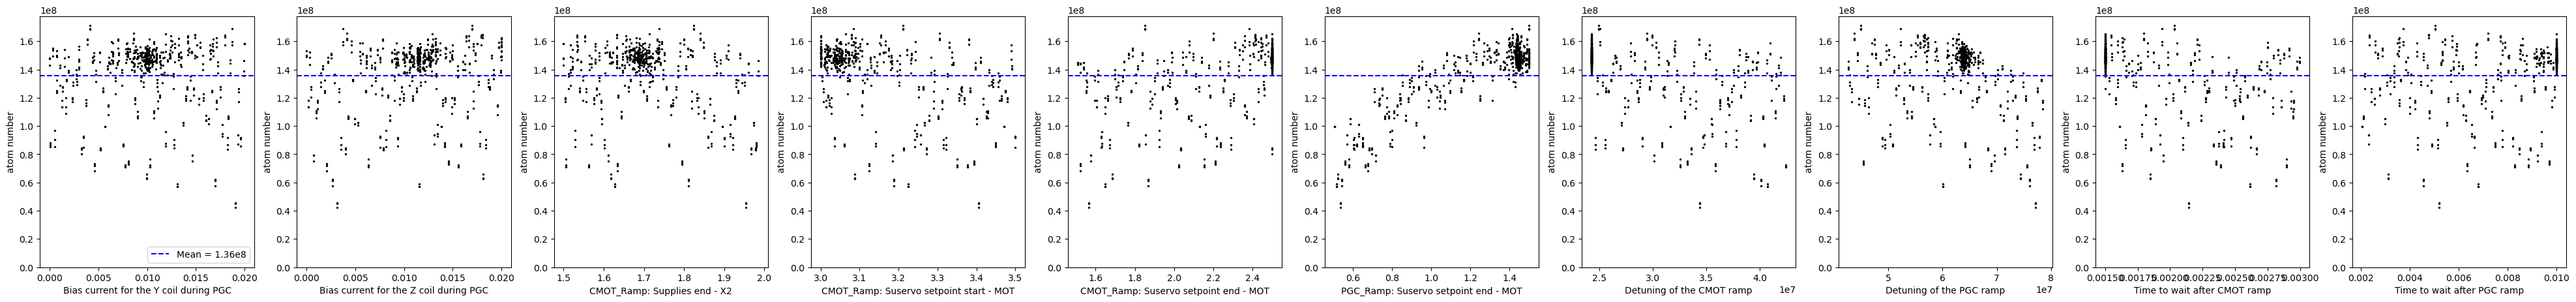

In [224]:
import matplotlib.pyplot as plt
import json
import numpy as np
from matplotlib import colors


axes = json.loads(db[f"ndscan.rid_{RID}.axes"][1])
num_axes = len(axes)

fig, ax = plt.subplots(1, num_axes, figsize=(5 * num_axes, 5))
if num_axes == 1:
    ax = [ax]  # Ensure ax is always a list for consistency
    # make scatter plot
for i in range(num_axes):
    ax[i].scatter(
        np.array(db[f"ndscan.rid_{RID}.points.axis_{i}"][1]),
        np.array(db[f"ndscan.rid_{RID}.points.channel_atom_number"][1]),
        s=2,
        color="k",
    )

    ax[i].set_xlabel(axes[i]["param"]["description"])
    ax[i].set_ylabel("atom number")
    ax[i].set_ylim(bottom=0)

numbers = np.array(db[f"ndscan.rid_{RID}.points.channel_atom_number"][1])
print(f"Num points: {len(numbers)}")

# count the nummber of failed shots (numbers < 1E8)

failed_shots = 0
for i in range(len(numbers)):
    if numbers[i] < 1e8:
        failed_shots += 1
print(f"Failed shots: {failed_shots / len(numbers) * 100:.2f}%")

for i in range(1, num_axes):
    ax[i].axhline(
        np.mean(numbers),
        color="b",
        linestyle="--",
    )
ax[0].axhline(np.mean(numbers), color='b', linestyle='--',
              label='Mean = {:.2f}e8'.format(np.mean(numbers) / 1e8))
ax[0].legend(loc="lower right")

# atom number and uncertainty
print(
    f"Mean atom number: {np.mean(numbers) / 1e8:.2f}e8 +- {np.std(numbers) / 1e8:.2f}e8"
)

# obtain current best optimization parameterss
objective = np.array(db.get(f"ndscan.rid_{RID}.points.channel_custom_objective")[1])
axes_array = np.array(db.get(f"ndscan.rid_{RID}.axes")[1])

# find best results
best_index = np.argmin(objective)
best_objective = objective[best_index]
best_axes = {}
for i in range(num_axes):
    name = axes[i]["param"]["description"]
    value = db.get(f"ndscan.rid_{RID}.points.axis_{i}")[1][best_index]
    best_axes[name] = value
print(
    f"Atom number at best parameters: {db.get(f'ndscan.rid_{RID}.points.channel_atom_number')[1][best_index] / 1e8:.2f}e8"
)
print(f"Best objective value: {best_objective}")
for name, value in best_axes.items():
    print(f"{name}: {value}")


In [217]:
# best index based on PSD
PSD = np.array(db.get(f"ndscan.rid_{RID}.points.channel_phase_space_density")[1])
best_index = np.argmax(PSD)
best_PSD = PSD[best_index]
best_axes = {}
best_sigma_x = db.get(f"ndscan.rid_{RID}.points.channel_sigmax_mm")[1][best_index]
best_sigma_y = db.get(f"ndscan.rid_{RID}.points.channel_sigmay_mm")[1][best_index]
for i in range(num_axes):
    name = axes[i]["param"]["description"]
    value = db.get(f"ndscan.rid_{RID}.points.axis_{i}")[1][best_index]
    best_axes[name] = value
print(
    f"Atom number at best PSD: {db.get(f'ndscan.rid_{RID}.points.channel_atom_number')[1][best_index] / 1e8:.2f}e8"
)
print(f"Best PSD: {best_PSD:.2e}")
print(f"Best sigma_x: {best_sigma_x:.2f} mm")
print(f"Best sigma_y: {best_sigma_y:.2f} mm")
for name, value in best_axes.items():
    print(f"{name}: {value}")

# # make a scatter plot of atom number vs total time = axis_0 + axis_1
# fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
# t1 = db[f"ndscan.rid_{RID}.points.axis_1"][1]
# t2 = db[f"ndscan.rid_{RID}.points.axis_2"][1]
# N = np.array(db[f"ndscan.rid_{RID}.points.channel_atom_number"][1])
# t_total = np.array(t1) + np.array(t2)
# t_frac = np.array(t1) / t_total

# ax[0].scatter(
#     t_total *1e3,
#     N,
#     s=2,color='k',)
# ax[0].set_xlabel("Total Time (ms)")
# ax[0].set_ylabel("Atom Number")
# ax[1].scatter(
#     t_frac,
#     N,
#     s=2,color='k',)
# ax[1].set_xlabel(f"Time Fraction : $t_{{ramp}}/t_{{total}}$")
# ax[1].set_ylabel("Atom Number")
# ax[0].set_title("Scatter Plot of Atom Number vs Total Time")
# ax[1].set_title("Scatter Plot of Atom Number vs Time Fraction")
# plt.show()


Atom number at best PSD: 1.57e8
Best PSD: 4.04e-08
Best sigma_x: 1.94 mm
Best sigma_y: 1.70 mm
Bias current for the Y coil during PGC: 0.010016365459741168
Bias current for the Z coil during PGC: 0.010773690367981172
CMOT_Ramp: Supplies end - X2: 1.6936624420787132
CMOT_Ramp: Suservo setpoint start - MOT: 3.038847187912719
CMOT_Ramp: Suservo setpoint end - MOT: 2.5
PGC_Ramp: Suservo setpoint end - MOT: 1.4732491502259468
Detuning of the CMOT ramp: 24260000.0
Detuning of the PGC ramp: 64427420.051812105
Time to wait after CMOT ramp: 0.0015
Time to wait after PGC ramp: 0.01


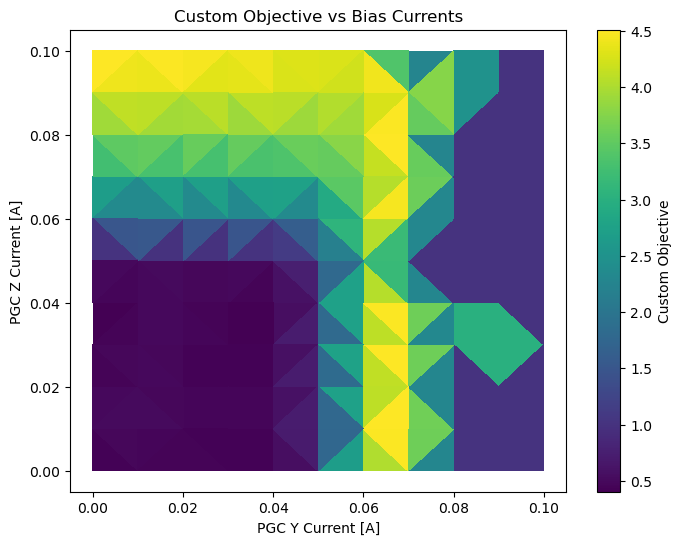

In [206]:
import pandas as pd

import pandas as pd

df1 = pd.DataFrame([
    {
        "point_index": 0,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.1,
        "repository.fragments.mot.MOT.PGC_Z_current": 0,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 0.44442827214845687,
        "gaussian_fit_centre_y": 570.0260487388251,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (570, 0, 0.09107087887929405),\n            "centroid_pixel": (322, 310, 0.0),\n            "best_values_pixel": {\'A\': 0.10458951918144187, \'x0\': 0.44442827214845687, \'y0\': 570.0260487388251, \'sx\': 1.3756899121673756, \'sy\': 1.1596705748573726, \'theta\': 0, \'z0\': -0.03849395122403956},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.09107087887929405,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 1.3756899121673756,\n            "sigmay": 1.1596705748573726,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 0.03908898649109944,\n            "sigmay_mm": 0.032950992104978205,\n        ',
        "peak_od": 0.09107087887929405,
        "phase_space_density": None,
        "sigmax": 1.3756899121673756,
        "sigmax_mm": 0.03908898649109944,
        "sigmay": 1.1596705748573726,
        "sigmay_mm": 0.032950992104978205,
    },
    {
        "point_index": 1,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.03,
        "repository.fragments.mot.MOT.PGC_Z_current": 0,
        "atom_number": 340153870.6788551,
        "custom_objective": 0.39601551521200395,
        "gaussian_fit_centre_x": 315.59463814265183,
        "gaussian_fit_centre_y": 233.942448983652,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 340153870.6788551,\n            "peak_pixel": (235, 322, 3.3425548895565402),\n            "centroid_pixel": (234, 317, 2.9322638683876985),\n            "best_values_pixel": {\'A\': 3.152081367806678, \'x0\': 315.59463814265183, \'y0\': 233.942448983652, \'sx\': 85.03793137487942, \'sy\': 71.20689807030008, \'theta\': 0, \'z0\': -0.03244020426324518},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1828338485274827.0, 2.961156035142131e-08, 4.7472322471312425e-08),\n            "peak_optical_density": 3.3425548895565402,\n            "Peak density (atoms/cm^3)": 1.83e+09,\n            "sigmax": 85.03793137487942,\n            "sigmay": 71.20689807030008,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.416276023647455,\n            "sigmay_mm": 2.0232797028785705,\n        ',
        "peak_od": 3.3425548895565402,
        "phase_space_density": 4.7472322471312425e-8,
        "sigmax": 85.03793137487942,
        "sigmax_mm": 2.416276023647455,
        "sigmay": 71.20689807030008,
        "sigmay_mm": 2.0232797028785705,
    },
    {
        "point_index": 2,
        "repository.fragments.mot.MOT.PGC_Y_current": 0,
        "repository.fragments.mot.MOT.PGC_Z_current": 0,
        "atom_number": 344124248.61790115,
        "custom_objective": 0.3889708639818913,
        "gaussian_fit_centre_x": 315.5740540797919,
        "gaussian_fit_centre_y": 233.1241694263908,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 344124248.61790115,\n            "peak_pixel": (234, 322, 3.276332035842259),\n            "centroid_pixel": (233, 317, 2.881896471835699),\n            "best_values_pixel": {\'A\': 3.178644916820777, \'x0\': 315.5740540797919, \'y0\': 233.1241694263908, \'sx\': 85.53776111332239, \'sy\': 71.00634302327968, \'theta\': 0, \'z0\': -0.061597356244664725},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1833289274553048.8, 2.961156035142131e-08, 4.760086839811762e-08),\n            "peak_optical_density": 3.276332035842259,\n            "Peak density (atoms/cm^3)": 1.83e+09,\n            "sigmax": 85.53776111332239,\n            "sigmay": 71.00634302327968,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.430478234277222,\n            "sigmay_mm": 2.01758111233548,\n        ',
        "peak_od": 3.276332035842259,
        "phase_space_density": 4.760086839811762e-8,
        "sigmax": 85.53776111332239,
        "sigmax_mm": 2.430478234277222,
        "sigmay": 71.00634302327968,
        "sigmay_mm": 2.01758111233548,
    },
    {
        "point_index": 3,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.08,
        "repository.fragments.mot.MOT.PGC_Z_current": 0,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 454.08140392638325,
        "gaussian_fit_centre_y": 193.75429745969723,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (173, 39, 0.0909813873294476),\n            "centroid_pixel": (266, 334, 0.013060379436811674),\n            "best_values_pixel": {\'A\': 0.030761427382331147, \'x0\': 454.08140392638325, \'y0\': 193.75429745969723, \'sx\': 270.2948960756552, \'sy\': 65.56357597009374, \'theta\': 0, \'z0\': -0.04343960634255765},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.0909813873294476,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 270.2948960756552,\n            "sigmay": 65.56357597009374,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 7.680185373074782,\n            "sigmay_mm": 1.8629298017934122,\n        ',
        "peak_od": 0.0909813873294476,
        "phase_space_density": None,
        "sigmax": 270.2948960756552,
        "sigmax_mm": 7.680185373074782,
        "sigmay": 65.56357597009374,
        "sigmay_mm": 1.8629298017934122,
    },
    {
        "point_index": 4,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.01,
        "repository.fragments.mot.MOT.PGC_Z_current": 0,
        "atom_number": 332771355.33715636,
        "custom_objective": 0.4080598075705172,
        "gaussian_fit_centre_x": 317.4350342200317,
        "gaussian_fit_centre_y": 233.82556818960535,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 332771355.33715636,\n            "peak_pixel": (234, 322, 3.2750015590175345),\n            "centroid_pixel": (234, 318, 2.8951269549066176),\n            "best_values_pixel": {\'A\': 3.103288412442356, \'x0\': 317.4350342200317, \'y0\': 233.82556818960535, \'sx\': 85.18034647317596, \'sy\': 70.62029772420908, \'theta\': 0, \'z0\': -0.062172498019563684},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1797488878763991.5, 2.961156035142131e-08, 4.6671320643592684e-08),\n            "peak_optical_density": 3.2750015590175345,\n            "Peak density (atoms/cm^3)": 1.80e+09,\n            "sigmax": 85.18034647317596,\n            "sigmay": 70.62029772420908,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4203226200527967,\n            "sigmay_mm": 2.0066119837936056,\n        ',
        "peak_od": 3.2750015590175345,
        "phase_space_density": 4.6671320643592684e-8,
        "sigmax": 85.18034647317596,
        "sigmax_mm": 2.4203226200527967,
        "sigmay": 70.62029772420908,
        "sigmay_mm": 2.0066119837936056,
    },
    {
        "point_index": 5,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.09,
        "repository.fragments.mot.MOT.PGC_Z_current": 0,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 162.82714580123937,
        "gaussian_fit_centre_y": 599.9999999747109,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (600, 37, 0.09090704284144054),\n            "centroid_pixel": (345, 310, 0.0),\n            "best_values_pixel": {\'A\': 0.023445800268491777, \'x0\': 162.82714580123937, \'y0\': 599.9999999747109, \'sx\': 600.99999999999, \'sy\': 46.291483954195, \'theta\': 0, \'z0\': -0.06745406713038266},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.09090704284144054,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 600.99999999999,\n            "sigmay": 46.291483954195,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 17.07687224669575,\n            "sigmay_mm": 1.3153307114738226,\n        ',
        "peak_od": 0.09090704284144054,
        "phase_space_density": None,
        "sigmax": 600.99999999999,
        "sigmax_mm": 17.07687224669575,
        "sigmay": 46.291483954195,
        "sigmay_mm": 1.3153307114738226,
    },
    {
        "point_index": 6,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.07,
        "repository.fragments.mot.MOT.PGC_Z_current": 0,
        "atom_number": 13867249.864745235,
        "custom_objective": 4.857792630932543,
        "gaussian_fit_centre_x": 406.96786713101835,
        "gaussian_fit_centre_y": 195.58714871733437,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 13867249.864745235,\n            "peak_pixel": (147, 595, 0.12182483810736282),\n            "centroid_pixel": (246, 339, 0.0574698497602378),\n            "best_values_pixel": {\'A\': 0.06707073304505817, \'x0\': 406.96786713101835, \'y0\': 195.58714871733437, \'sx\': 219.70854690319533, \'sy\': 63.92163460925319, \'theta\': 0, \'z0\': -0.05388171460512131},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (12438762915885.084, 2.961156035142131e-08, 3.229691706666332e-10),\n            "peak_optical_density": 0.12182483810736282,\n            "Peak density (atoms/cm^3)": 1.24e+07,\n            "sigmax": 219.70854690319533,\n            "sigmay": 63.92163460925319,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 6.2428199450467385,\n            "sigmay_mm": 1.8162755208356078,\n        ',
        "peak_od": 0.12182483810736282,
        "phase_space_density": 3.229691706666332e-10,
        "sigmax": 219.70854690319533,
        "sigmax_mm": 6.2428199450467385,
        "sigmay": 63.92163460925319,
        "sigmay_mm": 1.8162755208356078,
    },
    {
        "point_index": 7,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.05,
        "repository.fragments.mot.MOT.PGC_Z_current": 0,
        "atom_number": 326908173.37129146,
        "custom_objective": 0.7869545207895168,
        "gaussian_fit_centre_x": 309.5853021831825,
        "gaussian_fit_centre_y": 231.76594837513574,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 326908173.37129146,\n            "peak_pixel": (243, 306, 2.5052979081989863),\n            "centroid_pixel": (234, 312, 2.3812727840505516),\n            "best_values_pixel": {\'A\': 2.392160947011837, \'x0\': 309.5853021831825, \'y0\': 231.76594837513574, \'sx\': 106.94215730751513, \'sy\': 71.56068515699945, \'theta\': 0, \'z0\': -0.0644162467757113},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1105559275443562.8, 2.961156035142131e-08, 2.8705552531821407e-08),\n            "peak_optical_density": 2.5052979081989863,\n            "Peak density (atoms/cm^3)": 1.11e+09,\n            "sigmax": 106.94215730751513,\n            "sigmay": 71.56068515699945,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 3.038664822173888,\n            "sigmay_mm": 2.0333322434477816,\n        ',
        "peak_od": 2.5052979081989863,
        "phase_space_density": 2.8705552531821407e-8,
        "sigmax": 106.94215730751513,
        "sigmax_mm": 3.038664822173888,
        "sigmay": 71.56068515699945,
        "sigmay_mm": 2.0333322434477816,
    },
    {
        "point_index": 8,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.02,
        "repository.fragments.mot.MOT.PGC_Z_current": 0,
        "atom_number": 339967800.22103405,
        "custom_objective": 0.43813529070819746,
        "gaussian_fit_centre_x": 317.12433807266024,
        "gaussian_fit_centre_y": 233.2327130567677,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 339967800.22103405,\n            "peak_pixel": (235, 323, 3.2294435381155555),\n            "centroid_pixel": (233, 318, 2.870759915874355),\n            "best_values_pixel": {\'A\': 3.0642264418681693, \'x0\': 317.12433807266024, \'y0\': 233.2327130567677, \'sx\': 87.15022099757302, \'sy\': 71.43363729035137, \'theta\': 0, \'z0\': -0.02261619861270992},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1734309729491154.2, 2.961156035142131e-08, 4.503089083702299e-08),\n            "peak_optical_density": 3.2294435381155555,\n            "Peak density (atoms/cm^3)": 1.73e+09,\n            "sigmax": 87.15022099757302,\n            "sigmay": 71.43363729035137,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4762948257019644,\n            "sigmay_mm": 2.029722293051834,\n        ',
        "peak_od": 3.2294435381155555,
        "phase_space_density": 4.503089083702299e-8,
        "sigmax": 87.15022099757302,
        "sigmax_mm": 2.4762948257019644,
        "sigmay": 71.43363729035137,
        "sigmay_mm": 2.029722293051834,
    },
    {
        "point_index": 9,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.06,
        "repository.fragments.mot.MOT.PGC_Z_current": 0,
        "atom_number": 48230166.081711024,
        "custom_objective": 3.5915759598513155,
        "gaussian_fit_centre_x": 367.04882612234593,
        "gaussian_fit_centre_y": 210.1843327303107,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 48230166.081711024,\n            "peak_pixel": (223, 344, 0.25526840360969383),\n            "centroid_pixel": (221, 335, 0.22048086705046785),\n            "best_values_pixel": {\'A\': 0.22049172374669615, \'x0\': 367.04882612234593, \'y0\': 210.1843327303107, \'sx\': 199.00182559480015, \'sy\': 69.64919465552414, \'theta\': 0, \'z0\': -0.015189011876035014},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (48396857432021.69, 2.961156035142131e-08, 1.2566115306957049e-09),\n            "peak_optical_density": 0.25526840360969383,\n            "Peak density (atoms/cm^3)": 4.84e+07,\n            "sigmax": 199.00182559480015,\n            "sigmay": 69.64919465552414,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.6544571589711925,\n            "sigmay_mm": 1.979018967084276,\n        ',
        "peak_od": 0.25526840360969383,
        "phase_space_density": 1.2566115306957049e-9,
        "sigmax": 199.00182559480015,
        "sigmax_mm": 5.6544571589711925,
        "sigmay": 69.64919465552414,
        "sigmay_mm": 1.979018967084276,
    },
    {
        "point_index": 10,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.04,
        "repository.fragments.mot.MOT.PGC_Z_current": 0,
        "atom_number": 338930172.0680567,
        "custom_objective": 0.40683176735709314,
        "gaussian_fit_centre_x": 317.3376004774841,
        "gaussian_fit_centre_y": 234.6346529896451,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 338930172.0680567,\n            "peak_pixel": (235, 323, 3.284038891231913),\n            "centroid_pixel": (235, 319, 3.0637969735245005),\n            "best_values_pixel": {\'A\': 3.1268264499682927, \'x0\': 317.3376004774841, \'y0\': 234.6346529896451, \'sx\': 85.6611281108014, \'sy\': 71.02956154584415, \'theta\': 0, \'z0\': 0.02010546786008853},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1799832726414362.5, 2.961156035142131e-08, 4.673217802442133e-08),\n            "peak_optical_density": 3.284038891231913,\n            "Peak density (atoms/cm^3)": 1.80e+09,\n            "sigmax": 85.6611281108014,\n            "sigmay": 71.02956154584415,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4339835960998633,\n            "sigmay_mm": 2.0182408456858796,\n        ',
        "peak_od": 3.284038891231913,
        "phase_space_density": 4.673217802442133e-8,
        "sigmax": 85.6611281108014,
        "sigmax_mm": 2.4339835960998633,
        "sigmay": 71.02956154584415,
        "sigmay_mm": 2.0182408456858796,
    },
    {
        "point_index": 11,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.1,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.01,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 186.44724650508428,
        "gaussian_fit_centre_y": 599.9999999981745,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (74, 426, 0.08674686297300829),\n            "centroid_pixel": (345, 317, 0.0),\n            "best_values_pixel": {\'A\': 0.01614988940852115, \'x0\': 186.44724650508428, \'y0\': 599.9999999981745, \'sx\': 600.9999999999529, \'sy\': 48.62592042353195, \'theta\': 0, \'z0\': -0.06318944681522391},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.08674686297300829,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 600.9999999999529,\n            "sigmay": 48.62592042353195,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 17.076872246694695,\n            "sigmay_mm": 1.3816616155585069,\n        ',
        "peak_od": 0.08674686297300829,
        "phase_space_density": None,
        "sigmax": 600.9999999999529,
        "sigmax_mm": 17.076872246694695,
        "sigmay": 48.62592042353195,
        "sigmay_mm": 1.3816616155585069,
    },
    {
        "point_index": 12,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.03,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.01,
        "atom_number": 331996158.8704822,
        "custom_objective": 0.426494363883541,
        "gaussian_fit_centre_x": 317.16419600859433,
        "gaussian_fit_centre_y": 234.353813598671,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 331996158.8704822,\n            "peak_pixel": (243, 306, 3.230289054562566),\n            "centroid_pixel": (234, 318, 2.904425338010443),\n            "best_values_pixel": {\'A\': 3.063735247806735, \'x0\': 317.16419600859433, \'y0\': 234.353813598671, \'sx\': 85.7034187489271, \'sy\': 70.94681436111115, \'theta\': 0, \'z0\': -0.03439473738988358},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1763325514449410.8, 2.961156035142131e-08, 4.5784277975887246e-08),\n            "peak_optical_density": 3.230289054562566,\n            "Peak density (atoms/cm^3)": 1.76e+09,\n            "sigmax": 85.7034187489271,\n            "sigmay": 70.94681436111115,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4351852463902195,\n            "sigmay_mm": 2.0158896591593254,\n        ',
        "peak_od": 3.230289054562566,
        "phase_space_density": 4.5784277975887246e-8,
        "sigmax": 85.7034187489271,
        "sigmax_mm": 2.4351852463902195,
        "sigmay": 70.94681436111115,
        "sigmay_mm": 2.0158896591593254,
    },
    {
        "point_index": 13,
        "repository.fragments.mot.MOT.PGC_Y_current": 0,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.01,
        "atom_number": 305382213.3409177,
        "custom_objective": 0.4812629157966522,
        "gaussian_fit_centre_x": 317.66557043776675,
        "gaussian_fit_centre_y": 234.44078199330164,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 305382213.3409177,\n            "peak_pixel": (235, 322, 3.0271078874322956),\n            "centroid_pixel": (234, 319, 2.7806085612498914),\n            "best_values_pixel": {\'A\': 2.8730102140134886, \'x0\': 317.66557043776675, \'y0\': 234.44078199330164, \'sx\': 84.46657128686546, \'sy\': 70.61718806349519, \'theta\': 0, \'z0\': -0.018638921331226934},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1677614659708049.5, 2.961156035142131e-08, 4.3558818429778034e-08),\n            "peak_optical_density": 3.0271078874322956,\n            "Peak density (atoms/cm^3)": 1.68e+09,\n            "sigmax": 84.46657128686546,\n            "sigmay": 70.61718806349519,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4000413427325205,\n            "sigmay_mm": 2.0065236255927044,\n        ',
        "peak_od": 3.0271078874322956,
        "phase_space_density": 4.3558818429778034e-8,
        "sigmax": 84.46657128686546,
        "sigmax_mm": 2.4000413427325205,
        "sigmay": 70.61718806349519,
        "sigmay_mm": 2.0065236255927044,
    },
    {
        "point_index": 14,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.08,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.01,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 460.5554841767125,
        "gaussian_fit_centre_y": 199.47658703932743,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (317, 0, 0.08466362901801058),\n            "centroid_pixel": (270, 334, 0.014566808449274889),\n            "best_values_pixel": {\'A\': 0.03023906736208876, \'x0\': 460.5554841767125, \'y0\': 199.47658703932743, \'sx\': 269.02167559074286, \'sy\': 63.849525912515354, \'theta\': 0, \'z0\': -0.02550664357404301},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.08466362901801058,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 269.02167559074286,\n            "sigmay": 63.849525912515354,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 7.644007962820666,\n            "sigmay_mm": 1.8142266173379913,\n        ',
        "peak_od": 0.08466362901801058,
        "phase_space_density": None,
        "sigmax": 269.02167559074286,
        "sigmax_mm": 7.644007962820666,
        "sigmay": 63.849525912515354,
        "sigmay_mm": 1.8142266173379913,
    },
    {
        "point_index": 15,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.01,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.01,
        "atom_number": 321557415.7885781,
        "custom_objective": 0.5115805464970168,
        "gaussian_fit_centre_x": 313.672857730295,
        "gaussian_fit_centre_y": 233.23362892837235,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 321557415.7885781,\n            "peak_pixel": (235, 323, 3.028325450212552),\n            "centroid_pixel": (233, 315, 2.7383232874036647),\n            "best_values_pixel": {\'A\': 2.8636286753597355, \'x0\': 313.672857730295, \'y0\': 233.23362892837235, \'sx\': 87.95873632018622, \'sy\': 71.62050050458153, \'theta\': 0, \'z0\': -0.01969272412930694},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1606171222916524.8, 2.961156035142131e-08, 4.170380859590896e-08),\n            "peak_optical_density": 3.028325450212552,\n            "Peak density (atoms/cm^3)": 1.61e+09,\n            "sigmax": 87.95873632018622,\n            "sigmay": 71.62050050458153,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.499268058437009,\n            "sigmay_mm": 2.0350318425310605,\n        ',
        "peak_od": 3.028325450212552,
        "phase_space_density": 4.170380859590896e-8,
        "sigmax": 87.95873632018622,
        "sigmax_mm": 2.499268058437009,
        "sigmay": 71.62050050458153,
        "sigmay_mm": 2.0350318425310605,
    },
    {
        "point_index": 16,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.09,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.01,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 6.021255867649432e-8,
        "gaussian_fit_centre_y": 468.9267997521797,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (468, 0, 0.07483193181457434),\n            "centroid_pixel": (293, 327, 0.0013697822005226956),\n            "best_values_pixel": {\'A\': 0.04803179231614213, \'x0\': 6.021255867649432e-08, \'y0\': 468.9267997521797, \'sx\': 6.29835488420088, \'sy\': 1.7080607526784135, \'theta\': 0, \'z0\': -0.03184945521701322},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.07483193181457434,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 6.29835488420088,\n            "sigmay": 1.7080607526784135,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 0.1789620660929325,\n            "sigmay_mm": 0.048533003765532004,\n        ',
        "peak_od": 0.07483193181457434,
        "phase_space_density": None,
        "sigmax": 6.29835488420088,
        "sigmax_mm": 0.1789620660929325,
        "sigmay": 1.7080607526784135,
        "sigmay_mm": 0.048533003765532004,
    },
    {
        "point_index": 17,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.07,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.01,
        "atom_number": 14769482.069781171,
        "custom_objective": 4.9755286742228195,
        "gaussian_fit_centre_x": 411.7743237132432,
        "gaussian_fit_centre_y": 206.64324687372158,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 14769482.069781171,\n            "peak_pixel": (80, 446, 0.10287033927836078),\n            "centroid_pixel": (240, 342, 0.07251952613334106),\n            "best_values_pixel": {\'A\': 0.06697939918307698, \'x0\': 411.7743237132432, \'y0\': 206.64324687372158, \'sx\': 239.09073992276817, \'sy\': 66.26284737275577, \'theta\': 0, \'z0\': -0.03946338225225369},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (10791909258241.865, 2.961156035142131e-08, 2.802090534737012e-10),\n            "peak_optical_density": 0.10287033927836078,\n            "Peak density (atoms/cm^3)": 1.08e+07,\n            "sigmax": 239.09073992276817,\n            "sigmay": 66.26284737275577,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 6.793547455955306,\n            "sigmay_mm": 1.8827989671994478,\n        ',
        "peak_od": 0.10287033927836078,
        "phase_space_density": 2.802090534737012e-10,
        "sigmax": 239.09073992276817,
        "sigmax_mm": 6.793547455955306,
        "sigmay": 66.26284737275577,
        "sigmay_mm": 1.8827989671994478,
    },
    {
        "point_index": 18,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.05,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.01,
        "atom_number": 341218613.9655836,
        "custom_objective": 0.8468976569794903,
        "gaussian_fit_centre_x": 305.3382180155498,
        "gaussian_fit_centre_y": 231.10109587101317,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 341218613.9655836,\n            "peak_pixel": (235, 323, 2.435209431797223),\n            "centroid_pixel": (233, 308, 2.3565339417648787),\n            "best_values_pixel": {\'A\': 2.331877802532644, \'x0\': 305.3382180155498, \'y0\': 231.10109587101317, \'sx\': 113.97003530049727, \'sy\': 71.9105627175696, \'theta\': 0, \'z0\': -0.025823547024058882},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1011084113965916.8, 2.961156035142131e-08, 2.6252530092422302e-08),\n            "peak_optical_density": 2.435209431797223,\n            "Peak density (atoms/cm^3)": 1.01e+09,\n            "sigmax": 113.97003530049727,\n            "sigmay": 71.9105627175696,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 3.238355628582411,\n            "sigmay_mm": 2.0432736983626603,\n        ',
        "peak_od": 2.435209431797223,
        "phase_space_density": 2.6252530092422302e-8,
        "sigmax": 113.97003530049727,
        "sigmax_mm": 3.238355628582411,
        "sigmay": 71.9105627175696,
        "sigmay_mm": 2.0432736983626603,
    },
    {
        "point_index": 19,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.02,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.01,
        "atom_number": 322168382.5439064,
        "custom_objective": 0.47195011231803136,
        "gaussian_fit_centre_x": 318.7923802713879,
        "gaussian_fit_centre_y": 232.6787708701467,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 322168382.5439064,\n            "peak_pixel": (235, 322, 3.119870921804357),\n            "centroid_pixel": (232, 320, 2.9404618964708695),\n            "best_values_pixel": {\'A\': 2.94217649638581, \'x0\': 318.7923802713879, \'y0\': 232.6787708701467, \'sx\': 86.14268782223856, \'sy\': 71.31375749921978, \'theta\': 0, \'z0\': -0.021994409708940076},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1685005741363609.8, 2.961156035142131e-08, 4.375072589909535e-08),\n            "peak_optical_density": 3.119870921804357,\n            "Peak density (atoms/cm^3)": 1.69e+09,\n            "sigmax": 86.14268782223856,\n            "sigmay": 71.31375749921978,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.447666680411624,\n            "sigmay_mm": 2.0263160170483148,\n        ',
        "peak_od": 3.119870921804357,
        "phase_space_density": 4.375072589909535e-8,
        "sigmax": 86.14268782223856,
        "sigmax_mm": 2.447666680411624,
        "sigmay": 71.31375749921978,
        "sigmay_mm": 2.0263160170483148,
    },
    {
        "point_index": 20,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.06,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.01,
        "atom_number": 46242163.377997085,
        "custom_objective": 3.6359984070356606,
        "gaussian_fit_centre_x": 369.0315138717142,
        "gaussian_fit_centre_y": 209.5427662319226,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 46242163.377997085,\n            "peak_pixel": (223, 351, 0.2452978410443878),\n            "centroid_pixel": (221, 336, 0.22582112869766902),\n            "best_values_pixel": {\'A\': 0.21217191343077418, \'x0\': 369.0315138717142, \'y0\': 209.5427662319226, \'sx\': 200.77298401315738, \'sy\': 69.14207770602279, \'theta\': 0, \'z0\': -0.03000525952513729},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (45921259959006.66, 2.961156035142131e-08, 1.1923333007647355e-09),\n            "peak_optical_density": 0.2452978410443878,\n            "Peak density (atoms/cm^3)": 4.59e+07,\n            "sigmax": 200.77298401315738,\n            "sigmay": 69.14207770602279,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.704783025924516,\n            "sigmay_mm": 1.9646096969332463,\n        ',
        "peak_od": 0.2452978410443878,
        "phase_space_density": 1.1923333007647355e-9,
        "sigmax": 200.77298401315738,
        "sigmax_mm": 5.704783025924516,
        "sigmay": 69.14207770602279,
        "sigmay_mm": 1.9646096969332463,
    },
    {
        "point_index": 21,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.04,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.01,
        "atom_number": 331511109.947922,
        "custom_objective": 0.47887777416178157,
        "gaussian_fit_centre_x": 314.1696490922051,
        "gaussian_fit_centre_y": 234.36355610083953,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 331511109.947922,\n            "peak_pixel": (235, 322, 3.112148121830632),\n            "centroid_pixel": (234, 315, 2.8782852955544036),\n            "best_values_pixel": {\'A\': 2.9575521156161613, \'x0\': 314.1696490922051, \'y0\': 234.36355610083953, \'sx\': 87.76803747420989, \'sy\': 71.67008094539264, \'theta\': 0, \'z0\': -0.016820370097164243},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1661942686616750.5, 2.961156035142131e-08, 4.315189981687138e-08),\n            "peak_optical_density": 3.112148121830632,\n            "Peak density (atoms/cm^3)": 1.66e+09,\n            "sigmax": 87.76803747420989,\n            "sigmay": 71.67008094539264,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4938495229456112,\n            "sigmay_mm": 2.0364406259814207,\n        ',
        "peak_od": 3.112148121830632,
        "phase_space_density": 4.315189981687138e-8,
        "sigmax": 87.76803747420989,
        "sigmax_mm": 2.4938495229456112,
        "sigmay": 71.67008094539264,
        "sigmay_mm": 2.0364406259814207,
    },
    {
        "point_index": 22,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.1,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.1,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 9.380484737741684,
        "gaussian_fit_centre_y": 599.999993573547,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (84, 143, 0.07243950977812032),\n            "centroid_pixel": (297, 337, 0.0017464766212029331),\n            "best_values_pixel": {\'A\': 0.03043531087351961, \'x0\': 9.380484737741684, \'y0\': 599.999993573547, \'sx\': 2.0301765359498547, \'sy\': 13.135646646662218, \'theta\': 0, \'z0\': -0.03368042063911297},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.07243950977812032,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 2.0301765359498547,\n            "sigmay": 13.135646646662218,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 0.05768563284967648,\n            "sigmay_mm": 0.37323753687652556,\n        ',
        "peak_od": 0.07243950977812032,
        "phase_space_density": None,
        "sigmax": 2.0301765359498547,
        "sigmax_mm": 0.05768563284967648,
        "sigmay": 13.135646646662218,
        "sigmay_mm": 0.37323753687652556,
    },
    {
        "point_index": 23,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.03,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.1,
        "atom_number": 39140786.444988914,
        "custom_objective": 4.530268603426062,
        "gaussian_fit_centre_x": 328.13462606091207,
        "gaussian_fit_centre_y": 231.48434014979904,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 39140786.444988914,\n            "peak_pixel": (235, 323, 0.17277711587893446),\n            "centroid_pixel": (265, 325, 0.13120568270074887),\n            "best_values_pixel": {\'A\': 0.11369673899911889, \'x0\': 328.13462606091207, \'y0\': 231.48434014979904, \'sx\': 196.4986873518026, \'sy\': 114.74489944954188, \'theta\': 0, \'z0\': 0.02844068888318316},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (24451498277433.008, 2.961156035142131e-08, 6.348766491990999e-10),\n            "peak_optical_density": 0.17277711587893446,\n            "Peak density (atoms/cm^3)": 2.45e+07,\n            "sigmax": 196.4986873518026,\n            "sigmay": 114.74489944954188,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.583332746339765,\n            "sigmay_mm": 3.2603726936103303,\n        ',
        "peak_od": 0.17277711587893446,
        "phase_space_density": 6.348766491990999e-10,
        "sigmax": 196.4986873518026,
        "sigmax_mm": 5.583332746339765,
        "sigmay": 114.74489944954188,
        "sigmay_mm": 3.2603726936103303,
    },
    {
        "point_index": 24,
        "repository.fragments.mot.MOT.PGC_Y_current": 0,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.1,
        "atom_number": 37016949.101637036,
        "custom_objective": 4.565608378559895,
        "gaussian_fit_centre_x": 326.5878249595325,
        "gaussian_fit_centre_y": 229.6380737256501,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 37016949.101637036,\n            "peak_pixel": (233, 356, 0.16379411260111412),\n            "centroid_pixel": (264, 323, 0.12742343036787127),\n            "best_values_pixel": {\'A\': 0.10891355525765636, \'x0\': 326.5878249595325, \'y0\': 229.6380737256501, \'sx\': 194.6414831165779, \'sy\': 114.27123835142999, \'theta\': 0, \'z0\': 0.01978516115108516},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (23665817047537.516, 2.961156035142131e-08, 6.144766450392304e-10),\n            "peak_optical_density": 0.16379411260111412,\n            "Peak density (atoms/cm^3)": 2.37e+07,\n            "sigmax": 194.6414831165779,\n            "sigmay": 114.27123835142999,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.5305619652067275,\n            "sigmay_mm": 3.2469140412630986,\n        ',
        "peak_od": 0.16379411260111412,
        "phase_space_density": 6.144766450392304e-10,
        "sigmax": 194.6414831165779,
        "sigmax_mm": 5.5305619652067275,
        "sigmay": 114.27123835142999,
        "sigmay_mm": 3.2469140412630986,
    },
    {
        "point_index": 25,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.08,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.1,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 431.4977748050993,
        "gaussian_fit_centre_y": 196.22903986825068,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (61, 325, 0.09232549669326923),\n            "centroid_pixel": (260, 339, 0.03221697377354962),\n            "best_values_pixel": {\'A\': 0.037253391768432356, \'x0\': 431.4977748050993, \'y0\': 196.22903986825068, \'sx\': 235.33806941313324, \'sy\': 69.78694179337398, \'theta\': 0, \'z0\': -0.043672551004432195},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.09232549669326923,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 235.33806941313324,\n            "sigmay": 69.78694179337398,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 6.6869187123996,\n            "sigmay_mm": 1.9829329276090844,\n        ',
        "peak_od": 0.09232549669326923,
        "phase_space_density": None,
        "sigmax": 235.33806941313324,
        "sigmax_mm": 6.6869187123996,
        "sigmay": 69.78694179337398,
        "sigmay_mm": 1.9829329276090844,
    },
    {
        "point_index": 26,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.01,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.1,
        "atom_number": 36568433.12712688,
        "custom_objective": 4.595001188899011,
        "gaussian_fit_centre_x": 327.5044166210334,
        "gaussian_fit_centre_y": 232.17891540541208,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 36568433.12712688,\n            "peak_pixel": (230, 354, 0.16112893941042666),\n            "centroid_pixel": (267, 325, 0.11878422783035719),\n            "best_values_pixel": {\'A\': 0.10625740468605413, \'x0\': 327.5044166210334, \'y0\': 232.17891540541208, \'sx\': 196.28955304714802, \'sy\': 114.61876640885556, \'theta\': 0, \'z0\': 0.024021541018324096},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (22918430611775.17, 2.961156035142131e-08, 5.950709550234335e-10),\n            "peak_optical_density": 0.16112893941042666,\n            "Peak density (atoms/cm^3)": 2.29e+07,\n            "sigmax": 196.28955304714802,\n            "sigmay": 114.61876640885556,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.577390383938787,\n            "sigmay_mm": 3.256788737167922,\n        ',
        "peak_od": 0.16112893941042666,
        "phase_space_density": 5.950709550234335e-10,
        "sigmax": 196.28955304714802,
        "sigmax_mm": 5.577390383938787,
        "sigmay": 114.61876640885556,
        "sigmay_mm": 3.256788737167922,
    },
    {
        "point_index": 27,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.09,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.1,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 448.55571734657343,
        "gaussian_fit_centre_y": 191.81040427651115,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (194, 600, 0.07474589676856577),\n            "centroid_pixel": (275, 341, 0.009493230548296129),\n            "best_values_pixel": {\'A\': 0.023539553261930392, \'x0\': 448.55571734657343, \'y0\': 191.81040427651115, \'sx\': 237.92721210155122, \'sy\': 65.76092579045292, \'theta\': 0, \'z0\': -0.035157301956487044},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.07474589676856577,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 237.92721210155122,\n            "sigmay": 65.76092579045292,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 6.760486863678437,\n            "sigmay_mm": 1.868537318715512,\n        ',
        "peak_od": 0.07474589676856577,
        "phase_space_density": None,
        "sigmax": 237.92721210155122,
        "sigmax_mm": 6.760486863678437,
        "sigmay": 65.76092579045292,
        "sigmay_mm": 1.868537318715512,
    },
    {
        "point_index": 28,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.07,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.1,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 406.68348873826955,
        "gaussian_fit_centre_y": 206.6687394457847,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (214, 556, 0.09728745817988693),\n            "centroid_pixel": (241, 350, 0.07295634801646911),\n            "best_values_pixel": {\'A\': 0.06468619322304439, \'x0\': 406.68348873826955, \'y0\': 206.6687394457847, \'sx\': 211.14363752630754, \'sy\': 66.22225209284603, \'theta\': 0, \'z0\': -0.046649167358444564},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.09728745817988693,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 211.14363752630754,\n            "sigmay": 66.22225209284603,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.999455779932527,\n            "sigmay_mm": 1.8816454889817482,\n        ',
        "peak_od": 0.09728745817988693,
        "phase_space_density": None,
        "sigmax": 211.14363752630754,
        "sigmax_mm": 5.999455779932527,
        "sigmay": 66.22225209284603,
        "sigmay_mm": 1.8816454889817482,
    },
    {
        "point_index": 29,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.05,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.1,
        "atom_number": 33341186.56711581,
        "custom_objective": 4.370189894492029,
        "gaussian_fit_centre_x": 333.21622328748583,
        "gaussian_fit_centre_y": 226.80482817328087,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 33341186.56711581,\n            "peak_pixel": (213, 332, 0.165914213256853),\n            "centroid_pixel": (258, 329, 0.13772651500615585),\n            "best_values_pixel": {\'A\': 0.11264376941794232, \'x0\': 333.21622328748583, \'y0\': 226.80482817328087, \'sx\': 174.1323352460026, \'sy\': 104.57641632068382, \'theta\': 0, \'z0\': 0.011669335136234102},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (29101613811464.793, 2.961156035142131e-08, 7.556156622091738e-10),\n            "peak_optical_density": 0.165914213256853,\n            "Peak density (atoms/cm^3)": 2.91e+07,\n            "sigmax": 174.1323352460026,\n            "sigmay": 104.57641632068382,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 4.947813049941483,\n            "sigmay_mm": 2.971444428495201,\n        ',
        "peak_od": 0.165914213256853,
        "phase_space_density": 7.556156622091738e-10,
        "sigmax": 174.1323352460026,
        "sigmax_mm": 4.947813049941483,
        "sigmay": 104.57641632068382,
        "sigmay_mm": 2.971444428495201,
    },
    {
        "point_index": 30,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.02,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.1,
        "atom_number": 38374365.87274564,
        "custom_objective": 4.564740738917824,
        "gaussian_fit_centre_x": 325.9113709952114,
        "gaussian_fit_centre_y": 230.37332267995768,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 38374365.87274564,\n            "peak_pixel": (241, 362, 0.16415211242606573),\n            "centroid_pixel": (265, 324, 0.12251434536472533),\n            "best_values_pixel": {\'A\': 0.11091325642325722, \'x0\': 325.9113709952114, \'y0\': 230.37332267995768, \'sx\': 196.44218052709766, \'sy\': 115.90800890112233, \'theta\': 0, \'z0\': 0.016958871602011396},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (23745805117146.523, 2.961156035142131e-08, 6.165535139915161e-10),\n            "peak_optical_density": 0.16415211242606573,\n            "Peak density (atoms/cm^3)": 2.37e+07,\n            "sigmax": 196.44218052709766,\n            "sigmay": 115.90800890112233,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.581727155946166,\n            "sigmay_mm": 3.2934213982918012,\n        ',
        "peak_od": 0.16415211242606573,
        "phase_space_density": 6.165535139915161e-10,
        "sigmax": 196.44218052709766,
        "sigmax_mm": 5.581727155946166,
        "sigmay": 115.90800890112233,
        "sigmay_mm": 3.2934213982918012,
    },
    {
        "point_index": 31,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.06,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.1,
        "atom_number": 18622819.79464438,
        "custom_objective": 4.331778542806997,
        "gaussian_fit_centre_x": 374.28860394954546,
        "gaussian_fit_centre_y": 216.31922647669677,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 18622819.79464438,\n            "peak_pixel": (241, 312, 0.12045461372808657),\n            "centroid_pixel": (238, 345, 0.10111795343603061),\n            "best_values_pixel": {\'A\': 0.09487934277896852, \'x0\': 374.28860394954546, \'y0\': 216.31922647669677, \'sx\': 185.7154374903484, \'sy\': 64.8216688227037, \'theta\': 0, \'z0\': -0.05447483254031116},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (23054613550112.145, 2.961156035142131e-08, 5.986069087956103e-10),\n            "peak_optical_density": 0.12045461372808657,\n            "Peak density (atoms/cm^3)": 2.31e+07,\n            "sigmax": 185.7154374903484,\n            "sigmay": 64.8216688227037,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.276936439703731,\n            "sigmay_mm": 1.8418491802045762,\n        ',
        "peak_od": 0.12045461372808657,
        "phase_space_density": 5.986069087956103e-10,
        "sigmax": 185.7154374903484,
        "sigmax_mm": 5.276936439703731,
        "sigmay": 64.8216688227037,
        "sigmay_mm": 1.8418491802045762,
    },
    {
        "point_index": 32,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.04,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.1,
        "atom_number": 31491499.422998413,
        "custom_objective": 4.376904155839064,
        "gaussian_fit_centre_x": 322.97376144403415,
        "gaussian_fit_centre_y": 215.87341713438624,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 31491499.422998413,\n            "peak_pixel": (240, 361, 0.16657498466938245),\n            "centroid_pixel": (254, 322, 0.13467685589044115),\n            "best_values_pixel": {\'A\': 0.11002236247997678, \'x0\': 322.97376144403415, \'y0\': 215.87341713438624, \'sx\': 169.6081810886148, \'sy\': 103.82100269226521, \'theta\': 0, \'z0\': -0.02235331516530426},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (29183888152317.37, 2.961156035142131e-08, 7.577518935861998e-10),\n            "peak_optical_density": 0.16657498466938245,\n            "Peak density (atoms/cm^3)": 2.92e+07,\n            "sigmax": 169.6081810886148,\n            "sigmay": 103.82100269226521,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 4.819263295249187,\n            "sigmay_mm": 2.949980032445421,\n        ',
        "peak_od": 0.16657498466938245,
        "phase_space_density": 7.577518935861998e-10,
        "sigmax": 169.6081810886148,
        "sigmax_mm": 4.819263295249187,
        "sigmay": 103.82100269226521,
        "sigmay_mm": 2.949980032445421,
    },
    {
        "point_index": 33,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.1,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.05,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 208.77544984391778,
        "gaussian_fit_centre_y": 599.9999999999999,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (92, 485, 0.0830387060588883),\n            "centroid_pixel": (334, 305, 0.0),\n            "best_values_pixel": {\'A\': 0.017721071707319864, \'x0\': 208.77544984391778, \'y0\': 599.9999999999999, \'sx\': 600.9999999984177, \'sy\': 33.0870766480623, \'theta\': 0, \'z0\': -0.05846831988876573},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.0830387060588883,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 600.9999999984177,\n            "sigmay": 33.0870766480623,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 17.076872246651075,\n            "sigmay_mm": 0.9401394025550741,\n        ',
        "peak_od": 0.0830387060588883,
        "phase_space_density": None,
        "sigmax": 600.9999999984177,
        "sigmax_mm": 17.076872246651075,
        "sigmay": 33.0870766480623,
        "sigmay_mm": 0.9401394025550741,
    },
    {
        "point_index": 34,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.03,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.05,
        "atom_number": 316747256.9222579,
        "custom_objective": 0.5241383589372615,
        "gaussian_fit_centre_x": 318.0543616060832,
        "gaussian_fit_centre_y": 236.64989408417395,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 316747256.9222579,\n            "peak_pixel": (228, 333, 2.960427624320041),\n            "centroid_pixel": (236, 319, 2.8033633103894404),\n            "best_values_pixel": {\'A\': 2.8253997200561374, \'x0\': 318.0543616060832, \'y0\': 236.64989408417395, \'sx\': 86.77878313218174, \'sy\': 72.47276952155197, \'theta\': 0, \'z0\': -0.04189555683946643},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1606347559653578.8, 2.961156035142131e-08, 4.170838713238478e-08),\n            "peak_optical_density": 2.960427624320041,\n            "Peak density (atoms/cm^3)": 1.61e+09,\n            "sigmax": 86.77878313218174,\n            "sigmay": 72.47276952155197,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.465740754196353,\n            "sigmay_mm": 2.0592482969780184,\n        ',
        "peak_od": 2.960427624320041,
        "phase_space_density": 4.170838713238478e-8,
        "sigmax": 86.77878313218174,
        "sigmax_mm": 2.465740754196353,
        "sigmay": 72.47276952155197,
        "sigmay_mm": 2.0592482969780184,
    },
    {
        "point_index": 35,
        "repository.fragments.mot.MOT.PGC_Y_current": 0,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.05,
        "atom_number": 315364962.58735794,
        "custom_objective": 0.5455929470496531,
        "gaussian_fit_centre_x": 315.8784042110275,
        "gaussian_fit_centre_y": 237.26026492221266,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 315364962.58735794,\n            "peak_pixel": (252, 301, 2.9194343464599144),\n            "centroid_pixel": (237, 317, 2.853785037698539),\n            "best_values_pixel": {\'A\': 2.78184923540773, \'x0\': 315.8784042110275, \'y0\': 237.26026492221266, \'sx\': 87.77188118468527, \'sy\': 72.47337158263879, \'theta\': 0, \'z0\': -0.018511519021413056},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1563337650168141.5, 2.961156035142131e-08, 4.059164627230944e-08),\n            "peak_optical_density": 2.9194343464599144,\n            "Peak density (atoms/cm^3)": 1.56e+09,\n            "sigmax": 87.77188118468527,\n            "sigmay": 72.47337158263879,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.493958738507577,\n            "sigmay_mm": 2.059265404000089,\n        ',
        "peak_od": 2.9194343464599144,
        "phase_space_density": 4.059164627230944e-8,
        "sigmax": 87.77188118468527,
        "sigmax_mm": 2.493958738507577,
        "sigmay": 72.47337158263879,
        "sigmay_mm": 2.059265404000089,
    },
    {
        "point_index": 36,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.08,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.05,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 0.0018678718755769808,
        "gaussian_fit_centre_y": 550.9126038368508,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (551, 0, 0.08639769023037326),\n            "centroid_pixel": (251, 349, 0.03087316845064167),\n            "best_values_pixel": {\'A\': 0.0879165945818929, \'x0\': 0.0018678718755769808, \'y0\': 550.9126038368508, \'sx\': 0.9486609527026736, \'sy\': 1.6553631281782244, \'theta\': 0, \'z0\': -0.036502063978741166},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.08639769023037326,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 0.9486609527026736,\n            "sigmay": 1.6553631281782244,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 0.026955344250802836,\n            "sigmay_mm": 0.04703564835572487,\n        ',
        "peak_od": 0.08639769023037326,
        "phase_space_density": None,
        "sigmax": 0.9486609527026736,
        "sigmax_mm": 0.026955344250802836,
        "sigmay": 1.6553631281782244,
        "sigmay_mm": 0.04703564835572487,
    },
    {
        "point_index": 37,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.01,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.05,
        "atom_number": 325959017.57569647,
        "custom_objective": 0.5180214808015129,
        "gaussian_fit_centre_x": 315.8738741267534,
        "gaussian_fit_centre_y": 236.68792153373758,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 325959017.57569647,\n            "peak_pixel": (251, 317, 3.010093555273924),\n            "centroid_pixel": (237, 317, 2.9474905847045583),\n            "best_values_pixel": {\'A\': 2.862650039029089, \'x0\': 315.8738741267534, \'y0\': 236.68792153373758, \'sx\': 87.60286079193794, \'sy\': 72.87846205710127, \'theta\': 0, \'z0\': -0.03637587244418286},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1613079783757144.2, 2.961156035142131e-08, 4.188318754060654e-08),\n            "peak_optical_density": 3.010093555273924,\n            "Peak density (atoms/cm^3)": 1.61e+09,\n            "sigmax": 87.60286079193794,\n            "sigmay": 72.87846205710127,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.489156176687223,\n            "sigmay_mm": 2.0707756840013354,\n        ',
        "peak_od": 3.010093555273924,
        "phase_space_density": 4.188318754060654e-8,
        "sigmax": 87.60286079193794,
        "sigmax_mm": 2.489156176687223,
        "sigmay": 72.87846205710127,
        "sigmay_mm": 2.0707756840013354,
    },
    {
        "point_index": 38,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.09,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.05,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 475.93574640795237,
        "gaussian_fit_centre_y": 194.6884697288516,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (184, 600, 0.08177264896816483),\n            "centroid_pixel": (284, 331, 0.008888897383473478),\n            "best_values_pixel": {\'A\': 0.018639449222012022, \'x0\': 475.93574640795237, \'y0\': 194.6884697288516, \'sx\': 292.83731786651254, \'sy\': 63.569941504633775, \'theta\': 0, \'z0\': -0.02632810455845118},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.08177264896816483,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 292.83731786651254,\n            "sigmay": 63.569941504633775,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 8.320707930568307,\n            "sigmay_mm": 1.8062824788761578,\n        ',
        "peak_od": 0.08177264896816483,
        "phase_space_density": None,
        "sigmax": 292.83731786651254,
        "sigmax_mm": 8.320707930568307,
        "sigmay": 63.569941504633775,
        "sigmay_mm": 1.8062824788761578,
    },
    {
        "point_index": 39,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.07,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.05,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 400.3663847735147,
        "gaussian_fit_centre_y": 199.3587633646517,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (182, 595, 0.09568215789864898),\n            "centroid_pixel": (235, 341, 0.0675816782331666),\n            "best_values_pixel": {\'A\': 0.07036541513969671, \'x0\': 400.3663847735147, \'y0\': 199.3587633646517, \'sx\': 218.6741666738145, \'sy\': 68.11854832550738, \'theta\': 0, \'z0\': -0.04592530779911821},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.09568215789864898,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 218.6741666738145,\n            "sigmay": 68.11854832550738,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 6.2134289649608085,\n            "sigmay_mm": 1.9355270339186015,\n        ',
        "peak_od": 0.09568215789864898,
        "phase_space_density": None,
        "sigmax": 218.6741666738145,
        "sigmax_mm": 6.2134289649608085,
        "sigmay": 68.11854832550738,
        "sigmay_mm": 1.9355270339186015,
    },
    {
        "point_index": 40,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.05,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.05,
        "atom_number": 340555212.377171,
        "custom_objective": 0.8581416067333609,
        "gaussian_fit_centre_x": 305.9923052896874,
        "gaussian_fit_centre_y": 232.81517536323827,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 340555212.377171,\n            "peak_pixel": (243, 306, 2.4140362699519367),\n            "centroid_pixel": (235, 309, 2.3152592415545037),\n            "best_values_pixel": {\'A\': 2.311868137882953, \'x0\': 305.9923052896874, \'y0\': 232.81517536323827, \'sx\': 112.98219687030036, \'sy\': 72.99033495740454, \'theta\': 0, \'z0\': -0.03931911281643791},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1011651127987718.9, 2.961156035142131e-08, 2.6267252460684816e-08),\n            "peak_optical_density": 2.4140362699519367,\n            "Peak density (atoms/cm^3)": 1.01e+09,\n            "sigmax": 112.98219687030036,\n            "sigmay": 72.99033495740454,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 3.2102870916891506,\n            "sigmay_mm": 2.07395445143286,\n        ',
        "peak_od": 2.4140362699519367,
        "phase_space_density": 2.6267252460684816e-8,
        "sigmax": 112.98219687030036,
        "sigmax_mm": 3.2102870916891506,
        "sigmay": 72.99033495740454,
        "sigmay_mm": 2.07395445143286,
    },
    {
        "point_index": 41,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.02,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.05,
        "atom_number": 333240900.4238916,
        "custom_objective": 0.4790166586405826,
        "gaussian_fit_centre_x": 315.6593781981729,
        "gaussian_fit_centre_y": 236.39289273337582,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 333240900.4238916,\n            "peak_pixel": (235, 322, 3.156180986438724),\n            "centroid_pixel": (236, 317, 2.952920419775328),\n            "best_values_pixel": {\'A\': 2.9602430530569395, \'x0\': 315.6593781981729, \'y0\': 236.39289273337582, \'sx\': 86.89856750544469, \'sy\': 72.64549446472812, \'theta\': 0, \'z0\': -0.06713504976348406},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1681330168305874.8, 2.961156035142131e-08, 4.3655290622274915e-08),\n            "peak_optical_density": 3.156180986438724,\n            "Peak density (atoms/cm^3)": 1.68e+09,\n            "sigmax": 86.89856750544469,\n            "sigmay": 72.64549446472812,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.469144318987305,\n            "sigmay_mm": 2.0641561202532874,\n        ',
        "peak_od": 3.156180986438724,
        "phase_space_density": 4.3655290622274915e-8,
        "sigmax": 86.89856750544469,
        "sigmax_mm": 2.469144318987305,
        "sigmay": 72.64549446472812,
        "sigmay_mm": 2.0641561202532874,
    },
    {
        "point_index": 42,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.06,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.05,
        "atom_number": 47334995.89209403,
        "custom_objective": 3.646248856749695,
        "gaussian_fit_centre_x": 365.2511166100179,
        "gaussian_fit_centre_y": 214.04861493389274,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 47334995.89209403,\n            "peak_pixel": (215, 336, 0.2465695699498449),\n            "centroid_pixel": (227, 335, 0.22380099807517206),\n            "best_values_pixel": {\'A\': 0.21332996126562873, \'x0\': 365.2511166100179, \'y0\': 214.04861493389274, \'sx\': 202.31771285131384, \'sy\': 70.16885696723068, \'theta\': 0, \'z0\': 0.017410020678589225},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (45614062501013.76, 2.961156035142131e-08, 1.1843570004758893e-09),\n            "peak_optical_density": 0.2465695699498449,\n            "Peak density (atoms/cm^3)": 4.56e+07,\n            "sigmax": 202.31771285131384,\n            "sigmay": 70.16885696723068,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.748675100841297,\n            "sigmay_mm": 1.993784702372854,\n        ',
        "peak_od": 0.2465695699498449,
        "phase_space_density": 1.1843570004758893e-9,
        "sigmax": 202.31771285131384,
        "sigmax_mm": 5.748675100841297,
        "sigmay": 70.16885696723068,
        "sigmay_mm": 1.993784702372854,
    },
    {
        "point_index": 43,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.04,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.05,
        "atom_number": 330761798.68750554,
        "custom_objective": 0.5056469398851179,
        "gaussian_fit_centre_x": 315.40503896093713,
        "gaussian_fit_centre_y": 236.76538345979668,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 330761798.68750554,\n            "peak_pixel": (247, 327, 3.0595238844314143),\n            "centroid_pixel": (237, 317, 2.975339229033947),\n            "best_values_pixel": {\'A\': 2.9018215647356604, \'x0\': 315.40503896093713, \'y0\': 236.76538345979668, \'sx\': 87.51736412984356, \'sy\': 73.05927514466607, \'theta\': 0, \'z0\': -0.015628883843913796},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1635988147902134.5, 2.961156035142131e-08, 4.247799712249737e-08),\n            "peak_optical_density": 3.0595238844314143,\n            "Peak density (atoms/cm^3)": 1.64e+09,\n            "sigmax": 87.51736412984356,\n            "sigmay": 73.05927514466607,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.486726866244453,\n            "sigmay_mm": 2.0759133245951373,\n        ',
        "peak_od": 3.0595238844314143,
        "phase_space_density": 4.247799712249737e-8,
        "sigmax": 87.51736412984356,
        "sigmax_mm": 2.486726866244453,
        "sigmay": 73.05927514466607,
        "sigmay_mm": 2.0759133245951373,
    },
    {
        "point_index": 44,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.1,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.02,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 561.6832004909248,
        "gaussian_fit_centre_y": 133.18331956072404,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (278, 0, 0.0746243970933195),\n            "centroid_pixel": (319, 313, 0.0016099388026389189),\n            "best_values_pixel": {\'A\': 0.009369923148293558, \'x0\': 561.6832004909248, \'y0\': 133.18331956072404, \'sx\': 354.32632260725876, \'sy\': 81.41566793030132, \'theta\': 0, \'z0\': -0.041663493296306434},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.0746243970933195,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 354.32632260725876,\n            "sigmay": 81.41566793030132,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 10.067862470558673,\n            "sigmay_mm": 2.3133526790768437,\n        ',
        "peak_od": 0.0746243970933195,
        "phase_space_density": None,
        "sigmax": 354.32632260725876,
        "sigmax_mm": 10.067862470558673,
        "sigmay": 81.41566793030132,
        "sigmay_mm": 2.3133526790768437,
    },
    {
        "point_index": 45,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.03,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.02,
        "atom_number": 321202013.0842879,
        "custom_objective": 0.4622329619653608,
        "gaussian_fit_centre_x": 317.8410959399355,
        "gaussian_fit_centre_y": 235.6586550867575,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 321202013.0842879,\n            "peak_pixel": (252, 316, 3.0785528173322643),\n            "centroid_pixel": (235, 319, 2.8951103658525663),\n            "best_values_pixel": {\'A\': 2.959817485789679, \'x0\': 317.8410959399355, \'y0\': 235.6586550867575, \'sx\': 85.79949912991023, \'sy\': 70.9943537866884, \'theta\': 0, \'z0\': -0.017911265313347337},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1701036247035762.2, 2.961156035142131e-08, 4.4166953715101884e-08),\n            "peak_optical_density": 3.0785528173322643,\n            "Peak density (atoms/cm^3)": 1.70e+09,\n            "sigmax": 85.79949912991023,\n            "sigmay": 70.9943537866884,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4379152836472286,\n            "sigmay_mm": 2.017240449005022,\n        ',
        "peak_od": 3.0785528173322643,
        "phase_space_density": 4.4166953715101884e-8,
        "sigmax": 85.79949912991023,
        "sigmax_mm": 2.4379152836472286,
        "sigmay": 70.9943537866884,
        "sigmay_mm": 2.017240449005022,
    },
    {
        "point_index": 46,
        "repository.fragments.mot.MOT.PGC_Y_current": 0,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.02,
        "atom_number": 327379080.8549155,
        "custom_objective": 0.42813258544988353,
        "gaussian_fit_centre_x": 316.72726986615,
        "gaussian_fit_centre_y": 234.04328578667287,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 327379080.8549155,\n            "peak_pixel": (235, 322, 3.1992048071606503),\n            "centroid_pixel": (234, 318, 2.900077428259986),\n            "best_values_pixel": {\'A\': 3.04659724306207, \'x0\': 316.72726986615, \'y0\': 234.04328578667287, \'sx\': 85.11659857660949, \'sy\': 70.8494272578137, \'theta\': 0, \'z0\': -0.06186300375712994},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1765284412057129.5, 2.961156035142131e-08, 4.583514023124688e-08),\n            "peak_optical_density": 3.1992048071606503,\n            "Peak density (atoms/cm^3)": 1.77e+09,\n            "sigmax": 85.11659857660949,\n            "sigmay": 70.8494272578137,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.418511281141547,\n            "sigmay_mm": 2.013122492567834,\n        ',
        "peak_od": 3.1992048071606503,
        "phase_space_density": 4.583514023124688e-8,
        "sigmax": 85.11659857660949,
        "sigmax_mm": 2.418511281141547,
        "sigmay": 70.8494272578137,
        "sigmay_mm": 2.013122492567834,
    },
    {
        "point_index": 47,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.08,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.02,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 471.4426355668619,
        "gaussian_fit_centre_y": 196.66704040543846,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (184, 583, 0.09118171799582014),\n            "centroid_pixel": (266, 335, 0.0),\n            "best_values_pixel": {\'A\': 0.029721930966513706, \'x0\': 471.4426355668619, \'y0\': 196.66704040543846, \'sx\': 297.2851525725531, \'sy\': 66.60348856595701, \'theta\': 0, \'z0\': -0.02950973439956067},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.09118171799582014,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 297.2851525725531,\n            "sigmay": 66.60348856595701,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 8.447089136973423,\n            "sigmay_mm": 1.8924779790767519,\n        ',
        "peak_od": 0.09118171799582014,
        "phase_space_density": None,
        "sigmax": 297.2851525725531,
        "sigmax_mm": 8.447089136973423,
        "sigmay": 66.60348856595701,
        "sigmay_mm": 1.8924779790767519,
    },
    {
        "point_index": 48,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.01,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.02,
        "atom_number": 305986315.2849928,
        "custom_objective": 0.542957806974528,
        "gaussian_fit_centre_x": 313.7089896588716,
        "gaussian_fit_centre_y": 233.68869379685486,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 305986315.2849928,\n            "peak_pixel": (225, 308, 2.8828001593903028),\n            "centroid_pixel": (233, 315, 2.617707369787445),\n            "best_values_pixel": {\'A\': 2.7588238588525003, \'x0\': 313.7089896588716, \'y0\': 233.68869379685486, \'sx\': 87.02763844563046, \'sy\': 71.5109856900548, \'theta\': 0, \'z0\': -0.01935918016629304},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1563664106170782.8, 2.961156035142131e-08, 4.0600122615587725e-08),\n            "peak_optical_density": 2.8828001593903028,\n            "Peak density (atoms/cm^3)": 1.56e+09,\n            "sigmax": 87.02763844563046,\n            "sigmay": 71.5109856900548,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.472811753190821,\n            "sigmay_mm": 2.0319200779773277,\n        ',
        "peak_od": 2.8828001593903028,
        "phase_space_density": 4.0600122615587725e-8,
        "sigmax": 87.02763844563046,
        "sigmax_mm": 2.472811753190821,
        "sigmay": 71.5109856900548,
        "sigmay_mm": 2.0319200779773277,
    },
    {
        "point_index": 49,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.09,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.02,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 501.53155946860346,
        "gaussian_fit_centre_y": 173.04791838427687,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (551, 548, 0.08111056357129143),\n            "centroid_pixel": (294, 337, 0.010140116847119875),\n            "best_values_pixel": {\'A\': 0.016431376511571675, \'x0\': 501.53155946860346, \'y0\': 173.04791838427687, \'sx\': 272.6827799613784, \'sy\': 67.68502956316281, \'theta\': 0, \'z0\': -0.039239720774068294},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.08111056357129143,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 272.6827799613784,\n            "sigmay": 67.68502956316281,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 7.748034937228592,\n            "sigmay_mm": 1.9232089897903089,\n        ',
        "peak_od": 0.08111056357129143,
        "phase_space_density": None,
        "sigmax": 272.6827799613784,
        "sigmax_mm": 7.748034937228592,
        "sigmay": 67.68502956316281,
        "sigmay_mm": 1.9232089897903089,
    },
    {
        "point_index": 50,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.07,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.02,
        "atom_number": 13467904.800242748,
        "custom_objective": 4.886556887539949,
        "gaussian_fit_centre_x": 404.96468717411165,
        "gaussian_fit_centre_y": 198.10463670439367,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 13467904.800242748,\n            "peak_pixel": (193, 591, 0.10331809338809805),\n            "centroid_pixel": (242, 340, 0.06273137599536187),\n            "best_values_pixel": {\'A\': 0.06473841241623286, \'x0\': 404.96468717411165, \'y0\': 198.10463670439367, \'sx\': 216.23974922100015, \'sy\': 64.92727834484889, \'theta\': 0, \'z0\': -0.05531332887265484},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (12278078526671.934, 2.961156035142131e-08, 3.187970432393171e-10),\n            "peak_optical_density": 0.10331809338809805,\n            "Peak density (atoms/cm^3)": 1.23e+07,\n            "sigmax": 216.23974922100015,\n            "sigmay": 64.92727834484889,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 6.14425719152181,\n            "sigmay_mm": 1.8448499794020936,\n        ',
        "peak_od": 0.10331809338809805,
        "phase_space_density": 3.187970432393171e-10,
        "sigmax": 216.23974922100015,
        "sigmax_mm": 6.14425719152181,
        "sigmay": 64.92727834484889,
        "sigmay_mm": 1.8448499794020936,
    },
    {
        "point_index": 51,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.05,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.02,
        "atom_number": 343657009.86240095,
        "custom_objective": 0.8256531901188379,
        "gaussian_fit_centre_x": 306.1127390385384,
        "gaussian_fit_centre_y": 232.59082766040882,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 343657009.86240095,\n            "peak_pixel": (235, 307, 2.46290642869198),\n            "centroid_pixel": (235, 309, 2.39516586346451),\n            "best_values_pixel": {\'A\': 2.3721488099369723, \'x0\': 306.1127390385384, \'y0\': 232.59082766040882, \'sx\': 112.39886170641196, \'sy\': 72.23242835306795, \'theta\': 0, \'z0\': -0.0066816681511578865},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1042312126767303.8, 2.961156035142131e-08, 2.706335713882825e-08),\n            "peak_optical_density": 2.46290642869198,\n            "Peak density (atoms/cm^3)": 1.04e+09,\n            "sigmax": 112.39886170641196,\n            "sigmay": 72.23242835306795,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 3.1937121498077405,\n            "sigmay_mm": 2.0524192197237365,\n        ',
        "peak_od": 2.46290642869198,
        "phase_space_density": 2.706335713882825e-8,
        "sigmax": 112.39886170641196,
        "sigmax_mm": 3.1937121498077405,
        "sigmay": 72.23242835306795,
        "sigmay_mm": 2.0524192197237365,
    },
    {
        "point_index": 52,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.02,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.02,
        "atom_number": 324915940.6194274,
        "custom_objective": 0.4308479216613245,
        "gaussian_fit_centre_x": 314.80315688844445,
        "gaussian_fit_centre_y": 235.46356096381066,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 324915940.6194274,\n            "peak_pixel": (243, 306, 3.182923386314741),\n            "centroid_pixel": (235, 316, 3.074901264983609),\n            "best_values_pixel": {\'A\': 3.035933961391033, \'x0\': 314.80315688844445, \'y0\': 235.46356096381066, \'sx\': 85.25642460473145, \'sy\': 70.50550932684303, \'theta\': 0, \'z0\': 0.024641027877657953},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1754778716102111.8, 2.961156035142131e-08, 4.5562362630064794e-08),\n            "peak_optical_density": 3.182923386314741,\n            "Peak density (atoms/cm^3)": 1.75e+09,\n            "sigmax": 85.25642460473145,\n            "sigmay": 70.50550932684303,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4224843114560253,\n            "sigmay_mm": 2.00335037514598,\n        ',
        "peak_od": 3.182923386314741,
        "phase_space_density": 4.5562362630064794e-8,
        "sigmax": 85.25642460473145,
        "sigmax_mm": 2.4224843114560253,
        "sigmay": 70.50550932684303,
        "sigmay_mm": 2.00335037514598,
    },
    {
        "point_index": 53,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.06,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.02,
        "atom_number": 44202199.885387026,
        "custom_objective": 3.771266531493935,
        "gaussian_fit_centre_x": 368.6116792372708,
        "gaussian_fit_centre_y": 217.17088001119978,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 44202199.885387026,\n            "peak_pixel": (228, 354, 0.2306845182650999),\n            "centroid_pixel": (231, 335, 0.21357749504482032),\n            "best_values_pixel": {\'A\': 0.1955391435975255, \'x0\': 368.6116792372708, \'y0\': 217.17088001119978, \'sx\': 210.31052293715135, \'sy\': 70.0951533182948, \'theta\': 0, \'z0\': 0.03350633914136608},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (39460493540901.125, 2.961156035142131e-08, 1.0245812191440125e-09),\n            "peak_optical_density": 0.2306845182650999,\n            "Peak density (atoms/cm^3)": 3.95e+07,\n            "sigmax": 210.31052293715135,\n            "sigmay": 70.0951533182948,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.975783581253859,\n            "sigmay_mm": 1.991690479748905,\n        ',
        "peak_od": 0.2306845182650999,
        "phase_space_density": 1.0245812191440125e-9,
        "sigmax": 210.31052293715135,
        "sigmax_mm": 5.975783581253859,
        "sigmay": 70.0951533182948,
        "sigmay_mm": 1.991690479748905,
    },
    {
        "point_index": 54,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.04,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.02,
        "atom_number": 322183378.67196983,
        "custom_objective": 0.44324782659650946,
        "gaussian_fit_centre_x": 317.12492925516693,
        "gaussian_fit_centre_y": 235.07686193056537,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 322183378.67196983,\n            "peak_pixel": (258, 318, 3.145423747597591),\n            "centroid_pixel": (234, 318, 2.822007886419323),\n            "best_values_pixel": {\'A\': 2.999831184203969, \'x0\': 317.12492925516693, \'y0\': 235.07686193056537, \'sx\': 85.03756849088546, \'sy\': 70.8735551463209, \'theta\': 0, \'z0\': -0.01268576575245112},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1739906340973481.2, 2.961156035142131e-08, 4.517620536558291e-08),\n            "peak_optical_density": 3.145423747597591,\n            "Peak density (atoms/cm^3)": 1.74e+09,\n            "sigmax": 85.03756849088546,\n            "sigmay": 70.8735551463209,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4162657126264806,\n            "sigmay_mm": 2.013808064730263,\n        ',
        "peak_od": 3.145423747597591,
        "phase_space_density": 4.517620536558291e-8,
        "sigmax": 85.03756849088546,
        "sigmax_mm": 2.4162657126264806,
        "sigmay": 70.8735551463209,
        "sigmay_mm": 2.013808064730263,
    },
    {
        "point_index": 55,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.1,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.08,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 584.2109376424163,
        "gaussian_fit_centre_y": 189.88944348669764,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (585, 17, 0.07622662313469367),\n            "centroid_pixel": (307, 312, 0.0),\n            "best_values_pixel": {\'A\': 0.010581116286724698, \'x0\': 584.2109376424163, \'y0\': 189.88944348669764, \'sx\': 374.4665234240811, \'sy\': 66.20963558776553, \'theta\': 0, \'z0\': -0.024129937306137546},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.07622662313469367,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 374.4665234240811,\n            "sigmay": 66.20963558776553,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 10.6401280884816,\n            "sigmay_mm": 1.8812870023836459,\n        ',
        "peak_od": 0.07622662313469367,
        "phase_space_density": None,
        "sigmax": 374.4665234240811,
        "sigmax_mm": 10.6401280884816,
        "sigmay": 66.20963558776553,
        "sigmay_mm": 1.8812870023836459,
    },
    {
        "point_index": 56,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.03,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.08,
        "atom_number": 107092343.41435628,
        "custom_objective": 3.7709128498058266,
        "gaussian_fit_centre_x": 289.20226905889274,
        "gaussian_fit_centre_y": 243.1539732074267,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 107092343.41435628,\n            "peak_pixel": (244, 169, 0.31542052446841695),\n            "centroid_pixel": (280, 307, 0.2680536937962633),\n            "best_values_pixel": {\'A\': 0.26730189111862246, \'x0\': 289.20226905889274, \'y0\': 243.1539732074267, \'sx\': 187.37416870812768, \'sy\': 141.88829326070427, \'theta\': 0, \'z0\': 0.020025144266165928},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (59500558769415.87, 2.961156035142131e-08, 1.5449161825745858e-09),\n            "peak_optical_density": 0.31542052446841695,\n            "Peak density (atoms/cm^3)": 5.95e+07,\n            "sigmax": 187.37416870812768,\n            "sigmay": 141.88829326070427,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.324067789283803,\n            "sigmay_mm": 4.031627715997984,\n        ',
        "peak_od": 0.31542052446841695,
        "phase_space_density": 1.5449161825745858e-9,
        "sigmax": 187.37416870812768,
        "sigmax_mm": 5.324067789283803,
        "sigmay": 141.88829326070427,
        "sigmay_mm": 4.031627715997984,
    },
    {
        "point_index": 57,
        "repository.fragments.mot.MOT.PGC_Y_current": 0,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.08,
        "atom_number": 113581134.08936481,
        "custom_objective": 3.736581369883892,
        "gaussian_fit_centre_x": 291.8605865074445,
        "gaussian_fit_centre_y": 244.04621866632343,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 113581134.08936481,\n            "peak_pixel": (242, 307, 0.3261260409132445),\n            "centroid_pixel": (281, 308, 0.27414740305828816),\n            "best_values_pixel": {\'A\': 0.2797642835387094, \'x0\': 291.8605865074445, \'y0\': 244.04621866632343, \'sx\': 188.72815391649297, \'sy\': 143.1895957532642, \'theta\': 0, \'z0\': 0.02624239263350554},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (61638204487548.65, 2.961156035142131e-08, 1.6004195850779608e-09),\n            "peak_optical_density": 0.3261260409132445,\n            "Peak density (atoms/cm^3)": 6.16e+07,\n            "sigmax": 188.72815391649297,\n            "sigmay": 143.1895957532642,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.362540056217531,\n            "sigmay_mm": 4.068603051139005,\n        ',
        "peak_od": 0.3261260409132445,
        "phase_space_density": 1.6004195850779608e-9,
        "sigmax": 188.72815391649297,
        "sigmax_mm": 5.362540056217531,
        "sigmay": 143.1895957532642,
        "sigmay_mm": 4.068603051139005,
    },
    {
        "point_index": 58,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.08,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.08,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 449.99399755602576,
        "gaussian_fit_centre_y": 201.29955888738328,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (199, 600, 0.08385126535512924),\n            "centroid_pixel": (254, 343, 0.030813009295281243),\n            "best_values_pixel": {\'A\': 0.03797939608978088, \'x0\': 449.99399755602576, \'y0\': 201.29955888738328, \'sx\': 260.93072755732845, \'sy\': 64.72297803735077, \'theta\': 0, \'z0\': -0.026487412244660172},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.08385126535512924,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 260.93072755732845,\n            "sigmay": 64.72297803735077,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 7.4141109812544865,\n            "sigmay_mm": 1.8390449706648124,\n        ',
        "peak_od": 0.08385126535512924,
        "phase_space_density": None,
        "sigmax": 260.93072755732845,
        "sigmax_mm": 7.4141109812544865,
        "sigmay": 64.72297803735077,
        "sigmay_mm": 1.8390449706648124,
    },
    {
        "point_index": 59,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.01,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.08,
        "atom_number": 116610542.23748615,
        "custom_objective": 3.7078425731496867,
        "gaussian_fit_centre_x": 285.83191501991297,
        "gaussian_fit_centre_y": 242.45273733498135,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 116610542.23748615,\n            "peak_pixel": (259, 142, 0.34457734122208045),\n            "centroid_pixel": (280, 306, 0.283997312989343),\n            "best_values_pixel": {\'A\': 0.2892918239492015, \'x0\': 285.83191501991297, \'y0\': 242.45273733498135, \'sx\': 191.36333404461215, \'sy\': 140.9904731701009, \'theta\': 0, \'z0\': 0.03442971058575904},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (62511398367122.72, 2.961156035142131e-08, 1.6230918319102457e-09),\n            "peak_optical_density": 0.34457734122208045,\n            "Peak density (atoms/cm^3)": 6.25e+07,\n            "sigmax": 191.36333404461215,\n            "sigmay": 140.9904731701009,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.437416319769816,\n            "sigmay_mm": 4.00611696893018,\n        ',
        "peak_od": 0.34457734122208045,
        "phase_space_density": 1.6230918319102457e-9,
        "sigmax": 191.36333404461215,
        "sigmax_mm": 5.437416319769816,
        "sigmay": 140.9904731701009,
        "sigmay_mm": 4.00611696893018,
    },
    {
        "point_index": 60,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.09,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.08,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 8.58688464102237e-10,
        "gaussian_fit_centre_y": 590.5374246320988,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (591, 0, 0.06110207706493142),\n            "centroid_pixel": (257, 343, 0.0016200767168509638),\n            "best_values_pixel": {\'A\': 0.05579922710309462, \'x0\': 8.58688464102237e-10, \'y0\': 590.5374246320988, \'sx\': 1.9631344684600023, \'sy\': 1.377825770078226, \'theta\': 0, \'z0\': -0.017116974313044257},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.06110207706493142,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 1.9631344684600023,\n            "sigmay": 1.377825770078226,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 0.05578069304655072,\n            "sigmay_mm": 0.03914967496477778,\n        ',
        "peak_od": 0.06110207706493142,
        "phase_space_density": None,
        "sigmax": 1.9631344684600023,
        "sigmax_mm": 0.05578069304655072,
        "sigmay": 1.377825770078226,
        "sigmay_mm": 0.03914967496477778,
    },
    {
        "point_index": 61,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.07,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.08,
        "atom_number": 16548300.119902046,
        "custom_objective": 4.80491208111432,
        "gaussian_fit_centre_x": 407.97167660081385,
        "gaussian_fit_centre_y": 205.76436055334418,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 16548300.119902046,\n            "peak_pixel": (201, 488, 0.1102452087680938),\n            "centroid_pixel": (234, 347, 0.08335002473191405),\n            "best_values_pixel": {\'A\': 0.07532328259706894, \'x0\': 407.97167660081385, \'y0\': 205.76436055334418, \'sx\': 223.323217168845, \'sy\': 68.30080561798768, \'theta\': 0, \'z0\': -0.03547792688012988},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (13445855395033.846, 2.961156035142131e-08, 3.491180590227173e-10),\n            "peak_optical_density": 0.1102452087680938,\n            "Peak density (atoms/cm^3)": 1.34e+07,\n            "sigmax": 223.323217168845,\n            "sigmay": 68.30080561798768,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 6.345527536295375,\n            "sigmay_mm": 1.940705710290839,\n        ',
        "peak_od": 0.1102452087680938,
        "phase_space_density": 3.491180590227173e-10,
        "sigmax": 223.323217168845,
        "sigmax_mm": 6.345527536295375,
        "sigmay": 68.30080561798768,
        "sigmay_mm": 1.940705710290839,
    },
    {
        "point_index": 62,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.05,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.08,
        "atom_number": 79373603.45415388,
        "custom_objective": 3.7891135871754704,
        "gaussian_fit_centre_x": 301.62551368451153,
        "gaussian_fit_centre_y": 239.86233349736983,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 79373603.45415388,\n            "peak_pixel": (240, 311, 0.28732186653772734),\n            "centroid_pixel": (272, 312, 0.22815596816907274),\n            "best_values_pixel": {\'A\': 0.22834331019747456, \'x0\': 301.62551368451153, \'y0\': 239.86233349736983, \'sx\': 183.82230088601582, \'sy\': 119.8964127256191, \'theta\': 0, \'z0\': 0.0288363151822481},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (54225321714190.66, 2.961156035142131e-08, 1.4079460555356505e-09),\n            "peak_optical_density": 0.28732186653772734,\n            "Peak density (atoms/cm^3)": 5.42e+07,\n            "sigmax": 183.82230088601582,\n            "sigmay": 119.8964127256191,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.223144672752432,\n            "sigmay_mm": 3.4067482911023923,\n        ',
        "peak_od": 0.28732186653772734,
        "phase_space_density": 1.4079460555356505e-9,
        "sigmax": 183.82230088601582,
        "sigmax_mm": 5.223144672752432,
        "sigmay": 119.8964127256191,
        "sigmay_mm": 3.4067482911023923,
    },
    {
        "point_index": 63,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.02,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.08,
        "atom_number": 116617756.96836741,
        "custom_objective": 3.819502062241886,
        "gaussian_fit_centre_x": 296.3674710568368,
        "gaussian_fit_centre_y": 248.71653195963543,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 116617756.96836741,\n            "peak_pixel": (234, 336, 0.3279624053033137),\n            "centroid_pixel": (285, 310, 0.26268669435271647),\n            "best_values_pixel": {\'A\': 0.2721047928155808, \'x0\': 296.3674710568368, \'y0\': 248.71653195963543, \'sx\': 196.77411514218645, \'sy\': 147.71587619091414, \'theta\': 0, \'z0\': 0.009413436491280501},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (56432617944159.19, 2.961156035142131e-08, 1.4652579150532974e-09),\n            "peak_optical_density": 0.3279624053033137,\n            "Peak density (atoms/cm^3)": 5.64e+07,\n            "sigmax": 196.77411514218645,\n            "sigmay": 147.71587619091414,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.591158778269174,\n            "sigmay_mm": 4.1972132221647405,\n        ',
        "peak_od": 0.3279624053033137,
        "phase_space_density": 1.4652579150532974e-9,
        "sigmax": 196.77411514218645,
        "sigmax_mm": 5.591158778269174,
        "sigmay": 147.71587619091414,
        "sigmay_mm": 4.1972132221647405,
    },
    {
        "point_index": 64,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.06,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.08,
        "atom_number": 31653795.574187204,
        "custom_objective": 3.850359102815096,
        "gaussian_fit_centre_x": 365.1418286738501,
        "gaussian_fit_centre_y": 214.04014140544584,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 31653795.574187204,\n            "peak_pixel": (224, 349, 0.1977198007407405),\n            "centroid_pixel": (232, 340, 0.1672933646811938),\n            "best_values_pixel": {\'A\': 0.15530297374606927, \'x0\': 365.1418286738501, \'y0\': 214.04014140544584, \'sx\': 187.26036550273744, \'sy\': 66.42384999533364, \'theta\': 0, \'z0\': -0.049597496551505055},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (37613057752783.25, 2.961156035142131e-08, 9.766130402838535e-10),\n            "peak_optical_density": 0.1977198007407405,\n            "Peak density (atoms/cm^3)": 3.76e+07,\n            "sigmax": 187.26036550273744,\n            "sigmay": 66.42384999533364,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.3208341739764595,\n            "sigmay_mm": 1.8873737113211537,\n        ',
        "peak_od": 0.1977198007407405,
        "phase_space_density": 9.766130402838535e-10,
        "sigmax": 187.26036550273744,
        "sigmax_mm": 5.3208341739764595,
        "sigmay": 66.42384999533364,
        "sigmay_mm": 1.8873737113211537,
    },
    {
        "point_index": 65,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.04,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.08,
        "atom_number": 107148629.38544133,
        "custom_objective": 3.80436634619986,
        "gaussian_fit_centre_x": 292.6690167713449,
        "gaussian_fit_centre_y": 244.55520043760754,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 107148629.38544133,\n            "peak_pixel": (255, 161, 0.32699028134486385),\n            "centroid_pixel": (282, 309, 0.27043223025741964),\n            "best_values_pixel": {\'A\': 0.2627410174811346, \'x0\': 292.6690167713449, \'y0\': 244.55520043760754, \'sx\': 189.40775573771822, \'sy\': 143.58082251291597, \'theta\': 0, \'z0\': 0.021620462814710348},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (57573587497504.77, 2.961156035142131e-08, 1.49488288603247e-09),\n            "peak_optical_density": 0.32699028134486385,\n            "Peak density (atoms/cm^3)": 5.76e+07,\n            "sigmax": 189.40775573771822,\n            "sigmay": 143.58082251291597,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.3818503282303185,\n            "sigmay_mm": 4.079719406204,\n        ',
        "peak_od": 0.32699028134486385,
        "phase_space_density": 1.49488288603247e-9,
        "sigmax": 189.40775573771822,
        "sigmax_mm": 5.3818503282303185,
        "sigmay": 143.58082251291597,
        "sigmay_mm": 4.079719406204,
    },
    {
        "point_index": 66,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.1,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.07,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 590.558072986819,
        "gaussian_fit_centre_y": 403.6125814096441,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (529, 0, 0.06973659582477904),\n            "centroid_pixel": (305, 318, 0.001223075292607522),\n            "best_values_pixel": {\'A\': 0.02915343758735522, \'x0\': 590.558072986819, \'y0\': 403.6125814096441, \'sx\': 3.8177781881742394, \'sy\': 1.6972424809566422, \'theta\': 0, \'z0\': -0.02141851096316492},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.06973659582477904,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 3.8177781881742394,\n            "sigmay": 1.6972424809566422,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 0.10847871944371737,\n            "sigmay_mm": 0.048225612344362734,\n        ',
        "peak_od": 0.06973659582477904,
        "phase_space_density": None,
        "sigmax": 3.8177781881742394,
        "sigmax_mm": 0.10847871944371737,
        "sigmay": 1.6972424809566422,
        "sigmay_mm": 0.048225612344362734,
    },
    {
        "point_index": 67,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.03,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.07,
        "atom_number": 200748989.1151297,
        "custom_objective": 3.040764255160738,
        "gaussian_fit_centre_x": 299.63560886076186,
        "gaussian_fit_centre_y": 250.43278769647907,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 200748989.1151297,\n            "peak_pixel": (253, 302, 0.5750596663996941),\n            "centroid_pixel": (286, 312, 0.5026256804923903),\n            "best_values_pixel": {\'A\': 0.51731753534482, \'x0\': 299.63560886076186, \'y0\': 250.43278769647907, \'sx\': 161.70069172535437, \'sy\': 153.62952897882332, \'theta\': 0, \'z0\': -0.02825749856910068},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (138319540541001.73, 2.961156035142131e-08, 3.5914300801140684e-09),\n            "peak_optical_density": 0.5750596663996941,\n            "Peak density (atoms/cm^3)": 1.38e+08,\n            "sigmax": 161.70069172535437,\n            "sigmay": 153.62952897882332,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 4.594579126116897,\n            "sigmay_mm": 4.365244325609737,\n        ',
        "peak_od": 0.5750596663996941,
        "phase_space_density": 3.5914300801140684e-9,
        "sigmax": 161.70069172535437,
        "sigmax_mm": 4.594579126116897,
        "sigmay": 153.62952897882332,
        "sigmay_mm": 4.365244325609737,
    },
    {
        "point_index": 68,
        "repository.fragments.mot.MOT.PGC_Y_current": 0,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.07,
        "atom_number": 212591077.52443153,
        "custom_objective": 3.029680020181974,
        "gaussian_fit_centre_x": 298.39287613825223,
        "gaussian_fit_centre_y": 255.3512547897842,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 212591077.52443153,\n            "peak_pixel": (262, 304, 0.5934840470926682),\n            "centroid_pixel": (287, 310, 0.523621215887311),\n            "best_values_pixel": {\'A\': 0.5319874739516093, \'x0\': 298.39287613825223, \'y0\': 255.3512547897842, \'sx\': 172.9019277840573, \'sy\': 148.17398829341957, \'theta\': 0, \'z0\': 0.03664065575052997},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (132831787421375.62, 2.961156035142131e-08, 3.448942029987682e-09),\n            "peak_optical_density": 0.5934840470926682,\n            "Peak density (atoms/cm^3)": 1.33e+08,\n            "sigmax": 172.9019277840573,\n            "sigmay": 148.17398829341957,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 4.912852133071231,\n            "sigmay_mm": 4.210230063843859,\n        ',
        "peak_od": 0.5934840470926682,
        "phase_space_density": 3.448942029987682e-9,
        "sigmax": 172.9019277840573,
        "sigmax_mm": 4.912852133071231,
        "sigmay": 148.17398829341957,
        "sigmay_mm": 4.210230063843859,
    },
    {
        "point_index": 69,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.08,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.07,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 420.4057284971693,
        "gaussian_fit_centre_y": 180.91777352550187,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (583, 4, 0.07800117329100763),\n            "centroid_pixel": (272, 335, 0.012594758461440772),\n            "best_values_pixel": {\'A\': 0.029233408078018098, \'x0\': 420.4057284971693, \'y0\': 180.91777352550187, \'sx\': 221.78869426575298, \'sy\': 69.87654408991797, \'theta\': 0, \'z0\': -0.0662262207985478},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.07800117329100763,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 221.78869426575298,\n            "sigmay": 69.87654408991797,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 6.301925453806637,\n            "sigmay_mm": 1.9854788959470082,\n        ',
        "peak_od": 0.07800117329100763,
        "phase_space_density": None,
        "sigmax": 221.78869426575298,
        "sigmax_mm": 6.301925453806637,
        "sigmay": 69.87654408991797,
        "sigmay_mm": 1.9854788959470082,
    },
    {
        "point_index": 70,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.01,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.07,
        "atom_number": 201776218.1274426,
        "custom_objective": 3.041936662041266,
        "gaussian_fit_centre_x": 298.6139710311113,
        "gaussian_fit_centre_y": 251.44891734706422,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 201776218.1274426,\n            "peak_pixel": (243, 234, 0.5771572578997418),\n            "centroid_pixel": (285, 311, 0.49896635425635255),\n            "best_values_pixel": {\'A\': 0.5174192087119551, \'x0\': 298.6139710311113, \'y0\': 251.44891734706422, \'sx\': 166.56209651016405, \'sy\': 149.77095023297653, \'theta\': 0, \'z0\': -0.009934939100092036},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (134406001247641.11, 2.961156035142131e-08, 3.489816073279529e-09),\n            "peak_optical_density": 0.5771572578997418,\n            "Peak density (atoms/cm^3)": 1.34e+08,\n            "sigmax": 166.56209651016405,\n            "sigmay": 149.77095023297653,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 4.732711552821842,\n            "sigmay_mm": 4.255606295166072,\n        ',
        "peak_od": 0.5771572578997418,
        "phase_space_density": 3.489816073279529e-9,
        "sigmax": 166.56209651016405,
        "sigmax_mm": 4.732711552821842,
        "sigmay": 149.77095023297653,
        "sigmay_mm": 4.255606295166072,
    },
    {
        "point_index": 71,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.09,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.07,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 1.6859876942391057,
        "gaussian_fit_centre_y": 576.6713253465927,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (590, 4, 0.06797298427508372),\n            "centroid_pixel": (277, 340, 0.006120760963121405),\n            "best_values_pixel": {\'A\': 0.05896678513296232, \'x0\': 1.6859876942391057, \'y0\': 576.6713253465927, \'sx\': 1.4308336392922636, \'sy\': 2.786272593078173, \'theta\': 0, \'z0\': -0.017449454534700752},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.06797298427508372,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 1.4308336392922636,\n            "sigmay": 2.786272593078173,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 0.04065584569795198,\n            "sigmay_mm": 0.07916941949495249,\n        ',
        "peak_od": 0.06797298427508372,
        "phase_space_density": None,
        "sigmax": 1.4308336392922636,
        "sigmax_mm": 0.04065584569795198,
        "sigmay": 2.786272593078173,
        "sigmay_mm": 0.07916941949495249,
    },
    {
        "point_index": 72,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.07,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.07,
        "atom_number": 16812084.25867441,
        "custom_objective": 4.874488101869421,
        "gaussian_fit_centre_x": 408.81218932074785,
        "gaussian_fit_centre_y": 204.67471249905768,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 16812084.25867441,\n            "peak_pixel": (196, 600, 0.11597204993767211),\n            "centroid_pixel": (233, 342, 0.07607671122060118),\n            "best_values_pixel": {\'A\': 0.07472216540625204, \'x0\': 408.81218932074785, \'y0\': 204.67471249905768, \'sx\': 236.91728487944107, \'sy\': 68.15316919233358, \'theta\': 0, \'z0\': -0.030033516086315926},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (12163838167959.217, 2.961156035142131e-08, 3.158308227108282e-10),\n            "peak_optical_density": 0.11597204993767211,\n            "Peak density (atoms/cm^3)": 1.22e+07,\n            "sigmax": 236.91728487944107,\n            "sigmay": 68.15316919233358,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 6.73179069371099,\n            "sigmay_mm": 1.9365107545839275,\n        ',
        "peak_od": 0.11597204993767211,
        "phase_space_density": 3.158308227108282e-10,
        "sigmax": 236.91728487944107,
        "sigmax_mm": 6.73179069371099,
        "sigmay": 68.15316919233358,
        "sigmay_mm": 1.9365107545839275,
    },
    {
        "point_index": 73,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.05,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.07,
        "atom_number": 147830246.6880375,
        "custom_objective": 3.107896561267516,
        "gaussian_fit_centre_x": 292.9479723849348,
        "gaussian_fit_centre_y": 246.3007551757516,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 147830246.6880375,\n            "peak_pixel": (252, 303, 0.4984749390411455),\n            "centroid_pixel": (275, 307, 0.42767842423916336),\n            "best_values_pixel": {\'A\': 0.43015292712471775, \'x0\': 292.9479723849348, \'y0\': 246.3007551757516, \'sx\': 167.3638604454933, \'sy\': 126.58093765414107, \'theta\': 0, \'z0\': -0.022419958158595866},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (115398522587347.66, 2.961156035142131e-08, 2.9962919454469266e-09),\n            "peak_optical_density": 0.4984749390411455,\n            "Peak density (atoms/cm^3)": 1.15e+08,\n            "sigmax": 167.3638604454933,\n            "sigmay": 126.58093765414107,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 4.75549295098428,\n            "sigmay_mm": 3.596683030260836,\n        ',
        "peak_od": 0.4984749390411455,
        "phase_space_density": 2.9962919454469266e-9,
        "sigmax": 167.3638604454933,
        "sigmax_mm": 4.75549295098428,
        "sigmay": 126.58093765414107,
        "sigmay_mm": 3.596683030260836,
    },
    {
        "point_index": 74,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.02,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.07,
        "atom_number": 191730092.5813341,
        "custom_objective": 3.0848279699130736,
        "gaussian_fit_centre_x": 298.21679613509247,
        "gaussian_fit_centre_y": 251.24588092278324,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 191730092.5813341,\n            "peak_pixel": (238, 293, 0.5540277391114784),\n            "centroid_pixel": (285, 310, 0.47701429884257945),\n            "best_values_pixel": {\'A\': 0.4934409941830077, \'x0\': 298.21679613509247, \'y0\': 251.24588092278324, \'sx\': 165.9229356563925, \'sy\': 149.53029237064564, \'theta\': 0, \'z0\': -0.011938542372759733},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (128907111961428.27, 2.961156035142131e-08, 3.3470388755496997e-09),\n            "peak_optical_density": 0.5540277391114784,\n            "Peak density (atoms/cm^3)": 1.29e+08,\n            "sigmax": 165.9229356563925,\n            "sigmay": 149.53029237064564,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 4.714550374377672,\n            "sigmay_mm": 4.248768219342133,\n        ',
        "peak_od": 0.5540277391114784,
        "phase_space_density": 3.3470388755496997e-9,
        "sigmax": 165.9229356563925,
        "sigmax_mm": 4.714550374377672,
        "sigmay": 149.53029237064564,
        "sigmay_mm": 4.248768219342133,
    },
    {
        "point_index": 75,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.06,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.07,
        "atom_number": 42032525.170533836,
        "custom_objective": 3.704872272404155,
        "gaussian_fit_centre_x": 358.064635433596,
        "gaussian_fit_centre_y": 215.46954295336545,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 42032525.170533836,\n            "peak_pixel": (219, 341, 0.2298820789546557),\n            "centroid_pixel": (228, 335, 0.21542743602787817),\n            "best_values_pixel": {\'A\': 0.1919336119170829, \'x0\': 358.064635433596, \'y0\': 215.46954295336545, \'sx\': 196.7035619772135, \'sy\': 69.33322373395703, \'theta\': 0, \'z0\': -0.014984562161995897},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (43365890056951.18, 2.961156035142131e-08, 1.125983800931487e-09),\n            "peak_optical_density": 0.2298820789546557,\n            "Peak density (atoms/cm^3)": 4.34e+07,\n            "sigmax": 196.7035619772135,\n            "sigmay": 69.33322373395703,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.589154073801881,\n            "sigmay_mm": 1.9700409386961357,\n        ',
        "peak_od": 0.2298820789546557,
        "phase_space_density": 1.125983800931487e-9,
        "sigmax": 196.7035619772135,
        "sigmax_mm": 5.589154073801881,
        "sigmay": 69.33322373395703,
        "sigmay_mm": 1.9700409386961357,
    },
    {
        "point_index": 76,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.04,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.07,
        "atom_number": 179893111.4588577,
        "custom_objective": 3.1677481264405225,
        "gaussian_fit_centre_x": 302.9630924086452,
        "gaussian_fit_centre_y": 250.6314613242064,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 179893111.4588577,\n            "peak_pixel": (239, 294, 0.5166660508772152),\n            "centroid_pixel": (284, 313, 0.46515031017398717),\n            "best_values_pixel": {\'A\': 0.45952685036689295, \'x0\': 302.9630924086452, \'y0\': 250.6314613242064, \'sx\': 168.63138134926925, \'sy\': 149.0234293495109, \'theta\': 0, \'z0\': -0.016206622510736547},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (117492950569620.61, 2.961156035142131e-08, 3.0506732109336927e-09),\n            "peak_optical_density": 0.5166660508772152,\n            "Peak density (atoms/cm^3)": 1.17e+08,\n            "sigmax": 168.63138134926925,\n            "sigmay": 149.0234293495109,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 4.791508412787606,\n            "sigmay_mm": 4.234366164336323,\n        ',
        "peak_od": 0.5166660508772152,
        "phase_space_density": 3.0506732109336927e-9,
        "sigmax": 168.63138134926925,
        "sigmax_mm": 4.791508412787606,
        "sigmay": 149.0234293495109,
        "sigmay_mm": 4.234366164336323,
    },
    {
        "point_index": 77,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.1,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.04,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 0.0010922546610156259,
        "gaussian_fit_centre_y": 259.9315405985191,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (260, 0, 0.07110737652060131),\n            "centroid_pixel": (299, 324, 0.006751580167542157),\n            "best_values_pixel": {\'A\': 0.0719628072940784, \'x0\': 0.0010922546610156259, \'y0\': 259.9315405985191, \'sx\': 1.3361272762076526, \'sy\': 0.9443174881514713, \'theta\': 0, \'z0\': 0.014278300939379412},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.07110737652060131,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 1.3361272762076526,\n            "sigmay": 0.9443174881514713,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 0.03796484991867559,\n            "sigmay_mm": 0.026831928628092465,\n        ',
        "peak_od": 0.07110737652060131,
        "phase_space_density": None,
        "sigmax": 1.3361272762076526,
        "sigmax_mm": 0.03796484991867559,
        "sigmay": 0.9443174881514713,
        "sigmay_mm": 0.026831928628092465,
    },
    {
        "point_index": 78,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.03,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.04,
        "atom_number": 321854986.9965612,
        "custom_objective": 0.42479238337305575,
        "gaussian_fit_centre_x": 318.1938548352008,
        "gaussian_fit_centre_y": 235.0036849685031,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 321854986.9965612,\n            "peak_pixel": (229, 333, 3.242008987448425),\n            "centroid_pixel": (234, 319, 2.9796507661229534),\n            "best_values_pixel": {\'A\': 3.037022251010245, \'x0\': 318.1938548352008, \'y0\': 235.0036849685031, \'sx\': 84.88830531702838, \'sy\': 70.08232983216236, \'theta\': 0, \'z0\': -0.03181378519702298},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1763943253122013.8, 2.961156035142131e-08, 4.580031739621614e-08),\n            "peak_optical_density": 3.242008987448425,\n            "Peak density (atoms/cm^3)": 1.76e+09,\n            "sigmax": 84.88830531702838,\n            "sigmay": 70.08232983216236,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4120245343384714,\n            "sigmay_mm": 1.9913261119711327,\n        ',
        "peak_od": 3.242008987448425,
        "phase_space_density": 4.580031739621614e-8,
        "sigmax": 84.88830531702838,
        "sigmax_mm": 2.4120245343384714,
        "sigmay": 70.08232983216236,
        "sigmay_mm": 1.9913261119711327,
    },
    {
        "point_index": 79,
        "repository.fragments.mot.MOT.PGC_Y_current": 0,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.04,
        "atom_number": 337438308.32328004,
        "custom_objective": 0.42005286482037374,
        "gaussian_fit_centre_x": 315.013353603983,
        "gaussian_fit_centre_y": 234.67937464469748,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 337438308.32328004,\n            "peak_pixel": (235, 323, 3.260987979428367),\n            "centroid_pixel": (234, 316, 3.059443028349463),\n            "best_values_pixel": {\'A\': 3.094045924285917, \'x0\': 315.013353603983, \'y0\': 234.67937464469748, \'sx\': 86.05786742633055, \'sy\': 71.11856943041052, \'theta\': 0, \'z0\': -0.0420300659739806},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1773204556756630.0, 2.961156035142131e-08, 4.604078468178068e-08),\n            "peak_optical_density": 3.260987979428367,\n            "Peak density (atoms/cm^3)": 1.77e+09,\n            "sigmax": 86.05786742633055,\n            "sigmay": 71.11856943041052,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4452565854618147,\n            "sigmay_mm": 2.0207699243442634,\n        ',
        "peak_od": 3.260987979428367,
        "phase_space_density": 4.604078468178068e-8,
        "sigmax": 86.05786742633055,
        "sigmax_mm": 2.4452565854618147,
        "sigmay": 71.11856943041052,
        "sigmay_mm": 2.0207699243442634,
    },
    {
        "point_index": 80,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.08,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.04,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 480.70735791722586,
        "gaussian_fit_centre_y": 244.16883518290118,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (114, 551, 0.09838782413657333),\n            "centroid_pixel": (288, 326, 0.03637403019874795),\n            "best_values_pixel": {\'A\': 0.0388550947483675, \'x0\': 480.70735791722586, \'y0\': 244.16883518290118, \'sx\': 438.6870453446437, \'sy\': 118.02975197559446, \'theta\': 0, \'z0\': 0.014000026916232939},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.09838782413657333,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 438.6870453446437,\n            "sigmay": 118.02975197559446,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 12.464896222347805,\n            "sigmay_mm": 3.35370881164134,\n        ',
        "peak_od": 0.09838782413657333,
        "phase_space_density": None,
        "sigmax": 438.6870453446437,
        "sigmax_mm": 12.464896222347805,
        "sigmay": 118.02975197559446,
        "sigmay_mm": 3.35370881164134,
    },
    {
        "point_index": 81,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.01,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.04,
        "atom_number": 329903620.36716264,
        "custom_objective": 0.4486728131657396,
        "gaussian_fit_centre_x": 318.3537278371687,
        "gaussian_fit_centre_y": 234.04663590490864,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 329903620.36716264,\n            "peak_pixel": (239, 312, 3.123535256238822),\n            "centroid_pixel": (234, 319, 2.8746425499282195),\n            "best_values_pixel": {\'A\': 3.012858064404676, \'x0\': 318.3537278371687, \'y0\': 234.04663590490864, \'sx\': 85.90307459919094, \'sy\': 71.53408147870795, \'theta\': 0, \'z0\': 0.008658398547313158},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1729757750862862.5, 2.961156035142131e-08, 4.491269992266814e-08),\n            "peak_optical_density": 3.123535256238822,\n            "Peak density (atoms/cm^3)": 1.73e+09,\n            "sigmax": 85.90307459919094,\n            "sigmay": 71.53408147870795,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.440858287069522,\n            "sigmay_mm": 2.0325763239544767,\n        ',
        "peak_od": 3.123535256238822,
        "phase_space_density": 4.491269992266814e-8,
        "sigmax": 85.90307459919094,
        "sigmax_mm": 2.440858287069522,
        "sigmay": 71.53408147870795,
        "sigmay_mm": 2.0325763239544767,
    },
    {
        "point_index": 82,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.09,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.04,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 36.468765327790685,
        "gaussian_fit_centre_y": 410.9849148842804,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (593, 544, 0.07128539808071932),\n            "centroid_pixel": (294, 324, 0.0),\n            "best_values_pixel": {\'A\': 0.0706115115646896, \'x0\': 36.468765327790685, \'y0\': 410.9849148842804, \'sx\': 1.4136225558964697, \'sy\': 1.6888425669985294, \'theta\': 0, \'z0\': -0.020360974807500917},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.07128539808071932,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 1.4136225558964697,\n            "sigmay": 1.6888425669985294,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 0.04016680830630938,\n            "sigmay_mm": 0.047986936375068345,\n        ',
        "peak_od": 0.07128539808071932,
        "phase_space_density": None,
        "sigmax": 1.4136225558964697,
        "sigmax_mm": 0.04016680830630938,
        "sigmay": 1.6888425669985294,
        "sigmay_mm": 0.047986936375068345,
    },
    {
        "point_index": 83,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.07,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.04,
        "atom_number": 14024558.898236617,
        "custom_objective": 4.841821035440925,
        "gaussian_fit_centre_x": 413.11006663377714,
        "gaussian_fit_centre_y": 202.29265221203548,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 14024558.898236617,\n            "peak_pixel": (61, 327, 0.11301049993787105),\n            "centroid_pixel": (246, 341, 0.06828287344395136),\n            "best_values_pixel": {\'A\': 0.06760801356188703, \'x0\': 413.11006663377714, \'y0\': 202.29265221203548, \'sx\': 216.1665573504284, \'sy\': 64.7661349803706, \'theta\': 0, \'z0\': -0.06560961917261136},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (12826047472677.295, 2.961156035142131e-08, 3.3302491117435184e-10),\n            "peak_optical_density": 0.11301049993787105,\n            "Peak density (atoms/cm^3)": 1.28e+07,\n            "sigmax": 216.1665573504284,\n            "sigmay": 64.7661349803706,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 6.142177510617899,\n            "sigmay_mm": 1.840271236226389,\n        ',
        "peak_od": 0.11301049993787105,
        "phase_space_density": 3.3302491117435184e-10,
        "sigmax": 216.1665573504284,
        "sigmax_mm": 6.142177510617899,
        "sigmay": 64.7661349803706,
        "sigmay_mm": 1.840271236226389,
    },
    {
        "point_index": 84,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.05,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.04,
        "atom_number": 330195435.875293,
        "custom_objective": 0.8685921879932047,
        "gaussian_fit_centre_x": 307.15974096703815,
        "gaussian_fit_centre_y": 232.12899089986408,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 330195435.875293,\n            "peak_pixel": (243, 306, 2.3879447160351637),\n            "centroid_pixel": (235, 310, 2.2771090164032293),\n            "best_values_pixel": {\'A\': 2.2752213753325243, \'x0\': 307.15974096703815, \'y0\': 232.12899089986408, \'sx\': 113.36898854858951, \'sy\': 71.7567139676424, \'theta\': 0, \'z0\': 0.019437750384809434},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (990942841573584.5, 2.961156035142131e-08, 2.5729567311902142e-08),\n            "peak_optical_density": 2.3879447160351637,\n            "Peak density (atoms/cm^3)": 9.91e+08,\n            "sigmax": 113.36898854858951,\n            "sigmay": 71.7567139676424,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 3.221277427922477,\n            "sigmay_mm": 2.038902225071777,\n        ',
        "peak_od": 2.3879447160351637,
        "phase_space_density": 2.5729567311902142e-8,
        "sigmax": 113.36898854858951,
        "sigmax_mm": 3.221277427922477,
        "sigmay": 71.7567139676424,
        "sigmay_mm": 2.038902225071777,
    },
    {
        "point_index": 85,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.02,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.04,
        "atom_number": 315264686.6498099,
        "custom_objective": 0.5044884755017653,
        "gaussian_fit_centre_x": 313.80013352237074,
        "gaussian_fit_centre_y": 234.10042416578014,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 315264686.6498099,\n            "peak_pixel": (235, 322, 3.010351208671727),\n            "centroid_pixel": (234, 315, 2.8621390098601354),\n            "best_values_pixel": {\'A\': 2.8619067251080366, \'x0\': 313.80013352237074, \'y0\': 234.10042416578014, \'sx\': 86.69793182434448, \'sy\': 71.3726949770429, \'theta\': 0, \'z0\': 0.019291303409533795},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1626501176629145.0, 2.961156035142131e-08, 4.223167043672521e-08),\n            "peak_optical_density": 3.010351208671727,\n            "Peak density (atoms/cm^3)": 1.63e+09,\n            "sigmax": 86.69793182434448,\n            "sigmay": 71.3726949770429,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.463443437299656,\n            "sigmay_mm": 2.0279906722551835,\n        ',
        "peak_od": 3.010351208671727,
        "phase_space_density": 4.223167043672521e-8,
        "sigmax": 86.69793182434448,
        "sigmax_mm": 2.463443437299656,
        "sigmay": 71.3726949770429,
        "sigmay_mm": 2.0279906722551835,
    },
    {
        "point_index": 86,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.06,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.04,
        "atom_number": 45202118.76123547,
        "custom_objective": 3.683962448031137,
        "gaussian_fit_centre_x": 365.72273967259855,
        "gaussian_fit_centre_y": 210.0865881853056,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 45202118.76123547,\n            "peak_pixel": (215, 349, 0.24213319584392182),\n            "centroid_pixel": (223, 334, 0.2177661539506764),\n            "best_values_pixel": {\'A\': 0.20371298798237017, \'x0\': 365.72273967259855, \'y0\': 210.0865881853056, \'sx\': 201.57400019223857, \'sy\': 70.0348113248514, \'theta\': 0, \'z0\': -0.026559508029954687},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (43964731520269.53, 2.961156035142131e-08, 1.1415325602475546e-09),\n            "peak_optical_density": 0.24213319584392182,\n            "Peak density (atoms/cm^3)": 4.40e+07,\n            "sigmax": 201.57400019223857,\n            "sigmay": 70.0348113248514,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.727543177268452,\n            "sigmay_mm": 1.9899759164990816,\n        ',
        "peak_od": 0.24213319584392182,
        "phase_space_density": 1.1415325602475546e-9,
        "sigmax": 201.57400019223857,
        "sigmax_mm": 5.727543177268452,
        "sigmay": 70.0348113248514,
        "sigmay_mm": 1.9899759164990816,
    },
    {
        "point_index": 87,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.04,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.04,
        "atom_number": 340823710.0671556,
        "custom_objective": 0.38785483070301296,
        "gaussian_fit_centre_x": 316.490616953234,
        "gaussian_fit_centre_y": 235.00145091412674,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 340823710.0671556,\n            "peak_pixel": (243, 306, 3.2952811105752593),\n            "centroid_pixel": (234, 317, 2.999628170377482),\n            "best_values_pixel": {\'A\': 3.17237973044488, \'x0\': 316.490616953234, \'y0\': 235.00145091412674, \'sx\': 84.9956928142596, \'sy\': 70.94873627047825, \'theta\': 0, \'z0\': -0.02583632464114535},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1840432628140321.8, 2.961156035142131e-08, 4.778634367403222e-08),\n            "peak_optical_density": 3.2952811105752593,\n            "Peak density (atoms/cm^3)": 1.84e+09,\n            "sigmax": 84.9956928142596,\n            "sigmay": 70.94873627047825,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.415075853092398,\n            "sigmay_mm": 2.015944268478347,\n        ',
        "peak_od": 3.2952811105752593,
        "phase_space_density": 4.778634367403222e-8,
        "sigmax": 84.9956928142596,
        "sigmax_mm": 2.415075853092398,
        "sigmay": 70.94873627047825,
        "sigmay_mm": 2.015944268478347,
    },
    {
        "point_index": 88,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.1,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.06,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 565.2778119332906,
        "gaussian_fit_centre_y": 119.15256914374856,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (108, 536, 0.09451144684873393),\n            "centroid_pixel": (318, 325, 0.0),\n            "best_values_pixel": {\'A\': 0.05879803048158849, \'x0\': 565.2778119332906, \'y0\': 119.15256914374856, \'sx\': 3.982671615138787, \'sy\': 4.043455516073714, \'theta\': 0, \'z0\': -0.021359923056607433},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.09451144684873393,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 3.982671615138787,\n            "sigmay": 4.043455516073714,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 0.11316401725834878,\n            "sigmay_mm": 0.11489113691046456,\n        ',
        "peak_od": 0.09451144684873393,
        "phase_space_density": None,
        "sigmax": 3.982671615138787,
        "sigmax_mm": 0.11316401725834878,
        "sigmay": 4.043455516073714,
        "sigmay_mm": 0.11489113691046456,
    },
    {
        "point_index": 89,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.03,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.06,
        "atom_number": 294295225.3341749,
        "custom_objective": 1.9814103117308866,
        "gaussian_fit_centre_x": 304.0417640718328,
        "gaussian_fit_centre_y": 252.8280922053767,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 294295225.3341749,\n            "peak_pixel": (240, 294, 1.1511520359502567),\n            "centroid_pixel": (269, 310, 1.0766431760672819),\n            "best_values_pixel": {\'A\': 1.0790071375781445, \'x0\': 304.0417640718328, \'y0\': 252.8280922053767, \'sx\': 132.200603766563, \'sy\': 119.67184579665077, \'theta\': 0, \'z0\': -0.06209107601707685},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (389451135580131.2, 2.961156035142131e-08, 1.0111995149683541e-08),\n            "peak_optical_density": 1.1511520359502567,\n            "Peak density (atoms/cm^3)": 3.89e+08,\n            "sigmax": 132.200603766563,\n            "sigmay": 119.67184579665077,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 3.7563607678164375,\n            "sigmay_mm": 3.4003674246184907,\n        ',
        "peak_od": 1.1511520359502567,
        "phase_space_density": 1.0111995149683541e-8,
        "sigmax": 132.200603766563,
        "sigmax_mm": 3.7563607678164375,
        "sigmay": 119.67184579665077,
        "sigmay_mm": 3.4003674246184907,
    },
    {
        "point_index": 90,
        "repository.fragments.mot.MOT.PGC_Y_current": 0,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.06,
        "atom_number": 313946959.60730594,
        "custom_objective": 1.9659545453497556,
        "gaussian_fit_centre_x": 305.1801717390032,
        "gaussian_fit_centre_y": 255.10395799368558,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 313946959.60730594,\n            "peak_pixel": (261, 295, 1.1936770974364306),\n            "centroid_pixel": (270, 311, 1.1416281258379877),\n            "best_values_pixel": {\'A\': 1.1123301864929782, \'x0\': 305.1801717390032, \'y0\': 255.10395799368558, \'sx\': 137.58868872095707, \'sy\': 118.8182552224702, \'theta\': 0, \'z0\': 0.006710443351253777},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (386310286603505.5, 2.961156035142131e-08, 1.0030443841403962e-08),\n            "peak_optical_density": 1.1936770974364306,\n            "Peak density (atoms/cm^3)": 3.86e+08,\n            "sigmax": 137.58868872095707,\n            "sigmay": 118.8182552224702,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 3.909458335903846,\n            "sigmay_mm": 3.376113419316884,\n        ',
        "peak_od": 1.1936770974364306,
        "phase_space_density": 1.0030443841403962e-8,
        "sigmax": 137.58868872095707,
        "sigmax_mm": 3.909458335903846,
        "sigmay": 118.8182552224702,
        "sigmay_mm": 3.376113419316884,
    },
    {
        "point_index": 91,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.08,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.06,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 478.954427676069,
        "gaussian_fit_centre_y": 237.73225052588342,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (198, 594, 0.08206448022716459),\n            "centroid_pixel": (278, 333, 0.03146764043730138),\n            "best_values_pixel": {\'A\': 0.03884724930451296, \'x0\': 478.954427676069, \'y0\': 237.73225052588342, \'sx\': 374.4218786430238, \'sy\': 93.355367296163, \'theta\': 0, \'z0\': -0.007996768370878243},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.08206448022716459,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 374.4218786430238,\n            "sigmay": 93.355367296163,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 10.63885954734583,\n            "sigmay_mm": 2.6526084540099175,\n        ',
        "peak_od": 0.08206448022716459,
        "phase_space_density": None,
        "sigmax": 374.4218786430238,
        "sigmax_mm": 10.63885954734583,
        "sigmay": 93.355367296163,
        "sigmay_mm": 2.6526084540099175,
    },
    {
        "point_index": 92,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.01,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.06,
        "atom_number": 301229386.13517344,
        "custom_objective": 2.03211171927789,
        "gaussian_fit_centre_x": 300.8045868762798,
        "gaussian_fit_centre_y": 254.85688408138574,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 301229386.13517344,\n            "peak_pixel": (242, 296, 1.1301360424459665),\n            "centroid_pixel": (271, 308, 1.0601317036488895),\n            "best_values_pixel": {\'A\': 1.052736367806799, \'x0\': 300.8045868762798, \'y0\': 254.85688408138574, \'sx\': 139.49035206085426, \'sy\': 119.15261164545937, \'theta\': 0, \'z0\': 0.02296963727118167},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (359611900504816.1, 2.961156035142131e-08, 9.337227347549942e-09),\n            "peak_optical_density": 1.1301360424459665,\n            "Peak density (atoms/cm^3)": 3.60e+08,\n            "sigmax": 139.49035206085426,\n            "sigmay": 119.15261164545937,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 3.963492382345859,\n            "sigmay_mm": 3.385613855124286,\n        ',
        "peak_od": 1.1301360424459665,
        "phase_space_density": 9.337227347549942e-9,
        "sigmax": 139.49035206085426,
        "sigmax_mm": 3.963492382345859,
        "sigmay": 119.15261164545937,
        "sigmay_mm": 3.385613855124286,
    },
    {
        "point_index": 93,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.09,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.06,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 523.1595177747087,
        "gaussian_fit_centre_y": 189.6685835897539,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (133, 590, 0.08979596076997923),\n            "centroid_pixel": (285, 324, 0.0001989397694210221),\n            "best_values_pixel": {\'A\': 0.01799804135572226, \'x0\': 523.1595177747087, \'y0\': 189.6685835897539, \'sx\': 304.3706099785158, \'sy\': 68.44026592030772, \'theta\': 0, \'z0\': -0.02454981659094989},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.08979596076997923,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 304.3706099785158,\n            "sigmay": 68.44026592030772,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 8.64841601040276,\n            "sigmay_mm": 1.9446683488369374,\n        ',
        "peak_od": 0.08979596076997923,
        "phase_space_density": None,
        "sigmax": 304.3706099785158,
        "sigmax_mm": 8.64841601040276,
        "sigmay": 68.44026592030772,
        "sigmay_mm": 1.9446683488369374,
    },
    {
        "point_index": 94,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.07,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.06,
        "atom_number": 14004071.999812065,
        "custom_objective": 4.910869534431738,
        "gaussian_fit_centre_x": 409.56734478213895,
        "gaussian_fit_centre_y": 196.07491067969727,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 14004071.999812065,\n            "peak_pixel": (218, 600, 0.1085129427952953),\n            "centroid_pixel": (246, 339, 0.06306455391273405),\n            "best_values_pixel": {\'A\': 0.0653126685458537, \'x0\': 409.56734478213895, \'y0\': 196.07491067969727, \'sx\': 219.87124980586586, \'sy\': 66.60953152839409, \'theta\': 0, \'z0\': -0.06423173130618157},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (12036762480179.428, 2.961156035142131e-08, 3.125313362770352e-10),\n            "peak_optical_density": 0.1085129427952953,\n            "Peak density (atoms/cm^3)": 1.20e+07,\n            "sigmax": 219.87124980586586,\n            "sigmay": 66.60953152839409,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 6.247443001091782,\n            "sigmay_mm": 1.8926496843971006,\n        ',
        "peak_od": 0.1085129427952953,
        "phase_space_density": 3.125313362770352e-10,
        "sigmax": 219.87124980586586,
        "sigmax_mm": 6.247443001091782,
        "sigmay": 66.60953152839409,
        "sigmay_mm": 1.8926496843971006,
    },
    {
        "point_index": 95,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.05,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.06,
        "atom_number": 282924906.09894925,
        "custom_objective": 2.0012442167227875,
        "gaussian_fit_centre_x": 300.0877397941745,
        "gaussian_fit_centre_y": 250.0519454225298,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 282924906.09894925,\n            "peak_pixel": (242, 295, 1.1492792645054413),\n            "centroid_pixel": (265, 308, 1.0825081436317565),\n            "best_values_pixel": {\'A\': 1.0422807240553327, \'x0\': 300.0877397941745, \'y0\': 250.0519454225298, \'sx\': 140.92702744445836, \'sy\': 110.80659677344421, \'theta\': 0, \'z0\': -0.0173223358163479},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (355832495202603.2, 2.961156035142131e-08, 9.239096094118786e-09),\n            "peak_optical_density": 1.1492792645054413,\n            "Peak density (atoms/cm^3)": 3.56e+08,\n            "sigmax": 140.92702744445836,\n            "sigmay": 110.80659677344421,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 4.0043142159328475,\n            "sigmay_mm": 3.1484693796859693,\n        ',
        "peak_od": 1.1492792645054413,
        "phase_space_density": 9.239096094118786e-9,
        "sigmax": 140.92702744445836,
        "sigmax_mm": 4.0043142159328475,
        "sigmay": 110.80659677344421,
        "sigmay_mm": 3.1484693796859693,
    },
    {
        "point_index": 96,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.02,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.06,
        "atom_number": 307246272.0815302,
        "custom_objective": 1.9892017864088012,
        "gaussian_fit_centre_x": 304.2016517075427,
        "gaussian_fit_centre_y": 255.54201275838432,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 307246272.0815302,\n            "peak_pixel": (259, 293, 1.185999614216082),\n            "centroid_pixel": (271, 310, 1.0793762269191616),\n            "best_values_pixel": {\'A\': 1.0864449193293781, \'x0\': 304.2016517075427, \'y0\': 255.54201275838432, \'sx\': 138.48143495478683, \'sy\': 118.18399689148804, \'theta\': 0, \'z0\': 0.027055642283422412},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (375209187164488.56, 2.961156035142131e-08, 9.742206747124397e-09),\n            "peak_optical_density": 1.185999614216082,\n            "Peak density (atoms/cm^3)": 3.75e+08,\n            "sigmax": 138.48143495478683,\n            "sigmay": 118.18399689148804,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 3.9348249139135465,\n            "sigmay_mm": 3.3580915416303867,\n        ',
        "peak_od": 1.185999614216082,
        "phase_space_density": 9.742206747124397e-9,
        "sigmax": 138.48143495478683,
        "sigmax_mm": 3.9348249139135465,
        "sigmay": 118.18399689148804,
        "sigmay_mm": 3.3580915416303867,
    },
    {
        "point_index": 97,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.06,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.06,
        "atom_number": 48964394.75019522,
        "custom_objective": 3.584043755856219,
        "gaussian_fit_centre_x": 355.03568859648095,
        "gaussian_fit_centre_y": 209.57322787469622,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 48964394.75019522,\n            "peak_pixel": (214, 360, 0.2601977432468299),\n            "centroid_pixel": (222, 330, 0.23898994460224987),\n            "best_values_pixel": {\'A\': 0.21943786836589588, \'x0\': 355.03568859648095, \'y0\': 209.57322787469622, \'sx\': 196.47100993396026, \'sy\': 70.9036035045937, \'theta\': 0, \'z0\': -0.029698412606159293},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (49515794606453.31, 2.961156035142131e-08, 1.285664436816517e-09),\n            "peak_optical_density": 0.2601977432468299,\n            "Peak density (atoms/cm^3)": 4.95e+07,\n            "sigmax": 196.47100993396026,\n            "sigmay": 70.9036035045937,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.582546317506799,\n            "sigmay_mm": 2.0146618616944023,\n        ',
        "peak_od": 0.2601977432468299,
        "phase_space_density": 1.285664436816517e-9,
        "sigmax": 196.47100993396026,
        "sigmax_mm": 5.582546317506799,
        "sigmay": 70.9036035045937,
        "sigmay_mm": 2.0146618616944023,
    },
    {
        "point_index": 98,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.04,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.06,
        "atom_number": 306272758.5702085,
        "custom_objective": 1.9677843934826855,
        "gaussian_fit_centre_x": 305.0665468017783,
        "gaussian_fit_centre_y": 254.27579093756134,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 306272758.5702085,\n            "peak_pixel": (254, 302, 1.183923581507074),\n            "centroid_pixel": (270, 311, 1.1244345256385113),\n            "best_values_pixel": {\'A\': 1.1032357076203254, \'x0\': 305.0665468017783, \'y0\': 254.27579093756134, \'sx\': 134.27057861936666, \'sy\': 119.90838757982203, \'theta\': 0, \'z0\': -0.031801884480243146},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (392126065169592.8, 2.961156035142131e-08, 1.0181448984999976e-08),\n            "peak_optical_density": 1.183923581507074,\n            "Peak density (atoms/cm^3)": 3.92e+08,\n            "sigmax": 134.27057861936666,\n            "sigmay": 119.90838757982203,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 3.815177233898303,\n            "sigmay_mm": 3.4070885457702733,\n        ',
        "peak_od": 1.183923581507074,
        "phase_space_density": 1.0181448984999976e-8,
        "sigmax": 134.27057861936666,
        "sigmax_mm": 3.815177233898303,
        "sigmay": 119.90838757982203,
        "sigmay_mm": 3.4070885457702733,
    },
    {
        "point_index": 99,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.1,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.03,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 599.9999999999795,
        "gaussian_fit_centre_y": 529.8959876017784,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (529, 600, 0.07507359395226423),\n            "centroid_pixel": (315, 322, 0.0),\n            "best_values_pixel": {\'A\': 0.07443885290641598, \'x0\': 599.9999999999795, \'y0\': 529.8959876017784, \'sx\': 1.1681590182195352, \'sy\': 1.7134015173118138, \'theta\': 0, \'z0\': -0.04226822979506516},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.07507359395226423,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 1.1681590182195352,\n            "sigmay": 1.7134015173118138,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 0.03319218355733921,\n            "sigmay_mm": 0.04868475676943259,\n        ',
        "peak_od": 0.07507359395226423,
        "phase_space_density": None,
        "sigmax": 1.1681590182195352,
        "sigmax_mm": 0.03319218355733921,
        "sigmay": 1.7134015173118138,
        "sigmay_mm": 0.04868475676943259,
    },
    {
        "point_index": 100,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.03,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.03,
        "atom_number": 351490895.9449739,
        "custom_objective": 0.39524021324258796,
        "gaussian_fit_centre_x": 315.3961255048465,
        "gaussian_fit_centre_y": 234.84131272467056,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 351490895.9449739,\n            "peak_pixel": (240, 312, 3.3005678291727683),\n            "centroid_pixel": (235, 316, 3.1214892360243987),\n            "best_values_pixel": {\'A\': 3.1904539320376495, \'x0\': 315.3961255048465, \'y0\': 234.84131272467056, \'sx\': 86.77332924133196, \'sy\': 71.28800537531487, \'theta\': 0, \'z0\': 0.040993682342463006},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1812398615190230.5, 2.961156035142131e-08, 4.7058447984229663e-08),\n            "peak_optical_density": 3.3005678291727683,\n            "Peak density (atoms/cm^3)": 1.81e+09,\n            "sigmax": 86.77332924133196,\n            "sigmay": 71.28800537531487,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4655857868131767,\n            "sigmay_mm": 2.02558429370388,\n        ',
        "peak_od": 3.3005678291727683,
        "phase_space_density": 4.7058447984229663e-8,
        "sigmax": 86.77332924133196,
        "sigmax_mm": 2.4655857868131767,
        "sigmay": 71.28800537531487,
        "sigmay_mm": 2.02558429370388,
    },
    {
        "point_index": 101,
        "repository.fragments.mot.MOT.PGC_Y_current": 0,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.03,
        "atom_number": 354574505.91684157,
        "custom_objective": 0.37745643371785065,
        "gaussian_fit_centre_x": 315.5562718022341,
        "gaussian_fit_centre_y": 234.38666284306294,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 354574505.91684157,\n            "peak_pixel": (243, 306, 3.35594682964927),\n            "centroid_pixel": (234, 317, 3.1307424583195056),\n            "best_values_pixel": {\'A\': 3.2350915103065803, \'x0\': 315.5562718022341, \'y0\': 234.38666284306294, \'sx\': 85.83320427857063, \'sy\': 71.63535493153141, \'theta\': 0, \'z0\': -0.0354554497247971},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1859508051520238.5, 2.961156035142131e-08, 4.8281631968438e-08),\n            "peak_optical_density": 3.35594682964927,\n            "Peak density (atoms/cm^3)": 1.86e+09,\n            "sigmax": 85.83320427857063,\n            "sigmay": 71.63535493153141,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4388729850078437,\n            "sigmay_mm": 2.035453917658051,\n        ',
        "peak_od": 3.35594682964927,
        "phase_space_density": 4.8281631968438e-8,
        "sigmax": 85.83320427857063,
        "sigmax_mm": 2.4388729850078437,
        "sigmay": 71.63535493153141,
        "sigmay_mm": 2.035453917658051,
    },
    {
        "point_index": 102,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.08,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.03,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 202.8468560003668,
        "gaussian_fit_centre_y": 597.7752888298868,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (95, 101, 0.07916840842387776),\n            "centroid_pixel": (277, 340, 0.005312759075254671),\n            "best_values_pixel": {\'A\': 0.014427299682354733, \'x0\': 202.8468560003668, \'y0\': 597.7752888298868, \'sx\': 600.9999999999999, \'sy\': 22.134699746237345, \'theta\': 0, \'z0\': -0.06206713091920799},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.07916840842387776,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 600.9999999999999,\n            "sigmay": 22.134699746237345,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 17.07687224669603,\n            "sigmay_mm": 0.6289375038027791,\n        ',
        "peak_od": 0.07916840842387776,
        "phase_space_density": None,
        "sigmax": 600.9999999999999,
        "sigmax_mm": 17.07687224669603,
        "sigmay": 22.134699746237345,
        "sigmay_mm": 0.6289375038027791,
    },
    {
        "point_index": 103,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.01,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.03,
        "atom_number": 310688978.347611,
        "custom_objective": 0.505822179232288,
        "gaussian_fit_centre_x": 315.3120103793736,
        "gaussian_fit_centre_y": 233.89540577966486,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 310688978.347611,\n            "peak_pixel": (235, 323, 2.97729448385431),\n            "centroid_pixel": (234, 316, 2.820534649766237),\n            "best_values_pixel": {\'A\': 2.8416423806403133, \'x0\': 315.3120103793736, \'y0\': 233.89540577966486, \'sx\': 86.4405629285576, \'sy\': 70.95392205750068, \'theta\': 0, \'z0\': -0.0631821592086282},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1621970281429819.0, 2.961156035142131e-08, 4.211402694799572e-08),\n            "peak_optical_density": 2.97729448385431,\n            "Peak density (atoms/cm^3)": 1.62e+09,\n            "sigmax": 86.4405629285576,\n            "sigmay": 70.95392205750068,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4561305325515264,\n            "sigmay_mm": 2.016091617933389,\n        ',
        "peak_od": 2.97729448385431,
        "phase_space_density": 4.211402694799572e-8,
        "sigmax": 86.4405629285576,
        "sigmax_mm": 2.4561305325515264,
        "sigmay": 70.95392205750068,
        "sigmay_mm": 2.016091617933389,
    },
    {
        "point_index": 104,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.09,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.03,
        "atom_number": 36356006.42975894,
        "custom_objective": 7.007797299368768,
        "gaussian_fit_centre_x": 410.12611145832915,
        "gaussian_fit_centre_y": 291.79652458095705,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 36356006.42975894,\n            "peak_pixel": (123, 570, 0.10942342003324959),\n            "centroid_pixel": (322, 311, 0.04617553009950687),\n            "best_values_pixel": {\'A\': 0.05301176748545706, \'x0\': 410.12611145832915, \'y0\': 291.79652458095705, \'sx\': 600.9999999999999, \'sy\': 186.28062291761455, \'theta\': 0, \'z0\': 0.008725844180868345},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1495506039213.5144, 2.961156035142131e-08, 3.883041653562716e-11),\n            "peak_optical_density": 0.10942342003324959,\n            "Peak density (atoms/cm^3)": 1.50e+06,\n            "sigmax": 600.9999999999999,\n            "sigmay": 186.28062291761455,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 17.07687224669603,\n            "sigmay_mm": 5.292995673209751,\n        ',
        "peak_od": 0.10942342003324959,
        "phase_space_density": 3.883041653562716e-11,
        "sigmax": 600.9999999999999,
        "sigmax_mm": 17.07687224669603,
        "sigmay": 186.28062291761455,
        "sigmay_mm": 5.292995673209751,
    },
    {
        "point_index": 105,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.07,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.03,
        "atom_number": 17687733.544654798,
        "custom_objective": 4.946142469230233,
        "gaussian_fit_centre_x": 414.20390281462414,
        "gaussian_fit_centre_y": 220.56699711272455,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 17687733.544654798,\n            "peak_pixel": (150, 600, 0.11963163903749915),\n            "centroid_pixel": (249, 340, 0.07795529963454036),\n            "best_values_pixel": {\'A\': 0.07551526189813425, \'x0\': 414.20390281462414, \'y0\': 220.56699711272455, \'sx\': 252.5174332848476, \'sy\': 69.38057905107837, \'theta\': 0, \'z0\': -0.0005097938702027123},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (11065732300005.836, 2.961156035142131e-08, 2.873187959220427e-10),\n            "peak_optical_density": 0.11963163903749915,\n            "Peak density (atoms/cm^3)": 1.11e+07,\n            "sigmax": 252.5174332848476,\n            "sigmay": 69.38057905107837,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 7.175054822410868,\n            "sigmay_mm": 1.9713864972663235,\n        ',
        "peak_od": 0.11963163903749915,
        "phase_space_density": 2.873187959220427e-10,
        "sigmax": 252.5174332848476,
        "sigmax_mm": 7.175054822410868,
        "sigmay": 69.38057905107837,
        "sigmay_mm": 1.9713864972663235,
    },
    {
        "point_index": 106,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.05,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.03,
        "atom_number": 327280160.5068135,
        "custom_objective": 0.8582461562168493,
        "gaussian_fit_centre_x": 306.3531135355427,
        "gaussian_fit_centre_y": 232.31974715996085,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 327280160.5068135,\n            "peak_pixel": (242, 295, 2.3753133337512593),\n            "centroid_pixel": (234, 309, 2.3119198549957387),\n            "best_values_pixel": {\'A\': 2.282107351875506, \'x0\': 306.3531135355427, \'y0\': 232.31974715996085, \'sx\': 111.41455824500238, \'sy\': 72.08614444310794, \'theta\': 0, \'z0\': -0.028470438792484596},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1012307889526007.6, 2.961156035142131e-08, 2.6284305099341993e-08),\n            "peak_optical_density": 2.3753133337512593,\n            "Peak density (atoms/cm^3)": 1.01e+09,\n            "sigmax": 111.41455824500238,\n            "sigmay": 72.08614444310794,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 3.1657440558601997,\n            "sigmay_mm": 2.0482626945288374,\n        ',
        "peak_od": 2.3753133337512593,
        "phase_space_density": 2.6284305099341993e-8,
        "sigmax": 111.41455824500238,
        "sigmax_mm": 3.1657440558601997,
        "sigmay": 72.08614444310794,
        "sigmay_mm": 2.0482626945288374,
    },
    {
        "point_index": 107,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.02,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.03,
        "atom_number": 308587305.80604815,
        "custom_objective": 0.477928243654882,
        "gaussian_fit_centre_x": 317.63528653027277,
        "gaussian_fit_centre_y": 233.69313555827895,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 308587305.80604815,\n            "peak_pixel": (235, 322, 3.069194932335756),\n            "centroid_pixel": (233, 319, 2.8238091673809294),\n            "best_values_pixel": {\'A\': 2.890449580338931, \'x0\': 317.63528653027277, \'y0\': 233.69313555827895, \'sx\': 84.50096654989801, \'sy\': 70.92363750784659, \'theta\': 0, \'z0\': -0.02353131655506985},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1686523229141235.5, 2.961156035142131e-08, 4.3790127065622185e-08),\n            "peak_optical_density": 3.069194932335756,\n            "Peak density (atoms/cm^3)": 1.69e+09,\n            "sigmax": 84.50096654989801,\n            "sigmay": 70.92363750784659,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.401018653069789,\n            "sigmay_mm": 2.0152311098044513,\n        ',
        "peak_od": 3.069194932335756,
        "phase_space_density": 4.3790127065622185e-8,
        "sigmax": 84.50096654989801,
        "sigmax_mm": 2.401018653069789,
        "sigmay": 70.92363750784659,
        "sigmay_mm": 2.0152311098044513,
    },
    {
        "point_index": 108,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.06,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.03,
        "atom_number": 44962748.64337366,
        "custom_objective": 3.6805911755604903,
        "gaussian_fit_centre_x": 364.16197602329964,
        "gaussian_fit_centre_y": 209.5321004427528,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 44962748.64337366,\n            "peak_pixel": (228, 323, 0.24138658633741286),\n            "centroid_pixel": (222, 334, 0.20323551223102732),\n            "best_values_pixel": {\'A\': 0.20278320863563226, \'x0\': 364.16197602329964, \'y0\': 209.5321004427528, \'sx\': 200.3166751776107, \'sy\': 70.0677219280052, \'theta\': 0, \'z0\': -0.03139076382336323},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (44261820578425.48, 2.961156035142131e-08, 1.149246398623252e-09),\n            "peak_optical_density": 0.24138658633741286,\n            "Peak density (atoms/cm^3)": 4.43e+07,\n            "sigmax": 200.3166751776107,\n            "sigmay": 70.0677219280052,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.691817422447528,\n            "sigmay_mm": 1.9909110415666673,\n        ',
        "peak_od": 0.24138658633741286,
        "phase_space_density": 1.149246398623252e-9,
        "sigmax": 200.3166751776107,
        "sigmax_mm": 5.691817422447528,
        "sigmay": 70.0677219280052,
        "sigmay_mm": 1.9909110415666673,
    },
    {
        "point_index": 109,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.04,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.03,
        "atom_number": 337564526.7934653,
        "custom_objective": 0.43175546701582024,
        "gaussian_fit_centre_x": 315.23947642777046,
        "gaussian_fit_centre_y": 234.60753665773288,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 337564526.7934653,\n            "peak_pixel": (252, 317, 3.235351528235441),\n            "centroid_pixel": (235, 316, 3.0915051420113135),\n            "best_values_pixel": {\'A\': 3.070831606022267, \'x0\': 315.23947642777046, \'y0\': 234.60753665773288, \'sx\': 86.31923082110502, \'sy\': 71.47638155432377, \'theta\': 0, \'z0\': 0.02120729471409067},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1754315680917994.2, 2.961156035142131e-08, 4.555034004466662e-08),\n            "peak_optical_density": 3.235351528235441,\n            "Peak density (atoms/cm^3)": 1.75e+09,\n            "sigmax": 86.31923082110502,\n            "sigmay": 71.47638155432377,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4526829902913097,\n            "sigmay_mm": 2.0309368327109616,\n        ',
        "peak_od": 3.235351528235441,
        "phase_space_density": 4.555034004466662e-8,
        "sigmax": 86.31923082110502,
        "sigmax_mm": 2.4526829902913097,
        "sigmay": 71.47638155432377,
        "sigmay_mm": 2.0309368327109616,
    },
    {
        "point_index": 110,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.1,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.09,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 57.0076830125294,
        "gaussian_fit_centre_y": 599.5973009997153,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (70, 391, 0.06679807113903419),\n            "centroid_pixel": (297, 327, 0.01285439473232324),\n            "best_values_pixel": {\'A\': 0.08495832822008259, \'x0\': 57.0076830125294, \'y0\': 599.5973009997153, \'sx\': 4.868775640670151, \'sy\': 0.3483036120127473, \'theta\': 0, \'z0\': -0.022937723551009356},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.06679807113903419,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 4.868775640670151,\n            "sigmay": 0.3483036120127473,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 0.13834186291772013,\n            "sigmay_mm": 0.0098967325880274,\n        ',
        "peak_od": 0.06679807113903419,
        "phase_space_density": None,
        "sigmax": 4.868775640670151,
        "sigmax_mm": 0.13834186291772013,
        "sigmay": 0.3483036120127473,
        "sigmay_mm": 0.0098967325880274,
    },
    {
        "point_index": 111,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.03,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.09,
        "atom_number": 59759613.47080166,
        "custom_objective": 4.172987501215907,
        "gaussian_fit_centre_x": 284.5278705511774,
        "gaussian_fit_centre_y": 235.3462051454703,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 59759613.47080166,\n            "peak_pixel": (221, 340, 0.22294103695188),\n            "centroid_pixel": (269, 305, 0.1719910797615132),\n            "best_values_pixel": {\'A\': 0.16844617604698564, \'x0\': 284.5278705511774, \'y0\': 235.3462051454703, \'sx\': 203.01670256586578, \'sy\': 116.04772234123146, \'theta\': 0, \'z0\': 0.027679105920804255},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (34580896231877.844, 2.961156035142131e-08, 8.978837728835179e-10),\n            "peak_optical_density": 0.22294103695188,\n            "Peak density (atoms/cm^3)": 3.46e+07,\n            "sigmax": 203.01670256586578,\n            "sigmay": 116.04772234123146,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.768536262334071,\n            "sigmay_mm": 3.297391229519572,\n        ',
        "peak_od": 0.22294103695188,
        "phase_space_density": 8.978837728835179e-10,
        "sigmax": 203.01670256586578,
        "sigmax_mm": 5.768536262334071,
        "sigmay": 116.04772234123146,
        "sigmay_mm": 3.297391229519572,
    },
    {
        "point_index": 112,
        "repository.fragments.mot.MOT.PGC_Y_current": 0,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.09,
        "atom_number": 57635364.88893922,
        "custom_objective": 4.327536880411669,
        "gaussian_fit_centre_x": 297.35747460345056,
        "gaussian_fit_centre_y": 237.1903877788093,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 57635364.88893922,\n            "peak_pixel": (238, 342, 0.210506271882332),\n            "centroid_pixel": (274, 311, 0.1565498497987594),\n            "best_values_pixel": {\'A\': 0.15207163778370086, \'x0\': 297.35747460345056, \'y0\': 237.1903877788093, \'sx\': 203.9750501132653, \'sy\': 124.9852649925001, \'theta\': 0, \'z0\': 0.028466807868472783},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (30676425977861.227, 2.961156035142131e-08, 7.965052412433755e-10),\n            "peak_optical_density": 0.210506271882332,\n            "Peak density (atoms/cm^3)": 3.07e+07,\n            "sigmax": 203.9750501132653,\n            "sigmay": 124.9852649925001,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.79576684242538,\n            "sigmay_mm": 3.55134343260628,\n        ',
        "peak_od": 0.210506271882332,
        "phase_space_density": 7.965052412433755e-10,
        "sigmax": 203.9750501132653,
        "sigmax_mm": 5.79576684242538,
        "sigmay": 124.9852649925001,
        "sigmay_mm": 3.55134343260628,
    },
    {
        "point_index": 113,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.08,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.09,
        "atom_number": 8540091.990766082,
        "custom_objective": 5.499971760933267,
        "gaussian_fit_centre_x": 439.5462174020859,
        "gaussian_fit_centre_y": 208.84307338879128,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 8540091.990766082,\n            "peak_pixel": (160, 600, 0.10915135912264089),\n            "centroid_pixel": (256, 345, 0.0324331850692477),\n            "best_values_pixel": {\'A\': 0.04023825714819867, \'x0\': 439.5462174020859, \'y0\': 208.84307338879128, \'sx\': 242.3663614680202, \'sy\': 64.35770093408274, \'theta\': 0, \'z0\': -0.030081988854102043},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (6252388657159.671, 2.961156035142131e-08, 1.623416084817818e-10),\n            "peak_optical_density": 0.10915135912264089,\n            "Peak density (atoms/cm^3)": 6.25e+06,\n            "sigmax": 242.3663614680202,\n            "sigmay": 64.35770093408274,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 6.8866212840032155,\n            "sigmay_mm": 1.8286659516512496,\n        ',
        "peak_od": 0.10915135912264089,
        "phase_space_density": 1.623416084817818e-10,
        "sigmax": 242.3663614680202,
        "sigmax_mm": 6.8866212840032155,
        "sigmay": 64.35770093408274,
        "sigmay_mm": 1.8286659516512496,
    },
    {
        "point_index": 114,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.01,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.09,
        "atom_number": 62691690.86210186,
        "custom_objective": 4.301196598806448,
        "gaussian_fit_centre_x": 307.92042519072896,
        "gaussian_fit_centre_y": 238.52647879471965,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 62691690.86210186,\n            "peak_pixel": (233, 342, 0.2153986874345318),\n            "centroid_pixel": (276, 317, 0.1703675865312596),\n            "best_values_pixel": {\'A\': 0.16002880144081477, \'x0\': 307.92042519072896, \'y0\': 238.52647879471965, \'sx\': 205.28175073684767, \'sy\': 129.06441557834592, \'theta\': 0, \'z0\': 0.027041467374171072},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (31902991157510.543, 2.961156035142131e-08, 8.283526798929224e-10),\n            "peak_optical_density": 0.2153986874345318,\n            "Peak density (atoms/cm^3)": 3.19e+07,\n            "sigmax": 205.28175073684767,\n            "sigmay": 129.06441557834592,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.832895560584437,\n            "sigmay_mm": 3.667248812688683,\n        ',
        "peak_od": 0.2153986874345318,
        "phase_space_density": 8.283526798929224e-10,
        "sigmax": 205.28175073684767,
        "sigmax_mm": 5.832895560584437,
        "sigmay": 129.06441557834592,
        "sigmay_mm": 3.667248812688683,
    },
    {
        "point_index": 115,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.09,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.09,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 14.7006149409737,
        "gaussian_fit_centre_y": 599.9999999773852,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (600, 14, 0.09348720943022344),\n            "centroid_pixel": (269, 342, 2.2626076138725082e-05),\n            "best_values_pixel": {\'A\': 0.06996427183474482, \'x0\': 14.7006149409737, \'y0\': 599.9999999773852, \'sx\': 1.0980097618251026, \'sy\': 4.211194285940028, \'theta\': 0, \'z0\': -0.02548588028109319},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.09348720943022344,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 1.0980097618251026,\n            "sigmay": 4.211194285940028,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 0.03119895578754146,\n            "sigmay_mm": 0.11965728257406685,\n        ',
        "peak_od": 0.09348720943022344,
        "phase_space_density": None,
        "sigmax": 1.0980097618251026,
        "sigmax_mm": 0.03119895578754146,
        "sigmay": 4.211194285940028,
        "sigmay_mm": 0.11965728257406685,
    },
    {
        "point_index": 116,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.07,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.09,
        "atom_number": 14057053.62039799,
        "custom_objective": 4.799157608456554,
        "gaussian_fit_centre_x": 408.1109843134236,
        "gaussian_fit_centre_y": 207.8733720069247,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 14057053.62039799,\n            "peak_pixel": (198, 542, 0.10718085079533103),\n            "centroid_pixel": (247, 345, 0.0683935118085923),\n            "best_values_pixel": {\'A\': 0.06843057394335578, \'x0\': 408.1109843134236, \'y0\': 207.8733720069247, \'sx\': 211.21518587851256, \'sy\': 64.52515852656323, \'theta\': 0, \'z0\': -0.06734425651579447},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (13515856336358.639, 2.961156035142131e-08, 3.509356148454656e-10),\n            "peak_optical_density": 0.10718085079533103,\n            "Peak density (atoms/cm^3)": 1.35e+07,\n            "sigmax": 211.21518587851256,\n            "sigmay": 64.52515852656323,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 6.001488761746281,\n            "sigmay_mm": 1.8334241079133602,\n        ',
        "peak_od": 0.10718085079533103,
        "phase_space_density": 3.509356148454656e-10,
        "sigmax": 211.21518587851256,
        "sigmax_mm": 6.001488761746281,
        "sigmay": 64.52515852656323,
        "sigmay_mm": 1.8334241079133602,
    },
    {
        "point_index": 117,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.05,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.09,
        "atom_number": 54188027.64800133,
        "custom_objective": 4.151651107189979,
        "gaussian_fit_centre_x": 305.9700107700867,
        "gaussian_fit_centre_y": 235.16340119407312,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 54188027.64800133,\n            "peak_pixel": (251, 334, 0.22180574841426715),\n            "centroid_pixel": (268, 314, 0.1737934985221482),\n            "best_values_pixel": {\'A\': 0.15984328782718668, \'x0\': 305.9700107700867, \'y0\': 235.16340119407312, \'sx\': 191.93254854595733, \'sy\': 113.37203732100137, \'theta\': 0, \'z0\': 0.036159382993624485},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (35911104083650.92, 2.961156035142131e-08, 9.324222659480288e-10),\n            "peak_optical_density": 0.22180574841426715,\n            "Peak density (atoms/cm^3)": 3.59e+07,\n            "sigmax": 191.93254854595733,\n            "sigmay": 113.37203732100137,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.453590035777201,\n            "sigmay_mm": 3.221364056037263,\n        ',
        "peak_od": 0.22180574841426715,
        "phase_space_density": 9.324222659480288e-10,
        "sigmax": 191.93254854595733,
        "sigmax_mm": 5.453590035777201,
        "sigmay": 113.37203732100137,
        "sigmay_mm": 3.221364056037263,
    },
    {
        "point_index": 118,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.02,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.09,
        "atom_number": 55581299.71446103,
        "custom_objective": 4.28887189362749,
        "gaussian_fit_centre_x": 299.7451982381941,
        "gaussian_fit_centre_y": 234.32575543394597,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 55581299.71446103,\n            "peak_pixel": (224, 344, 0.20541381612519596),\n            "centroid_pixel": (269, 313, 0.1636396469178122),\n            "best_values_pixel": {\'A\': 0.15339698007017108, \'x0\': 299.7451982381941, \'y0\': 234.32575543394597, \'sx\': 206.66278432668128, \'sy\': 117.34700993969903, \'theta\': 0, \'z0\': 0.016642830410147413},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (30694512679046.676, 2.961156035142131e-08, 7.969748576289808e-10),\n            "peak_optical_density": 0.20541381612519596,\n            "Peak density (atoms/cm^3)": 3.07e+07,\n            "sigmax": 206.66278432668128,\n            "sigmay": 117.34700993969903,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.872136382850635,\n            "sigmay_mm": 3.334309313264576,\n        ',
        "peak_od": 0.20541381612519596,
        "phase_space_density": 7.969748576289808e-10,
        "sigmax": 206.66278432668128,
        "sigmax_mm": 5.872136382850635,
        "sigmay": 117.34700993969903,
        "sigmay_mm": 3.334309313264576,
    },
    {
        "point_index": 119,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.06,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.09,
        "atom_number": 25123153.640796073,
        "custom_objective": 4.152253546507579,
        "gaussian_fit_centre_x": 365.6172342434478,
        "gaussian_fit_centre_y": 220.3470200904092,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 25123153.640796073,\n            "peak_pixel": (227, 352, 0.1554421933601558),\n            "centroid_pixel": (235, 342, 0.133529460452347),\n            "best_values_pixel": {\'A\': 0.12134199703925543, \'x0\': 365.6172342434478, \'y0\': 220.3470200904092, \'sx\': 199.24730965479523, \'sy\': 65.44609617024616, \'theta\': 0, \'z0\': -0.014144819694270025},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (26762957299799.277, 2.961156035142131e-08, 6.94893067916284e-10),\n            "peak_optical_density": 0.1554421933601558,\n            "Peak density (atoms/cm^3)": 2.68e+07,\n            "sigmax": 199.24730965479523,\n            "sigmay": 65.44609617024616,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.6614323668433,\n            "sigmay_mm": 1.859591719374836,\n        ',
        "peak_od": 0.1554421933601558,
        "phase_space_density": 6.94893067916284e-10,
        "sigmax": 199.24730965479523,
        "sigmax_mm": 5.6614323668433,
        "sigmay": 65.44609617024616,
        "sigmay_mm": 1.859591719374836,
    },
    {
        "point_index": 120,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.04,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.09,
        "atom_number": 51970232.42003409,
        "custom_objective": 4.307253030899967,
        "gaussian_fit_centre_x": 309.4157874068703,
        "gaussian_fit_centre_y": 229.8283391840359,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 51970232.42003409,\n            "peak_pixel": (235, 323, 0.1940752071452875),\n            "centroid_pixel": (269, 319, 0.15767422858730593),\n            "best_values_pixel": {\'A\': 0.14637958012213628, \'x0\': 309.4157874068703, \'y0\': 229.8283391840359, \'sx\': 196.83036081882472, \'sy\': 119.26547457849199, \'theta\': 0, \'z0\': -0.006459583296964256},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (31130376008770.867, 2.961156035142131e-08, 8.08291933054966e-10),\n            "peak_optical_density": 0.1940752071452875,\n            "Peak density (atoms/cm^3)": 3.11e+07,\n            "sigmax": 196.83036081882472,\n            "sigmay": 119.26547457849199,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.592756948376297,\n            "sigmay_mm": 3.3888207534417325,\n        ',
        "peak_od": 0.1940752071452875,
        "phase_space_density": 8.08291933054966e-10,
        "sigmax": 196.83036081882472,
        "sigmax_mm": 5.592756948376297,
        "sigmay": 119.26547457849199,
        "sigmay_mm": 3.3888207534417325,
    },
])



bias_y1 = np.array(df1["repository.fragments.mot.MOT.PGC_Y_current"])
bias_z1 = np.array(df1["repository.fragments.mot.MOT.PGC_Z_current"])
obj1 = np.array(df1["custom_objective"])

fig, ax = plt.subplots(figsize=(8, 6))
plt.tripcolor(bias_y1, bias_z1, obj1, cmap="viridis")


plt.colorbar(label='Custom Objective')
plt.xlabel('PGC Y Current [A]')
plt.ylabel('PGC Z Current [A]')
plt.title('Custom Objective vs Bias Currents')
plt.show()


In [191]:
# import numpy as np
# import matplotlib.pyplot as plt

# loading = np.asarray(db[f"ndscan.rid_{RID}.points.channel_mot_voltages"][1])

# fig, ax = plt.subplots(1, 2, figsize=(10, 5))
# for i in range(len(numbers)):
#     color = 'r' if numbers[i] < 1e8 else 'b'
#     ax[1].plot(np.arange(0,30,3), loading[i], color=color, alpha=0.5, linewidth=0.5)

# ax[1].legend(title="Number of atoms", labels=["< 1e8", "> 1e8"])
# ax[1].set_xlabel("Loading time (s)")
# ax[1].set_ylabel("MOT photodiode voltage (V)")

# ax[0].scatter(
#     db[f"ndscan.rid_{RID}.points.axis_0"][1],
#     db[f"ndscan.rid_{RID}.points.channel_atom_number"][1],
#     s=2,
#     color=['r' if n < 1e8 else 'b' for n in numbers])
# ax[0].axhline(1e8, color='k', linestyle='--', linewidth=0.5)
# ax[0].set_xlabel(axes[0]["param"]["description"])
# ax[0].set_ylabel("Number of atoms")